<a href="https://colab.research.google.com/github/AdityaBimoP/research-coastal/blob/main/Thesis_CVI_RSCV_Beeswarm_Waterfall_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thesis Coastal Change Likelihood Assessment

## Dependencies and Repositories Initialization
## ==============================================

### Installing Dependencies

In [ ]:
!pip install geemap
!pip install rasterio fiona
!pip install earthpy
!pip install -U imbalanced-learn
!pip install xgboost
!pip install branca
!pip install cdsapi xarray rioxarray
!pip install contextily
!pip install copernicusmarine
!pip install cftime

!apt-get update
!apt-get install gdal-bin
!mkdir -p /etc/OpenCL/vendors && echo "libnvidia-opencl.so.1" > /etc/OpenCL/vendors/nvidia.icd

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

### Importing from Python Repositories

In [ ]:
import os
import sys
import time
import psutil
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import geopandas as gpd
import fiona
import rasterio
import rasterio.plot
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.features import geometry_mask
import shapely
from shapely.geometry import Polygon, Point, LineString, MultiLineString, shape, mapping, box
from shapely.wkt import loads
import shapely.ops
from pyproj import CRS, Transformer
import folium
from folium import plugins
import earthpy.spatial as es
import earthpy.plot as ep
from google.colab import drive, files
import requests
import zipfile
import io
import subprocess
import json
from datetime import datetime, timedelta
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display, clear_output, Image, HTML
from matplotlib.colors import ListedColormap, BoundaryNorm, TwoSlopeNorm
from matplotlib.patches import Patch
%matplotlib inline

# Import Google Earth Engine and Geospatial libraries
import ee
import urllib.request
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, HTML
from osgeo import gdal
import branca
import xarray as xr
import rioxarray
from zipfile import ZipFile
import glob
import contextily as ctx
import copernicusmarine
import shutil

# Imports for expanded ML capabilities
import xgboost as xgb
import sklearn
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score, f1_score, roc_auc_score, mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import SimpleImputer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tqdm.notebook import tqdm
import scipy
from scipy.interpolate import RBFInterpolator, NearestNDInterpolator, griddata
from scipy.ndimage import binary_fill_holes
from scipy.ndimage import distance_transform_edt
from scipy import stats
from scipy.stats import linregress, randint, uniform
from scipy.spatial import cKDTree
import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor
import seaborn as sns
import traceback
import joblib
import shap

### Directories Creation and Study Area Initialization

In [ ]:
print(f"\nPandas version: {pd.__version__}")
print(f"Geopandas version: {gpd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Joblib version: {joblib.__version__}")
print(f"JSON version: {json.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Rasterio version: {rasterio.__version__}")
print(f"Xarray version: {xr.__version__}")
print(f"GDAL version: {gdal.__version__}")
print(f"Google Earth version: {ee.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print(f"SHAP version: {shap.__version__}")

try:
    ee.Initialize()
    print("\nEarth Engine already initialized")
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='ee-adityabimo112')
    print("\nEarth Engine initialized successfully")

# Mount Google Drive for data storage
drive.mount('/content/drive')

# Create directories for data storage
BASE_DIR = '/content/drive/MyDrive/CCL_Bantul'
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f'{BASE_DIR}/data/raw', exist_ok=True)
os.makedirs(f'{BASE_DIR}/data/processed', exist_ok=True)
os.makedirs(f'{BASE_DIR}/results', exist_ok=True)
os.makedirs(f'{BASE_DIR}/data/validation', exist_ok=True)

# Define study area boundary from WKT
study_area_wkt_btl = """POLYGON ((110.338706 -8.031014, 110.339479 -8.027955,
                    110.337719 -8.02481, 110.336775 -8.022558, 110.335616 -8.022218,
                    110.335659 -8.020433, 110.31128 -8.013974, 110.285271 -8.006622,
                    110.256302 -7.996422, 110.212179 -7.978913, 110.203595 -7.983163,
                    110.202049 -7.985203, 110.209947 -7.989283, 110.229605 -7.995997,
                    110.249692 -8.003307, 110.271324 -8.011466, 110.298192 -8.019201,
                    110.338706 -8.031014))"""
study_area_wkt_btl2 = """POLYGON ((110.201624 -7.984778, 110.207461 -7.988348,
                    110.236304 -7.998377, 110.282144 -8.015376, 110.340345 -8.031184,
                    110.340516 -8.028295, 110.335881 -8.021665, 110.33176 -8.010106,
                    110.218449 -7.974238, 110.212268 -7.978658, 110.201624 -7.984778))"""
study_area_wkt_btlkp = """POLYGON ((110.338789 -8.030037, 110.339605 -8.027955,
                    110.337802 -8.02481, 110.337072 -8.023408, 110.241791 -7.992767,
                    110.21024 -7.98006, 110.185265 -7.964888, 110.163118 -7.952307,
                    110.148009 -7.944316, 110.081681 -7.915668, 110.079855 -7.916816,
                    110.078052 -7.920089, 110.129835 -7.943296, 110.160395 -7.958512,
                    110.187214 -7.974408, 110.201721 -7.984438, 110.206099 -7.987073,
                    110.240865 -7.999567, 110.27151 -8.010871, 110.310225 -8.02141,
                    110.338789 -8.030037))"""
study_area = loads(study_area_wkt_btl)

def auto_utm_zone(geometry):
    centroid = geometry.centroid
    utm_zone = int((centroid.x + 180) // 6 + 1)
    return 32700 + utm_zone if centroid.y < 0 else 32600 + utm_zone

# Create a GeoDataFrame for the study area
study_area_gdf = gpd.GeoDataFrame(geometry=[study_area], crs="EPSG:4326")
utm_epsg = auto_utm_zone(study_area_gdf.geometry[0])
study_area_gdf = study_area_gdf.to_crs(epsg=utm_epsg)
print(f"Study area EPSG: {utm_epsg}")


Pandas version: 2.2.2
Geopandas version: 1.1.1
Numpy version: 2.0.2
Scipy version: 1.16.2
Seaborn version: 0.13.2
Joblib version: 1.5.2
JSON version: 2.0.9
Scikit-learn version: 1.6.1
Matplotlib version: 3.10.0
Rasterio version: 1.4.3
Xarray version: 2025.10.1
GDAL version: 3.8.4
Google Earth version: 1.5.24
XGBoost version: 3.0.5
LightGBM version: 4.6.0
SHAP version: 0.48.0

Earth Engine initialized successfully
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Study area EPSG: 32749


In [ ]:
# Save study area boundary to file
study_area_gdf.to_file(f'{BASE_DIR}/data/processed/study_area.gpkg', driver='GPKG')
study_area_gdf.to_file(f'{BASE_DIR}/data/processed/study_area.shp')

# Convert study area to Earth Engine Geometry
ee_geometry = ee.Geometry.Polygon(
    list(study_area_gdf.geometry[0].exterior.coords),
    proj=f'EPSG:{utm_epsg}',
    geodesic=False
)

# Display study area on an interactive map
m = folium.Map(location=[-7.92, 110.19], zoom_start=12)
folium.GeoJson(study_area_gdf, name='Study Area',
               style_function=lambda x: {'color': 'red', 'fillOpacity': 0.0, 'weight': 2}).add_to(m)
display(m)

## Data Acquisition and Preprocessing Functions
## ==============================================

### Obtain DEM and LULC Datasets

In [ ]:
def download_gee_imagery(start_date=None, end_date=None, dataset='esri'):
    print("\n=== download_gee_imagery initialized ===")
    print(f"Initializing {dataset.upper()} download...")

    # Convert study area to WGS84 for GEE
    study_area_wgs84 = study_area_gdf.to_crs("EPSG:4326")
    ee_geometry = ee.Geometry.Polygon(
        list(study_area_wgs84.geometry[0].exterior.coords),
        proj="EPSG:4326",
        geodesic=False
    )

    # Dataset configurations (official parameters)
    CONFIG = {
        'esa': {
            'collection': 'ESA/WorldCover/v200',
            'description': 'ESA_WorldCover',
            'bands': ['Map'],
            'scale': 10,
            'file_prefix': 'esa_worldcover'
        },
        'esri': {
            'collection': 'projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS',
            'description': 'ESRI_LULC',
            'bands': [],
            'scale': 10,
            'file_prefix': 'esri_lulc'
        },
        'dynamic_world': {
            'collection': 'GOOGLE/DYNAMICWORLD/V1',
            'description': 'DynamicWorld',
            'bands': ['water', 'trees', 'grass', 'flooded_vegetation', 'crops', 'shrub_and_scrub', 'built', 'bare', 'snow_and_ice'],
            'scale': 10,
            'file_prefix': 'dynamic_world'
        }
    }

    try:
        cfg = CONFIG[dataset]
        print(f"Accessing {dataset.upper()} dataset: {cfg['collection']}")

        # Initialize image collection
        collection = ee.ImageCollection(cfg['collection'])

        # Handle dataset-specific parameters
        if dataset == 'esa':
            image = collection.first()
            file_name = cfg['file_prefix']
        elif dataset == 'esri':
            if not start_date or not end_date:
                raise ValueError("ESRI dataset requires start and end dates")
            image = collection.filterDate(start_date, end_date).mosaic()
            file_name = cfg['file_prefix']
        elif dataset == 'dynamic_world':
            if not start_date or not end_date:
                raise ValueError("Dynamic World requires date range")
            dw_collection_filtered = collection.filterDate(start_date, end_date).select(cfg['bands'])
            mean_probabilities_image = dw_collection_filtered.mean()
            probabilities_in_order = mean_probabilities_image.select(cfg['bands'])
            array_of_mean_probs = probabilities_in_order.toArray()
            class_indices_image = array_of_mean_probs.arrayArgmax().arrayGet([0])
            image = class_indices_image.toByte().rename('label')

            print(f"Created Dynamic World composite with all possible classes")
            file_name = cfg['file_prefix']

        image = image.clip(ee_geometry)

        # Configure export
        task = ee.batch.Export.image.toDrive(
            image=image,
            description=cfg['description'],
            folder='raw',
            fileNamePrefix=file_name,
            region=ee_geometry,
            scale=cfg['scale'],
            maxPixels=1e13,
            crs='EPSG:4326',
            fileFormat='GeoTIFF'
        )

        task.start()
        print(f"Export started for {file_name} | Task ID: {task.id}")

        # Monitor task
        while task.status()['state'] in ['READY', 'RUNNING']:
            print(f"Status: {task.status()['state']}")
            time.sleep(30)

        if task.status()['state'] == 'COMPLETED':
            print(f"Status: {task.status()['state']}")
            output_path = f'{BASE_DIR}/data/raw/{file_name}.tif'

            # Wait for file to appear in Drive
            max_retries = 30
            retry_count = 0
            while not os.path.exists(output_path) and retry_count < max_retries:
                print(f"Waiting for file ({retry_count}/30)...")
                time.sleep(10)
                retry_count += 1

            if os.path.exists(output_path):
                print(f"Download successful: {output_path}")
                return output_path
            else:
                raise FileNotFoundError("GEE export timed out - file not found in Drive after 5 minutes")
        else:
            error_msg = task.status().get('error_message', 'Unknown error')
            print(f"Export failed: {error_msg}")
            return None
    except Exception as e:
        print(f"Error downloading {dataset}: {str(e)}")
        return None

def find_demnas():
    print("\n=== find_demnas initialized ===")
    print("Looking for DEMNAS data...")

    # Check Google Drive for the specific DEMNAS file
    if os.path.exists(f'{BASE_DIR}/data/raw/demnas_bantul_kulonprogo.tif'):
        print(f"Found DEMNAS file in Google Drive: demnas_bantul_kulonprogo.tif")
        return f'{BASE_DIR}/data/raw/demnas_bantul_kulonprogo.tif'

    # Check local Colab directory
    elif os.path.exists('/content/demnas_bantul_kulonprogo.tif'):
        print(f"Found DEMNAS file in local directory: demnas_bantul_kulonprogo.tif")
        # Copy to Google Drive for persistence
        os.system(f'cp /content/demnas_bantul_kulonprogo.tif {BASE_DIR}/data/raw/')
        return f'{BASE_DIR}/data/raw/demnas_bantul_kulonprogo.tif'

    # Look for any other DEMNAS or DEM files
    else:
        dem_files = [f for f in os.listdir(f'{BASE_DIR}/data/raw') if (f.endswith('.tif') and ('dem' in f.lower() or 'demnas' in f.lower()))]

        if dem_files:
            print(f"Found DEM file: {dem_files[0]}")
            return f'{BASE_DIR}/data/raw/{dem_files[0]}'
        else:
            # Provide upload option
            print("Please upload a DEM file for the study area:")
            uploaded = files.upload()

            if uploaded:
                filename = list(uploaded.keys())[0]
                os.system(f'cp /content/{filename} {BASE_DIR}/data/raw/')
                print(f"Uploaded {filename} to Google Drive.")
                return f'{BASE_DIR}/data/raw/{filename}'
            else:
                print("No DEM file uploaded. Cannot proceed without elevation data.")
                return None

### Landcover Classes Global Mapping

In [ ]:
STANDARD_LULC_CLASSES = {
    1: {"name": "Water", "color": "#419BDF", "cvi_rank": 5},
    2: {"name": "Forest", "color": "#397D49", "cvi_rank": 1},
    3: {"name": "Wetland", "color": "#7A87C6", "cvi_rank": 4},
    4: {"name": "Agricultural", "color": "#E49635", "cvi_rank": 3},
    5: {"name": "Developed", "color": "#C4281B", "cvi_rank": 5},
    6: {"name": "Barren", "color": "#A59B8F", "cvi_rank": 4},
    7: {"name": "Snow/Ice", "color": "#B39FE1", "cvi_rank": 1},
    9: {"name": "Grassland", "color": "#B8A98E", "cvi_rank": 2}
}

ESA_WORLDCOVER_CLASSES = {
    10: {"name": "Tree cover", "color": "#006400", "cvi_rank": 1},
    20: {"name": "Shrubland", "color": "#ffbb22", "cvi_rank": 2},
    30: {"name": "Grassland", "color": "#ffff4c", "cvi_rank": 3},
    40: {"name": "Cropland", "color": "#f096ff", "cvi_rank": 3},
    50: {"name": "Built-up", "color": "#fa0000", "cvi_rank": 5},
    60: {"name": "Bare / sparse vegetation", "color": "#b4b4b4", "cvi_rank": 4},
    70: {"name": "Snow and ice", "color": "#f0f0f0", "cvi_rank": 1},
    80: {"name": "Permanent water bodies", "color": "#0064c8", "cvi_rank": 5},
    90: {"name": "Herbaceous wetland", "color": "#0096a0", "cvi_rank": 4},
    95: {"name": "Mangroves", "color": "#00cf75", "cvi_rank": 1},
    100: {"name": "Moss and lichen", "color": "#fae6a0", "cvi_rank": 3}
}

### Landcover Parameter Preprocessing

In [ ]:
def classify_landcover(lulc_path, study_area_path, lulc_source_key='custom'):
    print("\n=== classify_landcover initialized ===")
    print(f"LULC Source Key: {lulc_source_key}")

    if not os.path.exists(lulc_path):
        raise FileNotFoundError(f"LULC file not found: {lulc_path}")

    CLASS_MAPPING = {
        'esri': {
            # https://gee-community-catalog.org/projects/S2TSLULC/#class-definitions
            1:1, 2:2, 4:3, 5:4, 7:5, 8:6, 9:7, 11:9
        },
        'dynamic_world': {
            # https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_DYNAMICWORLD_V1
            0:1, 1:2, 3:3, 4:4, 5:9, 6:5, 7:6, 8:7, 2:9
        }
    }

    # Original file debugging info
    with rasterio.open(lulc_path) as src:
        # Check for possible NoData or empty areas in the original data
        raw_data = src.read(1)
        unique_vals = sorted(np.unique(raw_data))
        print(f"Unique values in source data: {unique_vals}")

    # GDAL Warp configuration
    warp_options = gdal.WarpOptions(
        format='GTiff',
        cutlineDSName=study_area_path,
        cropToCutline=True,
        outputBoundsSRS=f'EPSG:{utm_epsg}',
        xRes=10,
        yRes=10,
        targetAlignedPixels=True,
        dstSRS=f'EPSG:{utm_epsg}',
        resampleAlg=gdal.GRA_NearestNeighbour,
        dstNodata=-9999,
        outputType=gdal.GDT_Int16,
        creationOptions=['COMPRESS=LZW', 'TILED=YES'],
        cutlineBlend=2
    )

    # Process aligned LULC with study area clipping
    aligned_path = f'{BASE_DIR}/data/processed/lulc_aligned.tif'
    gdal.Warp(aligned_path, lulc_path, options=warp_options)

    # Verify the aligned file is actually int16
    with rasterio.open(aligned_path) as src:
        print(f"Aligned file data type: {src.dtypes[0]}")
        print(f"Aligned file NoData: {src.nodata}")
        lulc = src.read(1)

        # Get unique values after warping
        unique_vals_aligned = sorted(np.unique(lulc))
        print(f"Unique values after warping: {unique_vals_aligned}")

        # Create explicit study area mask
        with fiona.open(study_area_path, "r") as shapefile:
            study_geometries = [feature["geometry"] for feature in shapefile]
            study_mask = geometry_mask(
                study_geometries,
                out_shape=src.shape,
                transform=src.transform,
                invert=True
            )

        # Calculate valid mask as pixels
        valid_mask = study_mask & (lulc != src.nodata)

        # Study area count - useful for percentage calculations
        study_pixel_count = np.sum(study_mask)
        valid_pixel_count = np.sum(valid_mask)

        print(f"Study area: {study_pixel_count} pixels")
        print(f"Valid pixels: {valid_pixel_count} pixels ({valid_pixel_count/study_pixel_count:.2%} of study area)")

        # Create template profile directly from aligned file
        template_profile = src.profile.copy()

        # Initialize remapped array with NoData outside study area
        remapped = np.full_like(lulc, -9999, dtype=np.int16)

    # Classification
    print(f"LULC dataset used: {lulc_source_key}")
    if lulc_source_key == 'esa':
        print("Processing ESA WorldCover: Keeping original 11 classes.")
        # Directly use warped ESA classes within the valid mask
        remapped[valid_mask] = lulc[valid_mask]
        valid_esa_codes = list(ESA_WORLDCOVER_CLASSES.keys())
        esa_invalid_condition = ~np.isin(remapped, valid_esa_codes)
        remapped[esa_invalid_condition & study_mask] = -9999

    elif lulc_source_key in CLASS_MAPPING:
        print(f"Remapping {lulc_source_key} to STANDARD LULC classes.")
        class_mapping_dict = CLASS_MAPPING[lulc_source_key]
        for orig_code, standard_code in class_mapping_dict.items():
            remapped[(lulc == orig_code) & valid_mask] = standard_code

    else:
        print(f"Treating {lulc_source_key} as custom. Keeping original values within valid mask.")
        remapped[valid_mask] = lulc[valid_mask]

    # Validate classification coverage
    unmapped = np.sum((remapped == -9999) & study_mask)
    if unmapped > 0:
        print(f"Warning: {unmapped} pixels ({unmapped/valid_pixel_count:.2%}) unmapped")
        print("Fixing unmapped pixels with nearest neighbor majority...")
        # Apply 5x5 focal majority filter to unmapped areas within study area
        from scipy.ndimage import generic_filter
        def mode_filter(values):
            # Filter out NoData values
            classes = values[values != -9999]
            if len(classes) == 0:
                return -9999
            return np.argmax(np.bincount(classes.astype(int)))

        # Create a temporary array for the focal filter
        temp = remapped.copy()

        # Only apply filter to unmapped pixels within valid mask
        filter_mask = (remapped == -9999) & valid_mask
        if np.any(filter_mask):
            # Apply 5x5 filter to get neighboring class values
            filtered = generic_filter(temp, mode_filter, size=5, mode='constant', cval=-9999)
            remapped[filter_mask] = filtered[filter_mask]

            # Check if any pixels remain unmapped
            still_unmapped = np.sum((remapped == -9999) & valid_mask)
            if still_unmapped > 0:
                print(f"After filtering: {still_unmapped} pixels ({still_unmapped/valid_pixel_count:.2%}) still unmapped")

    # Save classified LULC
    outputs = {}
    lulc_processed_path = f'{BASE_DIR}/data/processed/landcover.tif'
    with rasterio.open(lulc_processed_path, 'w', **template_profile) as dst:
        dst.write(remapped, 1)
    outputs['lulc'] = lulc_processed_path
    print(f"Saved processed LULC to: {lulc_processed_path}. Unique values: {np.unique(remapped)}")

    # Cleanup temporary file
    if os.path.exists(aligned_path):
        os.remove(aligned_path)

    # Visualization
    print("Visualizing final processed landcover...")
    vis_classes = []
    vis_names = []
    vis_colors = []

    if lulc_source_key == 'esa':
        # Use ESA definitions for visualization if ESA is the explicitly chosen source
        present_esa_codes = sorted([c for c in np.unique(remapped) if c in ESA_WORLDCOVER_CLASSES])
        if present_esa_codes:
            vis_classes = present_esa_codes
            vis_names = [ESA_WORLDCOVER_CLASSES[c]['name'] for c in present_esa_codes]
            vis_colors = [ESA_WORLDCOVER_CLASSES[c]['color'] for c in present_esa_codes]
        else:
            print("No valid ESA classes found in remapped data for ESA-specific visualization.")
    else:
        # Default to STANDARD_LULC_CLASSES for visualization
        present_standard_codes = sorted([c for c in np.unique(remapped) if c in STANDARD_LULC_CLASSES])
        if present_standard_codes:
            vis_classes = present_standard_codes
            vis_names = [STANDARD_LULC_CLASSES[c]['name'] for c in present_standard_codes]
            vis_colors = [STANDARD_LULC_CLASSES[c]['color'] for c in present_standard_codes]
        else:
            print("No valid STANDARD LULC classes found in remapped data for visualization.")

    visualize_raster(
        outputs['lulc'],
        f'{lulc_source_key.upper()} Land Cover Classes',
        discrete=True,
        classes=vis_classes,
        class_names=vis_names,
        cmap=ListedColormap(vis_colors),
        nodata=-9999
    )

    qml_lulc_output_path = lulc_processed_path.replace('.tif', '.qml')
    generate_qgis_lulc_style(lulc_processed_path, lulc_source_key, qml_lulc_output_path)
    return outputs, template_profile

### DEM Processing

In [ ]:
def process_dem(dem_path, lulc_profile, study_area_path):
    print("\n=== process_dem initialized ===")
    dem = rasterio.open(dem_path)

    # GDAL Warp configuration using landcover template
    warp_options = gdal.WarpOptions(
        format='GTiff',
        dstSRS=lulc_profile['crs'].to_string(),
        outputBounds=(lulc_profile['transform'][2],
                     lulc_profile['transform'][5] + lulc_profile['height']*lulc_profile['transform'][4],
                     lulc_profile['transform'][2] + lulc_profile['width']*lulc_profile['transform'][0],
                     lulc_profile['transform'][5]),
        xRes=abs(lulc_profile['transform'][0]),
        yRes=abs(lulc_profile['transform'][4]),
        targetAlignedPixels=True,
        resampleAlg=gdal.GRA_Cubic,
        dstNodata=-9999.0,
        width=lulc_profile['width'],
        height=lulc_profile['height'],
        cutlineDSName=study_area_path,
        cropToCutline=True,
        creationOptions=['COMPRESS=LZW', 'TILED=YES']
    )

    # Create temp path for warped DEM
    temp_dem = f'{BASE_DIR}/data/processed/temp_dem.tif'
    gdal.Warp(temp_dem, dem_path, options=warp_options)

    # Create explicit study area mask from shapefile
    with fiona.open(study_area_path, "r") as shapefile:
        study_geometries = [feature["geometry"] for feature in shapefile]

    # Post-processing for DEM
    with rasterio.open(temp_dem) as src:
        height, width = src.shape
        transform = src.transform

        # Create study area mask
        study_mask = geometry_mask(
            study_geometries,
            out_shape=src.shape,
            transform=transform,
            invert=True
        )

        # Read DEM data and apply study area mask
        dem_data = src.read(1)

        # Identify NoData values
        nodata_mask = np.isnan(dem_data) | (dem_data == src.nodata) | (dem_data < -1000)

        # Combine NoData mask with study area mask
        combined_mask = nodata_mask | ~study_mask

        # Setting all pixels outside study area to NoData
        filled_dem = dem_data.copy()
        filled_dem[~study_mask] = -9999.0

        # Identify NoData within study area that needs filling
        internal_nodata = nodata_mask & study_mask

        # Fill small holes in valid data within study area
        if np.any(internal_nodata):
            # Get valid data points for interpolation
            valid_mask = ~combined_mask
            valid_points = np.where(valid_mask)
            valid_values = dem_data[valid_points]

            # Get holes to fill (NoData within study area)
            holes_to_fill = np.where(internal_nodata)
            if len(valid_points[0]) > 0 and len(holes_to_fill[0]) > 0:
                # Create interpolator
                valid_coords = np.vstack((valid_points[0], valid_points[1])).T
                interp = NearestNDInterpolator(valid_coords, valid_values)

                # Apply interpolation to holes
                holes_coords = np.vstack((holes_to_fill[0], holes_to_fill[1])).T
                filled_values = interp(holes_coords)

                # Update the filled DEM
                filled_dem[holes_to_fill] = filled_values

        # Save elevation data using landcover template profile
        elevation_path = f'{BASE_DIR}/data/processed/elevation.tif'
        output_profile = lulc_profile.copy()
        output_profile.update(dtype='float32', nodata=-9999.0)

        with rasterio.open(elevation_path, 'w', **output_profile) as dst:
            dst.write(filled_dem, 1)

        # Calculate slope using masked elevation
        slope_path = f'{BASE_DIR}/data/processed/slope.tif'
        gdal.DEMProcessing(
            slope_path,
            elevation_path,
            'slope',
            computeEdges=True,
            scale=1.0,
            slopeFormat='degree'
        )

        # Apply study area mask to slope
        with rasterio.open(slope_path, 'r+') as slope_src:
            slope_data = slope_src.read(1)
            slope_data[~study_mask] = -9999
            slope_src.write(slope_data, 1)
    print(f"DEM successfully resampled to {lulc_profile['transform'][0]}m resolution")

    # Cleanup temp file
    os.remove(temp_dem)

    visualize_raster(slope_path, "Slope of Bantul Coastal Area", cmap='viridis', nodata=-9999.0)
    visualize_raster(elevation_path, "Elevation of Bantul Coastal Area", cmap='terrain', nodata=-9999.0)
    return elevation_path, slope_path

### See slope dataframe

In [ ]:
def slope_to_dataframe(slope_path):
    print("\n=== slope_to_dataframe initialized ===")
    with rasterio.open(slope_path) as src:
        # Read slope data as a NumPy array
        slope_array = src.read(1)

        # Get raster metadata for spatial information
        transform = src.transform
        width = src.width
        height = src.height

        # Create lists to store X, Y, and slope values
        x_coords = []
        y_coords = []
        slope_values = []

        # Iterate through the raster and extract values
        for row in range(height):
            for col in range(width):
                # Get coordinates
                x, y = rasterio.transform.xy(transform, row, col)
                slope_value = slope_array[row, col]

                # Append values to lists, excluding NoData values
                if not src.nodata is None and slope_value != src.nodata:
                    x_coords.append(x)
                    y_coords.append(y)
                    slope_values.append(slope_value)

        # Create a Pandas DataFrame
        slope_df = pd.DataFrame({
            'X': x_coords,
            'Y': y_coords,
            'slope': slope_values
        })

        return slope_df

### Geomorphology Global Mapping

In [ ]:
GEOMORPHOLOGY_CLASSES = {
    # Assign unique integer codes
    101: {"name": "Floodplain", "color": "#A6D96A", "cvi_rank": 5},
    102: {"name": "Alluvial Plain", "color": "#D9EF8B", "cvi_rank": 4},
    103: {"name": "Beach Ridge", "color": "#FFFFBF", "cvi_rank": 2},
    104: {"name": "Flat Plain", "color": "#FEE08B", "cvi_rank": 3},
    105: {"name": "Undulating Plain", "color": "#FDAE61", "cvi_rank": 3},
    106: {"name": "Hillocky Plain", "color": "#F46D43", "cvi_rank": 3},
    107: {"name": "Slope (Hills/Mountains)", "color": "#D73027", "cvi_rank": 1},
    108: {"name": "Valley (Coastal Termination)", "color": "#A6D96A", "cvi_rank": 4},
    109: {"name": "Plateau Side", "color": "#D9EF8B", "cvi_rank": 2},
    110: {"name": "Colluvial Slope", "color": "#FDAE61", "cvi_rank": 3},
    111: {"name": "Rolling Plain", "color": "#FEE08B", "cvi_rank": 3},
    112: {"name": "Sandy Beach", "color": "#ABDDA4", "cvi_rank": 5},

    # Codes for categories that might be broad or need special handling
    998: {"name": "Water Body", "color": "#4575B4", "cvi_rank": 5},
    999: {"name": "Undefined/Other Geomorphology", "color": "#B0B0B0", "cvi_rank": 3}
}

### Get Geomorphology Types from CSV file

In [ ]:
def get_geomorphology_type_from_csv(row):
    namobj_full = str(row.get('namobj', '')).strip()
    physiogr = str(row.get('m_physiogr', '')).strip().title()
    # ltype = str(row.get('m_ltype', '')).strip().lower()

    if namobj_full == "TUBUH AIR":
        return "Water Body"

    parsed_namobj = namobj_full
    if "_" in namobj_full:
        parts = namobj_full.split("_", 1)
        # Heuristic for system codes
        if len(parts[0]) <= 4 and parts[0].isupper() and parts[0].isalpha():
            parsed_namobj = parts[1]

    parsed_namobj = parsed_namobj.title()

    # Direct matching of simplified types
    if parsed_namobj == "Floodplain":
      return "Floodplain"
    if parsed_namobj == "Alluvial Plain":
      return "Alluvial Plain"
    if parsed_namobj == "Beach Ridge":
      return "Beach Ridge"
    if parsed_namobj == "Flat Plain":
      return "Flat Plain"
    if parsed_namobj == "Undulating Plain":
      return "Undulating Plain"
    if parsed_namobj == "Hillocky Plain":
      return "Hillocky Plain"
    if parsed_namobj == "Slope" and physiogr in ["Hills", "Mountains"]:
      return "Slope (Hills/Mountains)"
    if parsed_namobj == "Valley":
      return "Valley (Coastal Termination)"
    if parsed_namobj == "Plateau Side":
      return "Plateau Side"
    if parsed_namobj == "Colluvial Slope":
      return "Colluvial Slope"
    if parsed_namobj == "Rolling Plain":
      return "Rolling Plain"

    # Add any other specific simple types you derive from your CSV's 'namobj' or 'm_physiogr'
    if physiogr == "Beaches" and parsed_namobj != "Beach Ridge":
        return "Sandy Beach"

    print(f"  WARNING: Unmatched geomorphology. namobj: '{namobj_full}', physiogr: '{physiogr}'. Returning 'Undefined/Other Geomorphology'.")
    return "Undefined/Other Geomorphology"

### Geomorphology Preprocessing

In [ ]:
def process_geomorphology_data(geomorphology_shp_path, lulc_profile, study_area_path):
    print("\n=== process_geomorphology_data initialized ===")
    print(f"Processing Geomorphology Data from: {os.path.basename(geomorphology_shp_path)}")

    if not os.path.exists(geomorphology_shp_path):
        print(f"ERROR: Geomorphology shapefile not found at {geomorphology_shp_path}")
        return None
    try:
        geomorph_gdf = gpd.read_file(geomorphology_shp_path)
        print(f"  Read {len(geomorph_gdf)} features. Original CRS: {geomorph_gdf.crs}")

        geomorph_gdf.columns = [col.lower() for col in geomorph_gdf.columns]
        # Reproject geomorphology data to the project's UTM CRS
        if geomorph_gdf.crs.to_epsg() != utm_epsg:
            geomorph_gdf_utm = geomorph_gdf.to_crs(epsg=utm_epsg)
            print(f"  Reprojected geomorphology data to EPSG:{utm_epsg}")
        else:
            geomorph_gdf_utm = geomorph_gdf

        clipped_geomorph_gdf = gpd.clip(geomorph_gdf_utm, study_area_gdf)

        if clipped_geomorph_gdf.empty:
            print("ERROR: No geomorphology features within study area after clipping.")
            return None
        print(f"  Clipped to study area, {len(clipped_geomorph_gdf)} features remaining.")

        # Create a reverse map from simplified name to class code for rasterization
        name_to_code_map = {props["name"]: code for code, props in GEOMORPHOLOGY_CLASSES.items()}

        clipped_geomorph_gdf['simplified_geom_name'] = clipped_geomorph_gdf.apply(get_geomorphology_type_from_csv, axis=1)
        clipped_geomorph_gdf['geom_class_code'] = clipped_geomorph_gdf['simplified_geom_name'].map(name_to_code_map)

        # Handle any types that were parsed to a name not in GEOMORPHOLOGY_CLASSES
        undefined_name = "Undefined/Other Geomorphology"
        undefined_code = name_to_code_map.get(undefined_name)

        unmapped_keys_report = clipped_geomorph_gdf[clipped_geomorph_gdf['geom_class_code'].isnull()]['simplified_geom_name'].unique()
        if len(unmapped_keys_report) > 0:
            print(f"    Unmapped simplified names: {unmapped_keys_report}")
            clipped_geomorph_gdf['geom_class_code'] = clipped_geomorph_gdf['geom_class_code'].fillna(undefined_code).astype(np.int16)
        else:
            clipped_geomorph_gdf['geom_class_code'] = clipped_geomorph_gdf['geom_class_code'].astype(np.int16)

        nodata_val_int16 = np.int16(-9999)
        target_profile = lulc_profile.copy()
        target_profile.update(dtype='int16', nodata=nodata_val_int16, count=1)

        shapes_for_rasterize = [
            (geom, code) for geom, code in zip(clipped_geomorph_gdf.geometry, clipped_geomorph_gdf['geom_class_code'])
        ]

        if not shapes_for_rasterize:
            print("ERROR: No valid geomorphology features with class codes to rasterize.")
            return None

        geomorphology_raster = rasterio.features.rasterize(
            shapes=shapes_for_rasterize,
            out_shape=(target_profile['height'], target_profile['width']),
            transform=target_profile['transform'],
            fill=nodata_val_int16,
            all_touched=True,
            dtype=rasterio.int16
        )

        print(f"  Initial rasterization complete. Uncovered pixels (by polygons) have value: {nodata_val_int16}")

        # 2. Create study area mask directly from global study_area_gdf
        study_area_pixel_mask_bool = geometry_mask(
            study_area_gdf.geometry,
            out_shape=(target_profile['height'], target_profile['width']),
            transform=target_profile['transform'], \
            invert=True
        )
        print(f"  Study area raster mask derived from global study_area_gdf. Total masked pixels: {np.sum(study_area_pixel_mask_bool)}")

        uncovered_within_study_mask = (geomorphology_raster == nodata_val_int16) & study_area_pixel_mask_bool
        num_uncovered_to_fill = np.sum(uncovered_within_study_mask)
        print(f"  Identified {num_uncovered_to_fill} pixels within study area boundary not covered by specific geomorphology polygons.")

        geomorphology_raster_final = geomorphology_raster.copy()

        water_body_class_code = name_to_code_map.get("Water Body")
        if name_to_code_map.get("Water Body") is not None:
            if num_uncovered_to_fill > 0:
                print(f"  Assigning 'Water Body' class code ({water_body_class_code}) to these {num_uncovered_to_fill} unmapped pixels.")
                geomorphology_raster_final[uncovered_within_study_mask] = np.int16(water_body_class_code)
            else:
                print("  No unmapped pixels within study area to fill as Water Body class.")
        else:
            print("  WARNING: 'Water Body' name not found in GEOMORPHOLOGY_CLASSES.")

        output_raster_path = f'{BASE_DIR}/data/processed/geomorphology.tif'
        with rasterio.open(output_raster_path, 'w', **target_profile) as dst:
            dst.write(geomorphology_raster_final, 1)
        print(f"  Processed geomorphology classified raster saved to: {output_raster_path}")

        # Visualize the CLASSIFIED geomorphology raster
        vis_classes = []
        vis_names = []
        vis_colors_list = []
        # Use GEOMORPHOLOGY_CLASSES for visualization details
        present_codes_in_raster = sorted([int(c) for c in np.unique(geomorphology_raster_final) if c != -9999 and c in GEOMORPHOLOGY_CLASSES])

        if present_codes_in_raster:
            for code in present_codes_in_raster:
                if code in GEOMORPHOLOGY_CLASSES:
                    vis_classes.append(code)
                    vis_names.append(GEOMORPHOLOGY_CLASSES[code]["name"])
                    vis_colors_list.append(GEOMORPHOLOGY_CLASSES[code]["color"])

            custom_cmap = ListedColormap(vis_colors_list) if vis_colors_list else 'terrain'
            visualize_raster(output_raster_path, "Geomorphology Classes",
                             discrete=True, classes=vis_classes,
                             class_names=vis_names,
                             cmap=custom_cmap, nodata=nodata_val_int16)

            # Generate QML style for this classified raster
            qml_geomorph_path = output_raster_path.replace('.tif', '.qml')
            generate_qgis_geomorph_style(output_raster_path, GEOMORPHOLOGY_CLASSES, qml_geomorph_path)

        return output_raster_path
    except Exception as e:
        print(f"ERROR in process_geomorphology_data: {e}")
        traceback.print_exc()
        return None

### Shoreline-related Parameters Preprocessing

In [ ]:
def process_coastline_data():
    print("\n=== process_coastline_data initialized ===")
    coastline_data = {
        'coastline_gdf': None,
        'has_change_rates': False,
        'change_rate_column': None,
        'change_rate_gdf': None,
        'source': 'none'
    }
    coastline_files = [f for f in os.listdir(f'{BASE_DIR}/data/raw')
                      if any(term in f.lower() for term in ['coast', 'shore', 'shoreline'])
                      and f.endswith('.csv')]

    if coastline_files:
        coastline_file = coastline_files[0]
        print(f"Processing coastline data: {coastline_file}")

        try:
            # Read CSV with proper coordinate handling
            df = pd.read_csv(f'{BASE_DIR}/data/raw/{coastline_file}')

            # Clean column names
            df.columns = df.columns.str.strip().str.lower()

            # Coordinate column detection with priority
            x_col = next((col for col in df.columns if col in ['x', 'lon', 'longitude']), None)
            y_col = next((col for col in df.columns if col in ['y', 'lat', 'latitude']), None)

            if not x_col or not y_col:
                raise ValueError("Could not detect coordinate columns")

            change_rate_col = next((col for col in df.columns if col in ['change', 'rate', 'epr', 'lrr', 'movement']), None)

            # Convert to GeoDataFrame with WGS84 CRS
            gdf = gpd.GeoDataFrame(
                df,
                geometry=gpd.points_from_xy(df[x_col], df[y_col]),
                crs="EPSG:4326"
            )

            # Reproject to UTM zone
            gdf = gdf.to_crs(f"EPSG:{utm_epsg}")
            gdf = gpd.clip(gdf, study_area_gdf)

            if len(gdf) == 0:
                raise ValueError("No coastline points within study area after clipping")

            # Sort points by X coordinate
            gdf = gdf.sort_values(by=x_col)

            # Store original point data with possible change rates
            coastline_data['change_rate_gdf'] = gdf.copy()

            if change_rate_col:
                coastline_data['has_change_rates'] = True
                coastline_data['change_rate_column'] = change_rate_col

            coastline = LineString(gdf.geometry.tolist())
            coastline_gdf = gpd.GeoDataFrame({'geometry': [coastline]}, crs=f"EPSG:{utm_epsg}")

            # Store results
            coastline_data['coastline_gdf'] = coastline_gdf
            coastline_data['source'] = 'user_csv'

            print("Successfully created coastline from CSV data")
            print(f"CSV Coordinate Range (WGS84):\n"
                  f"Lon: {df[x_col].min():.6f} to {df[x_col].max():.6f}\n"
                  f"Lat: {df[y_col].min():.6f} to {df[y_col].max():.6f}")

            print(f"UTM Coordinate Range:\n"
                  f"X: {gdf.geometry.x.min():.2f} to {gdf.geometry.x.max():.2f}\n"
                  f"Y: {gdf.geometry.y.min():.2f} to {gdf.geometry.y.max():.2f}")

        except Exception as e:
            print(f"Error processing CSV: {str(e)}")
            traceback.print_exc()

    # Save coastline data to files
    coastline_path = f'{BASE_DIR}/data/processed/coastline.gpkg'
    coastline_data['coastline_gdf'].to_file(coastline_path, driver='GPKG')
    coastline_data['coastline_gdf'].to_file(f'{BASE_DIR}/data/processed/coastline.shp')

    # Save change rate data if available
    if coastline_data['has_change_rates'] and coastline_data['change_rate_gdf'] is not None:
        change_path = f'{BASE_DIR}/data/processed/shoreline_change.gpkg'
        coastline_data['change_rate_gdf'].to_file(change_path, driver='GPKG')

    print(f"Coastline data processing complete. Source: {coastline_data['source']}")
    return coastline_data, coastline_path

### Calculate Distance to Shoreline Process

In [ ]:
def calculate_distance_to_shoreline(coastline_gdf, lulc_path, lulc_source_key):
    print("\n=== calculate_distance_to_shoreline initialized ===")
    # Read DEM metadata to get resolution and extent
    with rasterio.open(lulc_path) as src:
        transform = src.transform
        width = src.width
        height = src.height
        crs = src.crs

        # Check geometry type and handle appropriately
        geom_types = coastline_gdf.geometry.geom_type.unique()
        print(f"Coastline geometry types: {geom_types}")

        # Create a LineString from Point geometries
        if 'Point' in geom_types and 'LineString' not in geom_types and 'MultiLineString' not in geom_types:
            if len(coastline_gdf) < 3:
                print("Warning: Not enough points to create a coastline. Using study area boundary instead.")
                # Use study area boundary as fallback
                coastline = study_area.boundary
                coastline_gdf = gpd.GeoDataFrame(geometry=[coastline], crs=f'EPSG:{utm_epsg}').to_crs(crs)
            else:
                try:
                    print("Converting point geometries to LineString...")
                    # Extract all points
                    points = [p for p in coastline_gdf.geometry]

                    # Try to order points from west to east
                    points.sort(key=lambda p: p.x)

                    # Create LineString
                    coastline = LineString(points)
                    coastline_gdf = gpd.GeoDataFrame(geometry=[coastline], crs=crs)
                except Exception as e:
                    print(f"Error creating LineString: {e}")

        # Initialize distance raster
        distance_array = np.zeros((height, width), dtype=np.float32)

        # Check if we're working with line or point geometries for the final calculation
        if any(gtype in ['LineString', 'MultiLineString'] for gtype in coastline_gdf.geometry.geom_type):
            # Create a binary coastline raster
            coastline_raster = np.ones((height, width), dtype=np.int16)

            # Rasterize the coastline geometry
            shapes = [(geom, 0) for geom in coastline_gdf.geometry]
            burned = rasterio.features.rasterize(
                shapes=shapes,
                out_shape=(height, width),
                transform=transform,
                fill=1,
                default_value=0,
                dtype=np.int16
            )

            # Calculate Euclidean distance transform (pixel distances)
            pixel_dist = distance_transform_edt(burned)

            # Convert to actual distances using the pixel resolution
            res_x = abs(transform[0])
            res_y = abs(transform[4])
            avg_res = (res_x + res_y) / 2

            # Convert pixel distances to actual distances in projection units
            distance_array = pixel_dist * avg_res

        # Save distance raster
        distance_path = f'{BASE_DIR}/data/processed/distance_to_shoreline.tif'
        with rasterio.open(
            distance_path,
            'w',
            driver='GTiff',
            height=height,
            width=width,
            count=1,
            dtype=np.float32,
            crs=crs,
            transform=transform,
        ) as dst:
            dst.write(distance_array.astype(np.float32), 1)

        # Export as vectors (point shapefile and CSV)
        print("Exporting distance to shoreline as vector formats...")

        # Create point subsamples to avoid extremely large files
        sample_factor = 20  # Sample every 20th point in each dimension
        sampled_rows = range(0, height, sample_factor)
        sampled_cols = range(0, width, sample_factor)

        points = []
        distances = []

        for row in sampled_rows:
            for col in sampled_cols:
                px, py = rasterio.transform.xy(transform, row, col)
                points.append(Point(px, py))
                distances.append(distance_array[row, col])

        # Create GeoDataFrame
        distance_gdf = gpd.GeoDataFrame(
            {
                'distance': distances,
                'geometry': points
            },
            crs=crs
        )

        # Save as shapefile
        distance_shp_path = f'{BASE_DIR}/data/processed/distance_to_shoreline.shp'
        distance_gdf.to_file(distance_shp_path)

        # Save as CSV (add X, Y columns for easier use)
        distance_df = pd.DataFrame({
            'X': [p.x for p in points],
            'Y': [p.y for p in points],
            'distance': distances
        })
        distance_csv_path = f'{BASE_DIR}/data/processed/distance_to_shoreline.csv'
        distance_df.to_csv(distance_csv_path, index=False)

        print(f"Distance calculation complete. Files saved to:")
        print(f" - Raster: {distance_path}")
        print(f" - Shapefile: {distance_shp_path}")
        print(f" - CSV: {distance_csv_path}")

        return distance_path

### Rasterize Shoreline Change Rate

In [ ]:
def rasterize_shoreline_change(coastline_data, lulc_profile, study_area_path,
                               distance_to_shoreline_raster_path, shoreline_change_spec,
                               shoreline_impact_buffer_m = 100.0):
    print(f"\n=== rasterize_shoreline_change ({shoreline_impact_buffer_m}m) initialized ===")

    nodata_val_float = -9999.0
    output_dtype_rasterio = 'float32'
    output_dtype_numpy = np.float32
    output_path = os.path.join(BASE_DIR, 'data', 'processed', f'shoreline_change_{int(shoreline_impact_buffer_m)}m.tif')

    try:
        # Determine the value of inland pixels outside of the buffer zone/sempadan pantai
        rank_1_index = shoreline_change_spec['ranks'].index(1)
        lower_bound = shoreline_change_spec['bins'][rank_1_index]
        upper_bound = shoreline_change_spec['bins'][rank_1_index + 1]

        if np.isinf(upper_bound):
            # If upper bound is infinity, use the lower bound as the reference.
            value_for_rank_1 = lower_bound + 0.1
        else:
            # Otherwise, the upper bound is finite, use it as the reference.
            value_for_rank_1 = upper_bound - 0.1 # Fallback

        print(f"  Value for 'Very Low' vulnerability (Rank 1) for shoreline_change calculated as: {value_for_rank_1:.2f}")

        target_crs = lulc_profile['crs'].to_string()
        target_transform = lulc_profile['transform']
        target_height = lulc_profile['height']
        target_width = lulc_profile['width']
        target_shape = (target_height, target_width)
        print(f"  Target grid: {target_shape} from lulc_profile.")

        # Initialize output raster with NoData
        processed_rates_np = np.full(target_shape, nodata_val_float, dtype=output_dtype_numpy)

        print(f"  Creating study area mask using Fiona from: {study_area_path}")
        with fiona.open(study_area_path, "r") as shapefile:
            shapes = [feature["geometry"] for feature in shapefile]
        study_mask_np = geometry_mask(
            shapes,
            out_shape=target_shape,
            transform=target_transform,
            invert=True
        )

        print(f"  Loading distance_to_shoreline raster: {distance_to_shoreline_raster_path}")
        with rasterio.open(distance_to_shoreline_raster_path) as dist_src:
            if not (dist_src.crs.to_string() == target_crs and dist_src.height == target_height and dist_src.width == target_width):
                print(f"  CRITICAL WARNING: 'distance_to_shoreline_raster' is NOT ALIGNED with LULC profile.")
            distance_from_any_shore_np = dist_src.read(1, out_dtype=output_dtype_numpy)

        # This identifies pixels that are part of the study but not directly impacted by shoreline change.
        land_outside_buffer_mask = (distance_from_any_shore_np > shoreline_impact_buffer_m) & study_mask_np
        processed_rates_np[land_outside_buffer_mask] = value_for_rank_1
        print(f"  Assigned 'lowest vulnerability of {value_for_rank_1}' to {np.sum(land_outside_buffer_mask)} pixels outside the impact buffer.")

        # Check for availability of valid shoreline change rate data
        change_gdf = coastline_data.get('change_rate_gdf')
        rate_col_name = coastline_data.get('change_rate_column')
        valid_rates_available = False
        if change_gdf is not None and rate_col_name is not None and rate_col_name in change_gdf.columns:
            change_gdf_valid_rates = change_gdf.dropna(subset=[rate_col_name])
            if not change_gdf_valid_rates.empty:
                shoreline_points_coords = np.array([(geom.x, geom.y) for geom in change_gdf_valid_rates.geometry])
                shoreline_point_rates = change_gdf_valid_rates[rate_col_name].values.astype(output_dtype_numpy)
                if shoreline_points_coords.size > 0:
                    valid_rates_available = True
                    print(f"  Found {len(shoreline_point_rates)} shoreline points with valid change rates.")

        if valid_rates_available:
            print(f"  Processing shoreline change rates within the {shoreline_impact_buffer_m}m buffer...")
            tree = cKDTree(shoreline_points_coords)

            # Create a mask for land pixels within the specified buffer
            buffer_land_mask_np = (distance_from_any_shore_np <= shoreline_impact_buffer_m) & \
                                  (distance_from_any_shore_np >= 0) & \
                                  study_mask_np
            buffer_pixels_indices_row, buffer_pixels_indices_col = np.where(buffer_land_mask_np)

            print(f"  Identified {len(buffer_pixels_indices_row)} land pixels within the {shoreline_impact_buffer_m}m buffer.")

            if buffer_pixels_indices_row.size > 0:
                buffer_pixel_world_coords_x, buffer_pixel_world_coords_y = rasterio.transform.xy(
                    target_transform, buffer_pixels_indices_row, buffer_pixels_indices_col)
                buffer_pixel_world_coords = np.vstack((buffer_pixel_world_coords_x, buffer_pixel_world_coords_y)).T

                _, indices_of_nearest_shore_pt = tree.query(buffer_pixel_world_coords, k=1)
                nearest_rates_for_buffer_pixels = shoreline_point_rates[indices_of_nearest_shore_pt]

                # Assign these rates to the corresponding pixels in the output array
                processed_rates_np[buffer_pixels_indices_row, buffer_pixels_indices_col] = nearest_rates_for_buffer_pixels
                print(f"  Assigned shoreline change rates to {len(buffer_pixels_indices_row)} pixels within the buffer.")
        else:
            print("  No valid shoreline change rate data to process. Unbuffered land will retain the 'lowest vulnerability' value.")

        # Final save process
        print(f"  Preparing output profile for {output_path}")
        profile_out = lulc_profile.copy()
        profile_out.update(dtype=output_dtype_rasterio, nodata=nodata_val_float, count=1)
        for key_to_remove in ['blockxsize', 'blockysize', 'tiled']:
            profile_out.pop(key_to_remove, None)
        if 'compress' not in profile_out:
             profile_out['compress'] = 'lzw'

        print(f"  Saving final shoreline change rate raster (m/yr, {output_dtype_rasterio}) to: {output_path}")
        with rasterio.open(output_path, 'w', **profile_out) as dst:
            dst.write(processed_rates_np.astype(output_dtype_numpy), 1)

        print(f"  Shoreline change rate processing complete. Output: {output_path}")
        return output_path

    except Exception as e:
        print(f"ERROR in rasterize_shoreline_change: {e}")
        print(traceback.format_exc())
        return None

## Ocean/Marine-based Parameters

### Wave Parameter Preprocessing

In [ ]:
def calculate_wave_parameter(lulc_profile, study_area_path, lulc_source_key='custom',
                             statistic='mean', percentile=0.90):
    print("\n=== calculate_wave_parameter initialized ===")

    # Define paths
    raw_dir_source_nc = f'{BASE_DIR}/data/raw'
    output_filename = f'significant_wave_height_{statistic}.tif'
    output_path_hs = f'{BASE_DIR}/data/processed/{output_filename}'

    temp_dir_rio_initial = f'{BASE_DIR}/data/temp/rio_initial'
    temp_dir_gdal_aligned = f'{BASE_DIR}/data/temp/gdal_aligned'
    os.makedirs(temp_dir_rio_initial, exist_ok=True)
    os.makedirs(temp_dir_gdal_aligned, exist_ok=True)

    nc_files = [f for f in os.listdir(raw_dir_source_nc) if f.lower().endswith('.nc') and ('wave' in f.lower())]
    if not nc_files:
        print("ERROR: No wave NetCDF files found.")
        return None

    print(f"Found {len(nc_files)} wave dataset(s):")
    for i, f in enumerate(nc_files, 1): print(f"{i}. {f}")
    nc_path = os.path.join(raw_dir_source_nc, nc_files[0])
    print(f"Using: {nc_files[0]}")

    ds = None
    try:
        print(f"  Loading NetCDF data from: {nc_path}")
        ds = xr.open_dataset(nc_path)
        if 'VHM0' not in ds.data_vars:
            raise ValueError(f"Required variable 'VHM0' not in {nc_path}. Available: {list(ds.data_vars.keys())}")

        wave_variable = ds['VHM0']

        # Calculate chosen statistic
        if statistic == 'mean':
            print("  Calculating temporal average for Significant Wave Height (VHM0)")
            hs_stat_xr = wave_variable.mean(dim='time', skipna=True).fillna(0.0)
        elif statistic == 'percentile':
            if not (0 < percentile < 1):
                raise ValueError("Percentile must be between 0 and 1.")
            print(f"  Calculating {percentile*100}th percentile for Significant Wave Height (VHM0)")
            hs_stat_xr = wave_variable.quantile(q=percentile, dim='time', skipna=True).fillna(0.0)
        else:
            raise ValueError(f"Unknown statistic '{statistic}'. Choose 'mean' or 'percentile'.")

        item_info = {
            "data_xr": hs_stat_xr, "name": "Significant Wave Height",
            "initial_temp_filename": "temp_hs_mean_initial_rio.tif",
            "aligned_temp_filename": "temp_hs_mean_aligned_gdal.tif",
            "final_output_path": output_path_hs
        }
        final_processed_paths = {}
        transform_affine = lulc_profile['transform']

        align_options = gdal.WarpOptions(
            format='GTiff',
            srcSRS='EPSG:4326',
            dstSRS=lulc_profile['crs'].to_string(),
            outputBounds=(transform_affine.c, transform_affine.f + lulc_profile['height'] * transform_affine.e,
                          transform_affine.c + lulc_profile['width'] * transform_affine.a, transform_affine.f),
            xRes=abs(transform_affine.a), yRes=abs(transform_affine.e),
            width=lulc_profile['width'], height=lulc_profile['height'],
            targetAlignedPixels=True,
            resampleAlg=gdal.GRA_Bilinear,
            srcNodata=-9999.0,
            dstNodata=-9999.0,
            creationOptions=['COMPRESS=LZW', 'TILED=YES']
        )

        current_data_xr = item_info["data_xr"]
        param_name = item_info["name"]
        temp_initial_tif = os.path.join(temp_dir_rio_initial, item_info["initial_temp_filename"])
        temp_aligned_path_loop = os.path.join(temp_dir_gdal_aligned, item_info["aligned_temp_filename"])
        final_output_path_current_item = item_info["final_output_path"]

        print(f"  Processing {param_name}...")
        lon_dim_names = ['lon', 'longitude', current_data_xr.dims[-1] if current_data_xr.dims else 'lon']
        lat_dim_names = ['lat', 'latitude', current_data_xr.dims[-2] if len(current_data_xr.dims) > 1 else 'lat']
        actual_lon_dim = next((d for d in lon_dim_names if d in current_data_xr.coords or d in current_data_xr.dims), None)
        actual_lat_dim = next((d for d in lat_dim_names if d in current_data_xr.coords or d in current_data_xr.dims), None)
        if not actual_lon_dim or not actual_lat_dim:
            raise ValueError(f"Could not determine lon/lat dimensions for {param_name}.")

        current_data_xr = current_data_xr.rio.set_spatial_dims(x_dim=actual_lon_dim, y_dim=actual_lat_dim)
        if current_data_xr.rio.crs is None: current_data_xr = current_data_xr.rio.write_crs("EPSG:4326")

        current_data_xr.rio.to_raster(temp_initial_tif, compress='LZW', tiled=True, nodata=-9999.0)
        print(f"    Saved initial {param_name} (source projection) to {temp_initial_tif}")

        print(f"    Warping {param_name} to match LULC grid -> {temp_aligned_path_loop}")
        gdal.Warp(temp_aligned_path_loop, temp_initial_tif, options=align_options)

        if not os.path.exists(temp_aligned_path_loop):
            print(f"    ERROR: Warped file not created for {param_name}: {temp_aligned_path_loop}")
            if os.path.exists(temp_initial_tif):
              os.remove(temp_initial_tif)
            return None

        print(f"    Post-processing warped data for {param_name}...")
        with rasterio.open(temp_aligned_path_loop) as src_aligned:
            data_from_aligned_raster = src_aligned.read(1, out_dtype=np.float32)
            profile_aligned = src_aligned.profile.copy()
            nodata_val_in_aligned = profile_aligned['nodata']

            with fiona.open(study_area_path, 'r') as shapefile:
                if CRS.from_user_input(shapefile.crs) != CRS.from_user_input(src_aligned.crs):
                    print(f"    WARNING: calculate_wave_parameter - CRS mismatch! Study area CRS ({shapefile.crs}) vs Aligned raster CRS ({src_aligned.crs}).")
                shapes = [feature["geometry"] for feature in shapefile]

            study_mask_2d_on_aligned_grid = geometry_mask(
                shapes,
                out_shape=src_aligned.shape,
                transform=src_aligned.transform,
                invert=True
            )

            output_data_array = data_from_aligned_raster.copy()

            # For pixels INSIDE study_area_path that are NoData after warp (inland areas)
            pixels_inside_study_area_that_are_nodata = study_mask_2d_on_aligned_grid & (output_data_array == nodata_val_in_aligned)
            num_set_to_zero = np.sum(pixels_inside_study_area_that_are_nodata)
            if num_set_to_zero > 0:
                output_data_array[pixels_inside_study_area_that_are_nodata] = 0.0
                print(f"    ERROR: Pixels inside study_area_path for {param_name} that are NoData: {num_set_to_zero}")

            # Correct negative wave heights
            # non_nodata_global_mask = (output_data_array != nodata_val_in_aligned)
            # negative_value_mask = non_nodata_global_mask & (output_data_array < 0)
            # num_negative_corrected = np.sum(negative_value_mask)
            # if num_negative_corrected > 0:
            #     output_data_array[negative_value_mask] = 0.0

            with rasterio.open(final_output_path_current_item, 'w', **profile_aligned) as dst:
                dst.write(output_data_array.astype(profile_aligned['dtype']), 1)

        print(f"    Final processed {param_name} saved to: {final_output_path_current_item}")
        final_processed_paths[param_name.lower().replace(' ', '_')] = final_output_path_current_item

        if os.path.exists(temp_aligned_path_loop):
          os.remove(temp_aligned_path_loop)
        if os.path.exists(temp_initial_tif):
          os.remove(temp_initial_tif)

    except ValueError as ve:
        print(f"ERROR in calculate_wave_parameter: {ve}")
        traceback.print_exc()
        return None
    except Exception as e:
        print(f"An unexpected error occurred in calculate_wave_parameter: {e}")
        traceback.print_exc()
        return None
    finally:
        if ds is not None:
            ds.close()

    return final_processed_paths.get('significant_wave_height')

### Sea Level Rise Preprocessing

In [ ]:
def get_constant_slr_rate(lulc_path, lulc_profile, study_area_path, slr_rate_value_mm_yr, lulc_source_key='custom'):
    print("\n=== get_constant_slr_rate initialized ===")

    output_path = f'{BASE_DIR}/data/processed/slr_rate.tif'
    print(f"  Using constant Sea Level Rise Rate: {slr_rate_value_mm_yr:.2f} mm/yr.")

    try:
        # --- Get LULC data for masking ---
        with rasterio.open(lulc_path) as lulc_src:
            if not (lulc_src.height == lulc_profile['height'] and lulc_src.width == lulc_profile['width']):
                raise ValueError("LULC raster for masking does not match the project profile.")
            lulc_data = lulc_src.read(1)
            lulc_nodata = lulc_src.nodata if lulc_src.nodata is not None else -9999

        # Determine the water class code based on the LULC source
        water_class_code = 80 if lulc_source_key == 'esa' else 1
        print(f"  Using LULC source '{lulc_source_key}'. Water class code is: {water_class_code}")

        # --- Create the SLR raster ---
        # Initialize the array with very low vulnerability classes (assumed no effect of SLR)
        slr_data = np.full((lulc_profile['height'], lulc_profile['width']), 0.0, dtype=np.float32)

        # Create a boolean mask for water pixels
        water_mask = (lulc_data == water_class_code) & (lulc_data != lulc_nodata)

        # Apply the constant SLR rate ONLY to the water pixels
        slr_data[water_mask] = slr_rate_value_mm_yr
        print(f"  Applied SLR rate of {slr_rate_value_mm_yr} to {np.sum(water_mask)} water pixels.")

        # --- Apply study area mask ---
        with fiona.open(study_area_path, "r") as shapefile:
            shapes = [feature["geometry"] for feature in shapefile]
        study_mask_array = geometry_mask(
            shapes,
            out_shape=(lulc_profile['height'], lulc_profile['width']),
            transform=lulc_profile['transform'],
            invert=True
        )

        # Set all pixels outside the study area to NoData
        slr_data[~study_mask_array] = -9999.0
        print("  Applied study area boundary mask.")

        # --- Save the final raster ---
        output_profile = lulc_profile.copy()
        output_profile.update(dtype='float32', nodata=-9999.0)

        with rasterio.open(output_path, 'w', **output_profile) as dst:
            dst.write(slr_data, 1)

        print(f"  Constant SLR rate raster created successfully: {output_path}")
        return output_path

    except Exception as e:
        print(f"ERROR creating constant SLR rate raster: {e}")
        traceback.print_exc()
        return None

In [ ]:
def calculate_sea_level_rise(ipcc_rates_nc_path, lulc_profile, study_area_path, lulc_path,
                             lulc_source_key='custom', target_year=2030):
    print(f"\n=== calculate_sea_level_rise (IPCC AR6 Method) initialized ===")
    print(f"  Input IPCC NetCDF: {os.path.basename(ipcc_rates_nc_path)}")
    print(f"  Target Year for Rate: {target_year}")

    # Define paths and constants
    output_dir = os.path.join(BASE_DIR, 'data', 'processed')
    temp_dir = os.path.join(BASE_DIR, 'data', 'temp', 'slr_ipcc_processing')
    os.makedirs(temp_dir, exist_ok=True)

    final_output_path = os.path.join(output_dir, f'slr_rate_ipcc_ssp245_{target_year}.tif')
    temp_initial_slice_path = os.path.join(temp_dir, 'temp_ipcc_slice.tif')
    temp_aligned_path = os.path.join(temp_dir, 'temp_ipcc_aligned.tif')
    output_nodata = -9999.0

    ds_ipcc = None
    try:
        # --- 1. Load NetCDF and Extract Target Year Data ---
        print(f"  Loading IPCC NetCDF data from: {ipcc_rates_nc_path}")
        ds_ipcc = xr.open_dataset(ipcc_rates_nc_path)

        # Identify the correct variable and dimension names
        # Common names are 'sea_level_change_rate', 'years', 'lat', 'lon'
        rate_var_name = 'sea_level_change_rate'
        year_dim_name = 'years'
        if rate_var_name not in ds_ipcc.data_vars:
            raise ValueError(f"Variable '{rate_var_name}' not in {ipcc_rates_nc_path}. Available: {list(ds_ipcc.data_vars.keys())}")

        print(f"  Extracting data for variable '{rate_var_name}' at year '{target_year}'...")
        # Select the data for the target year
        slr_rate_slice = ds_ipcc[rate_var_name].sel({year_dim_name: target_year}, method='nearest')

        # Add spatial metadata using rioxarray
        slr_rate_slice = slr_rate_slice.rio.set_spatial_dims(x_dim='lon', y_dim='lat')
        if slr_rate_slice.rio.crs is None:
            slr_rate_slice = slr_rate_slice.rio.write_crs("EPSG:4326")

        # Save the 2D slice to a temporary GeoTIFF
        slr_rate_slice.rio.to_raster(temp_initial_slice_path, compress='LZW', tiled=True, nodata=output_nodata)
        print(f"  Saved initial data slice to {temp_initial_slice_path}")

        # --- 2. Align Raster to Project Grid using gdal.Warp ---
        print("  Aligning IPCC data to the project's LULC grid...")
        warp_options = gdal.WarpOptions(
            format='GTiff',
            dstSRS=lulc_profile['crs'].to_string(),
            outputBounds=(lulc_profile['transform'].c,
                          lulc_profile['transform'].f + lulc_profile['height'] * lulc_profile['transform'].e,
                          lulc_profile['transform'].c + lulc_profile['width'] * lulc_profile['transform'].a,
                          lulc_profile['transform'].f),
            xRes=abs(lulc_profile['transform'].a),
            yRes=abs(lulc_profile['transform'].e),
            targetAlignedPixels=True,
            resampleAlg=gdal.GRA_Bilinear, # Bilinear is suitable for continuous data like SLR
            dstNodata=output_nodata,
            creationOptions=['COMPRESS=LZW', 'TILED=YES']
        )
        gdal.Warp(temp_aligned_path, temp_initial_slice_path, options=warp_options)
        print(f"  Aligned raster saved to {temp_aligned_path}")

        # --- 3. Apply Land/Water and Study Area Masks ---
        with rasterio.open(temp_aligned_path) as src_aligned, \
             rasterio.open(lulc_path) as src_lulc:

            aligned_slr_data = src_aligned.read(1)
            lulc_data = src_lulc.read(1)
            lulc_nodata = src_lulc.nodata if src_lulc.nodata is not None else -9999

            # Create study area mask
            with fiona.open(study_area_path, "r") as shapefile:
                shapes = [feature["geometry"] for feature in shapefile]
            study_mask = geometry_mask(
                shapes,
                out_shape=src_aligned.shape,
                transform=src_aligned.transform,
                invert=True
            )

            # Create land/water mask based on LULC source
            water_class_code = 80 if lulc_source_key == 'esa' else 1
            is_water_mask = (lulc_data == water_class_code) & (lulc_data != lulc_nodata)
            is_land_mask = (~is_water_mask) & (lulc_data != lulc_nodata)

            # --- 4. Generate Final Product ---
            # Initialize final array with NoData
            final_slr_array = np.full(src_aligned.shape, output_nodata, dtype=np.float32)

            # Apply SLR rate to water pixels within the study area
            water_in_study_mask = is_water_mask & study_mask
            final_slr_array[water_in_study_mask] = aligned_slr_data[water_in_study_mask]

            # Set land pixels within the study area to a low vulnerability value (e.g., 0 mm/yr)
            land_in_study_mask = is_land_mask & study_mask
            final_slr_array[land_in_study_mask] = 0.0
            print(f"  Applied SLR rate to {np.sum(water_in_study_mask)} water pixels.")
            print(f"  Set {np.sum(land_in_study_mask)} land pixels to 0.0 mm/yr.")

            # --- 5. Save Final Raster ---
            output_profile = lulc_profile.copy()
            output_profile.update(dtype='float32', nodata=output_nodata)
            with rasterio.open(final_output_path, 'w', **output_profile) as dst:
                dst.write(final_slr_array, 1)

        print(f"  Successfully processed IPCC SLR data. Final output: {final_output_path}")
        return final_output_path

    except Exception as e:
        print(f"ERROR in calculate_sea_level_rise (IPCC): {e}")
        traceback.print_exc()
        return None
    finally:
        if ds_ipcc is not None:
            ds_ipcc.close()
        # Clean up temporary files
        if os.path.exists(temp_initial_slice_path):
            os.remove(temp_initial_slice_path)
        if os.path.exists(temp_aligned_path):
            os.remove(temp_aligned_path)
        if os.path.exists(temp_dir) and not os.listdir(temp_dir):
            os.rmdir(temp_dir)

### Tidal Range Preprocessing

In [ ]:
def calculate_fes_tidal_range(fes_m2_path, fes_s2_path, fes_mask_path,
                              lulc_profile, study_area_path, lulc_path_for_mask):
    print("\n=== calculate_fes_tidal_range initialized ===")

    DTYPE_FLOAT_NUMPY = np.float32
    DTYPE_FLOAT_RASTERIO = 'float32'
    NODATA_FLOAT = -9999.0
    m2_amp_var, s2_amp_var, fes_mask_var = 'amplitude', 'amplitude', 'mask'
    fes_ocean_value = 1

    processed_dir = os.path.join(BASE_DIR, 'data', 'processed')
    temp_dir_fes = os.path.join(BASE_DIR, 'data', 'temp', 'fes_processing')
    os.makedirs(temp_dir_fes, exist_ok=True)
    output_path = os.path.join(processed_dir, "tidal_range_parameter_m.tif")

    # --- Helper Functions ---
    def check_source_data(nc_path, var_name, study_bounds_wgs84):
        """Diagnostic function to check for NaN values in the source NetCDF."""
        print(f"  Checking source: {os.path.basename(nc_path)}...")
        try:
            with xr.open_dataset(nc_path) as ds:
                subset = ds[var_name].sel(lon=slice(study_bounds_wgs84.bounds[0], study_bounds_wgs84.bounds[2]),
                                          lat=slice(study_bounds_wgs84.bounds[1], study_bounds_wgs84.bounds[3]))
                nan_count = np.isnan(subset.values).sum()
                if nan_count > 0:
                    print(f"    WARNING: Found {nan_count} NaN values in source data within study area bounds.")
                else:
                    print("    Source data within bounds is complete.")
        except Exception as e:
            print(f"    Could not perform diagnostic check: {e}")

    # --- Main Logic ---
    try:
        # Get target grid parameters from LULC profile
        target_crs_str = lulc_profile['crs'].to_string()
        target_transform = lulc_profile['transform']
        height, width = lulc_profile['height'], lulc_profile['width']
        bounds = (target_transform.c, target_transform.f + height * target_transform.e,
                  target_transform.c + width * target_transform.a, target_transform.f)

        # Check source data integrity before any processing
        study_area_wgs84 = study_area_gdf.to_crs("EPSG:4326")
        study_bounds_wgs84 = box(*study_area_wgs84.total_bounds)
        check_source_data(fes_m2_path, m2_amp_var, study_bounds_wgs84)
        check_source_data(fes_s2_path, s2_amp_var, study_bounds_wgs84)

        # --- Align all necessary FES datasets using gdal.Warp ---
        aligned_data = {}
        warp_options_bilinear = gdal.WarpOptions(format='MEM',
                                                 dstSRS=target_crs_str,
                                                 outputBounds=bounds,
                                                 width=width, height=height,
                                                 xRes=abs(target_transform[0]),
                                                 yRes=abs(target_transform[4]),
                                                 resampleAlg='bilinear',
                                                 srcNodata=None,
                                                 dstNodata=NODATA_FLOAT)
        warp_options_nearest = gdal.WarpOptions(format='MEM',
                                                dstSRS=target_crs_str,
                                                outputBounds=bounds,
                                                width=width, height=height,
                                                resampleAlg='near',
                                                srcNodata=None,
                                                dstNodata=NODATA_FLOAT)

        for name, path, var, opts in [('m2', fes_m2_path, m2_amp_var, warp_options_bilinear),
                                      ('s2', fes_s2_path, s2_amp_var, warp_options_bilinear),
                                      ('mask', fes_mask_path, fes_mask_var, warp_options_nearest)]:
            print(f"  Aligning {name} component...")

            # Use GDAL's NetCDF driver syntax
            ds_warped = gdal.Warp('', f'NETCDF:"{path}":{var}', options=opts)
            band = ds_warped.GetRasterBand(1)
            aligned_data[name] = band.ReadAsArray()
            # Check for NoData values in the aligned array
            nodata_count = np.sum(aligned_data[name] == NODATA_FLOAT)
            print(f"    Aligned data for '{name}' contains {nodata_count} NoData pixels.")
            ds_warped = None

        # --- Calculate MSTR and create final raster ---
        print("  Calculating Mean Spring Tidal Range (MSTR)...")
        m2_amp = aligned_data['m2'] / 100.0  # Convert cm to m
        s2_amp = aligned_data['s2'] / 100.0  # Convert cm to m
        fes_mask = aligned_data['mask']

        # Create a mask of valid ocean areas from the FES model
        is_fes_ocean = (fes_mask == fes_ocean_value)

        # Calculate MSTR, converting NoData to NaN for safe calculation
        m2_amp[m2_amp == NODATA_FLOAT] = np.nan
        s2_amp[s2_amp == NODATA_FLOAT] = np.nan
        mstr_calculated = 2 * (m2_amp + s2_amp)

        # --- Use High-Resolution LULC for Final Masking ---
        print("  Creating final raster using high-resolution LULC mask...")
        with rasterio.open(lulc_path_for_mask) as lulc_src:
            lulc_data = lulc_src.read(1)
            lulc_nodata = lulc_src.nodata
            # Identify water pixels from the LULC map
            is_water_from_lulc = (lulc_data == 80) & (lulc_data != lulc_nodata)

        # Initialize final output raster
        final_mstr_raster = np.full((height, width), NODATA_FLOAT, dtype=DTYPE_FLOAT_NUMPY)

        # Step 1: Populate all LULC water pixels with the corresponding MSTR value
        final_mstr_raster[is_water_from_lulc] = mstr_calculated[is_water_from_lulc]

        # Step 2: Set all LULC land pixels to 6.0 because of reverse logic
        is_land_from_lulc = ~is_water_from_lulc & (lulc_data != lulc_nodata)
        final_mstr_raster[is_land_from_lulc] = 0.0

        # Final check: any water pixel that is still NoData gets set to 0
        final_mstr_raster[np.isnan(final_mstr_raster)] = 0.0

        # --- Save the final raster ---
        profile_out = lulc_profile.copy()
        profile_out.update(dtype=DTYPE_FLOAT_RASTERIO, nodata=NODATA_FLOAT)
        with rasterio.open(output_path, 'w', **profile_out) as dst:
            dst.write(final_mstr_raster, 1)

        print(f"  Final MSTR field created successfully with NO GAPS in ocean area.")
        print(f"  Output saved to: {output_path}")

        return output_path

    except Exception as e:
        print(f"ERROR in calculate_fes_tidal_range: {e}")
        traceback.print_exc()
        return None

### Process Ocean/Marine Dataset for Inland Influence

In [ ]:
def spatialize_marine_parameter(source_marine_raster_path,
                                distance_to_shoreline_path,
                                lulc_path,
                                lulc_source_key,
                                study_area_path,
                                lulc_profile,
                                coastal_zone_width_m,
                                parameter_spec,
                                parameter_name_for_output='param'):
    print(f"\n=== spatialize_marine_parameter (Refined) for '{parameter_name_for_output}' ===")

    output_nodata_value = -9999.0
    output_dir = os.path.join(BASE_DIR, 'data', 'processed')
    spatialized_output_path = os.path.join(output_dir, f"{parameter_name_for_output}_final.tif")

    try:
        # It correctly selects the finite edge of the bin to calculate a representative value.
        rank_1_index = parameter_spec['ranks'].index(1)
        value_for_rank_1 = None

        # Increasing ranks (e.g., [1, 2, 3, 4, 5])
        if parameter_spec['ranks'][0] < parameter_spec['ranks'][-1]:
            # Check if the lower bound is infinity.
            lower_bound = parameter_spec['bins'][0]
            upper_bound = parameter_spec['bins'][1]
            if np.isinf(lower_bound):
                value_for_rank_1 = upper_bound - 0.1
            else:
                value_for_rank_1 = lower_bound + 0.1 # Fallback

        # Decreasing ranks (e.g., [5, 4, 3, 2, 1])
        else:
            # We check if the upper bound is infinity.
            lower_bound = parameter_spec['bins'][rank_1_index]
            upper_bound = parameter_spec['bins'][rank_1_index + 1]
            if np.isinf(upper_bound):
                value_for_rank_1 = lower_bound + 0.1
            else:
                value_for_rank_1 = upper_bound - 0.1 # Fallback

        print(f"  Value for 'Very Low' vulnerability (Rank 1) for '{parameter_name_for_output}' calculated as: {value_for_rank_1:.2f}")

        # Load source marine raster
        with rasterio.open(source_marine_raster_path) as src_marine:
            marine_param_data_initial = src_marine.read(1, out_dtype=np.float32)
            profile_output = src_marine.profile.copy()
            height, width = src_marine.shape
            transform_ref = src_marine.transform
            nodata_marine_src = src_marine.nodata if src_marine.nodata is not None else output_nodata_value

        # Load LULC and Distance Rasters
        with rasterio.open(lulc_path) as src_lulc_aligned, \
             rasterio.open(distance_to_shoreline_path) as src_dist_aligned:
            lulc_data_np = src_lulc_aligned.read(1)
            dist_data_np = src_dist_aligned.read(1, out_dtype=np.float32)
            nodata_lulc = src_lulc_aligned.nodata if src_lulc_aligned.nodata is not None else int(output_nodata_value)
            nodata_dist = src_dist_aligned.nodata if src_dist_aligned.nodata is not None else output_nodata_value

        # Create Land/Water and Study Area masks
        water_class_code_lc = 80 if lulc_source_key == 'esa' else 1
        is_water_from_lulc_mask = (lulc_data_np == water_class_code_lc) & (lulc_data_np != nodata_lulc)
        is_land_from_lulc_mask = ~is_water_from_lulc_mask & (lulc_data_np != nodata_lulc)

        with fiona.open(study_area_path, "r") as sa_shapefile:
            study_area_bool_mask = geometry_mask(
                [shape(geom["geometry"]) for geom in sa_shapefile],
                out_shape=(height,width), transform=transform_ref, invert=True
            )

        # Initialize final output and proceed with spatialization
        final_output_np = marine_param_data_initial.copy()
        shoreline_interface_mask = (dist_data_np <= 0) & (dist_data_np != nodata_dist)
        valid_marine_data_mask = (marine_param_data_initial != nodata_marine_src) & (~np.isnan(marine_param_data_initial))
        source_points_for_kdtree_mask = shoreline_interface_mask & valid_marine_data_mask & is_water_from_lulc_mask
        source_r_idx, source_c_idx = np.where(source_points_for_kdtree_mask)

        if source_r_idx.size > 0:
            source_coords_xy = np.vstack(rasterio.transform.xy(transform_ref, source_r_idx, source_c_idx)).T
            source_parameter_values = marine_param_data_initial[source_r_idx, source_c_idx]
            kdtree = cKDTree(source_coords_xy)

            target_land_in_ciz_in_study_mask = is_land_from_lulc_mask & study_area_bool_mask & \
                                               (dist_data_np > 0) & (dist_data_np <= coastal_zone_width_m)
            target_r_ciz, target_c_ciz = np.where(target_land_in_ciz_in_study_mask)

            if target_r_ciz.size > 0:
                target_ciz_coords_xy = np.vstack(rasterio.transform.xy(transform_ref, target_r_ciz, target_c_ciz)).T
                _, indices_for_target_ciz = kdtree.query(target_ciz_coords_xy, k=1)
                final_output_np[target_r_ciz, target_c_ciz] = source_parameter_values[indices_for_target_ciz]
                print(f"    Assigned spatialized values to {len(target_r_ciz)} LAND pixels in the coastal zone.")
        else:
            print(f"  WARNING: No valid source points found at shoreline interface. Cannot spatialize values inland for {parameter_name_for_output}.")


        # Assign the calculated Rank 1 value to land outside the buffer
        land_outside_ciz_in_study_mask = is_land_from_lulc_mask & study_area_bool_mask & (dist_data_np > coastal_zone_width_m)
        final_output_np[land_outside_ciz_in_study_mask] = value_for_rank_1
        print(f"    Set {np.sum(land_outside_ciz_in_study_mask)} LAND pixels outside coastal zone to {value_for_rank_1}.")

        # Final cleanup and save
        profile_output.update(nodata=output_nodata_value, dtype='float32', compress='lzw', tiled=True)
        with rasterio.open(spatialized_output_path, 'w', **profile_output) as dst:
            dst.write(final_output_np.astype(np.float32), 1)

        print(f"Refined spatialized '{parameter_name_for_output}' raster saved to: {spatialized_output_path}")
        return spatialized_output_path

    except Exception as e:
        print(f"ERROR in refined spatialize_marine_parameter for '{parameter_name_for_output}': {e}")
        traceback.print_exc()
        return None

## Traditional CVI Calculation Process

### Save Continuous CVI Score

In [ ]:
def export_cvi_continuous_outputs(
    cvi_raw_score_map,            # array 2D float64, berisi -9999 pada piksel tak-valid
    final_cvi_mask,               # boolean mask 2D (True = valid)
    lulc_profile,                 # profile raster (punya 'transform','width','height', dst.)
    base_dir,                     # mis. BASE_DIR = '/content/drive/MyDrive/CCL_Bantul'
    weights_type='equal',         # label metode agregasi ('equal' geom-mean, 'entropy', dll.)
    csv_basename='traditional_cvi_scores',
    make_csv=True, make_geotiff=True
):
    """
    Simpan skor CVI kontinu (raw & norm 0-1) ke GeoTIFF dan CSV.
    Return:
      paths dict + pandas.Series 'y_score_norm' (flatten utk piksel valid).
    """
    import os, numpy as np, pandas as pd, rasterio
    from affine import Affine

    os.makedirs(f"{base_dir}/data/processed", exist_ok=True)
    os.makedirs(f"{base_dir}/results", exist_ok=True)

    # 1) siapkan peta raw dan norm 0–1 berukuran penuh (sama seperti input)
    raw_map = cvi_raw_score_map.astype(np.float64)
    valid_vals = raw_map[final_cvi_mask]
    if valid_vals.size == 0:
        print("[export_cvi_continuous_outputs] Tidak ada nilai valid pada mask.")
        return {'csv': None, 'tif_raw': None, 'tif_norm': None}, pd.Series(dtype=float)

    vmin, vmax = np.min(valid_vals), np.max(valid_vals)
    norm_map = np.full_like(raw_map, -9999.0, dtype=np.float64)
    if vmax > vmin:
        norm_map[final_cvi_mask] = (valid_vals - vmin) / (vmax - vmin)
    else:
        norm_map[final_cvi_mask] = 0.5  # fallback

    # 2) tulis GeoTIFF (raw & norm 0–1)
    tif_raw = f"{base_dir}/results/{csv_basename}_raw_{weights_type}.tif"
    tif_norm = f"{base_dir}/results/{csv_basename}_norm_{weights_type}.tif"
    if make_geotiff:
        prof = lulc_profile.copy()
        prof.update(dtype='float32', nodata=-9999.0)
        with rasterio.open(tif_raw, 'w', **prof) as dst:
            dst.write(raw_map.astype('float32'), 1)
        with rasterio.open(tif_norm, 'w', **prof) as dst:
            dst.write(norm_map.astype('float32'), 1)
        print(f"[export] GeoTIFF raw: {tif_raw}")
        print(f"[export] GeoTIFF norm: {tif_norm}")

    # 3) tulis CSV (baris per piksel valid) + koordinat pusat piksel
    csv_path = f"{base_dir}/data/processed/{csv_basename}_{weights_type}.csv"
    if make_csv:
        rows, cols = np.where(final_cvi_mask)
        # koordinat pusat piksel
        T = lulc_profile['transform']  # Affine
        if not isinstance(T, Affine):
            T = Affine(*T)
        xs = T.c + (cols + 0.5) * T.a + (rows + 0.5) * T.b
        ys = T.f + (cols + 0.5) * T.d + (rows + 0.5) * T.e
        df = pd.DataFrame({
            'row': rows, 'col': cols,
            'x': xs, 'y': ys,
            'cvi_score_raw': valid_vals.astype(float),
            'cvi_score_norm': norm_map[final_cvi_mask].astype(float)
        })
        df.to_csv(csv_path, index=False)
        print(f"[export] CSV: {csv_path} | shape={df.shape}")

    # 4) kembalikan juga Series skor 0–1 (diurutkan sesuai flatten mask)
    y_score_norm = pd.Series(norm_map[final_cvi_mask], name='cvi_score_norm')
    return {'csv': csv_path, 'tif_raw': tif_raw, 'tif_norm': tif_norm}, y_score_norm

### Multi-Class Coastal Vulnerability Assessment Classification

In [ ]:
def create_cvi_classification(vulnerability_scores, classification_type='detailed'):
    print("\n=== create_cvi_classification initialized ===")
    # Create classification labels based on selected scheme
    if not (vulnerability_scores.min() >= 0 and vulnerability_scores.max() <= 1.0001):
        print(f"WARNING: vulnerability_scores for create_cvi_classification are NOT in 0-1 range: Min={vulnerability_scores.min()}, Max={vulnerability_scores.max()}.")

    if classification_type == 'standard':
        bins = [-np.inf, 0.25, 0.5, 0.75, np.inf]
        labels = ['Very Low', 'Low', 'High', 'Very High']
    elif classification_type == 'detailed':
        bins = [-np.inf, 0.2, 0.4, 0.6, 0.8, np.inf]
        labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
    else:
        raise ValueError("Invalid classification type")

    # Ensure scores is a pandas Series for pd.cut
    if isinstance(vulnerability_scores, np.ndarray):
        vulnerability_scores = pd.Series(vulnerability_scores)

    classification = pd.cut(vulnerability_scores, bins=bins, labels=False,
                            right=True, include_lowest=True, retbins=False)

    # Create the actual string labels list based on the number of unique codes generated
    num_actual_classes = len(np.unique(classification.dropna()))
    actual_labels_list = labels[:num_actual_classes] if num_actual_classes <= len(labels) else [f"Class {i}" for i in range(num_actual_classes)]

    print(f"Bin edges used: {bins}")
    print(f"Output codes range: {classification.min()} to {classification.max()}")
    print(f"Class distribution (codes): {classification.value_counts().sort_index(ascending=True)}")
    return classification, labels

### CVI Calculation using Conventional Approach

In [ ]:
def calculate_traditional_cvi(parameter_paths, lulc_profile, study_area_path, param_specs_dict,
                              coastline_path, lulc_source_key='custom', weights_type='equal'):
    print(f"\n=== calculate_traditional_cvi initialized | Method: {weights_type} ===")
    ranked_rasters_data = {}
    saved_ranked_parameter_paths = {}
    raw_rasters_data = {}

    # --- 1. Load Study Area Mask and Rank All Parameters ---
    with fiona.open(study_area_path, "r") as shapefile:
        study_mask_array = geometry_mask(
            [f["geometry"] for f in shapefile],
            out_shape=(lulc_profile['height'], lulc_profile['width']),
            transform=lulc_profile['transform'], invert=True
        )

    for name, path in parameter_paths.items():
        if not path or not os.path.exists(path) or name not in param_specs_dict:
            print(f"  Skipping parameter '{name}': Path or spec missing.")
            continue
        print(f"  Processing and ranking: {name}")
        try:
            with rasterio.open(path) as src:
                data = src.read(1).astype(np.float32)
                raw_rasters_data[name] = data.copy()
                spec = json.loads(json.dumps(param_specs_dict[name]))

                # Standardize the ranking scale before processing
                is_inverted = False
                if 'ranks' in spec and spec['ranks'][0] > spec['ranks'][-1]:
                    print(f"    Detected inverted vulnerability scale for '{name}'. Standardizing for processing.")
                    spec['ranks'].reverse()
                    spec['bins'].reverse()
                    is_inverted = True

                valid_mask = (data != src.nodata) & (~np.isnan(data)) & study_mask_array
                ranked_data = np.full_like(data, -9999.0, dtype=np.float32)

                if 'bins' in spec:
                    for i in range(len(spec['ranks'])):
                        if i + 1 < len(spec['bins']):
                            lower_bound = spec['bins'][i]
                            upper_bound = spec['bins'][i+1]
                            if is_inverted:
                                # For reversed bins like [inf, 6], the logic is value < lower and >= upper
                                ranked_data[(data < lower_bound) & (data >= upper_bound) & valid_mask] = spec['ranks'][i]
                            else:
                                # For standard bins like [-inf, 1], the logic is value > lower and <= upper
                                ranked_data[(data > lower_bound) & (data <= upper_bound) & valid_mask] = spec['ranks'][i]
                elif 'ranks_map' in spec:
                    for val, rank in spec['ranks_map'].items():
                        ranked_data[np.isclose(data, float(val)) & valid_mask] = float(rank)

                unranked_valid = (ranked_data == -9999.0) & valid_mask
                if np.any(unranked_valid):
                    ranked_data[unranked_valid] = 1.0 # Default to rank 1

                ranked_rasters_data[name] = ranked_data
                ranked_path = os.path.join(BASE_DIR, 'data', 'processed', f"{name}_ranked.tif")
                profile_out = lulc_profile.copy()
                profile_out.update(dtype='float32', nodata=-9999.0)
                with rasterio.open(ranked_path, 'w', **profile_out) as dst:
                    dst.write(ranked_data, 1)
                saved_ranked_parameter_paths[name] = ranked_path
        except Exception as e:
            print(f"ERROR ranking {name}: {e}")

    # --- 2. Visualize Individual Ranked Parameters ---
    print("\n  Visualizing individual ranked CVI parameters...")
    for name, path in saved_ranked_parameter_paths.items():
        if path:
            # Determine if this parameter should show vulnerability over water
            is_marine_param = name in ['significant_wave_height', 'tidal_range', 'slr_rate']
            visualize_ranked_parameter(path, parameter_paths['landcover'], study_area_path,
                                       name, lulc_source_key, param_specs_dict[name],
                                       coastline_gpkg_path=coastline_path,
                                       show_water_vulnerability=is_marine_param)

    # --- 3. Aggregate Ranks based on selected `weights_type` ---
    print(f"\nAggregating ranks using '{weights_type}' method...")
    valid_cvi_params = list(ranked_rasters_data.keys())
    final_cvi_mask = np.all([ranked_rasters_data[name] != -9999.0 for name in valid_cvi_params], axis=0)

    print("\nSaving ranked data used for Traditional CVI calculation to CSV...")
    try:
        # Create a dictionary where keys are parameter names and values are the ranked data for valid pixels
        df_data_for_cvi = {
            name: ranked_rasters_data[name][final_cvi_mask]
            for name in valid_cvi_params
        }

        # Create a pandas DataFrame from the dictionary
        traditional_cvi_df = pd.DataFrame(df_data_for_cvi)
        rows_cvi, cols_cvi = np.where(final_cvi_mask)
        xs_cvi, ys_cvi = rasterio.transform.xy(lulc_profile['transform'], rows_cvi, cols_cvi, offset='center')
        traditional_cvi_df.insert(0, 'x', np.asarray(xs_cvi, dtype=float))
        traditional_cvi_df.insert(1, 'y', np.asarray(ys_cvi, dtype=float))

        # Define the output path
        cvi_csv_output_path = f'{BASE_DIR}/data/processed/traditional_cvi_ranked_input.csv'

        # Save the DataFrame to a CSV file
        traditional_cvi_df.to_csv(cvi_csv_output_path, index=False)

        print(f"Successfully saved traditional CVI input data to: {cvi_csv_output_path}")
        print(f"DataFrame shape: {traditional_cvi_df.shape}")
        print("DataFrame head:")
        print(traditional_cvi_df.head())

    except Exception as e:
        print(f"ERROR: Could not save traditional CVI ranked data to CSV. Reason: {e}")

    print("\nSaving RAW (continuous) parameter values used for Traditional CVI to CSV...")
    try:
        df_data_for_cvi_raw = {
            name: raw_rasters_data[name][final_cvi_mask]
            for name in valid_cvi_params
        }
        traditional_cvi_raw_df = pd.DataFrame(df_data_for_cvi_raw)
        raw_csv_output_path = f'{BASE_DIR}/data/processed/traditional_cvi_raw_input.csv'
        if not os.path.exists(raw_csv_output_path):
            traditional_cvi_raw_df.to_csv(raw_csv_output_path, index=False)
            print(f"RAW input data saved to: {raw_csv_output_path} | shape={traditional_cvi_raw_df.shape}")
        else:
            print(f"RAW input data CSV already exists: {raw_csv_output_path}")
    except Exception as e:
        print(f"ERROR while saving traditional CVI RAW input CSV: {e}")

    cvi_raw_score = np.full_like(ranked_data, -9999.0, dtype=np.float64)
    weights = {} # Initialize weights dict

    if weights_type == 'entropy':
        print("Calculating Shannon's Entropy weights...")
        df_for_entropy = pd.DataFrame({name: ranked_rasters_data[name][final_cvi_mask] for name in valid_cvi_params})
        weights = calculate_entropy_weights(df_for_entropy)

        # Perform weighted additive sum
        additive_sum = np.zeros(np.sum(final_cvi_mask), dtype=np.float64)
        for name in valid_cvi_params:
            additive_sum += ranked_rasters_data[name][final_cvi_mask] * weights.get(name, 0)
        cvi_raw_score[final_cvi_mask] = additive_sum
        aggregation_method_name = 'Weighted Additive Sum (Entropy)'

    else: # Default to 'equal' weights (geometric mean)
        print("Calculating CVI using multiplicative geometric mean...")
        product_of_ranks = np.ones(np.sum(final_cvi_mask), dtype=np.float64)
        for name in valid_cvi_params:
            product_of_ranks *= ranked_rasters_data[name][final_cvi_mask]

        power = 1.0 / len(valid_cvi_params)
        cvi_raw_score[final_cvi_mask] = np.power(product_of_ranks, power)
        aggregation_method_name = 'Multiplicative Geometric Mean'

    # --- 3b. Simpan skor CVI kontinu (raw & 0–1) untuk analisis lanjutan ---
    export_paths, y_score_norm_series = export_cvi_continuous_outputs(
        cvi_raw_score_map=cvi_raw_score,
        final_cvi_mask=final_cvi_mask,
        lulc_profile=lulc_profile,
        base_dir=BASE_DIR,
        weights_type=weights_type,
        csv_basename='traditional_cvi_scores'
    )

    # --- 4. Normalize, Classify, and Save Final CVI ---
    valid_scores = cvi_raw_score[final_cvi_mask]
    if valid_scores.size == 0:
        print("ERROR: No valid CVI scores were calculated after aggregation.")
        return None, None

    min_score, max_score = np.min(valid_scores), np.max(valid_scores)
    normalized_scores = (valid_scores - min_score) / (max_score - min_score) if (max_score - min_score) > 0 else 0.5
    cvi_class_codes, cvi_class_names = create_cvi_classification(normalized_scores, 'detailed')
    final_cvi_raster = np.full_like(cvi_raw_score, -9999.0, dtype=np.float32)
    final_cvi_raster[final_cvi_mask] = cvi_class_codes

    # --- 5. Save and Visualize Final Outputs ---
    cvi_classes_path = os.path.join(BASE_DIR, 'results', f'traditional_cvi_classes_{weights_type}.tif')
    profile_out = lulc_profile.copy()
    profile_out.update(dtype='float32', nodata=-9999.0)
    with rasterio.open(cvi_classes_path, 'w', **profile_out) as dst:
        dst.write(final_cvi_raster, 1)

    print(f"  Final Traditional CVI saved to: {cvi_classes_path}")
    classification_metadata = {
        'type': 'detailed',
        'class_labels': dict(enumerate(cvi_class_names)),
        'num_classes': len(cvi_class_names),
        'weights_used': weights_type,
        'parameter_weights': weights if weights_type == 'entropy' else {p: round(1/len(valid_cvi_params),3) for p in valid_cvi_params},
        'aggregation_method': aggregation_method_name,
        'algo_name': 'traditional_cvi'
    }
    visualize_ml_cvi(cvi_classes_path, parameter_paths['landcover'], classification_metadata, lulc_source_key)
    qml_path = cvi_classes_path.replace('.tif', '.qml')
    generate_qgis_style(cvi_classes_path, classification_metadata, qml_path)
    shp_path = cvi_classes_path.replace('.tif', '.shp')
    create_raster_to_polygon_shapefile(cvi_classes_path, shp_path, classification_metadata)

    return cvi_classes_path, classification_metadata

### Entropy Weighting Method

In [ ]:
def calculate_entropy_weights(ranked_parameter_df):
    print("\n=== calculate_entropy_weights initialized ===")
    if ranked_parameter_df.empty:
        print("Warning: Empty DataFrame provided to calculate_entropy_weights. Returning equal weights.")
        return {col: 1.0 / len(ranked_parameter_df.columns) for col in ranked_parameter_df.columns}
    if ranked_parameter_df.isnull().values.any():
        print("Warning: NaNs found in ranked_parameter_df. Attempting to fill with mode for entropy calculation.")
        for col in ranked_parameter_df.columns[ranked_parameter_df.isnull().any()]:
            mode_val = ranked_parameter_df[col].mode()
            if not mode_val.empty:
                ranked_parameter_df[col].fillna(mode_val[0], inplace=True)
            else:
                ranked_parameter_df[col].fillna(3, inplace=True)

    # Normalize the decision matrix (P_ij matrix)
    #  P_ij = x_ij / sum(x_i) for each column j
    normalized_matrix = ranked_parameter_df.apply(lambda x: x / x.sum(), axis=0)

    # Handle cases where a column sum is zero
    if (normalized_matrix.sum(axis=0) == 0).any():
        print("Warning: Some parameters had all zero ranks after normalization attempt. Reverting to equal weights for those.")
        # Fallback if ranking produces non-zero sums
        num_params = len(ranked_parameter_df.columns)
        return {col: 1.0 / num_params for col in ranked_parameter_df.columns}

    # Calculate entropy (e_j) for each parameter
    k = 1 / np.log(len(ranked_parameter_df))  # len(ranked_parameter_df) is number of samples (m)
    entropy_values = {}
    for col in normalized_matrix.columns:
        # p_ij * ln(p_ij) ; if p_ij is 0, then p_ij * ln(p_ij) is 0
        p_ln_p = normalized_matrix[col].apply(lambda p: p * np.log(p) if p > 0 else 0)
        e_j = -k * p_ln_p.sum()
        entropy_values[col] = e_j

    # Calculate divergence (d_j = 1 - e_j)
    divergence_values = {col: 1 - e for col, e in entropy_values.items()}

    # Calculate weights (w_j = d_j / sum(d_k))
    sum_divergence = sum(divergence_values.values())
    if sum_divergence == 0: # All parameters have max entropy
        print("Warning: Sum of divergence is zero. All parameters have equal (max) entropy. Returning equal weights.")
        num_params = len(ranked_parameter_df.columns)
        return {col: 1.0 / num_params for col in ranked_parameter_df.columns}

    weights = {col: d / sum_divergence for col, d in divergence_values.items()}
    print(f"Calculated Entropy Weights: {weights}")
    return weights

## Hardware Acceleration Tools for Machine Learning Models
## ======================================================

### Setup Hardware Acceleration

In [ ]:
def setup_hardware_acceleration():
    print("\n=== setup_hardware_acceleration initialized ===")
    device_type = "CPU"

    # TensorFlow GPU check
    if 'tensorflow' in sys.modules and hasattr(tf, 'config'):
        print(f"TensorFlow version: {tf.__version__}")
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            print(f"Found {len(gpus)} GPU(s) via TensorFlow: {[gpu.name for gpu in gpus]}")
            try:
                for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
                device_type = "GPU"
            except RuntimeError as e:
                print(f"TF GPU memory growth setup failed: {e}")
        else:
            print("No GPU found by TensorFlow.")
    else:
        print("TensorFlow not fully imported or TF GPU check skipped.")

    # Generic check using nvidia-smi, especially if TF check didn't confirm GPU
    if device_type == "CPU":
        try:
            result = subprocess.run(['nvidia-smi', '--query-gpu=gpu_name', '--format=csv,noheader'],
                                    capture_output=True,
                                    text=True,
                                    check=False) # Check=False to avoid crash if command fails
            if result.returncode == 0 and result.stdout.strip():
                print(f"NVIDIA GPU detected via nvidia-smi: {result.stdout.strip()}. ML libraries might use it if configured.")
                device_type = "GPU"
            else:
                print("No NVIDIA GPU detected via nvidia-smi or nvidia-smi command failed.")
        except FileNotFoundError:
            print("nvidia-smi command not found. Assuming CPU for non-TF tasks.")
        except Exception as e:
            print(f"nvidia-smi check failed: {e}. Assuming CPU for non-TF tasks.")


    print(f"Selected compute device type for ML: {device_type}")
    return {'device': device_type, 'strategy': None}

### Resources Management Information

In [ ]:
def print_resource_usage(stage=""):
    """Prints current CPU and RAM usage."""
    process = psutil.Process(os.getpid())
    cpu_percent = process.cpu_percent(interval=0.1) # Sample over 0.1 sec
    # Get memory info in GB
    mem_info = process.memory_info()
    rss_gb = mem_info.rss / (1024**3) # Resident Set Size
    vms_gb = mem_info.vms / (1024**3) # Virtual Memory Size
    # Get system-wide RAM usage
    virtual_mem = psutil.virtual_memory()
    total_ram_gb = virtual_mem.total / (1024**3)
    available_ram_gb = virtual_mem.available / (1024**3)
    used_ram_gb = virtual_mem.used / (1024**3)

    print(f"\n--- Resource Usage ({stage}) ---")
    print(f"  CPU Usage: {cpu_percent:.2f}%")
    print(f"  Process RAM: RSS={rss_gb:.2f} GB, VMS={vms_gb:.2f} GB")
    print(f"  System RAM: Used={used_ram_gb:.2f} GB, Available={available_ram_gb:.2f} GB, Total={total_ram_gb:.2f} GB")
    # Check GPU with nvidia-smi
    try:
        print("  GPU Usage (nvidia-smi):")
        subprocess.run(['nvidia-smi', '--query-gpu=utilization.gpu,memory.used,memory.total', '--format=csv,noheader,nounits'], check=True)
    except (FileNotFoundError, subprocess.CalledProcessError):
        print("  nvidia-smi command not found or failed (No GPU or nvidia drivers issue).")

## Machine Learning Model for ML-CVI Assessment
## ======================================================

### Prepare ML Feature Data

In [ ]:
def prepare_ml_training_data_with_cvi_target(cvi_classes_path, study_area_path, **kwargs):
    print("\n=== prepare_ml_training_data_with_cvi_target initialized ===")
    print(f"Received feature paths: {list(kwargs.keys())}")

    if not os.path.exists(cvi_classes_path):
        raise FileNotFoundError(f"Traditional CVI classes raster not found: {cvi_classes_path}")

    # Establish reference grid and get CVI target data
    with rasterio.open(cvi_classes_path) as cvi_src:
        height, width = cvi_src.shape
        transform = cvi_src.transform
        crs = cvi_src.crs
        cvi_target_data_raw = cvi_src.read(1)
        cvi_nodata = cvi_src.nodata if cvi_src.nodata is not None else -9999
        print(f"Reference grid from CVI classes: {height} x {width}, CRS: {crs}")

        with fiona.open(study_area_path, "r") as shapefile:
            study_geometries = [feature["geometry"] for feature in shapefile]
            area_mask = geometry_mask(
                study_geometries,
                out_shape=(height, width),
                transform=transform,
                invert=True
            )

    # Initialize a combined mask for pixels that have valid data across ALL layers
    combined_mask = area_mask.copy()

    # Mask for CVI target data
    cvi_target_valid_mask = (cvi_target_data_raw != cvi_nodata) & area_mask
    combined_mask &= cvi_target_valid_mask

    # Store the actual raster data arrays for features
    feature_data_arrays = {}

    # Process each feature provided in kwargs
    for feature_name, path_to_raster in kwargs.items():
        if not path_to_raster or not os.path.exists(path_to_raster):
            print(f"Warning: Path for feature '{feature_name}' ('{path_to_raster}') is invalid or missing.")
            continue

        try:
            with rasterio.open(path_to_raster) as src:
                if src.height != height or src.width != width:
                    print(f"Dimension mismatch for feature '{feature_name}' ({src.height}x{src.width}) "
                          f"vs CVI grid ({height}x{width}). Path: {path_to_raster}. Skipping feature.")
                    # Invalidate this feature by removing it from the dict if it was added
                    if feature_name in feature_data_arrays:
                        del feature_data_arrays[feature_name]
                    continue

                data = src.read(1).astype(np.float32)
                src_nodata = src.nodata if src.nodata is not None else -9999.0
                feature_data_arrays[feature_name] = data

                # Update combined_mask: valid data for this feature AND within study area
                current_feature_mask = (data != src_nodata) & (~np.isnan(data)) & area_mask
                combined_mask &= current_feature_mask
                print(f"  Processed feature: '{feature_name}'.")

        except Exception as e:
            print(f"Error processing feature '{feature_name}' from '{path_to_raster}': {e}.")
            continue

    # Determine valid indices from the final combined_mask
    valid_indices_rows, valid_indices_cols = np.where(combined_mask)
    num_valid_pixels = len(valid_indices_rows)
    print(f"Number of valid pixels for ML training after masking: {num_valid_pixels}")

    if num_valid_pixels == 0:
        print("ERROR: No valid pixels found after combining all available feature masks.")
        return pd.DataFrame()

    # Populate features_dict using the stored data arrays and valid_indices
    features_dict = {}
    for feature_name, data_array in feature_data_arrays.items():
        features_dict[feature_name] = data_array[(valid_indices_rows, valid_indices_cols)]

    # Add the CVI target data, extracted at the same valid_indices
    features_dict['cvi_class_target'] = cvi_target_data_raw[(valid_indices_rows, valid_indices_cols)]
    df = pd.DataFrame(features_dict)

    # *** FIX: Calculate and set the master (flattened) raster index ***
    master_indices = valid_indices_rows * width + valid_indices_cols
    df.index = master_indices
    df.index.name = 'master_pixel_index'

    # Add real-world coordinates for each valid pixel (center of pixel)
    xs, ys = rasterio.transform.xy(transform, valid_indices_rows, valid_indices_cols, offset='center')
    df['x'] = np.asarray(xs, dtype=float)
    df['y'] = np.asarray(ys, dtype=float)

    print(f"DataFrame for ML created with columns: {df.columns.tolist()}")
    print(f"DataFrame index is now the master pixel index, from {df.index.min()} to {df.index.max()}.")
    return df

### Create Training Datasets

In [ ]:
def preprocess_ml_features(df_from_prepare, features_for_ml):
    print("\n=== preprocess_ml_features initialized ===")

    # Ensure all features_for_ml exist in df_from_prepare.columns
    missing_features = [f for f in features_for_ml if f not in df_from_prepare.columns]
    if missing_features:
        raise ValueError(f"Missing features for ML in DataFrame: {missing_features}. Available: {df_from_prepare.columns}")

    if 'cvi_class_target' in df_from_prepare.columns:
        training_df = df_from_prepare.rename(columns={'cvi_class_target': 'class'})
    else:
        raise ValueError("'cvi_class_target' not found in DataFrame.")

    print("Selected features for ML:", features_for_ml)
    print("Target column for ML: 'class'")
    return training_df, features_for_ml

### Train Datasets w/ Machine Learning Model (RandomizedSearchCV)

In [ ]:
def train_ml_model(training_data, classification_metadata, features, study_area_path):
    # Set up hardware acceleration
    hw_config = setup_hardware_acceleration()
    device = hw_config['device']
    strategy = hw_config['strategy']

    print("\n=== train_ml_model initialized ===")

    # Check NaNs in raw data
    print("Input training_data NaN summary (before processing within this function):")
    print(training_data[features].isnull().sum())

    # Get classification type
    classification_type = classification_metadata['type']
    num_classes = classification_metadata['num_classes']
    classification_labels = classification_metadata['class_labels']
    target_col_name = 'class'

    print(f"Target column for ML: '{target_col_name}'")
    print(f"Training model for {classification_type} classification with {num_classes} classes.")

    # Split data into features and target
    X_raw = training_data[features]
    y_raw = training_data[target_col_name].astype(int)

    # Define train-test-validation dataset ratio (70%-30%)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw) # Stratify

    print(f"y_train value counts before any processing: {y_train.value_counts().sort_index()}")
    print(f"y_test value counts: {y_test.value_counts().sort_index()}")

    # Impute NaNs that might have slipped through
    print("\nFitting imputer on the 70% TRAINING data ONLY to learn data properties...")
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train_raw)

    print("Transforming the TEST data using the already-fitted imputer...")
    X_test_imputed = imputer.transform(X_test_raw)

    # Convert back to DataFrames for SHAP and easier inspection
    X_train_df = pd.DataFrame(X_train_imputed, columns=features, index=X_train_raw.index)
    X_test_df = pd.DataFrame(X_test_imputed, columns=features, index=X_test_raw.index)

    # Save the imputer and scaler
    imputer_path = f'{BASE_DIR}/results/imputer.pkl'
    joblib.dump(imputer, imputer_path)
    print(f"Saved imputer (fit on train) to {imputer_path}")

    # --- Save the 70% training data ---
    coords_train = training_data.loc[X_train_raw.index, ['x','y']]
    train_data_to_save = pd.concat(
        [coords_train.reset_index(drop=True),
        X_train_raw.reset_index(drop=True)],
        axis=1
    )
    train_data_to_save[target_col_name] = y_train.values
    train_csv_path = f'{BASE_DIR}/data/processed/ml_train_data.csv'
    if not os.path.exists(train_csv_path):
        train_data_to_save.to_csv(train_csv_path, index=False)
        print(f"Training data (70%) saved to: {train_csv_path}")
    else:
        print(f"Training data file already exists at: {train_csv_path}")

    # --- Save the ranked (normalized) values + CVI class for the SAME train order ---
    print("\nAssembling ranked (normalized) features + CVI class aligned with ml_train_data.csv order...")

    # Grab the training master indices (these are the same 'master_pixel_index' from prepare_* step)
    train_index = X_train_raw.index.values
    ranked_train_dict = {}

    # For each ML feature name, try to load its ranked raster and sample by master index
    for fname in features:
        ranked_fp = f'{BASE_DIR}/data/processed/{fname}_ranked.tif'
        if os.path.exists(ranked_fp):
            with rasterio.open(ranked_fp) as rsrc:
                arr = rsrc.read(1)
            arr_flat = arr.reshape(-1)  # row-major flatten -> master_index = row*width + col
            ranked_train_dict[fname] = arr_flat[train_index]
        else:
            print(f"  Ranked raster missing for feature '{fname}' at {ranked_fp}; skipping this column.")

    # Build DataFrame in the same order as ml_train_data.csv
    ranked_train_df = pd.DataFrame(ranked_train_dict, index=train_index)
    ranked_train_df.index.name = 'master_pixel_index'

    # Add CVI class (y_train shares the same index/order)
    ranked_train_df['class'] = y_train

    # Prepend coordinates (same order as ml_train_data.csv / train_index)
    coords_train = training_data.loc[ranked_train_df.index, ['x','y']]
    ranked_train_df_out = pd.concat(
        [coords_train.reset_index(drop=True),
        ranked_train_df.reset_index(drop=True)],
        axis=1
    )

    out_ranked_train_csv = f'{BASE_DIR}/data/processed/traditional_cvi_ranked_with_class_train.csv'
    if not os.path.exists(out_ranked_train_csv):
        ranked_train_df_out.to_csv(out_ranked_train_csv, index=False)
        print(f"Saved ranked+class training CSV to: {out_ranked_train_csv} (shape={ranked_train_df_out.shape})")
    else:
        print(f"Ranked+class training CSV already exists: {out_ranked_train_csv}")

    # --- Save the 30% test data ---
    test_data_to_save = X_test_raw.copy()
    test_data_to_save['class_true'] = y_test
    test_csv_path = f'{BASE_DIR}/data/processed/ml_test_data.csv'
    if not os.path.exists(test_csv_path):
        test_data_to_save.to_csv(test_csv_path, index=False)
        print(f"Test data (30%) saved to: {test_csv_path}")
    else:
        print(f"Test data file already exists at: {test_csv_path}")

    print(f"\nTraining set size: {len(X_train_df)} samples. Class distribution:")
    print(y_train.value_counts(normalize=True).sort_index())
    print(f"Test set size: {len(X_test_df)} samples. Class distribution:")
    print(y_test.value_counts(normalize=True).sort_index())

    # Print information about the dataset
    print(f"\nDataset shape: {X_raw.shape}")
    print(f"Number of features: {len(features)}")
    print(f"Number of samples: {len(X_raw)}")

    # Plot class distributions
    print("\nGenerating Class Distribution Plots...")
    fig_dist, axes_dist = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    sns.countplot(ax=axes_dist[0], x=y_train, palette="viridis", hue=y_train, legend=False)
    axes_dist[0].set_title(f'Training Set (n={len(y_train)})')
    axes_dist[0].set_xlabel("Class Code")
    axes_dist[0].set_ylabel("Count")

    sns.countplot(ax=axes_dist[1], x=y_test, palette="viridis", hue=y_test, legend=False)
    axes_dist[1].set_title(f'Test Set (n={len(y_test)})')
    axes_dist[1].set_xlabel("Class Code")
    axes_dist[1].set_ylabel("")

    # Set x-ticks to actual class codes present
    all_classes_present = sorted(np.unique(np.concatenate([y_train, y_test])).astype(int))
    for ax in axes_dist:
        ax.set_xticks(all_classes_present)
        ax.tick_params(axis='x', rotation=0)
    fig_dist.suptitle("Class Distribution Across Datasets (Target: Traditional CVI)", fontsize=16, y=1.03)
    plt.tight_layout()
    dist_path = f'{BASE_DIR}/results/class_distribution_split.png'
    plt.savefig(dist_path, bbox_inches='tight')
    display(fig_dist)
    plt.close(fig_dist)
    print(f"Class distribution plot saved to {dist_path}")

    # Machine learning model - Ask user which algorithm to use
    print("\nAvailable machine learning algorithms:")
    print("1. Random Forest (default)")
    print("2. XGBoost")
    print("3. LightGBM")

    # Get user choice with error handling
    while True:
        try:
            choice = input("\nSelect algorithm (1-3): ").strip()
            if choice == "":
                choice = "1"
                print("Using default: Random Forest")
            choice = int(choice)
            if 1 <= choice <= 3:
                break
            else:
                print("Please enter a number between 1 and 3.")
        except ValueError:
            print("Please enter a valid number.")

    # Define algorithm names for clear reporting
    algorithm_names = {
        1: "Random Forest",
        2: "XGBoost",
        3: "LightGBM"
    }
    algo_name = algorithm_names[choice]
    print(f"\nSelected algorithm: {algo_name}")

    model_filename_base = algo_name.lower().replace(" ", "_")
    algo_results_dir = f'{BASE_DIR}/results/{model_filename_base}'
    os.makedirs(algo_results_dir, exist_ok=True)
    print(f"All outputs for this model will be saved in: {algo_results_dir}")

    model_save_path = f'{algo_results_dir}/{model_filename_base}_tuned_ml_cvi_model.joblib'
    hyperparams_save_path = f'{algo_results_dir}/{model_filename_base}_best_hyperparameters.json'

    model = None
    best_params = None
    final_model_metadata = {}

    if os.path.exists(model_save_path) and os.path.exists(hyperparams_save_path):
        load_choice_str = input(f"Found existing tuned model and hyperparameters for {algo_name}. Load it? (y/n): ").lower()
        if load_choice_str == 'y':
            print(f"Loading existing model from: {model_save_path}")
            model = joblib.load(model_save_path)
            print(f"Loading best hyperparameters from: {hyperparams_save_path}")
            with open(hyperparams_save_path, 'r') as f:
                best_params = json.load(f)
            print(f"Loaded best hyperparameters: {best_params}")

            full_metadata_path_load = f'{algo_results_dir}/{model_filename_base}_tuned_model_metadata.json'
            if os.path.exists(full_metadata_path_load):
                with open(full_metadata_path_load, 'r') as f:
                    final_model_metadata = json.load(f)
            else:
                final_model_metadata = {
                    'algorithm': algo_name,
                    'best_hyperparameters': best_params,
                    'loaded_from_file': True,
                    'features': features,
                    'num_classes': num_classes,
                    'type': classification_type,
                    'class_labels': classification_labels
                }

    if model is None:
        print(f"\nProceeding with RandomizedSearchCV for {algo_name}...")
        n_iter_search = 30
        cv_folds = 5
        scoring_metric = 'f1_weighted'
        estimator = None
        param_dist = {}

        # Train model based on choice
        if algo_name == "Random Forest":
            print(f"\nTraining {algo_name} model...")

            rf = RandomForestClassifier(random_state=42, class_weight='balanced_subsample', n_jobs=-1)
            param_dist_rf = {
                'n_estimators': randint(50, 350),
                'max_depth': [None] + list(randint(5, 30).rvs(5)),
                'min_samples_split': randint(2, 20),
                'min_samples_leaf': randint(1, 20)
            }
            search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist_rf,
                                        n_iter=n_iter_search, cv=cv_folds, verbose=1,
                                        random_state=42, n_jobs=-1, scoring=scoring_metric,
                                        error_score=0.0)

        elif choice == 2:
            print(f"\nTraining {algo_name} model...")
            xgb_model = xgb.XGBClassifier(objective='multi:softmax', eval_metric='mlogloss',
                                          random_state=42, num_class=num_classes)

            param_dist_xgb = {
                'n_estimators': randint(50, 350),
                'min_child_weight': randint(1, 10),
                'learning_rate': uniform(0.005, 0.2),
                'max_depth': randint(3, 12),
                'subsample': uniform(0.5, 0.5),
                'colsample_bytree': uniform(0.5, 0.5),
                'gamma': uniform(0, 0.5)
            }

            if device == "GPU": # This device check is from your setup_hardware_acceleration
                xgb_model.set_params(tree_method='hist', device='cuda')
                print("XGBoost: GPU acceleration enabled via device='cuda'")

            print("Calculating sample weights for XGBoost training...")
            sample_weights = compute_sample_weight(
                class_weight='balanced',
                y=y_train
            )
            print(f"Generated {len(sample_weights)} sample weights. Min: {sample_weights.min():.4f}, Max: {sample_weights.max():.4f}")
            fit_params_xgb = {'sample_weight': sample_weights}

            search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist_xgb,
                                        n_iter=n_iter_search, cv=cv_folds, verbose=1,
                                        random_state=42, n_jobs=1, scoring=scoring_metric,
                                        error_score=0.0)

        elif choice == 3:
            print(f"\nTraining {algo_name} model...")
            lgbm = lgb.LGBMClassifier(objective='multiclass', metric='multi_logloss',
                                      random_state=42, class_weight='balanced',
                                      num_class=num_classes, verbosity=-1)

            param_dist_lgbm = {
                'max_bin': [63, 127, 255],
                'min_child_samples': randint(15, 50),
                'n_estimators': randint(50, 350),
                'learning_rate': uniform(0.005, 0.2),
                'num_leaves': randint(20, 80),
                'max_depth': [-1] + list(randint(7, 25).rvs(3)),
                'subsample': uniform(0.5, 0.5),
                'colsample_bytree': uniform(0.5, 0.5),
                'reg_alpha': uniform(0, 0.5),
                'reg_lambda': uniform(0, 0.5),
                'min_split_gain': uniform(0, 0.05)
            }

            # Add GPU acceleration if available
            if device == "GPU":
                print("Attempting to set LightGBM to use GPU...")
                try:
                    lgbm.set_params(device_type='gpu')
                    print("LightGBM: GPU parameters set. Actual usage depends on build and hardware.")
                except Exception as e:
                    print(f"LightGBM: Failed to set GPU parameters, will use CPU. Error: {e}")
                    lgbm.set_params(device_type='cpu')

            search = RandomizedSearchCV(estimator=lgbm, param_distributions=param_dist_lgbm,
                                        n_iter=n_iter_search, cv=cv_folds, verbose=1,
                                        random_state=42, n_jobs=1, scoring=scoring_metric,
                                        error_score=0.0)

        # See resource usage before ML training starts
        print_resource_usage(f"Before {algo_name} Tuning/Training")

        # Fit RandomizedSearchCV
        start_time = time.time()
        print(f"\nStarting RandomizedSearchCV for {algo_name}...")
        if algo_name == "XGBoost":
            print("Passing sample_weight to XGBoost's fit method via RandomizedSearchCV.")
            search.fit(X_train_df, y_train, **fit_params_xgb)
        else:
            search.fit(X_train_df, y_train)
        tuning_time = time.time() - start_time
        print(f"Hyperparameter tuning completed in {tuning_time:.2f} seconds")

        # See resource usage after ML training finishes
        print_resource_usage(f"After {algo_name} Tuning/Training")

        model = search.best_estimator_
        best_params = search.best_params_

        if hasattr(search, 'cv_results_') and hasattr(search, 'best_index_'):
            print(f"\n--- Performance for Best {algo_name} Model ---")
            print(f"Best Hyperparameters: {best_params}")
            print(f"Mean CV Score ({scoring_metric}): {search.best_score_:.6f}")

            best_model_idx = search.best_index_
            std_cv_score = search.cv_results_['std_test_score'][best_model_idx]
            print(f"Std Dev of CV Scores: {std_cv_score:.6f}")

            # Get number of folds
            print("\nIndividual Fold Scores for the Best Estimator:")
            num_cv_folds_used = search.cv if isinstance(search.cv, int) else search.cv.get_n_splits()

            for i in range(num_cv_folds_used):
                try:
                    fold_score = search.cv_results_[f'split{i}_test_score'][best_model_idx]
                    print(f"  Fold {i+1}: {fold_score:.6f}")
                except KeyError:
                    print(f"  Fold {i+1} score not found in cv_results_ (KeyError for 'split{i}_test_score').")
                except IndexError:
                    print(f"  Fold {i+1} score not found in cv_results_ (IndexError for best_model_idx).")

            print("\nOther cv_results_ for the best estimator:")
            for key, value_array in search.cv_results_.items():
                try:
                    print(f"  '{key}': {value_array[best_model_idx]}")
                except IndexError:
                    print(f"  '{key}': Could not retrieve value for best_model_idx.")
            print("\n(Note: 'rank_test_score' of 1 indicates the best model)")

        def convert_np_hyper(obj):
            if isinstance(obj, np.integer):
              return int(obj)
            if isinstance(obj, np.floating):
              return float(obj)
            return obj

        json_best_params = {k: convert_np_hyper(v) for k,v in best_params.items()}
        with open(hyperparams_save_path, 'w') as f:
          json.dump(json_best_params, f, indent=4)
        print(f"\nBest hyperparameters saved to {hyperparams_save_path}")

        # --- SAVE MODEL METADATA SO THAT IT CAN BE LOADED IN NEXT RUN ---
        joblib.dump(model, model_save_path)
        print(f"Tuned model saved to {model_save_path}")

        final_model_metadata = {
            'algorithm': algo_name,
            'best_hyperparameters': json_best_params,
            'cv_folds': cv_folds,
            'n_iter_search': n_iter_search,
            'best_cv_score': search.best_score_,
            'scoring_metric': scoring_metric,
            'type': classification_type,
            'num_classes': num_classes,
            'features': features,
            'class_labels': classification_labels,
            'training_samples': len(X_train_df),
            'test_samples': len(X_test_df),
            'tuning_duration_seconds': tuning_time,
            'trained_on': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'target_column_name': target_col_name,
            'loaded_from_file': False
        }

    # --- Model Evaluation ---
    print(f"\nEvaluating best {algo_name} model on Train Set...")
    y_pred_train = model.predict(X_train_df)
    if y_pred_train.ndim > 1 and y_pred_train.shape[1] > 1:
        y_pred_train = np.argmax(y_pred_train, axis=1)
    train_accuracy = accuracy_score(y_train, y_pred_train)

    print(f"\nEvaluating best {algo_name} model on Test Set...")
    y_pred = model.predict(X_test_df)
    if y_pred.ndim > 1 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)
    test_accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{algo_name} Accuracy --  Train: {train_accuracy:.4f} | Test: {test_accuracy:.4f}")

    # Cohen Kappa and F1 score
    kappa_train = cohen_kappa_score(y_train, y_pred_train)
    kappa_test = cohen_kappa_score(y_test, y_pred)
    print(f"\n{algo_name} Cohen Kappa score -- Train: {kappa_train:.4f} | Test: {kappa_test:.4f}")

    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    f1_test = f1_score(y_test, y_pred, average='weighted')
    print(f"\n{algo_name} F1-Score (weighted) -- Train: {f1_train:.4f} | Test:  {f1_test:.4f}")

    final_model_metadata.update({'train_accuracy': train_accuracy, 'test_accuracy': test_accuracy,
                                  'test_f1_weighted': f1_test, 'test_cohen_kappa': kappa_test})

    # Print classification report
    print("\nClassification Report:")
    class_names_report = [classification_labels[i] for i in sorted(classification_labels.keys())]
    print(classification_report(y_test, y_pred, target_names=class_names_report, zero_division=0, digits=5))

    # Confusion Matrix Plots
    for ds_name, y_true_cm, y_pred_cm in [("Training", y_train, y_pred_train), ("Test", y_test, y_pred)]:
        fig_cm_i, ax_cm_i = plt.subplots(figsize=(8,6))
        unique_labels_cm = sorted(np.unique(np.concatenate((y_true_cm.astype(int), y_pred_cm.astype(int)))))
        cm_tick_labels_i = [class_names_report[i] for i in unique_labels_cm if i < len(class_names_report)]
        cm_values = confusion_matrix(y_true_cm, y_pred_cm, labels=unique_labels_cm)
        sns.heatmap(cm_values, annot=True, fmt='d', cmap='Blues', xticklabels=cm_tick_labels_i, yticklabels=cm_tick_labels_i, ax=ax_cm_i)
        ax_cm_i.set(xlabel='Predicted', ylabel='True', title=f'{algo_name} Confusion Matrix ({ds_name} Set)')
        fig_cm_i.tight_layout()
        cm_i_path = f'{algo_results_dir}/{model_filename_base}_{ds_name.lower()}_confusion_matrix.png'
        plt.savefig(cm_i_path, bbox_inches='tight')
        display(fig_cm_i)
        plt.close(fig_cm_i)
        print(f"Confusion Matrix saved to {cm_i_path}")

    # Get feature importances
    if hasattr(model, 'feature_importances_'):
        print("\nGenerating Feature Importance Plot...")
        importances = model.feature_importances_
        indices = np.argsort(importances)
        feature_names_sorted = np.array(features)[indices]
        fig_fi, ax_fi = plt.subplots(figsize=(10,max(6, len(features)*0.5)))
        ax_fi.barh(range(len(indices)), importances[indices])
        ax_fi.set_yticks(range(len(indices)))
        ax_fi.set_yticklabels(feature_names_sorted)
        ax_fi.set_xlabel('Feature Importance')
        ax_fi.set_title(f'{algo_name} Tuned Feature Importance')
        fig_fi.tight_layout()
        fi_path = f'{algo_results_dir}/{model_filename_base}_tuned_feature_importance.png'
        plt.savefig(fi_path, bbox_inches='tight')
        display(fig_fi)
        plt.close(fig_fi)
        print(f"Feature Importance saved to {fi_path}")

    # Perform SHAP kernel analysis
    if input("\nPerform SHAP analysis on the tuned model? (y/n): ").lower() == 'y':
        # Call the separate SHAP function
        reference_raster_path = f'{BASE_DIR}/data/processed/landcover.tif'
        with rasterio.open(reference_raster_path) as src:
            raster_width = src.width
            raster_transform = src.transform
            raster_crs = src.crs
        print(f"  Loaded spatial metadata from: {os.path.basename(reference_raster_path)}")

        # Spatial filtering for SHAP Waterfall Plot pixels selection
        inland_mask = None
        if input("  Do you want to apply a spatial filter (e.g., inland only)? (y/n): ").lower() == 'y':
            distance_raster_path = f'{BASE_DIR}/data/processed/distance_to_shoreline.tif'
            with rasterio.open(distance_raster_path) as dist_src, fiona.open(study_area_path, "r") as shapefile:
                distance_data = dist_src.read(1)
                # Create the primary study area mask
                study_geometries = [feature["geometry"] for feature in shapefile]
                study_area_mask_2d = geometry_mask(study_geometries, out_shape=dist_src.shape, transform=dist_src.transform, invert=True)
                # Combine both conditions
                inland_mask = (distance_data > 500) & (study_area_mask_2d)
                print(f"  Filter created. Analysis will be limited to {inland_mask.sum()} inland pixels within the study area.")

        explain_model_with_shap(model, X_train_df, X_test_df, features, num_classes,
                                class_names_report, algo_name, raster_width,
                                raster_transform, raster_crs, algo_results_dir,
                                inland_mask)

    metadata_path = f'{algo_results_dir}/{model_filename_base}_tuned_model_metadata.json'
    with open(metadata_path, 'w') as f:
        # Convert numpy types to native python types for JSON serialization
        def convert_final_meta(obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, dict):
                return {k: convert_final_meta(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert_final_meta(i) for i in obj]
            return obj
        json.dump(convert_final_meta(final_model_metadata), f, indent=4)

    print(f"\nTuned model metadata saved to {metadata_path}")
    return model, final_model_metadata

## SHAP Functions
## ======================================================

### SHAP Waterfall + Inland Masking

In [ ]:
def explain_model_with_shap(model, X_train_df, X_test_df, features_list, num_classes,
                            class_labels_list, algo_name_str,
                            raster_width, raster_transform, raster_crs,
                            algo_results_dir, filter_mask=None):
    """
    SHAP analysis with:
      - Balanced background + explain sets (by model-predicted classes)
      - Caching to *_shap_cache_balance.joblib
      - Global bar plot (mean|SHAP|) + beeswarm per class + dependence plots + per-class waterfall
    """
    print(f"\n--- Starting SHAP Analysis (with Beeswarm, Global Bar, Dependence & Waterfall) for {algo_name_str} ---")
    print(f"  Using SHAP version: {shap.__version__}")

    # === Cache path (renamed as requested) ===
    model_filename_base = algo_name_str.lower().replace(" ", "_")
    shap_cache_path = f'{algo_results_dir}/{model_filename_base}_shap_cache_balance.joblib'

    explanation_object = None
    X_sample_shap_df = None

    # === Helpers: balance by predicted class (keeps original indices) ===
    def _balanced_sample_by_pred(X_df, n_total, rng_seed):
        if len(X_df) == 0 or n_total <= 0:
            return X_df.iloc[0:0]

        y_pred = model.predict(X_df)
        tmp = X_df.copy()
        tmp["_pred_class"] = y_pred

        # target counts per class (distribute remainders round-robin)
        base = max(1, n_total // num_classes)
        rem = max(0, n_total - base * num_classes)
        targets = {c: base + (1 if c < rem else 0) for c in range(num_classes)}

        rng = np.random.RandomState(rng_seed)
        parts = []
        taken_total = 0
        for c in range(num_classes):
            sub = tmp[tmp["_pred_class"] == c]
            if len(sub) == 0:
                print(f"    [warn] No samples predicted as class {c} ({class_labels_list[c]}).")
                continue
            n_take = min(targets[c], len(sub))
            if n_take > 0:
                parts.append(sub.sample(n=n_take, random_state=rng, replace=False))
                taken_total += n_take

        if not parts:
            # fallback if the model predicts nothing in this slice
            return X_df.sample(n=min(n_total, len(X_df)), random_state=rng_seed)

        out = pd.concat(parts, axis=0).drop(columns=["_pred_class"])
        if taken_total < n_total and taken_total < len(X_df):
            extra = X_df.drop(out.index, errors="ignore")
            extra_n = min(n_total - taken_total, len(extra))
            if extra_n > 0:
                out = pd.concat([out, extra.sample(n=extra_n, random_state=rng_seed)], axis=0)

        return out.sort_index()

    def _print_class_mix(tag, X_df):
        if len(X_df) == 0:
            print(f"  {tag}: <empty>")
            return
        y_pred = model.predict(X_df)
        vc = pd.Series(y_pred).value_counts().sort_index()
        label_map = {i: class_labels_list[i] for i in range(num_classes)}
        msg = ", ".join(f"{label_map.get(i,i)}={int(vc.get(i,0))}" for i in range(num_classes))
        print(f"  {tag} predicted-class mix: {msg}")

    # === Load cache if present ===
    if os.path.exists(shap_cache_path):
        try:
            load_choice = input(f"Found existing SHAP cache (balanced). Load it? (y/n): ").lower()
        except Exception:
            load_choice = 'y'
        if load_choice == 'y':
            try:
                print("  Loading SHAP Explanation object from cache...")
                explanation_object = joblib.load(shap_cache_path)
                X_sample_shap_df = pd.DataFrame(
                    explanation_object.data,
                    columns=features_list,
                    index=explanation_object.output_names
                )
                print("  SHAP cache loaded successfully.")
            except Exception as e:
                print(f"  Error loading cache file: {e}. Re-calculating SHAP values.")
                explanation_object = None

    # === Compute if no cache ===
    if explanation_object is None:
        print("  No cache found or user chose to re-calculate.")

        # Sample sizes (kept as in your original style)
        sample_size_explain = min(20000, len(X_test_df))
        background_sample_size = min(2000, len(X_train_df))

        # Balanced explain/background sets by predicted class
        X_sample_shap_df = _balanced_sample_by_pred(X_test_df, n_total=sample_size_explain, rng_seed=42)
        _print_class_mix("Explain sample", X_sample_shap_df)

        X_background_shap_df = _balanced_sample_by_pred(X_train_df, n_total=background_sample_size, rng_seed=123)
        _print_class_mix("Background", X_background_shap_df)

        print(f"  SHAP: Using background of {X_background_shap_df.shape[0]} samples.")
        print(f"  Calculating SHAP values on a representative sample of {X_sample_shap_df.shape[0]} pixels...")

        # TreeExplainer with background data
        explainer = shap.TreeExplainer(model, data=X_background_shap_df)
        shap_values_calculated = explainer.shap_values(X_sample_shap_df, check_additivity=False)
        print("  SHAP value calculation complete.")

        # Debug info
        print("\n  --- SHAP Calculation Debug Info ---")
        print(f"  Type of shap_values_calculated: {type(shap_values_calculated)}")
        try:
            print(f"  Shape of shap_values_calculated: {np.array(shap_values_calculated).shape}")
        except Exception:
            pass
        print(f"  Type of explainer.expected_value: {type(explainer.expected_value)}")
        try:
            print(f"  Shape of explainer.expected_value: {np.array(explainer.expected_value).shape}")
        except Exception:
            pass
        print("  ---------------------------------\n")

        print("  Creating SHAP Explanation object...")
        explanation_object = shap.Explanation(
            values=shap_values_calculated,
            base_values=explainer.expected_value,
            data=X_sample_shap_df.values,
            feature_names=features_list,
            output_names=list(X_sample_shap_df.index)  # keep raster index mapping
        )

        print(f"  Saving SHAP Explanation object to cache: {shap_cache_path}")
        joblib.dump(explanation_object, shap_cache_path)

    # === Post-load debug ===
    print("\n  --- SHAP Explanation Object Debug Info ---")
    print(f"  Type of explanation_object: {type(explanation_object)}")
    print(f"  Shape of explanation_object.values: {np.array(explanation_object.values).shape}")
    print(f"  Shape of explanation_object.base_values: {np.array(explanation_object.base_values).shape}")
    print(f"  Shape of explanation_object.data: {explanation_object.data.shape}")
    print(f"  Number of feature names: {len(explanation_object.feature_names)}")
    print(f"  Type of explanation_object.output_names: {type(explanation_object.output_names)}")
    if isinstance(explanation_object.output_names, list):
        print(f"  Length of output_names list: {len(explanation_object.output_names)}")

    # === GLOBAL FEATURE IMPORTANCE (Mean |SHAP|) BAR PLOT ===
    try:
        print("\n  Generating Global Feature Importance Bar Plot...")
        plt.figure()
        # Passing a multi-row Explanation yields a global bar plot of mean(|SHAP|).
        shap.summary_plot(explanation_object, plot_type="bar",
                          class_names=class_labels_list, show=False)
        plt.title(f'Mean(|SHAP|) Overall Feature Importance ({algo_name_str})', fontsize=14)
        plt.tight_layout()
        global_shap_path = f'{algo_results_dir}/shap_balance_{model_filename_base}_global_bar.png'
        plt.savefig(global_shap_path, dpi=300, bbox_inches='tight')
        display(plt.gcf())
        plt.show()
        print(f"  Global SHAP bar plot saved to: {global_shap_path}")
    except Exception as e:
        print(f"[warn] Global SHAP bar plotting skipped due to: {e}")

    # === BEESWARM PER CLASS ===
    try:
        print("\n  Generating Beeswarm Summary Plots for each class...")
        for i, class_label in enumerate(class_labels_list):
            print(f"\n  --- Generating Beeswarm for Class: '{class_label}' (Class Index: {i}) ---")

            # Slice 3D -> 2D for class i
            shap_values_for_class = explanation_object.values[:, :, i]
            print(f"    Plotting beeswarm using sliced shap_values of shape {shap_values_for_class.shape}")

            plt.figure(figsize=(11, 7))
            shap.summary_plot(
                shap_values_for_class,
                X_sample_shap_df,
                feature_names=features_list,
                show=False,
                plot_type='dot'
            )
            plt.title(f"{algo_name_str} SHAP Summary for '{class_label}' Class", fontsize=14)
            plt.tight_layout()

            safe_class_label = class_label.replace(" ", "_").replace("/", "")
            beeswarm_plot_path = f'{algo_results_dir}/shap_balance_{model_filename_base}_beeswarm_{safe_class_label}.png'
            plt.savefig(beeswarm_plot_path, dpi=300, bbox_inches='tight')
            display(plt.gcf())
            plt.show()
            print(f"    Beeswarm plot for '{class_label}' saved.")
    except Exception as e:
        print(f"[warn] Beeswarm plotting skipped due to: {e}")

    # === DEPENDENCE PLOTS (use highest vulnerability class) ===
    try:
        print("\n  Generating SHAP Dependence Plots to visualize non-linear relationships...")
        highest_vulnerability_class_index = num_classes - 1
        for feature in features_list:
            plt.figure(figsize=(10, 6))
            shap.dependence_plot(
                feature,
                explanation_object.values[:, :, highest_vulnerability_class_index],
                X_sample_shap_df,
                display_features=X_sample_shap_df,
                interaction_index="auto",
                show=False
            )
            plt.title(
                f'SHAP Dependence Plot for "{feature}"\n'
                f'(Impact on "{class_labels_list[highest_vulnerability_class_index]}" - {algo_name_str})',
                fontsize=14
            )
            plot_path = os.path.join(algo_results_dir, f'dependence_plot_balance_{feature}_{model_filename_base}.png')
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            display(plt.gcf())
            plt.show()
    except Exception as e:
        print(f"[warn] Dependence plotting skipped due to: {e}")

    # === WATERFALL PLOTS: archetypal instance per class (respect optional spatial mask) ===
    try:
        print("\n  Generating Spatially-Located Waterfall Plots...")
        y_pred_shap_sample = model.predict(X_sample_shap_df)

        for i, class_label in enumerate(class_labels_list):
            print(f"\n  > Finding an archetypal '{class_label}' case from the specified spatial zone...")
            all_class_indices_in_sample = np.where(y_pred_shap_sample == i)[0]
            if len(all_class_indices_in_sample) == 0:
                print(f"    No samples predicted as '{class_label}'. Skipping waterfall plot.")
                continue

            candidate_pool_indices = all_class_indices_in_sample
            if filter_mask is not None:
                output_names_array = np.array(explanation_object.output_names)
                master_indices_for_class = output_names_array[candidate_pool_indices]
                is_inland_mask_for_class = filter_mask.flatten()[master_indices_for_class]
                inland_candidate_indices = candidate_pool_indices[is_inland_mask_for_class]
                if len(inland_candidate_indices) == 0:
                    print(f"    No '{class_label}' predictions found in the specified spatial zone. Skipping.")
                    continue
                candidate_pool_indices = inland_candidate_indices

            y_pred_proba_shap_sample = model.predict_proba(X_sample_shap_df.iloc[candidate_pool_indices])
            most_confident_local_index = np.argmax(y_pred_proba_shap_sample[:, i])
            instance_index_in_sample = candidate_pool_indices[most_confident_local_index]

            master_index = explanation_object.output_names[instance_index_in_sample]
            row, col = master_index // raster_width, master_index % raster_width
            x_coord, y_coord = rasterio.transform.xy(raster_transform, row, col)
            print(f"    Selected Archetype Location for '{class_label}': (X:{x_coord:.2f}, Y:{y_coord:.2f})")
            print(f"    Internal sample index: {instance_index_in_sample}, Original raster index: {master_index}")

            per_inst_vals = explanation_object.values[instance_index_in_sample, :, i]
            base_vals = explanation_object.base_values[i] if np.ndim(explanation_object.base_values) > 0 else explanation_object.base_values
            per_inst_exp = shap.Explanation(
                values=per_inst_vals,
                base_values=base_vals,
                data=X_sample_shap_df.iloc[instance_index_in_sample].values,
                feature_names=features_list
            )

            plt.figure(figsize=(10, 7))
            try:
                shap.plots.waterfall(per_inst_exp, max_display=min(20, len(features_list)), show=False)
            except Exception:
                shap.plots.bar(per_inst_exp, max_display=min(20, len(features_list)), show=False)
            plt.title(f"{algo_name_str} Waterfall — '{class_label}' archetype", fontsize=14)
            safe_class_label = class_label.replace(" ", "_").replace("/", "")
            wf_path = os.path.join(algo_results_dir, f'shap_balance_{model_filename_base}_waterfall_{safe_class_label}.png')
            plt.savefig(wf_path, dpi=300, bbox_inches='tight')
            display(plt.gcf())
            plt.show()
    except Exception as e:
        print(f"[warn] Waterfall plotting skipped due to: {e}")

    return explanation_object, X_sample_shap_df

### Predict Coastal Vulnerability Index with Tree-based ML Algorithms
### ======================================================

In [ ]:
def predict_ml_cvi(model, dem_path, model_metadata, cvi_input_param_paths, study_area_path):
    print("\n=== predict_ml_cvi initialized ===")

    # Get algorithm name from metadata to create the correct output directory
    algo_name = model_metadata.get('algorithm', 'unknown_model')
    model_filename_base = algo_name.lower().replace(" ", "_")
    algo_results_dir = f'{BASE_DIR}/results/{model_filename_base}'

    # Get model features from metadata to ensure correct order and count
    model_features = model_metadata['features']
    num_features = len(model_features)
    print(f"Model expects {num_features} features: {model_features}")

    # Get classification type information
    classification_type = model_metadata.get('type', 'detailed')
    classification_labels = model_metadata.get('class_labels', {})
    num_classes = model_metadata.get('num_classes', 5)
    print(f"Using {classification_type} classification with {num_classes} classes")

    try:
        # Open DEM to get reference dimensions and metadata
        with rasterio.open(dem_path) as src:
            # Get dimensions and metadata
            height = src.height
            width = src.width
            transform = src.transform
            crs = src.crs
            output_nodata_val = -9999.0

        # Initialize feature matrix for ALL pixels in the raster extent first
        X_all_pixels_raw = np.full((height * width, num_features), output_nodata_val, dtype=np.float32)

        # Mask to track where ALL essential parameters are valid
        study_area_shape_mask_flat = np.zeros(height * width, dtype=bool)
        with rasterio.open(cvi_input_param_paths.get('landcover')) as lulc_src:
            if not (lulc_src.height == height and lulc_src.width == width and lulc_src.transform == transform):
                 print("predict_ml_cvi - Landcover reference for study area mask dimensions/transform mismatch with reference.")

            with fiona.open(study_area_path, "r") as shapefile:
                study_geoms = [feature["geometry"] for feature in shapefile]
                study_mask_2d = geometry_mask(
                    study_geoms, out_shape=(height,width), transform=transform, invert=True)
            study_area_shape_mask_flat = study_mask_2d.flatten()

        final_valid_pixel_mask_flat = study_area_shape_mask_flat.copy()
        print(f"Building feature matrix for prediction using features: {model_features}")

        for idx, feature_name in enumerate(model_features):
            param_path = cvi_input_param_paths.get(feature_name)
            if not param_path or not os.path.exists(param_path):
                print(f"Warning: Path for feature '{feature_name}' missing in input paths ('{param_path}').")
                final_valid_pixel_mask_flat[:] = False
                break

            with rasterio.open(param_path) as param_src:
                if param_src.height == height and param_src.width == width:
                    param_data_2d = param_src.read(1).astype(np.float32)
                    param_nodata = param_src.nodata

                    if param_nodata is not None:
                        param_data_2d[param_data_2d == param_nodata] = output_nodata_val
                    X_all_pixels_raw[:, idx] = param_data_2d.flatten()
                    # Update the overall validity mask
                    final_valid_pixel_mask_flat &= (param_data_2d.flatten() != output_nodata_val)
                else:
                    print(f"Warning: Dim mismatch for feature '{feature_name}' from path '{param_path}'. Expected {height}x{width}, got {param_src.height}x{param_src.width}.")
                    final_valid_pixel_mask_flat[:] = False
                    break

        if not np.any(final_valid_pixel_mask_flat):
             print("ERROR: No pixels found with valid data for all required model features.")
             return None, None

        # Select only the rows (pixels) where all features were valid
        X_for_prediction_valid_raw = X_all_pixels_raw[final_valid_pixel_mask_flat, :]
        if X_for_prediction_valid_raw.shape[0] == 0:
            print("No valid pixels to predict after assembling all features.")
            return None, None
        print(f"Number of pixels to predict for (after masking): {X_for_prediction_valid_raw.shape[0]}")

        X_for_prediction_valid_df = pd.DataFrame(X_for_prediction_valid_raw, columns=model_features)

        # Load the fitted imputer and scaler
        imputer = joblib.load(f'{BASE_DIR}/results/imputer.pkl')

        print("Applying imputation and scaling to prediction feature data...")
        # Pass the DataFrame with feature names to imputer.transform()
        X_imputed_pred = imputer.transform(X_for_prediction_valid_df)

        # Predict the full datasets using the trained ML model
        print(f"Making predictions using {algo_name} ML model...")
        predicted_class_codes_flat = model.predict(pd.DataFrame(X_imputed_pred, columns=model_features))

        unique_codes, counts = np.unique(predicted_class_codes_flat, return_counts=True)
        print(f"Generated {len(unique_codes)} unique class codes from ML model: {unique_codes}")
        print(f"Counts for each predicted code: {dict(zip(unique_codes, counts))}")

        # Create output raster initialized with NoData
        output_nodata = -9999
        prediction_raster = np.full((height, width), output_nodata, dtype=np.float32)

        # Get the 2D indices for the pixels that were actually predicted
        row_indices_flat = np.arange(height * width) // width
        col_indices_flat = np.arange(height * width) % width

        valid_pixel_2d_indices_row = row_indices_flat[final_valid_pixel_mask_flat]
        valid_pixel_2d_indices_col = col_indices_flat[final_valid_pixel_mask_flat]

        prediction_raster[valid_pixel_2d_indices_row, valid_pixel_2d_indices_col] = predicted_class_codes_flat

        # Save prediction to raster
        ml_cvi_path = f'{algo_results_dir}/ml_cvi_prediction.tif'
        profile = rasterio.profiles.DefaultGTiffProfile(count=1)
        profile.update(height=height, width=width, crs=crs, transform=transform, dtype='float32', nodata=output_nodata)
        with rasterio.open(ml_cvi_path, 'w', **profile) as dst:
            dst.write(prediction_raster, 1)
        print(f"ML CVI prediction raster saved to {ml_cvi_path}")

        # Save metadata
        prediction_metadata = {
            'type': classification_type,
            'num_classes': num_classes,
            'num_unique_classes_predicted': len(unique_codes),
            'class_labels': classification_labels,
            'predicted_class_codes': {str(k):str(v) for k,v in zip(unique_codes,counts)},
            'datetime': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'valid_pixels_predicted': X_for_prediction_valid_raw.shape[0],
            'model_type': type(model).__name__,
            'algo_name': model_filename_base,
            'features_used_by_model': model_features
        }
        with open(f'{algo_results_dir}/ml_prediction_metadata.json', 'w') as f:
            # Convert numpy types for JSON
            def convert_np_for_json(obj):
                if isinstance(obj, np.integer):
                  return int(obj)
                if isinstance(obj, np.floating):
                  return float(obj)
                if isinstance(obj, np.ndarray):
                  return obj.tolist()
                if isinstance(obj, dict):
                  return {k: convert_np_for_json(v) for k,v in obj.items()}
                if isinstance(obj, list):
                  return [convert_np_for_json(i) for i in obj]
                return obj
            json.dump(convert_np_for_json(prediction_metadata), f, indent=4)
        print(f"ML CVI prediction saved to {ml_cvi_path}")

        ml_cvi_shp_path = f'{algo_results_dir}/ml_cvi_prediction.shp'
        print(f"\nCreate shapefile for: {os.path.basename(ml_cvi_path)}")

        create_raster_to_polygon_shapefile(input_raster_path=ml_cvi_path,
                                           output_shp_path=ml_cvi_shp_path,
                                           metadata=prediction_metadata,
                                           field_name_code='DN',
                                           field_name_label='CVI_Class'
                                           )

        # Generate QML for the TIFF output
        qml_output_path = ml_cvi_path.replace('.tif', '.qml')
        generate_qgis_style(ml_cvi_path, prediction_metadata, qml_output_path)

        return ml_cvi_path, prediction_metadata

    except Exception as e:
        print(f"Error in predict_ml_cvi: {e}")
        traceback.print_exc()
        return None, None

## Visualization
## ======================================================

### Visualize Rasterized Parameters

In [ ]:
def visualize_raster(raster_path, title, discrete=False, classes=None, class_names=None, cmap='viridis', nodata=-9999, vmin=None, vmax=None):
    print("\n=== visualize_raster initialized ===")
    print(f"Visualizing raster: {raster_path}")
    print(f" discrete={discrete}, classes={classes}, names={class_names}")

    with rasterio.open(raster_path) as src:
        data = src.read(1)
        # Mask NoData values
        data = np.ma.masked_where((data == src.nodata), data)

        # Create figure and axes
        fig, ax = plt.subplots(figsize=(10, 8))

        if discrete and classes is not None and class_names is not None:
            # Plot discrete data with custom legend
            cmap_obj = plt.get_cmap(cmap, len(classes))
            sorted_unique_classes = sorted(list(np.unique(classes)))
            if not np.array_equal(classes, sorted_unique_classes):
                print(f"Warning: 'classes' provided to visualize_raster were not sorted. Using sorted: {sorted_unique_classes}")

            boundaries = [c - 0.5 for c in sorted_unique_classes] + [sorted_unique_classes[-1] + 0.5]
            norm = BoundaryNorm(boundaries, cmap_obj.N)

            # Create custom legend
            im = ax.imshow(data, cmap=cmap_obj, norm=norm, interpolation='none')
            cbar_ticks = sorted_unique_classes
            cbar = plt.colorbar(im, ax=ax, ticks=cbar_ticks, boundaries=boundaries)

            # Match class_names to sorted_unique_classes if they got reordered
            if len(class_names) == len(classes):
                original_class_to_name_map = dict(zip(classes, class_names))
                sorted_class_names = [original_class_to_name_map.get(c, str(c)) for c in sorted_unique_classes]
                cbar.set_ticklabels(sorted_class_names)
            else:
                 cbar.set_ticklabels([str(c) for c in sorted_unique_classes])

        else:
            # Auto-set value range if not specified
            if vmin is None:
                vmin = np.nanmin(data)
            if vmax is None:
                vmax = np.nanmax(data)

            # Handle single-value cases
            if np.isclose(vmin, vmax):
                vmin = max(0, vmin - 0.1)
                vmax = vmax + 0.1
            im = ax.imshow(data,
                           cmap=cmap,
                           norm = plt.Normalize(vmin=vmin, vmax=vmax),
                          interpolation='none')
            plt.colorbar(im, ax=ax)

        plt.title(title, fontsize=14)
        plt.xlabel("Column")
        plt.ylabel("Row")

        # Save figure
        save_path = f'{BASE_DIR}/results/{os.path.basename(raster_path).replace(".tif", "_viz.png")}'
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()

        print(f"Visualization saved to {save_path}")

### Visualize Shoreline Changes

In [ ]:
def visualize_shoreline_change(change_raster_path, lulc_basemap_path, coastline_gpkg_path,
                               study_area_path, distance_to_shoreline_path,
                               lulc_source_key = 'custom', shoreline_impact_buffer_m = 300.0):
    print(f"\n=== visualize_shoreline_change initialized ===")
    print(f"  Visualizing: {os.path.basename(change_raster_path)}")

    NODATA_FLOAT = -9999.0

    current_lulc_definitions = STANDARD_LULC_CLASSES
    if lulc_source_key == 'esa':
        current_lulc_definitions = ESA_WORLDCOVER_CLASSES
        print("  Using ESA WorldCover class definitions for LULC basemap.")
    else:
        print("  Using STANDARD LULC class definitions for LULC basemap.")

    try:
        with rasterio.open(change_raster_path) as scr_src, \
             rasterio.open(lulc_basemap_path) as lc_src, \
             rasterio.open(distance_to_shoreline_path) as dist_src:

            if not (scr_src.crs == lc_src.crs and scr_src.shape == lc_src.shape and \
                    scr_src.transform.almost_equals(lc_src.transform)):
                print("  CRITICAL WARNING: SCR raster and LULC raster not aligned.")

            scr_data_np = scr_src.read(1, out_dtype=np.float32)
            scr_nodata = scr_src.nodata if scr_src.nodata is not None else NODATA_FLOAT
            dist_data_np = dist_src.read(1, out_dtype=np.float32)
            dist_nodata = dist_src.nodata if dist_src.nodata is not None else NODATA_FLOAT
            lulc_data_np = lc_src.read(1)
            lulc_nodata = lc_src.nodata if lc_src.nodata is not None else -9999

            with fiona.open(study_area_path, "r") as sa_shapefile:
                sa_geoms = [feature["geometry"] for feature in sa_shapefile]
            study_mask_np = geometry_mask(
                sa_geoms, out_shape=scr_src.shape, transform=scr_src.transform, invert=True
            )

            matplotlib.use('Agg')
            fig, ax = plt.subplots(figsize=(12, 9))
            ax.set_facecolor('lightgray')
            fig.patch.set_alpha(0.0)

            # --- 1. Plot LULC Basemap ---
            lulc_display_masked_np = np.ma.masked_where(~study_mask_np | (lulc_data_np == lulc_nodata), lulc_data_np)
            present_lulc_codes = sorted([
                c for c in np.unique(lulc_display_masked_np.compressed()) if c in current_lulc_definitions
            ])

            legend_handles_combined = []

            if present_lulc_codes:
                lulc_colors = [current_lulc_definitions[c]['color'] for c in present_lulc_codes]
                lulc_cmap_obj = ListedColormap(lulc_colors)
                lulc_boundaries = [c - 0.5 for c in present_lulc_codes] + [present_lulc_codes[-1] + 0.5]
                lulc_norm_obj = BoundaryNorm(lulc_boundaries, lulc_cmap_obj.N)
                ax.imshow(lulc_display_masked_np, cmap=lulc_cmap_obj, norm=lulc_norm_obj,
                          extent=[lc_src.bounds.left, lc_src.bounds.right, lc_src.bounds.bottom, lc_src.bounds.top],
                          interpolation='none', alpha=0.9, zorder=1)
                for code in present_lulc_codes: # Create patches for LULC legend
                     legend_handles_combined.append(Patch(color=current_lulc_definitions[code]['color'],
                                                          label=f"LULC: {current_lulc_definitions[code]['name']}"))

            # --- 2. Plot Shoreline Change Rate Overlay ---
            buffer_zone_mask = (dist_data_np <= shoreline_impact_buffer_m) & (dist_data_np >= 0) & (dist_data_np != dist_nodata)

            scr_overlay_np = scr_data_np.copy()
            scr_overlay_np[(scr_data_np == scr_nodata) | ~buffer_zone_mask] = np.nan
            scr_overlay_np[~study_mask_np] = np.nan

            scr_plot_img = None
            if np.any(~np.isnan(scr_overlay_np)):
                valid_scr_values_for_norm = scr_overlay_np[~np.isnan(scr_overlay_np)]
                s_min = np.min(valid_scr_values_for_norm) if valid_scr_values_for_norm.size > 0 else -0.1
                s_max = np.max(valid_scr_values_for_norm) if valid_scr_values_for_norm.size > 0 else 0.1
                abs_max_val = max(abs(s_min), abs(s_max), 0.1)
                plot_vmin, plot_vmax = -abs_max_val, abs_max_val

                scr_norm = TwoSlopeNorm(vmin=plot_vmin, vcenter=0, vmax=plot_vmax)
                scr_cmap = plt.get_cmap('RdYlGn') # Red (erosion) - Yellow (0) - Green (accretion)

                scr_plot_img = ax.imshow(scr_overlay_np, cmap=scr_cmap, norm=scr_norm,
                                         extent=[scr_src.bounds.left, scr_src.bounds.right, scr_src.bounds.bottom, scr_src.bounds.top],
                                         interpolation='none', alpha=0.75, zorder=2)
            else:
                print("  No valid (non-zero, non-NoData) shoreline change rate data to display.")

            # --- 3. Overlay Coastline ---
            if coastline_gpkg_path and os.path.exists(coastline_gpkg_path):
                coastline_gdf = gpd.read_file(coastline_gpkg_path)
                if coastline_gdf.crs != scr_src.crs: coastline_gdf = coastline_gdf.to_crs(scr_src.crs)
                coastline_gdf.plot(ax=ax, color='black', linewidth=1.2, zorder=3)
                legend_handles_combined.append(Line2D([0], [0], color='black', lw=1.2, label='Coastline'))

            # --- 4. Overlay Study Area Boundary ---
            study_area_display_gdf = gpd.GeoDataFrame.from_features(fiona.open(study_area_path, "r"), crs=fiona.open(study_area_path, "r").crs)
            if study_area_display_gdf.crs != scr_src.crs:
              study_area_display_gdf = study_area_display_gdf.to_crs(scr_src.crs)
            study_area_display_gdf.boundary.plot(ax=ax, color="darkblue", linewidth=1.0, linestyle=':', zorder=4)
            legend_handles_combined.append(Line2D([0], [0], color='darkblue', lw=1.0, linestyle=':', label='Study Area'))

            ax.set_title('Shoreline Change Rate over Land Cover', fontsize=14, pad=10)
            ax.set_xlabel("Easting (meters)"); ax.set_ylabel("Northing (meters)")
            ax.tick_params(axis='x', rotation=45, labelsize=8); ax.tick_params(axis='y', labelsize=8)
            ax.grid(True, linestyle=':', alpha=0.4)

            # --- Legends and Colorbar Placement ---
            if legend_handles_combined:
                ax.legend(handles=legend_handles_combined, title='Map Layers',
                          loc='lower left', bbox_to_anchor=(0.01, 0.01), # Position LULC legend to lower left
                          fontsize=7, framealpha=0.8, facecolor='white', borderaxespad=0.5, ncol=1)

            # SCR Colorbar
            if scr_plot_img:
                # Position: [left, bottom, width, height] relative to figure
                cbar_ax_rect = [0.86, 0.15, 0.025, 0.7] # Positioned on the right
                cax = fig.add_axes(cbar_ax_rect)
                fig.colorbar(scr_plot_img, cax=cax, label='Shoreline Change Rate (m/year)', orientation='vertical')
                plt.subplots_adjust(left=0.1, right=0.83, top=0.95, bottom=0.1)
            else:
                plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.1)


            file_basename = os.path.basename(change_raster_path).replace(".tif", "")
            save_path = os.path.join(BASE_DIR, 'results', f"{file_basename}_visualization_legend_fixed.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            display(Image(filename=save_path))
            plt.close(fig)

            print(f"  Shoreline change visualization saved to: {save_path}")

    except FileNotFoundError as e:
        print(f"  ERROR: Input file not found for shoreline change visualization: {e.filename}")
    except Exception as e:
        print(f"  ERROR during shoreline change visualization: {e}")
        print(traceback.format_exc())
        if 'fig' in locals() and plt.fignum_exists(fig.number):
            plt.close(fig)

### Visualize Sea Level Rise

In [ ]:
def visualize_slr_landcover(slr_rate_path, lulc_path, study_area_path, lulc_source_key='custom'):
    print("\n=== visualize_slr_landcover initialized ===")
    print(f"LULC source key: {lulc_source_key}")

    current_lulc_definitions = STANDARD_LULC_CLASSES
    if lulc_source_key == 'esa':
        current_lulc_definitions = ESA_WORLDCOVER_CLASSES
        print("Using ESA WorldCover 11-class definitions for LULC basemap.")
    else:
        print("Using STANDARD 8-class definitions for LULC basemap.")

    with rasterio.open(slr_rate_path) as slr_src, \
          rasterio.open(lulc_path) as lc_src:

        if slr_src.shape != lc_src.shape:
          print(f"WARNING: Shape mismatch SLR {slr_src.shape}, LC {lc_src.shape}")

        slr_data = slr_src.read(1).astype(np.float32)
        lc_data = lc_src.read(1)
        lc_nodata = lc_src.nodata if lc_src.nodata is not None else -9999

        with fiona.open(study_area_path, "r") as shapefile_fiona:
            shapes_fiona = [feature["geometry"] for feature in shapefile_fiona]
            study_mask = geometry_mask(
                shapes_fiona,
                out_shape=slr_src.shape,
                transform=slr_src.transform,
                invert=True
            )
        slr_plot_mask_active = (slr_data != slr_src.nodata) & (~np.isnan(slr_data)) & study_mask

        fig, ax = plt.subplots(figsize=(12, 9))

        # Plot LULC basemap
        present_lulc_codes_slr = sorted([c for c in np.unique(lc_data[study_mask]) if c in current_lulc_definitions])
        if present_lulc_codes_slr:
            lulc_colors_slr = [current_lulc_definitions[c]['color'] for c in present_lulc_codes_slr]
            lulc_cmap_slr = ListedColormap(lulc_colors_slr)
            lulc_boundaries_slr = [c - 0.5 for c in present_lulc_codes_slr] + [present_lulc_codes_slr[-1] + 0.5]
            lulc_norm_slr = BoundaryNorm(lulc_boundaries_slr, lulc_cmap_slr.N)
            lc_masked_slr = np.ma.masked_where(~study_mask | (lc_data == lc_nodata), lc_data)
            ax.imshow(lc_masked_slr, cmap=lulc_cmap_slr, norm=lulc_norm_slr,
                      extent=[lc_src.bounds.left, lc_src.bounds.right, lc_src.bounds.bottom, lc_src.bounds.top],
                      interpolation='none', alpha=1)
        else:
            print("No recognized LULC classes for basemap in SLR visualization.")

        # Plot SLR rate overlay
        if np.any(slr_plot_mask_active):
            slr_masked_display = np.where(slr_plot_mask_active, slr_data, np.nan)
            vmin_slr = np.nanmin(slr_masked_display)
            vmax_slr = np.nanpercentile(slr_masked_display, 98)
            if vmax_slr <= vmin_slr: vmax_slr = vmin_slr + 0.1

            slr_plot_img = ax.imshow(slr_masked_display, cmap='Blues', alpha=0.65, vmin=vmin_slr, vmax=vmax_slr,
                                  extent=[slr_src.bounds.left, slr_src.bounds.right, slr_src.bounds.bottom, slr_src.bounds.top])
            cbar_slr = plt.colorbar(slr_plot_img, ax=ax, fraction=0.035, pad=0.02, label='SLR Rate Trend (mm/yr)')
        else:
            print("WARNING: No valid SLR rate data within study area to plot.")

        try:
            coastline_path_slr = f'{BASE_DIR}/data/processed/coastline.gpkg'
            if os.path.exists(coastline_path_slr):
                coastline_gdf_slr = gpd.read_file(coastline_path_slr).to_crs(slr_src.crs)
                coastline_gdf_slr.plot(ax=ax, color='black', linewidth=1.0, label='Coastline', zorder=3)
        except Exception as e:
          print(f"Could not overlay coastline in SLR viz: {e}")

        if present_lulc_codes_slr:
            lulc_legend_patches_slr = [Patch(color=current_lulc_definitions[c]['color'],
                                         label=current_lulc_definitions[c]['name']) for c in present_lulc_codes_slr]
            ax.legend(handles=lulc_legend_patches_slr,
                      title=f'LULC Basemap ({lulc_source_key.upper()})',
                      loc='lower left',
                      bbox_to_anchor=(0.01, 0.01),
                      fontsize=8,
                      framealpha=0.7,
                      ncol=1)

        ax.set_title(f'Sea Level Rise Rate Trend over Land Cover', fontsize=14)
        ax.set_xlabel("Easting")
        ax.set_ylabel("Northing")
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        plt.tight_layout(pad=0.5)
        viz_save_path = f'{BASE_DIR}/results/slr_rate_lulc_visualization.png'
        plt.savefig(viz_save_path, dpi=300)
        display(Image(filename=viz_save_path))
        plt.close(fig)
        print(f"SLR rate visualization saved to {viz_save_path}")

### Visualize Tidal Range (DO NOT REMOVE UNTIL FIX!!!)

In [ ]:
def visualize_tidal_range(tidal_range_parameter_path, lulc_path, study_area_path,
                          coastline_gpkg_path, lulc_source_key = 'custom'):
    print(f"\n=== visualize_tidal_range initialized ===")
    print(f"  Visualizing: {os.path.basename(tidal_range_parameter_path)}")
    print(f"  LULC Basemap source: {os.path.basename(lulc_path)} (type: {lulc_source_key})")

    nodata_val_float = -9999.0

    # Determine LULC class definitions for basemap styling
    current_lulc_definitions = STANDARD_LULC_CLASSES
    if lulc_source_key == 'esa':
        current_lulc_definitions = ESA_WORLDCOVER_CLASSES
        print("  Using ESA WorldCover 11-class definitions for LULC basemap.")
    else: # For 'esri', 'dynamic_world', or 'custom' that maps to standard
        print("  Using STANDARD LULC class definitions for LULC basemap.")

    try:
        with rasterio.open(tidal_range_parameter_path) as tr_src, \
             rasterio.open(lulc_path) as lc_src:

            if not (tr_src.crs == lc_src.crs and \
                    tr_src.shape == lc_src.shape and \
                    tr_src.transform.almost_equals(lc_src.transform)):
                print("  CRITICAL WARNING: Tidal Range raster and LULC raster are not aligned.")
                print(f"    TR CRS: {tr_src.crs}, LULC CRS: {lc_src.crs}")
                print(f"    TR Shape: {tr_src.shape}, LULC Shape: {lc_src.shape}")
                print("    Proceeding, but visualization may be incorrect. Ensure inputs are aligned to the same grid.")

            # Tidal range parameter
            tr_data_np = tr_src.read(1, out_dtype=np.float32)
            tr_nodata = tr_src.nodata if tr_src.nodata is not None else nodata_val_float

            lulc_data_np = lc_src.read(1)
            lulc_nodata = lc_src.nodata if lc_src.nodata is not None else -9999

            # Create study area mask from the study_area_path
            with fiona.open(study_area_path, "r") as shapefile_sa:
                study_area_geoms = [feature["geometry"] for feature in shapefile_sa]
            study_mask_np = geometry_mask(
                study_area_geoms,
                out_shape=tr_src.shape,
                transform=tr_src.transform,
                invert=True
            )

            # Prepare figure
            matplotlib.use('Agg')
            fig, ax = plt.subplots(figsize=(12, 9))
            ax.set_facecolor('none')
            fig.patch.set_alpha(0.0)

            # Plot LULC Basemap
            # Mask LULC data to study area and its own NoData
            lulc_display_np = np.ma.masked_where(~study_mask_np | (lulc_data_np == lulc_nodata), lulc_data_np)

            present_lulc_codes = sorted([
                c for c in np.unique(lulc_display_np.compressed())
                if c in current_lulc_definitions
            ])

            if present_lulc_codes:
                lulc_colors = [current_lulc_definitions[c]['color'] for c in present_lulc_codes]
                lulc_cmap_obj = ListedColormap(lulc_colors)
                lulc_boundaries = [c - 0.5 for c in present_lulc_codes] + [present_lulc_codes[-1] + 0.5]
                lulc_norm_obj = BoundaryNorm(lulc_boundaries, lulc_cmap_obj.N)

                ax.imshow(
                    lulc_display_np,
                    cmap=lulc_cmap_obj,
                    norm=lulc_norm_obj,
                    extent=[lc_src.bounds.left, lc_src.bounds.right, lc_src.bounds.bottom, lc_src.bounds.top],
                    interpolation='none',
                    alpha=0.7,
                    zorder=1
                )

                # LULC Legend
                lulc_legend_patches = [
                    Patch(color=current_lulc_definitions[c]['color'], label=current_lulc_definitions[c]['name'])
                    for c in present_lulc_codes
                ]
                ax.legend(handles=lulc_legend_patches,
                          title=f'LULC Basemap ({lulc_source_key.upper()})',
                          loc='lower left', bbox_to_anchor=(0.01, 0.01),
                          fontsize=8, framealpha=0.75, ncol=1, facecolor='white')
            else:
                print("  No recognized LULC classes found for basemap legend within study area.")

            # Plot Tidal Range Parameter Overlay
            tr_display_mask = (tr_data_np > 0) & (tr_data_np != tr_nodata) & study_mask_np
            tr_to_plot_masked_np = np.where(tr_display_mask, tr_data_np, np.nan)

            if np.any(tr_display_mask):
                tr_values_in_zone = tr_data_np[tr_display_mask]
                vmin_tr = np.min(tr_values_in_zone) if tr_values_in_zone.size > 0 else 0.0
                vmax_tr = np.percentile(tr_values_in_zone, 98) if tr_values_in_zone.size > 0 else 1.0
                if vmax_tr <= vmin_tr: vmax_tr = vmin_tr + 0.1
                vmin_tr = max(0, vmin_tr)

                tr_cmap = plt.get_cmap('Blues')

                tr_plot_img = ax.imshow(
                    tr_to_plot_masked_np,
                    cmap=tr_cmap,
                    alpha=0.85,
                    vmin=vmin_tr,
                    vmax=vmax_tr,
                    extent=[tr_src.bounds.left, tr_src.bounds.right, tr_src.bounds.bottom, tr_src.bounds.top],
                    interpolation='none',
                    zorder=2
                )
                cbar_tr = fig.colorbar(tr_plot_img, ax=ax, fraction=0.035, pad=0.04,
                                       label='Mean Spring Tidal Range (m)')
            else:
                print("  No tidal range values (>0) to display in the study area.")

            # Overlay Coastline
            if os.path.exists(coastline_gpkg_path):
                coastline_gdf = gpd.read_file(coastline_gpkg_path)
                # Ensure coastline is in the same CRS as the plot
                if coastline_gdf.crs != tr_src.crs:
                    coastline_gdf = coastline_gdf.to_crs(tr_src.crs)
                coastline_gdf.plot(ax=ax, color='black', linewidth=1.0, zorder=3, label='Coastline')
            else:
                print(f"  Warning: Coastline file not found at {coastline_gpkg_path}")

            # Add study area boundary outline for clarity
            study_area_plot_gdf = gpd.GeoDataFrame.from_features(fiona.open(study_area_path, "r"), crs=fiona.open(study_area_path, "r").crs)
            if study_area_plot_gdf.crs != tr_src.crs:
                study_area_plot_gdf = study_area_plot_gdf.to_crs(tr_src.crs)
            study_area_plot_gdf.boundary.plot(ax=ax, color="dimgray", linewidth=1.2, linestyle='--', zorder=4, label="Study Area Boundary")


            # Final Plot Configuration
            ax.set_title('Tidal Range Influence', fontsize=14, pad=10)
            ax.set_xlabel("Easting (meters)")
            ax.set_ylabel("Northing (meters)")
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
            ax.grid(True, linestyle=':', alpha=0.3)

            # Create a combined legend if needed, or adjust positions
            plt.tight_layout(pad=0.5, rect=[0, 0, 0.95, 1])
            file_basename = os.path.basename(tidal_range_parameter_path).replace(".tif", "")
            save_path = os.path.join(BASE_DIR, 'results', f"{file_basename}_visualization.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
            display(Image(filename=save_path))
            plt.close(fig)

            print(f"  Tidal range (MHWS zone) visualization saved to: {save_path}")

    except FileNotFoundError as e:
        print(f"  ERROR: Input file not found for visualization: {e.filename}")
        print(traceback.format_exc())
    except Exception as e:
        print(f"  ERROR during tidal range visualization: {e}")
        print(traceback.format_exc())
        if 'fig' in locals() and plt.fignum_exists(fig.number):
             plt.close(fig)

### Visualize Marine/Ocean-related Parameters

In [ ]:
def visualize_spatialized_marine_parameter(spatialized_marine_raster_path,
                                           lulc_path,
                                           study_area_path,
                                           coastline_gpkg_path,
                                           distance_to_shoreline_path,
                                           coastal_zone_width_m,
                                           parameter_name,
                                           parameter_units,
                                           lulc_source_key='custom',
                                           show_ocean_values=True):
    print(f"\n=== visualize_spatialized_marine_parameter (Refined) for: {parameter_name} initialized ===")

    current_lulc_definitions = STANDARD_LULC_CLASSES
    if lulc_source_key == 'esa':
        current_lulc_definitions = ESA_WORLDCOVER_CLASSES
    print(f"  LULC Basemap type: {lulc_source_key.upper()}")

    cmap_marine_chosen = 'ocean_r'

    try:
        with rasterio.open(spatialized_marine_raster_path) as mar_src, \
             rasterio.open(lulc_path) as lc_src, \
             rasterio.open(distance_to_shoreline_path) as dist_src:

            marine_data_np = mar_src.read(1, out_dtype=np.float32)
            lulc_data_np = lc_src.read(1)
            dist_data_np = dist_src.read(1, out_dtype=np.float32)

            with fiona.open(study_area_path, "r") as sa_shapefile:
                study_area_geoms = [feature["geometry"] for feature in sa_shapefile]
            study_mask_np = geometry_mask(study_area_geoms, out_shape=mar_src.shape, transform=mar_src.transform, invert=True)

            fig, ax = plt.subplots(figsize=(12, 9))
            ax.set_facecolor('#EAEAF2')
            all_legend_handles = []

            # --- 1. Plot LULC Basemap (This section is unchanged) ---
            lulc_plot_display_data = np.ma.masked_where(~study_mask_np | (lulc_data_np == lc_src.nodata), lulc_data_np)
            present_lulc_codes = sorted([c for c in np.unique(lulc_plot_display_data.compressed()) if c in current_lulc_definitions])
            if present_lulc_codes:
                lulc_colors = [current_lulc_definitions[c]['color'] for c in present_lulc_codes]
                lulc_cmap_obj = ListedColormap(lulc_colors)
                lulc_boundaries = [c - 0.5 for c in present_lulc_codes] + [present_lulc_codes[-1] + 0.5]
                lulc_norm_obj = BoundaryNorm(lulc_boundaries, lulc_cmap_obj.N)
                ax.imshow(lulc_plot_display_data, cmap=lulc_cmap_obj, norm=lulc_norm_obj,
                          extent=[lc_src.bounds.left, lc_src.bounds.right, lc_src.bounds.bottom, lc_src.bounds.top],
                          interpolation='none', alpha=1.0, zorder=1)
                for code in present_lulc_codes:
                     all_legend_handles.append(Patch(color=current_lulc_definitions[code]['color'],
                                                      label=f"{current_lulc_definitions[code]['name']}"))

            # --- 2. Plot Spatialized Marine Parameter with corrected transparency logic ---
            marine_display_data = marine_data_np.copy()

            water_class_code = 80 if lulc_source_key == 'esa' else 1
            is_land_mask = (lulc_data_np != water_class_code) & (lulc_data_np != lc_src.nodata)
            is_outside_buffer = (dist_data_np > coastal_zone_width_m) & (dist_data_np != dist_src.nodata)

            ### REFINEMENT ###
            # The original invisibility_mask did not explicitly clip to the study area boundary.
            # Adding `| (~study_mask_np)` ensures any pixel outside the study area is made transparent.
            invisibility_mask = (
                (marine_data_np == mar_src.nodata) |
                (is_land_mask & is_outside_buffer) |
                (~study_mask_np) # This is the critical fix
            )
            if not show_ocean_values:
                invisibility_mask |= (~is_land_mask)

            marine_display_data[invisibility_mask] = np.nan
            marine_display_data = np.ma.masked_where(np.isnan(marine_display_data), marine_display_data)

            marine_plot_img_for_cbar = None
            if marine_display_data.count() > 0:
                valid_for_norm = marine_display_data.compressed()
                vmin_mar, vmax_mar = np.min(valid_for_norm), np.max(valid_for_norm)
                if vmax_mar <= vmin_mar: vmax_mar = vmin_mar + 0.1

                marine_plot_img_for_cbar = ax.imshow(marine_display_data, cmap=cmap_marine_chosen, vmin=vmin_mar, vmax=vmax_mar,
                                                     extent=[mar_src.bounds.left, mar_src.bounds.right, mar_src.bounds.bottom, mar_src.bounds.top],
                                                     interpolation='none', alpha=0.75, zorder=2)

            # --- 3. Vector Overlays and Final Plotting (This section is unchanged) ---
            if coastline_gpkg_path and os.path.exists(coastline_gpkg_path):
                gpd.read_file(coastline_gpkg_path).to_crs(mar_src.crs).plot(ax=ax, color='black', linewidth=1.0, zorder=3)
                all_legend_handles.append(Line2D([0], [0], color='black', lw=1.0, label='Coastline'))

            gpd.GeoDataFrame.from_features(fiona.open(study_area_path, "r"), crs=fiona.open(study_area_path, "r").crs).to_crs(mar_src.crs).boundary.plot(ax=ax, color="purple", linewidth=1.2, linestyle='--', zorder=4)
            all_legend_handles.append(Line2D([0], [0], color='purple', lw=1.2, linestyle='--', label='Study Area'))

            ax.set_title(f"{parameter_name} (Spatialized)", fontsize=16, pad=15)
            ax.set_xlabel("Easting (meters)", fontsize=12); ax.set_ylabel("Northing (meters)", fontsize=12)
            ax.tick_params(axis='x', rotation=45, labelsize=10); ax.tick_params(axis='y', labelsize=10)
            ax.grid(True, linestyle=':', alpha=0.5, color='gray')

            if all_legend_handles:
                ax.legend(handles=all_legend_handles, title='Map Layers',
                          loc='lower left', bbox_to_anchor=(0.01, 0.01),
                          fontsize=8, framealpha=0.95, facecolor='white', ncol=1)

            if marine_plot_img_for_cbar:
                cbar_ax_rect = [0.88, 0.15, 0.025, 0.7]
                cax = fig.add_axes(cbar_ax_rect)
                cb = fig.colorbar(marine_plot_img_for_cbar, cax=cax, label=f'{parameter_name} ({parameter_units})', orientation='vertical')
                cb.ax.tick_params(labelsize=10)
                cb.set_label(f'{parameter_name} ({parameter_units})', size=12)
                plt.subplots_adjust(left=0.1, right=0.85, top=0.92, bottom=0.12)
            else:
                plt.subplots_adjust(left=0.1, right=0.95, top=0.92, bottom=0.12)

            save_path = os.path.join(BASE_DIR, 'results', f"{os.path.basename(spatialized_marine_raster_path).replace('.tif', '')}_viz.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
            display(Image(filename=save_path))
            plt.close(fig)
            print(f"  Refined visualization for '{parameter_name}' saved to: {save_path}")

    except Exception as e:
        print(f"  ERROR during refined visualization for '{parameter_name}': {e}")
        traceback.print_exc()
        if 'fig' in locals() and plt.fignum_exists(fig.number):
             plt.close(fig)

### Visualize CVI Ranks for Individual Parameters

In [ ]:
def visualize_ranked_parameter(ranked_parameter_path, lulc_path, study_area_path, parameter_name,
                               lulc_source_key, param_spec_for_this_parameter, coastline_gpkg_path=None,
                               show_water_vulnerability=False):
    print(f"\n=== visualize_ranked_parameter: {parameter_name} ===")

    # --- 1. Setup & Configuration ---
    CVI_RANKS = [1, 2, 3, 4, 5]
    CVI_LABELS = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
    RANK_CMAP = plt.get_cmap('RdYlGn_r', len(CVI_RANKS))

    # Determine LULC-specific properties
    lulc_defs = ESA_WORLDCOVER_CLASSES if lulc_source_key == 'esa' else STANDARD_LULC_CLASSES
    water_code_in_lulc = 80 if lulc_source_key == 'esa' else 1
    water_color = lulc_defs.get(water_code_in_lulc, {}).get('color', '#007BFF')

    # --- 2. Load Data ---
    try:
        with rasterio.open(ranked_parameter_path) as param_src, \
             rasterio.open(lulc_path) as lc_src:
            ranked_data = param_src.read(1)
            lulc_data = lc_src.read(1)
            with fiona.open(study_area_path, "r") as sa_shapefile:
                study_mask = geometry_mask([f["geometry"] for f in sa_shapefile],
                                           out_shape=param_src.shape, transform=param_src.transform, invert=True)

            # --- 3. Initialize Plot & Plot Ranked Data ---
            fig, ax = plt.subplots(figsize=(12, 10))
            ax.set_facecolor('whitesmoke')

            plot_mask = study_mask & np.isin(np.round(ranked_data), CVI_RANKS)
            display_ranks = np.where(plot_mask, ranked_data, np.nan)

            rank_boundaries = [r - 0.5 for r in CVI_RANKS] + [CVI_RANKS[-1] + 0.5]
            rank_norm = BoundaryNorm(rank_boundaries, RANK_CMAP.N)
            im_ranks = ax.imshow(display_ranks, cmap=RANK_CMAP, norm=rank_norm,
                                 extent=rasterio.plot.plotting_extent(param_src),
                                 interpolation='none', zorder=2)

            # --- 4. Re-implemented 'show_water_vulnerability' Logic ---
            if not show_water_vulnerability:
                print(f"    'show_water_vulnerability' is False. Masking water bodies for '{parameter_name}'.")
                is_water_mask = (lulc_data == water_code_in_lulc) & (lulc_data != lc_src.nodata)
                water_overlay = np.where(is_water_mask & study_mask, 1, np.nan)
                ax.imshow(water_overlay, cmap=ListedColormap([water_color]),
                          norm=BoundaryNorm([-0.5, 0.5, 1.5], 2),
                          extent=rasterio.plot.plotting_extent(param_src),
                          interpolation='none', zorder=3)
            else:
                print(f"    'show_water_vulnerability' is True. Ranks will be shown over water for '{parameter_name}'.")

            # --- 5. Create Legends ---
            cbar = fig.colorbar(im_ranks, ax=ax, ticks=CVI_RANKS, spacing='proportional', fraction=0.04, pad=0.04)
            cbar.set_ticklabels(CVI_LABELS)
            cbar.set_label("Overall Vulnerability Rank", fontsize=10)

            parameter_legend_handles = []
            spec = param_spec_for_this_parameter
            legend_title = f"{parameter_name.replace('_', ' ').title()} Ranges per Rank"

            if 'bins' in spec:
                # Logic for binned data
                for i in range(len(spec['ranks'])):
                    rank = spec['ranks'][i]
                    label = f"R{rank}: {spec['bins'][i]:.2f} < Val <= {spec['bins'][i+1]:.2f}"
                    color = RANK_CMAP((rank - 1) / (len(CVI_RANKS) - 1))
                    parameter_legend_handles.append(Patch(color=color, label=label))
            elif 'ranks_map' in spec:
                # Logic for categorical data
                legend_title = f"{parameter_name.replace('_', ' ').title()} Classes per Rank"
                class_defs = lulc_defs if parameter_name == 'landcover' else GEOMORPHOLOGY_CLASSES
                rank_to_names = {rank: [] for rank in CVI_RANKS}
                for code, props in class_defs.items():
                    if 'cvi_rank' in props and props['cvi_rank'] in rank_to_names:
                        rank_to_names[props['cvi_rank']].append(props['name'])

                for rank, names in sorted(rank_to_names.items()):
                    if names:
                        color = RANK_CMAP((rank - 1) / (len(CVI_RANKS) - 1))
                        label_text = f"R{rank}: {', '.join(names)}"
                        parameter_legend_handles.append(Patch(color=color, label=label_text))

            if parameter_legend_handles:
                ax.legend(handles=parameter_legend_handles, title=legend_title,
                          loc='lower left', fontsize=8, framealpha=0.95)

            # --- 6. Finalize Plot ---
            if coastline_gpkg_path and os.path.exists(coastline_gpkg_path):
                coastline_gdf = gpd.read_file(coastline_gpkg_path).to_crs(param_src.crs)
                coastline_gdf.plot(ax=ax, color='cyan', linewidth=1.2, zorder=4, label='Coastline')

            ax.set_title(f"Ranked Parameter: {parameter_name.replace('_', ' ').title()}", fontsize=16)
            ax.set_xlabel("Easting (meters)"); ax.set_ylabel("Northing (meters)")
            ax.tick_params(axis='x', rotation=45)
            ax.grid(True, linestyle=':', alpha=0.5)
            plt.tight_layout(rect=[0, 0, 0.95, 1])

            save_path = os.path.join(BASE_DIR, 'results', f"{parameter_name}_ranked_viz_final.png")
            plt.savefig(save_path, dpi=300)
            display(Image(filename=save_path))
            plt.close(fig)

    except Exception as e:
        print(f"ERROR visualizing ranked parameter for '{parameter_name}': {e}")
        traceback.print_exc()

### Visualize ML CVI Results

In [ ]:
def visualize_ml_cvi(ml_cvi_path, lulc_path, metadata, lulc_source_key='custom', output_dir=None):
    print("\n=== visualize_ml_cvi initialized ===")
    print(f"Visualizing: {ml_cvi_path}")
    print(f"Using metadata: {metadata}")
    print(f"LULC source: {lulc_path} (type key: {lulc_source_key})")

    if output_dir is None:
        output_dir = os.path.join(BASE_DIR, 'results')
    os.makedirs(output_dir, exist_ok=True)

    # Get classification info
    classification_type = metadata['type']
    num_classes = metadata['num_classes']
    cvi_overlay_class_labels_dict = metadata['class_labels']
    cvi_overlay_class_names = [cvi_overlay_class_labels_dict[i] for i in sorted(cvi_overlay_class_labels_dict.keys())]
    algo_name = metadata['algo_name']

    # LULC Basemap properties
    lulc_basemap_definitions = STANDARD_LULC_CLASSES
    water_code_in_lulc = 1
    if lulc_source_key == 'esa':
        print("Using ESA WorldCover 11-class definitions for LULC basemap.")
        lulc_basemap_definitions = ESA_WORLDCOVER_CLASSES
        water_code_in_lulc = 80
    else:
        print("Using STANDARD 8-class definitions for LULC basemap.")

    with rasterio.open(ml_cvi_path) as cvi_src, rasterio.open(lulc_path) as lc_src:
        matplotlib.use('Agg')
        fig, ax = plt.subplots(figsize=(12, 9))
        ax.set_facecolor('none')

        # Plot LULC Basemap (could be ESA 11-class or Standard 8-class)
        lulc_data = lc_src.read(1)
        lc_nodata = lc_src.nodata if lc_src.nodata is not None else -9999

        # Mask LULC nodata for plotting
        lulc_display_data = np.ma.masked_where(lulc_data == lc_nodata, lulc_data)

        present_lulc_codes = sorted([
            c for c in np.unique(lulc_data) if c != lc_nodata and c in lulc_basemap_definitions])

        if present_lulc_codes:
            lulc_colors = [lulc_basemap_definitions[c]['color'] for c in present_lulc_codes]
            lulc_cmap_obj = ListedColormap(lulc_colors)
            # Create a norm for discrete LULC classes
            lulc_boundaries = [c - 0.5 for c in present_lulc_codes] + [present_lulc_codes[-1] + 0.5]
            lulc_norm = BoundaryNorm(lulc_boundaries, lulc_cmap_obj.N)

            ax.imshow(lulc_display_data,
                      cmap=lulc_cmap_obj,
                      norm=lulc_norm,
                      extent=[lc_src.bounds.left, lc_src.bounds.right, lc_src.bounds.bottom, lc_src.bounds.top],
                      interpolation='none',
                      alpha=0.7,
                      zorder=1)
        else:
            print("No recognized LULC classes found for basemap.")

        # Plot ML CVI Overlay
        ml_cvi_data = cvi_src.read(1).astype(np.float32)
        cvi_nodata = cvi_src.nodata if cvi_src.nodata is not None else -9999.0

        # Valid CVI codes are 0 to num_classes-1
        valid_cvi_codes_mask = np.isin(ml_cvi_data, np.arange(num_classes))
        on_land_condition = (lulc_data != water_code_in_lulc) & (lulc_data != lc_nodata)

        # Final condition for displaying a CVI pixel
        display_cvi_condition = valid_cvi_codes_mask & on_land_condition & (ml_cvi_data != cvi_nodata)

        # Create display array for CVI
        final_cvi_to_plot_display = np.where(display_cvi_condition, ml_cvi_data, np.nan)
        cvi_overlay_cmap = plt.get_cmap('RdYlGn_r', num_classes)

        # Check if there is anything to plot for CVI after masking
        if np.any(~np.isnan(final_cvi_to_plot_display)):
            im_cvi = ax.imshow(final_cvi_to_plot_display, cmap=cvi_overlay_cmap,
                               vmin=-0.5, vmax=num_classes - 0.5,
                               extent=[cvi_src.bounds.left, cvi_src.bounds.right, cvi_src.bounds.bottom, cvi_src.bounds.top],
                               interpolation='none', zorder=2, alpha=0.9)

            cbar_cvi = fig.colorbar(im_cvi, ax=ax, ticks=np.arange(num_classes),
                                    orientation='vertical', fraction=0.03, pad=0.04)
            cbar_cvi.set_ticklabels(cvi_overlay_class_names)
            cbar_cvi.set_label("ML Predicted CVI Class", fontsize=10)
        else:
            print("No CVI data to display after applying land/water mask.")

        plot_title_suffix = "Traditional CVI" if "traditional_cvi_classes" in ml_cvi_path else f"{algo_name} Predicted CVI"
        title = f'{plot_title_suffix} ({classification_type.title()}) over LULC Basemap'
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel('Longitude / Easting'); ax.set_ylabel('Latitude / Northing')
        ax.tick_params(axis='x', labelsize=8); ax.tick_params(axis='y', labelsize=8)

        study_area_plot_gdf = study_area_gdf.to_crs(epsg=cvi_src.crs.to_epsg())
        study_area_plot_gdf.boundary.plot(ax=ax,
                                          color="black",
                                          linewidth=0.8,
                                          linestyle='--',
                                          zorder=3)

        file_basename = os.path.basename(ml_cvi_path).replace(".tif", "")
        save_path = os.path.join(output_dir, f'{file_basename}_visualization_with_lulc_basemap.png')
        plt.tight_layout(pad=0.5)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        display(Image(save_path))
        plt.close(fig)

        print(f"Visualizations saved to:\n{save_path}")
        return save_path

## Creation of Maps
## ======================================================

### Create Polygon Map from Raster Data

In [ ]:
def create_raster_to_polygon_shapefile(input_raster_path, output_shp_path, metadata,
                                       field_name_code='DN', field_name_label='CVI_Class'):
    print("\n=== create_raster_to_polygon_shapefile initialized ===")
    print(f"\nConverting raster '{os.path.basename(input_raster_path)}' to polygon shapefile '{os.path.basename(output_shp_path)}'...")

    temp_int_raster_path = output_shp_path.replace('.shp', '_temp_int.tif')
    try:
        with rasterio.open(input_raster_path) as src:
            profile = src.profile
            data = src.read(1)
            nodata_val = src.nodata if src.nodata is not None else -9999

        # Ensure data is integer for polygonization
        int_data = np.full_like(data, int(nodata_val), dtype=np.int16)
        valid_mask = (data != nodata_val) & (~np.isnan(data))
        int_data[valid_mask] = data[valid_mask].astype(np.int16)

        temp_profile = profile.copy()
        temp_profile.update(dtype='int16', nodata=int(nodata_val))

        with rasterio.open(temp_int_raster_path, 'w', **temp_profile) as dst:
            dst.write(int_data, 1)
        print(f"Temporary integer raster saved to: {temp_int_raster_path}")

        # Use gdal_polygonize.py
        layer_name = os.path.splitext(os.path.basename(output_shp_path))[0]

        # Ensure the output directory exists for the shapefile
        os.makedirs(os.path.dirname(output_shp_path), exist_ok=True)
        polygonize_cmd = [
            'gdal_polygonize.py',
            temp_int_raster_path,
            '-f', 'ESRI Shapefile',
            output_shp_path,
            layer_name,
            field_name_code
        ]
        print(f"Running gdal_polygonize: {' '.join(polygonize_cmd)}")
        result = subprocess.run(polygonize_cmd, capture_output=True, text=True)
        if result.returncode != 0:
            raise Exception(f"gdal_polygonize failed for {input_raster_path}")
        print("gdal_polygonize completed.")

        # Add class labels to the shapefile
        if os.path.exists(output_shp_path):
            gdf_poly = gpd.read_file(output_shp_path)
            class_labels_map_shp = metadata.get('class_labels', {})

            # Ensure the DN field is integer for mapping
            if field_name_code in gdf_poly.columns:
                gdf_poly[field_name_code] = gdf_poly[field_name_code].astype(int)
                gdf_poly[field_name_label] = gdf_poly[field_name_code].apply(
                    lambda x: class_labels_map_shp.get(x, 'Unknown_Class') if x != int(nodata_val) else 'NoData'
                )
            else:
                print(f"Warning: Field '{field_name_code}' not found in polygonized shapefile.")

            # Add hex color for symbology
            num_classes_shp = metadata.get('num_classes', 5)
            cmap_shp = plt.get_cmap('RdYlGn_r', num_classes_shp)
            colors_hex_shp = [matplotlib.colors.rgb2hex(cmap_shp(i)) for i in range(num_classes_shp)]

            def get_color(code):
                if code != int(nodata_val) and 0 <= code < num_classes_shp:
                    return colors_hex_shp[code]
                return -9999

            if field_name_code in gdf_poly.columns:
                gdf_poly['ColorHex'] = gdf_poly[field_name_code].apply(get_color)

            # Save updated shapefile
            if os.path.exists(output_shp_path):
                for ext in ['.shp', '.shx', '.dbf', '.prj', '.cpg', '.qix']:
                    if os.path.exists(output_shp_path.replace('.shp', ext)):
                        os.remove(output_shp_path.replace('.shp', ext))
                print(f"Removed existing shapefile components for: {output_shp_path}")
            gdf_poly.to_file(output_shp_path, driver='ESRI Shapefile')
            print(f"Shapefile saved to: {output_shp_path}")
        else:
            print(f"Shapefile not created: {output_shp_path}")

    except Exception as e:
        print(f"ERROR creating shapefile for {os.path.basename(input_raster_path)}: {e}")
        traceback.print_exc()
    finally:
        if os.path.exists(temp_int_raster_path):
          os.remove(temp_int_raster_path)

### Create Interactive Map with Folium

In [ ]:
def create_interactive_map(ml_cvi_raster_path, lulc_path, metadata, lulc_source_key='custom'):
    print(f"\n=== Creating Interactive Map for: {os.path.basename(ml_cvi_raster_path)} ===")
    print(f"LULC Basemap source: {lulc_path} (type: {lulc_source_key})")

    # Define paths for reprojected rasters (placing them in results for display purposes)
    results_dir = os.path.join(BASE_DIR, 'results')
    reprojected_ml_cvi_path = os.path.join(results_dir, os.path.basename(ml_cvi_raster_path).replace('.tif', '_4326.tif'))
    reprojected_lulc_path = os.path.join(results_dir, os.path.basename(lulc_path).replace('.tif', '_4326.tif'))
    map_save_path = os.path.join(results_dir, f'{os.path.basename(ml_cvi_raster_path).replace(".tif","")}_interactive_map.html')

    rasters_to_reproject = {
        'ml_cvi': (ml_cvi_raster_path, reprojected_ml_cvi_path),
        'lulc': (lulc_path, reprojected_lulc_path)
    }
    reprojected_bounds = {}

    for key, (original_path, reprojected_path) in rasters_to_reproject.items():
        try:
            print(f"Processing reprojection for {key}...")
            with rasterio.open(original_path) as src_rp:
                source_crs_rp = src_rp.crs.to_string()
                warp_options_map = gdal.WarpOptions(
                    format='GTiff',
                    srcSRS=source_crs_rp,
                    dstSRS='EPSG:4326',
                    resampleAlg=gdal.GRA_NearestNeighbour,
                    dstNodata=-9999,
                    creationOptions=['COMPRESS=LZW', 'TILED=YES', 'BIGTIFF=IF_SAFER']
                )
            print(f"  Reprojecting {os.path.basename(original_path)} from {source_crs_rp} to EPSG:4326...")
            gdal.Warp(reprojected_path, original_path, options=warp_options_map)
            print(f"  Reprojected raster saved to: {reprojected_path}")

            with rasterio.open(reprojected_path) as r_src_rp:
                b_rp = r_src_rp.bounds
                reprojected_bounds[key] = [[b_rp.bottom, b_rp.left], [b_rp.top, b_rp.right]]
                print(f"  Bounds for {key} (EPSG:4326): {reprojected_bounds[key]}")
        except Exception as e:
            print(f"ERROR during gdalwarp for {key} ('{os.path.basename(original_path)}'): {e}")
            traceback.print_exc()
            return None

    if 'ml_cvi' not in reprojected_bounds:
        print("Failed to get bounds for ML CVI overlay. Cannot create map.")
        return None

    # Calculate centroid in the projected CRS for accuracy
    if study_area_gdf.crs.is_geographic:
        print("Warning: Global study_area_gdf is in geographic CRS. Centroid calculation might be less accurate.")
        # Fallback if study_area_gdf was not projected
        temp_projected_gdf_for_centroid = study_area_gdf.to_crs(study_area_gdf.estimate_utm_crs())
        utm_centroid_point = temp_projected_gdf_for_centroid.geometry.centroid.iloc[0]
        # Now reproject this centroid to WGS84
        utm_centroid_gdf = gpd.GeoDataFrame(geometry=[utm_centroid_point], crs=temp_projected_gdf_for_centroid.crs)
    else:
        utm_centroid_point = study_area_gdf.geometry.centroid.iloc[0]
        utm_centroid_gdf = gpd.GeoDataFrame(geometry=[utm_centroid_point], crs=study_area_gdf.crs)

    wgs84_centroid_gdf = utm_centroid_gdf.to_crs("EPSG:4326")
    wgs84_centroid_geom = wgs84_centroid_gdf.geometry.iloc[0]
    map_center_lat = wgs84_centroid_geom.y
    map_center_lon = wgs84_centroid_geom.x

    study_area_wgs84_for_geojson = study_area_gdf.to_crs("EPSG:4326")

    m = folium.Map(location=[map_center_lat, map_center_lon], zoom_start=12, tiles=None)
    folium.TileLayer('OpenStreetMap', name="OpenStreetMap", attr="OpenStreetMap").add_to(m)
    folium.TileLayer(
        tiles='https://mt1.google.com/vt/lyrs=s,h&x={x}&y={y}&z={z}',
        attr='Google', name='Google Hybrid', overlay=False, control=True).add_to(m)

    folium.GeoJson(
        study_area_wgs84_for_geojson, name='Study Area Outline',
        style_function=lambda x: {'color': 'black', 'fillOpacity': 0.05, 'weight': 2.5, 'dashArray': '5, 5'}
    ).add_to(m)

    # --- LULC Basemap Layer ---
    lulc_display_name = f"LULC Basemap ({lulc_source_key.upper()})"
    if 'lulc' in reprojected_bounds and os.path.exists(reprojected_lulc_path):
        lulc_basemap_defs_map = STANDARD_LULC_CLASSES if lulc_source_key != 'esa' else ESA_WORLDCOVER_CLASSES
        unique_lulc_values_map = []
        lulc_nodata_val_reproj = -9999
        try:
            with rasterio.open(reprojected_lulc_path) as rds_lulc:
                lulc_map_data_arr = rds_lulc.read(1)
                lulc_nodata_val_reproj = rds_lulc.nodata if rds_lulc.nodata is not None else -9999
                unique_lulc_values_map = sorted([
                    int(v) for v in np.unique(lulc_map_data_arr)
                    if v != lulc_nodata_val_reproj and int(v) in lulc_basemap_defs_map
                ])
        except Exception as e:
          print(f"Error reading unique values from reprojected LULC: {e}")

        if unique_lulc_values_map:
            lulc_cm_colors = [lulc_basemap_defs_map[val]['color'] for val in unique_lulc_values_map]

            def lulc_folium_cm_lambda(x_val_lulc):
                val_int_lulc = int(x_val_lulc)
                if val_int_lulc == lulc_nodata_val_reproj or val_int_lulc not in lulc_basemap_defs_map:
                    return (0,0,0,0)
                # Convert hex to RGBA tuple (0-255 range)
                hex_color = lulc_basemap_defs_map[val_int_lulc]['color'].lstrip('#')
                rgb_tulip = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
                return rgb_tulip + (int(0.65 * 255),)

            folium.raster_layers.ImageOverlay(
                image=reprojected_lulc_path, bounds=reprojected_bounds['lulc'],
                opacity=1.0,
                name=lulc_display_name, colormap=lulc_folium_cm_lambda,
                interactive=True, cross_origin=False, zindex=1, show=True
            ).add_to(m)

            # Create Branca legend
            lulc_legend_branca = branca.colormap.StepColormap(
                colors=[lulc_basemap_defs_map[val]['color'] for val in unique_lulc_values_map],
                index=unique_lulc_values_map + [max(unique_lulc_values_map) + 1 if unique_lulc_values_map else 1],
                caption=lulc_display_name,
                vmin=min(unique_lulc_values_map) if unique_lulc_values_map else 0,
                vmax=max(unique_lulc_values_map) if unique_lulc_values_map else 0
            )
            m.add_child(lulc_legend_branca)
        else:
          print(f"No valid LULC classes for legend/colormap from {reprojected_lulc_path}")
    else:
      print(f"Reprojected LULC data or bounds not available for {lulc_display_name}")

    # --- ML CVI Overlay Layer ---
    cvi_layer_name = f'ML Predicted CVI ({metadata["type"].title()})'
    num_classes_cvi = metadata.get('num_classes', 5)
    cvi_cmap_folium_obj = plt.get_cmap('RdYlGn_r', num_classes_cvi)
    cvi_colors_rgba_map = [cvi_cmap_folium_obj(i / (num_classes_cvi -1 if num_classes_cvi > 1 else 1)) for i in range(num_classes_cvi)] # Get 0-1 RGBA

    cvi_nodata_val_reproj = -9999
    def cvi_folium_cm_lambda(x_val_cvi):
        val_int_cvi = int(x_val_cvi)
        if val_int_cvi == cvi_nodata_val_reproj or not (0 <= val_int_cvi < num_classes_cvi):
            return (0,0,0,0)
        # Convert 0-1 RGBA to 0-255 RGBA for PIL
        color_rgba_pil = tuple(int(c*255) for c in cvi_colors_rgba_map[val_int_cvi][:3]) + (int(0.75*255),)
        return color_rgba_pil

    folium.raster_layers.ImageOverlay(
        image=reprojected_ml_cvi_path, bounds=reprojected_bounds['ml_cvi'],
        opacity=1.0,
        name=cvi_layer_name, colormap=cvi_folium_cm_lambda,
        interactive=True, cross_origin=False, zindex=2, show=True
    ).add_to(m)

    cvi_legend_hex_colors = [matplotlib.colors.rgb2hex(c[:3]) for c in cvi_colors_rgba_map]
    cvi_step_map_legend = branca.colormap.StepColormap(
        cvi_legend_hex_colors,
        index=np.arange(num_classes_cvi + 1) - 0.5,
        vmin=-0.5,
        vmax=num_classes_cvi - 0.5,
        caption=cvi_layer_name
    )
    m.add_child(cvi_step_map_legend)

    try:
        coastline_gpkg_map_path = os.path.join(BASE_DIR, 'data', 'processed', 'coastline.gpkg')
        if os.path.exists(coastline_gpkg_map_path):
            coastline_gdf_map = gpd.read_file(coastline_gpkg_map_path)
            folium.GeoJson(
                coastline_gdf_map.to_crs("EPSG:4326"),
                name='Coastline',
                style_function=lambda x: {'color': '#007BFF', 'weight': 2.0, 'opacity': 0.9},
                show=True,
                zindex=3
            ).add_to(m)
    except Exception as e:
      print(f"Could not add coastline to map: {e}")

    folium.LayerControl(collapsed=False).add_to(m)
    plugins.MiniMap(toggle_display=True, zoom_level_offset=-5, minimized=True, position='bottomleft').add_to(m)
    plugins.MeasureControl(position='topleft', primary_length_unit='meters').add_to(m)
    plugins.Fullscreen(position="topright").add_to(m)
    plugins.Geocoder().add_to(m)
    plugins.MousePosition().add_to(m)

    m.save(map_save_path)
    print(f"Interactive map saved to {map_save_path}")
    return m

## Generate Colormaps for QGIS

### Colormaps for LULC

In [ ]:
def generate_qgis_lulc_style(lulc_raster_path, lulc_source_key, output_qml_path):
    print(f"\n=== Generating QGIS Style for LULC: {os.path.basename(lulc_raster_path)} ===")
    print(f"LULC source key for styling: {lulc_source_key}")

    class_definitions_for_style = None
    style_type_name = ""

    if lulc_source_key == 'esa':
        class_definitions_for_style = ESA_WORLDCOVER_CLASSES
        style_type_name = "ESA WorldCover 11-Class"
        print(f"Using {style_type_name} definitions for QML style.")
    elif lulc_source_key in ['esri', 'dynamic_world', 'custom_fallback']:
        class_definitions_for_style = STANDARD_LULC_CLASSES
        style_type_name = "Standard Mapped 8-Class"
        print(f"Using {style_type_name} LULC definitions for QML style.")
    elif lulc_source_key == 'custom':
        class_definitions_for_style = STANDARD_LULC_CLASSES
        style_type_name = "Custom (styled as Standard 8-Class if codes match)"
        print(f"Attempting to style Custom LULC using Standard definitions.")
    else:
        print(f"ERROR: Unknown lulc_source_key '{lulc_source_key}' for QGIS LULC style generation.")
        return

    present_codes_in_raster = []
    try:
        with rasterio.open(lulc_raster_path) as src:
            data = src.read(1)
            nodata_val = src.nodata
            unique_raster_values = np.unique(data)
            present_codes_in_raster = sorted([
                int(code) for code in unique_raster_values
                if (nodata_val is None or code != nodata_val) and code in class_definitions_for_style
            ])
        if not present_codes_in_raster:
            print(f"Warning: No LULC codes found in '{os.path.basename(lulc_raster_path)}' that match "
                  f"the selected '{style_type_name}' definitions.")
    except Exception as e:
        print(f"ERROR reading {lulc_raster_path} to get unique codes for QML: {e}")
        return

    qml_content = f"""<!DOCTYPE qgis PUBLIC 'http://mrcc.com/qgis.dtd' 'SYSTEM'>
<qgis version="3.28.0-Firenze" style="raster">
  <pipe>
    <provider>
      <resampling zoomedInResamplingMethod="nearestNeighbour" zoomedOutResamplingMethod="nearestNeighbour" enabled="false" maxOversampling="2"/>
    </provider>
    <rasterrenderer band="1" opacity="1" type="paletted" alphaBand="-1">
      <rasterTransparency/>
      <minMaxOrigin>
        <limits>None</limits>
        <extent>WholeRaster</extent>
        <statAccuracy>Estimated</statAccuracy>
        <cumulativeCutLower>0.02</cumulativeCutLower>
        <cumulativeCutUpper>0.98</cumulativeCutUpper>
        <stdDevFactor>2</stdDevFactor>
      </minMaxOrigin>
      <colorPalette>
"""
    if not present_codes_in_raster and class_definitions_for_style:
        print("No specific codes found in raster matching definitions, adding all defined classes to QML.")
        palette_codes_to_use = sorted(class_definitions_for_style.keys())
    elif present_codes_in_raster:
        palette_codes_to_use = present_codes_in_raster
    else:
        palette_codes_to_use = []

    for code in palette_codes_to_use:
        class_info = class_definitions_for_style.get(code)
        if class_info:
            label = class_info.get('name', f"Class {code}")
            color_hex = class_info.get('color', '#000000')
            if not color_hex.startswith('#'):
                color_hex = f"#{color_hex}"
            # Validate hex color (basic check)
            if not (len(color_hex) == 7 and all(c in '0123456789abcdefABCDEF' for c in color_hex[1:])):
                print(f"Warning: Invalid hex color '{color_hex}' for class {code}. Defaulting to black.")
                color_hex = '#000000'
            qml_content += f'        <paletteEntry label="{label}" color="{color_hex}" value="{code}" alpha="255"/>\n'

    qml_content += """      </colorPalette>
      <colorramp type="randomcolors" name="[source]"/>
    </rasterrenderer>
    <brightnesscontrast contrast="0" brightness="0"/>
    <huesaturation colorizeGreen="128" colorizeOn="0" colorizeRed="255" saturation="0" colorizeStrength="100" colorizeBlue="128" grayscaleMode="0"/>
    <rasterresampler maxOversampling="2"/>
    <resamplingStage>resampleNearestNeighbour</resamplingStage>
  </pipe>
</qgis>
"""
    try:
        with open(output_qml_path, 'w') as f:
            f.write(qml_content)
        print(f"QGIS LULC style file ({style_type_name}) saved to: {output_qml_path}")
    except Exception as e:
        print(f"ERROR writing QGIS LULC style file: {e}")
        traceback.print_exc()

### Colormaps for Geomorphology

In [ ]:
def generate_qgis_geomorph_style(classified_geomorph_raster_path, geomorph_classes_dict, output_qml_path):
    """Generates a QGIS .qml style file for a classified geomorphology raster."""
    print(f"\n=== Generating QGIS Style for Geomorphology: {os.path.basename(classified_geomorph_raster_path)} ===")

    # Check if the output directory exists, if not, create it
    output_dir = os.path.dirname(output_qml_path)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"  Created directory: {output_dir}")

    qml_content = f"""<!DOCTYPE qgis PUBLIC 'http://mrcc.com/qgis.dtd' 'SYSTEM'>
<qgis version="3.28.0-Firenze" style="raster">
  <pipe>
    <provider>
      <resampling zoomedInResamplingMethod="nearestNeighbour" zoomedOutResamplingMethod="nearestNeighbour" enabled="false" maxOversampling="2"/>
    </provider>
    <rasterrenderer band="1" opacity="1" type="paletted" alphaBand="-1">
      <rasterTransparency/>
      <minMaxOrigin>
        <limits>None</limits>
        <extent>WholeRaster</extent>
        <statAccuracy>Estimated</statAccuracy>
        <cumulativeCutLower>0.02</cumulativeCutLower>
        <cumulativeCutUpper>0.98</cumulativeCutUpper>
        <stdDevFactor>2</stdDevFactor>
      </minMaxOrigin>
      <colorPalette>
"""
    # Add entries for each class code defined in GEOMORPHOLOGY_CLASSES
    # Sort by code for consistent QML
    for code in sorted(geomorph_classes_dict.keys()):
        class_info = geomorph_classes_dict[code]
        label = class_info.get('name', f"Class {code}")
        color_hex = class_info.get('color', '#000000') # Default to black if no color
        # Ensure color_hex is valid
        if not (isinstance(color_hex, str) and color_hex.startswith('#') and len(color_hex) == 7 and all(c in '0123456789abcdefABCDEF' for c in color_hex[1:])):
            print(f"Warning: Invalid or missing hex color '{color_hex}' for geomorph class {code} ('{label}'). Defaulting to grey.")
            color_hex = '#808080' # Grey for undefined

        # Skip 'Water Body' if its code implies NoData for styling actual land vulnerability ranks
        if class_info.get("name") == "Water Body" and class_info.get("cvi_rank") == -9999:
            continue

        qml_content += f'        <paletteEntry label="{label}" color="{color_hex}" value="{code}" alpha="255"/>\n'

    qml_content += """      </colorPalette>
      <colorramp type="randomcolors" name="[source]"/>
    </rasterrenderer>
  </pipe>
</qgis>
"""
    try:
        with open(output_qml_path, 'w') as f:
            f.write(qml_content)
        print(f"  QGIS Geomorphology style file saved to: {output_qml_path}")
    except Exception as e:
        print(f"ERROR writing QGIS Geomorphology style file: {e}")
        traceback.print_exc()

### Colormaps for CVI results

In [ ]:
def generate_qgis_style(raster_path, metadata, output_qml_path):
    print(f"\n=== Generating QGIS Style for: {os.path.basename(raster_path)} ===")
    try:
        num_classes = metadata['num_classes']
        class_labels_dict = metadata['class_labels']
        if not class_labels_dict:
             print("ERROR: class_labels dictionary is missing or empty in metadata.")
             return

        # Determine colormap
        cmap_qgis = plt.get_cmap('RdYlGn_r', num_classes)

        qml_content = f"""<!DOCTYPE qgis PUBLIC 'http://mrcc.com/qgis.dtd' 'SYSTEM'>
<qgis version="3.22.0-Białowieża" style="raster">
  <pipe>
    <provider>
      <resampling zoomedInResamplingMethod="nearestNeighbour" zoomedOutResamplingMethod="nearestNeighbour" enabled="false" maxOversampling="2"/>
    </provider>
    <rasterrenderer band="1" opacity="1" type="paletted" alphaBand="-1">
      <rasterTransparency/>
      <minMaxOrigin>
        <limits>None</limits>
        <extent>WholeRaster</extent>
        <statAccuracy>Estimated</statAccuracy>
        <cumulativeCutLower>0.02</cumulativeCutLower>
        <cumulativeCutUpper>0.98</cumulativeCutUpper>
        <stdDevFactor>2</stdDevFactor>
      </minMaxOrigin>
      <colorPalette>
"""
        # Add entries for each class code (0 to num_classes-1)
        for i in range(num_classes):
            label = class_labels_dict.get(i, f"Class {i}")
            color_rgba = cmap_qgis(i / (num_classes - 1)) if num_classes > 1 else cmap_qgis(0.5)
            # Convert RGBA (0-1) to RGB (0-255) and hex
            color_hex = matplotlib.colors.rgb2hex(color_rgba[:3])
            qml_content += f'        <paletteEntry label="{label}" color="{color_hex}" value="{i}" alpha="255"/>\n'

        qml_content += """      </colorPalette>
      <colorramp type="randomcolors" name="[source]"/>
    </rasterrenderer>
    <brightnesscontrast contrast="0" brightness="0"/>
    <huesaturation colorizeGreen="128" colorizeOn="0" colorizeRed="255" saturation="0" colorizeStrength="100" colorizeBlue="128" grayscaleMode="0"/>
    <rasterresampler maxOversampling="2"/>
    <resamplingStage>resampleNearestNeighbour</resamplingStage>
  </pipe>
</qgis>
"""
        with open(output_qml_path, 'w') as f:
            f.write(qml_content)
        print(f"QGIS style file saved to: {output_qml_path}")

    except Exception as e:
        print(f"ERROR generating QGIS style: {e}")
        traceback.print_exc()

## Main Execution
## ======================================================

Starting Raster-based ML-CVI Assessment
Current date: Saturday, October 11, 2025, 09:03 AM

Available LULC Datasets:
1. ESA WorldCover 2021
2. ESRI 10m Annual
3. Google Dynamic World

Enter dataset number (1-3): 1

Selected LULC: ESA WorldCover 2021
Using existing ESA WorldCover 2021 file

=== classify_landcover initialized ===
LULC Source Key: esa
Unique values in source data: [np.uint8(0), np.uint8(10), np.uint8(20), np.uint8(30), np.uint8(40), np.uint8(50), np.uint8(60), np.uint8(80), np.uint8(90)]


/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Aligned file data type: int16
Aligned file NoData: -9999.0
Unique values after warping: [np.int16(-9999), np.int16(0), np.int16(10), np.int16(20), np.int16(30), np.int16(40), np.int16(50), np.int16(60), np.int16(80), np.int16(90)]
Study area: 154221 pixels
Valid pixels: 154221 pixels (100.00% of study area)
LULC dataset used: esa
Processing ESA WorldCover: Keeping original 11 classes.
Fixing unmapped pixels with nearest neighbor majority...
Saved processed LULC to: /content/drive/MyDrive/CCL_Bantul/data/processed/landcover.tif. Unique values: [-9999    10    20    30    40    50    60    80    90]
Visualizing final processed landcover...

=== visualize_raster initialized ===
Visualizing raster: /content/drive/MyDrive/CCL_Bantul/data/processed/landcover.tif
 discrete=True, classes=[np.int16(10), np.int16(20), np.int16(30), np.int16(40), np.int16(50), np.int16(60), np.int16(80), np.int16(90)], names=['Tree cover', 'Shrubland', 'Grassland', 'Cropland', 'Built-up', 'Bare / sparse vegetatio

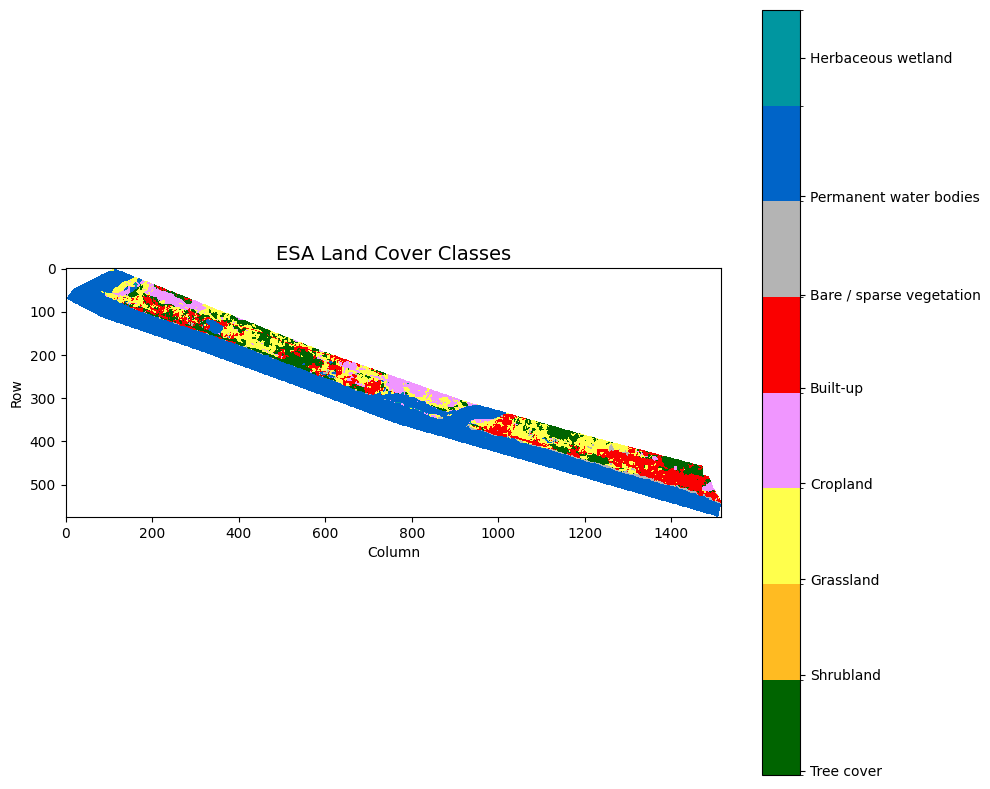

Visualization saved to /content/drive/MyDrive/CCL_Bantul/results/landcover_viz.png

=== Generating QGIS Style for LULC: landcover.tif ===
LULC source key for styling: esa
Using ESA WorldCover 11-Class definitions for QML style.
QGIS LULC style file (ESA WorldCover 11-Class) saved to: /content/drive/MyDrive/CCL_Bantul/data/processed/landcover.qml

=== find_demnas initialized ===
Looking for DEMNAS data...
Found DEMNAS file in Google Drive: demnas_bantul_kulonprogo.tif

=== process_dem initialized ===
DEM successfully resampled to 10.0m resolution

=== visualize_raster initialized ===
Visualizing raster: /content/drive/MyDrive/CCL_Bantul/data/processed/slope.tif
 discrete=False, classes=None, names=None


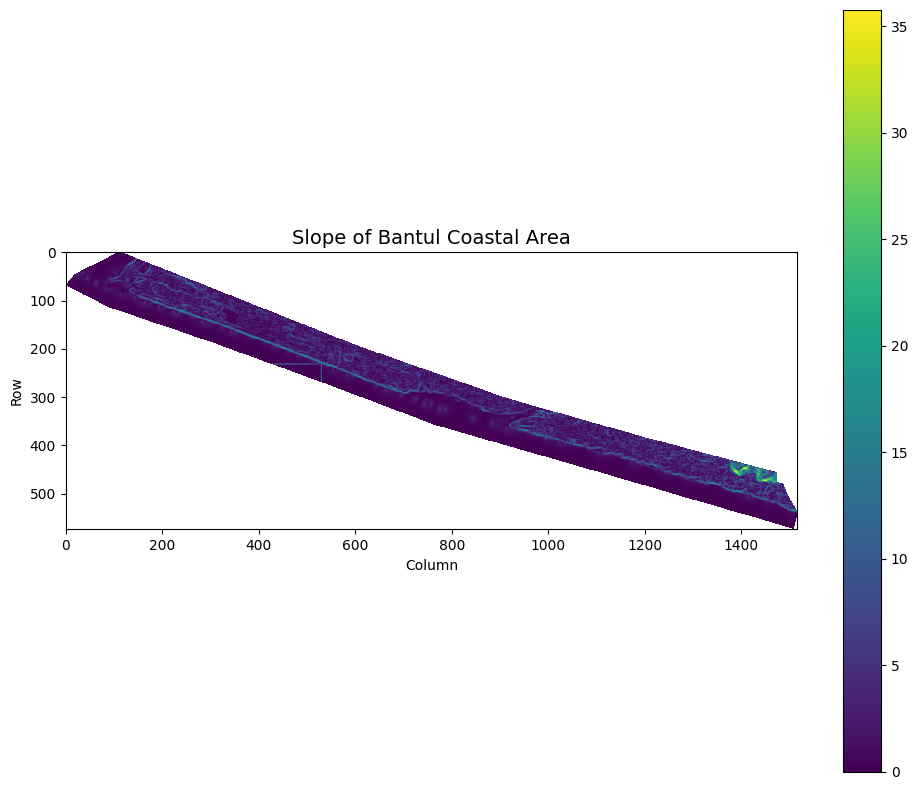

Visualization saved to /content/drive/MyDrive/CCL_Bantul/results/slope_viz.png

=== visualize_raster initialized ===
Visualizing raster: /content/drive/MyDrive/CCL_Bantul/data/processed/elevation.tif
 discrete=False, classes=None, names=None


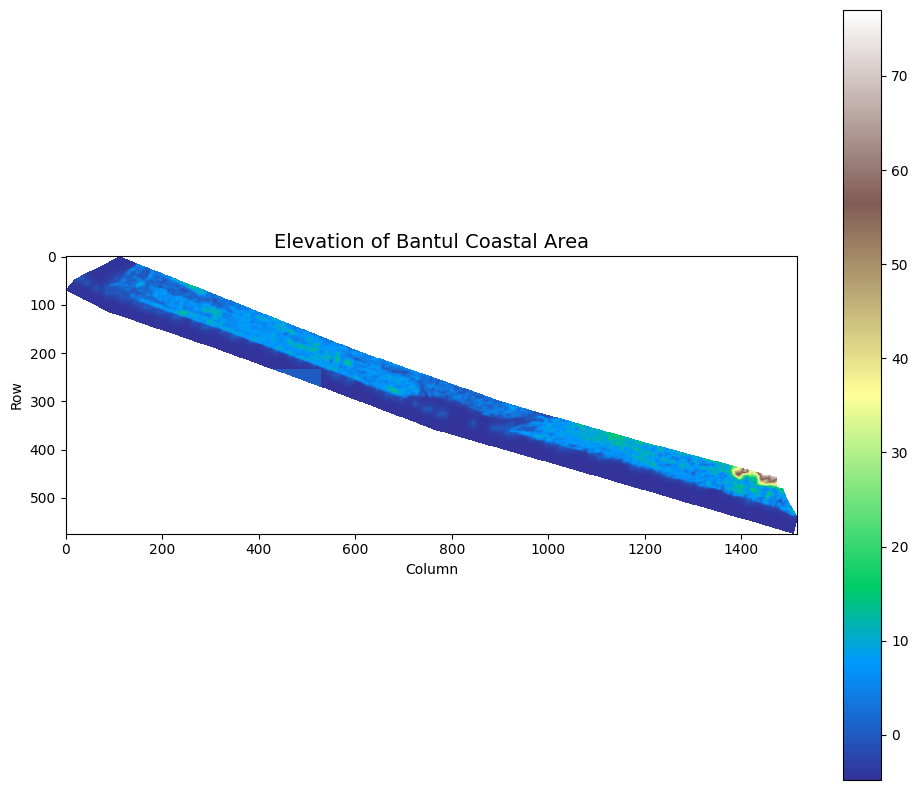

Visualization saved to /content/drive/MyDrive/CCL_Bantul/results/elevation_viz.png

=== process_geomorphology_data initialized ===
Processing Geomorphology Data from: geomorphology_yogyakarta.shp
  Read 43 features. Original CRS: EPSG:4326
  Reprojected geomorphology data to EPSG:32749
  Clipped to study area, 9 features remaining.
  Initial rasterization complete. Uncovered pixels (by polygons) have value: -9999
  Study area raster mask derived from global study_area_gdf. Total masked pixels: 154221
  Identified 61038 pixels within study area boundary not covered by specific geomorphology polygons.
  Assigning 'Water Body' class code (998) to these 61038 unmapped pixels.
  Processed geomorphology classified raster saved to: /content/drive/MyDrive/CCL_Bantul/data/processed/geomorphology.tif

=== visualize_raster initialized ===
Visualizing raster: /content/drive/MyDrive/CCL_Bantul/data/processed/geomorphology.tif
 discrete=True, classes=[101, 102, 103, 107, 110, 998], names=['Floodplai

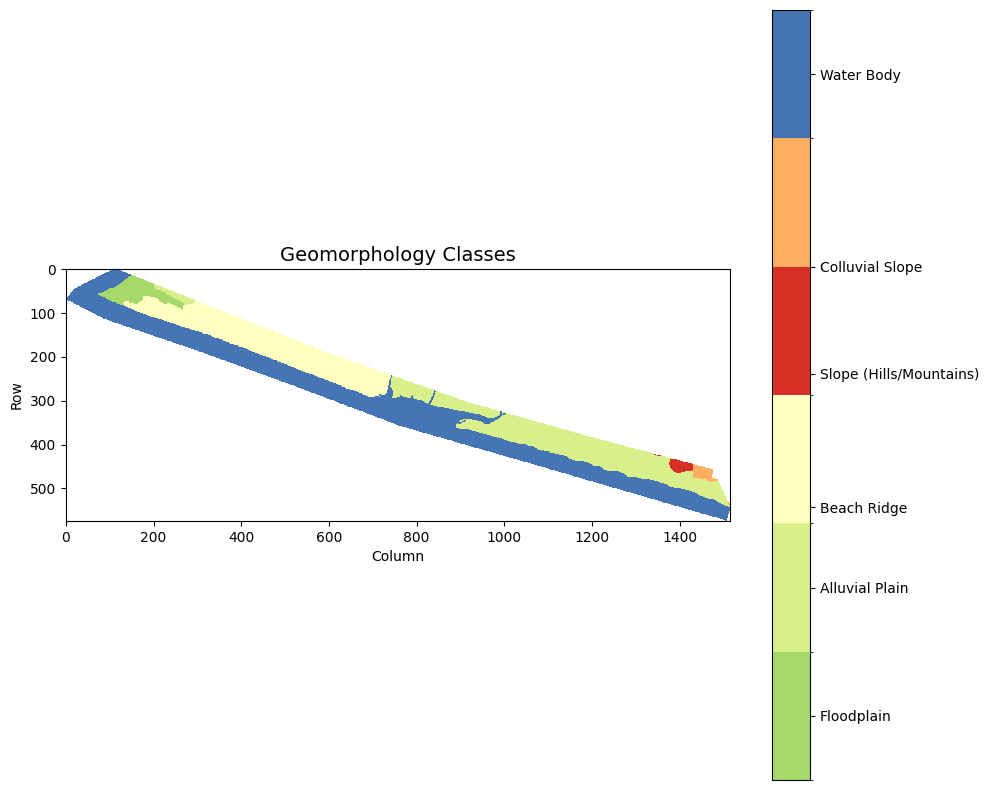

Visualization saved to /content/drive/MyDrive/CCL_Bantul/results/geomorphology_viz.png

=== Generating QGIS Style for Geomorphology: geomorphology.tif ===
  QGIS Geomorphology style file saved to: /content/drive/MyDrive/CCL_Bantul/data/processed/geomorphology.qml

Processing coastline and shoreline change data...

=== process_coastline_data initialized ===
Processing coastline data: shoreline-v3-1.csv
Successfully created coastline from CSV data
CSV Coordinate Range (WGS84):
Lon: 110.011684 to 110.339155
Lat: -8.028097 to -7.891523
UTM Coordinate Range:
X: 412412.92 to 427178.87
Y: 9112537.33 to 9117564.62
Coastline data processing complete. Source: user_csv

=== calculate_distance_to_shoreline initialized ===
Coastline geometry types: ['LineString']
Exporting distance to shoreline as vector formats...
Distance calculation complete. Files saved to:
 - Raster: /content/drive/MyDrive/CCL_Bantul/data/processed/distance_to_shoreline.tif
 - Shapefile: /content/drive/MyDrive/CCL_Bantul/data/

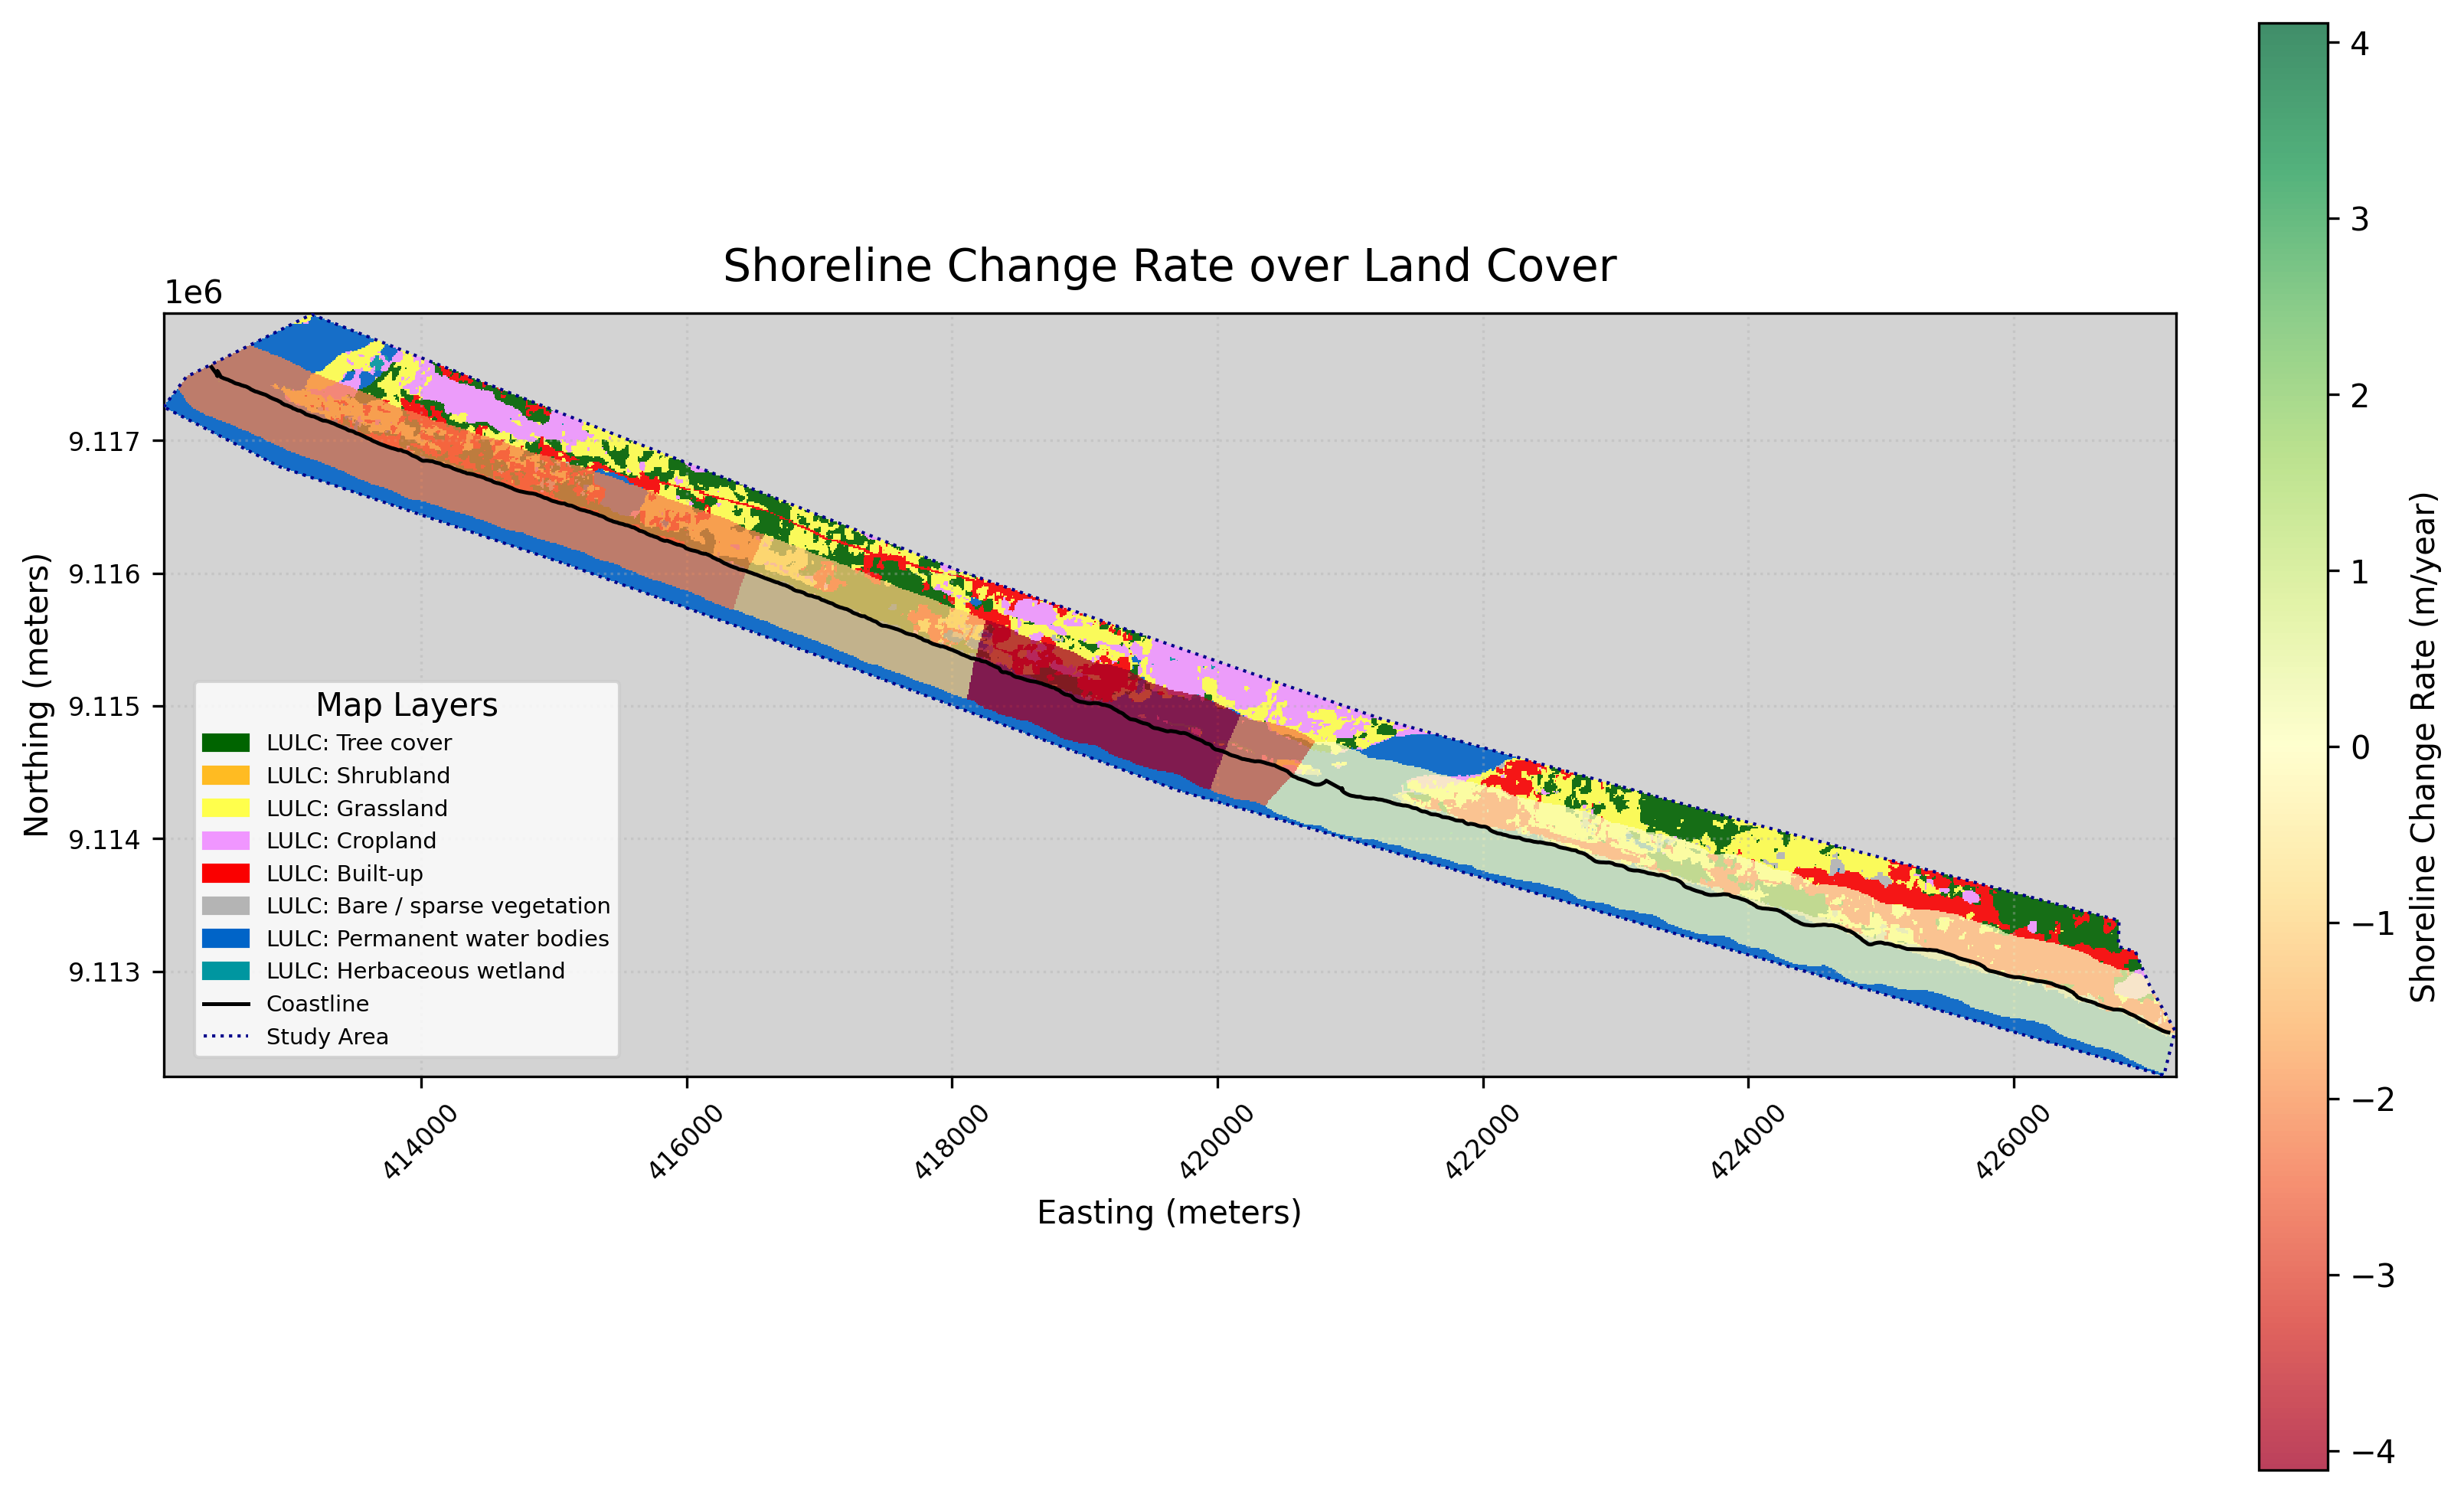

  Shoreline change visualization saved to: /content/drive/MyDrive/CCL_Bantul/results/shoreline_change_300m_visualization_legend_fixed.png
Calculating ocean/marine-based parameters...

=== calculate_wave_parameter initialized ===
Found 1 wave dataset(s):
1. cmems_mod_glo_wav_my_0.2deg_PT3H-i_wave.nc
Using: cmems_mod_glo_wav_my_0.2deg_PT3H-i_wave.nc
  Loading NetCDF data from: /content/drive/MyDrive/CCL_Bantul/data/raw/cmems_mod_glo_wav_my_0.2deg_PT3H-i_wave.nc
  Calculating temporal average for Significant Wave Height (VHM0)
  Processing Significant Wave Height...
    Saved initial Significant Wave Height (source projection) to /content/drive/MyDrive/CCL_Bantul/data/temp/rio_initial/temp_hs_mean_initial_rio.tif
    Warping Significant Wave Height to match LULC grid -> /content/drive/MyDrive/CCL_Bantul/data/temp/gdal_aligned/temp_hs_mean_aligned_gdal.tif
    Post-processing warped data for Significant Wave Height...
    Final processed Significant Wave Height saved to: /content/drive/MyD

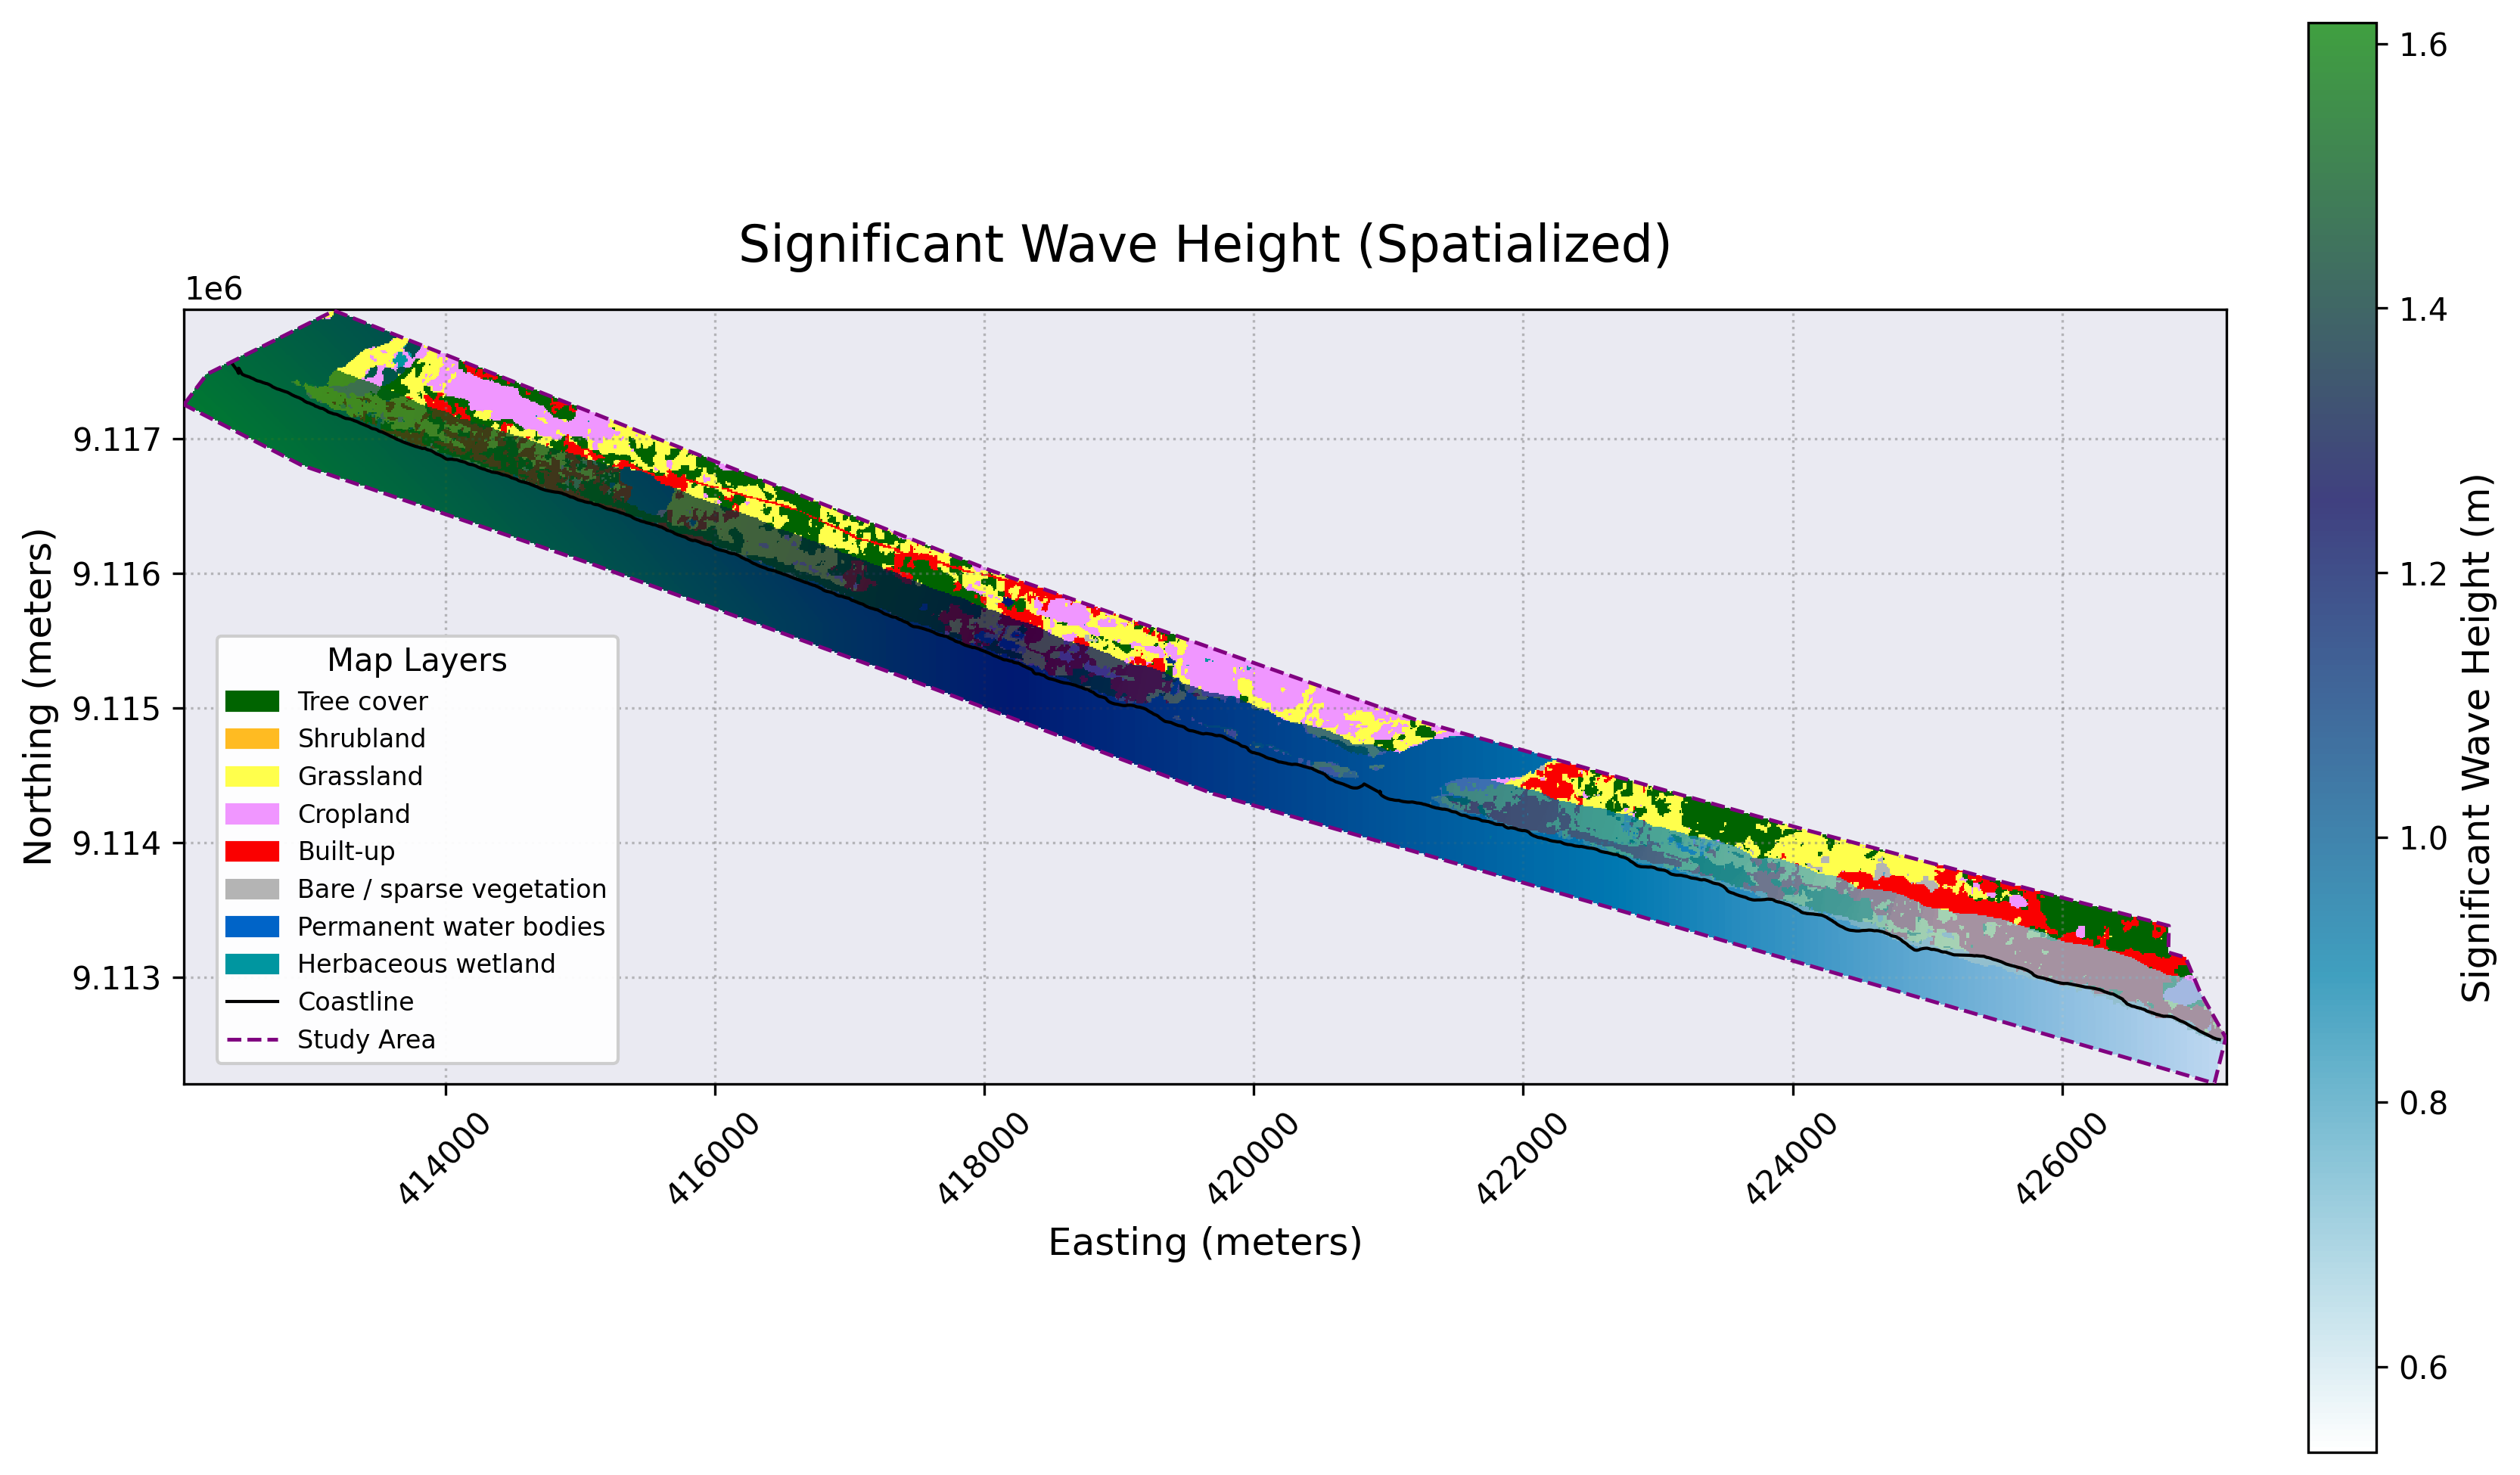

  Refined visualization for 'Significant Wave Height' saved to: /content/drive/MyDrive/CCL_Bantul/results/significant_wave_height_final_viz.png

=== get_constant_slr_rate initialized ===
  Using constant Sea Level Rise Rate: 4.00 mm/yr.
  Using LULC source 'esa'. Water class code is: 80
  Applied SLR rate of 4.0 to 75848 water pixels.
  Applied study area boundary mask.
  Constant SLR rate raster created successfully: /content/drive/MyDrive/CCL_Bantul/data/processed/slr_rate.tif

=== spatialize_marine_parameter (Refined) for 'slr_rate' ===
  Value for 'Very Low' vulnerability (Rank 1) for 'slr_rate' calculated as: -1.10
    Assigned spatialized values to 37600 LAND pixels in the coastal zone.
    Set 40246 LAND pixels outside coastal zone to -1.1.
Refined spatialized 'slr_rate' raster saved to: /content/drive/MyDrive/CCL_Bantul/data/processed/slr_rate_final.tif

=== visualize_slr_landcover initialized ===
LULC source key: esa
Using ESA WorldCover 11-class definitions for LULC basemap.


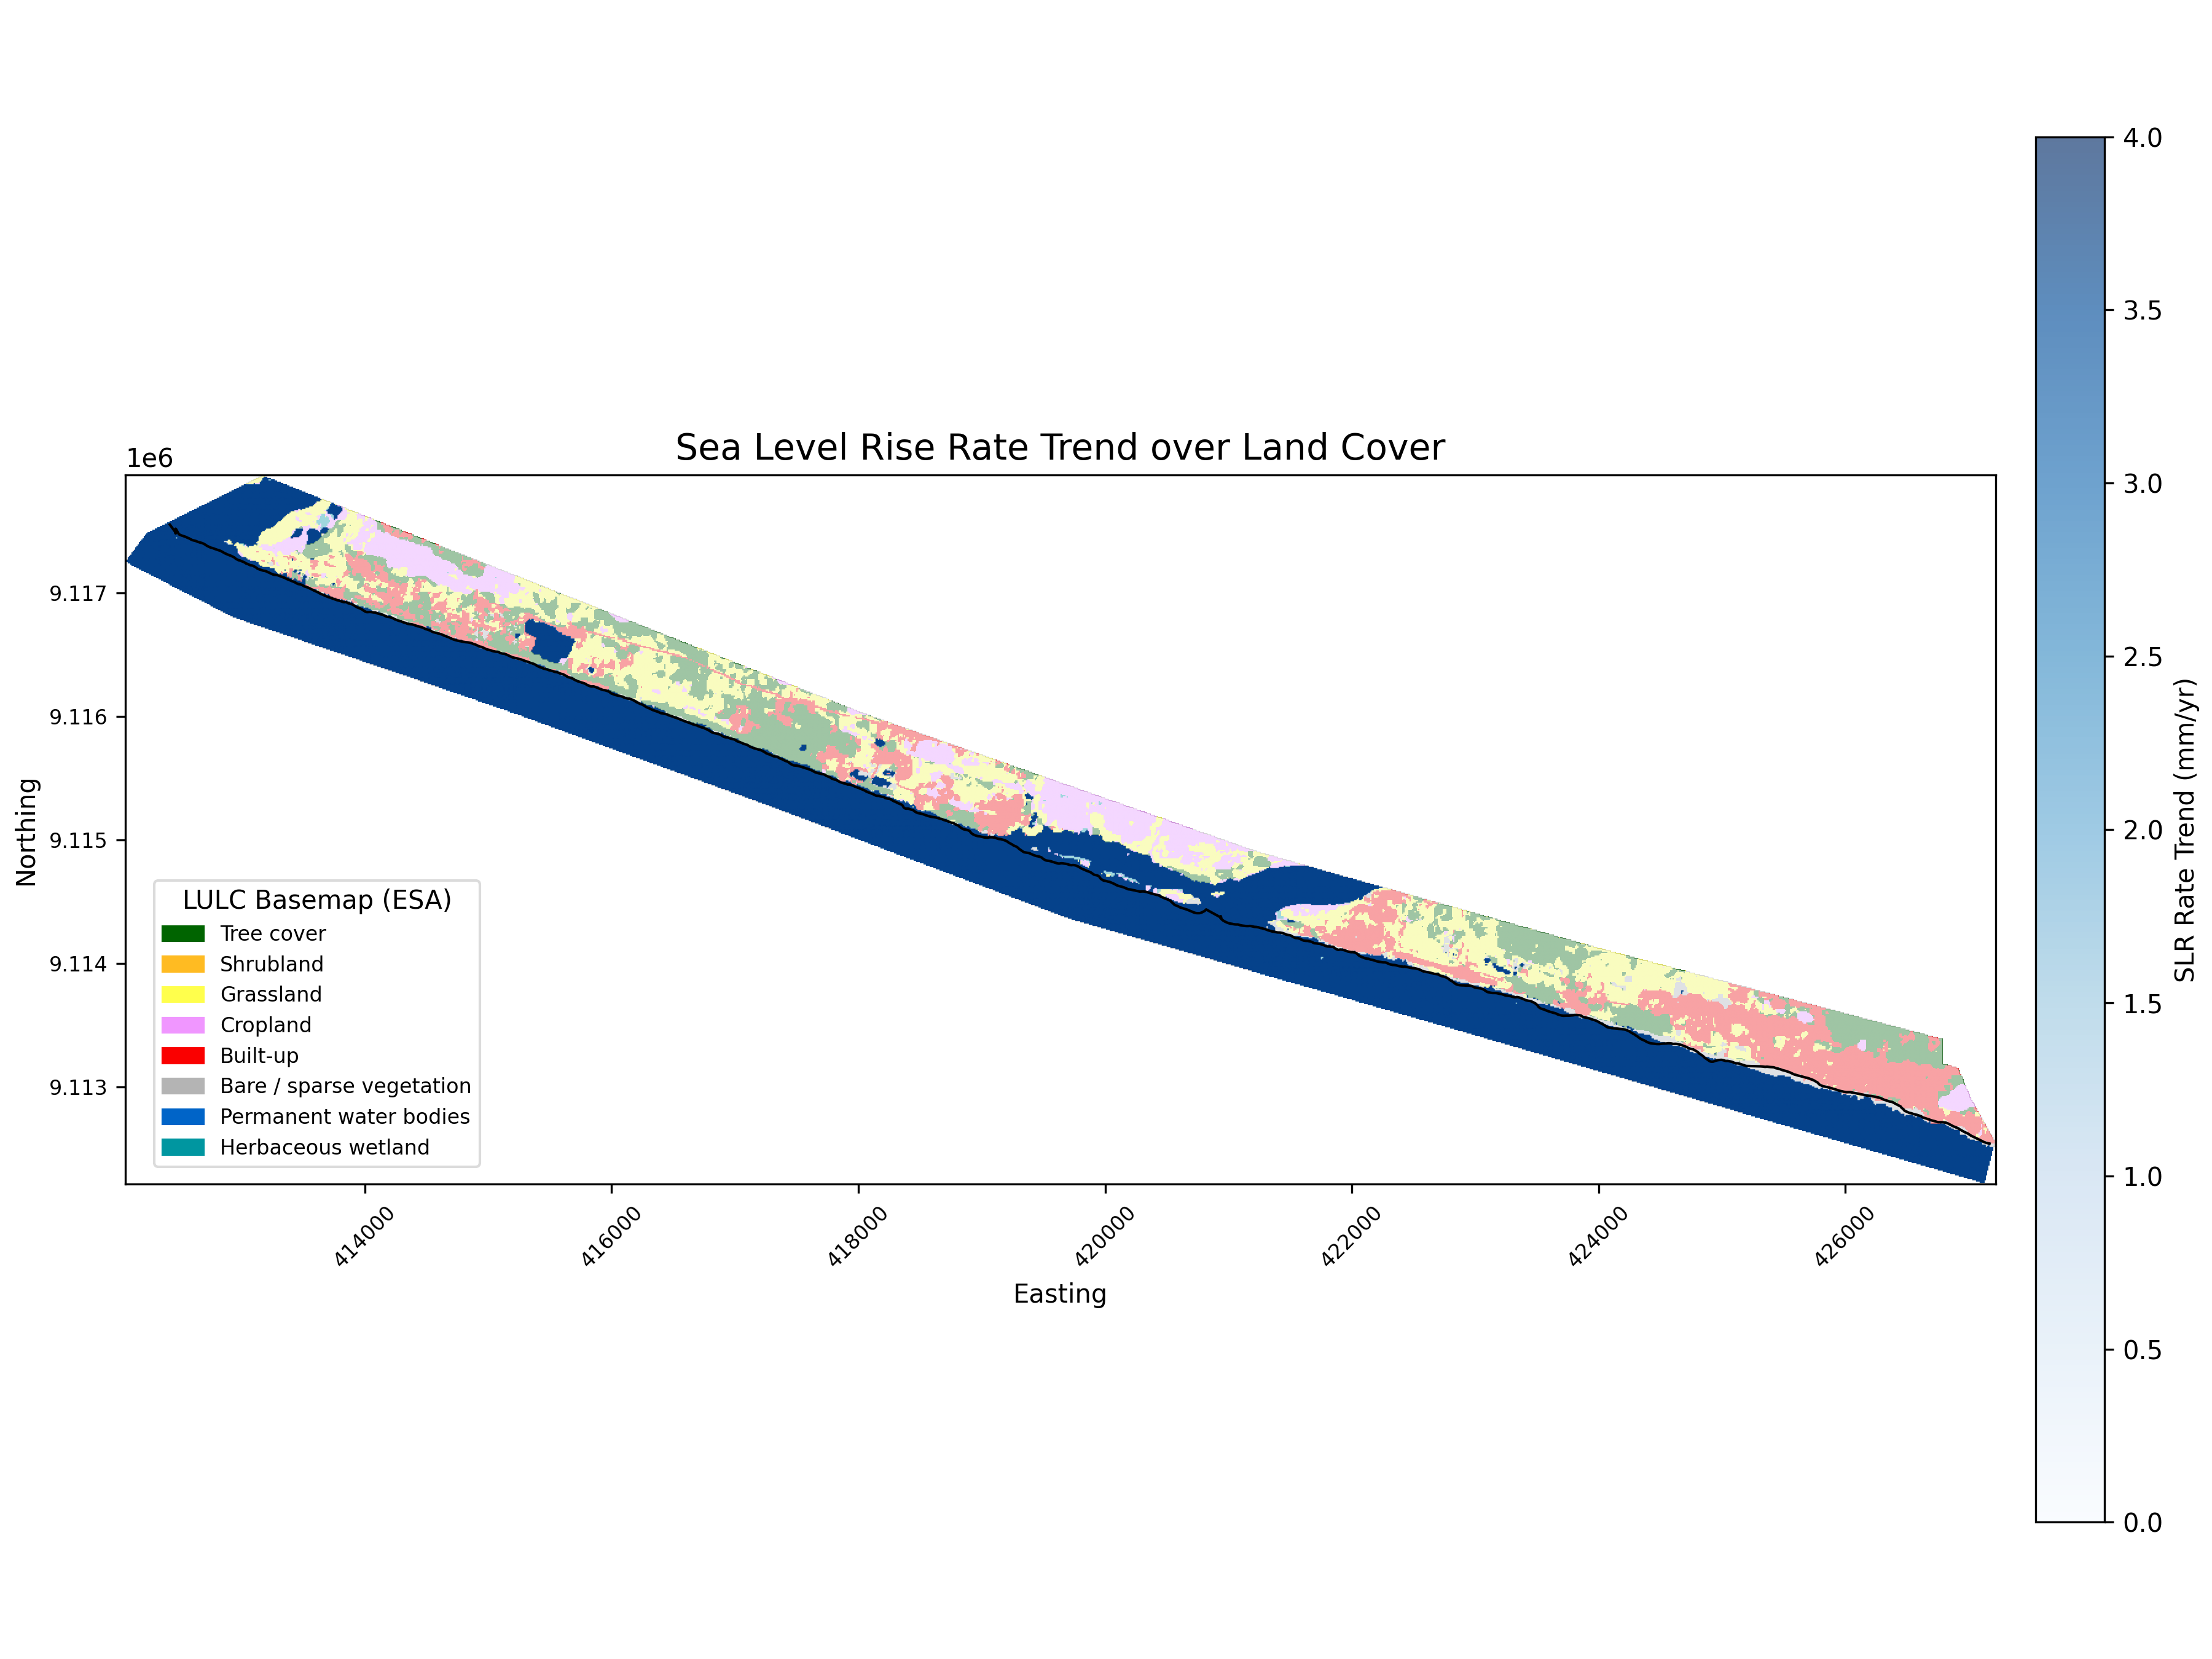

SLR rate visualization saved to /content/drive/MyDrive/CCL_Bantul/results/slr_rate_lulc_visualization.png

=== visualize_spatialized_marine_parameter (Refined) for: Sea Level Rise Rate initialized ===
  LULC Basemap type: ESA


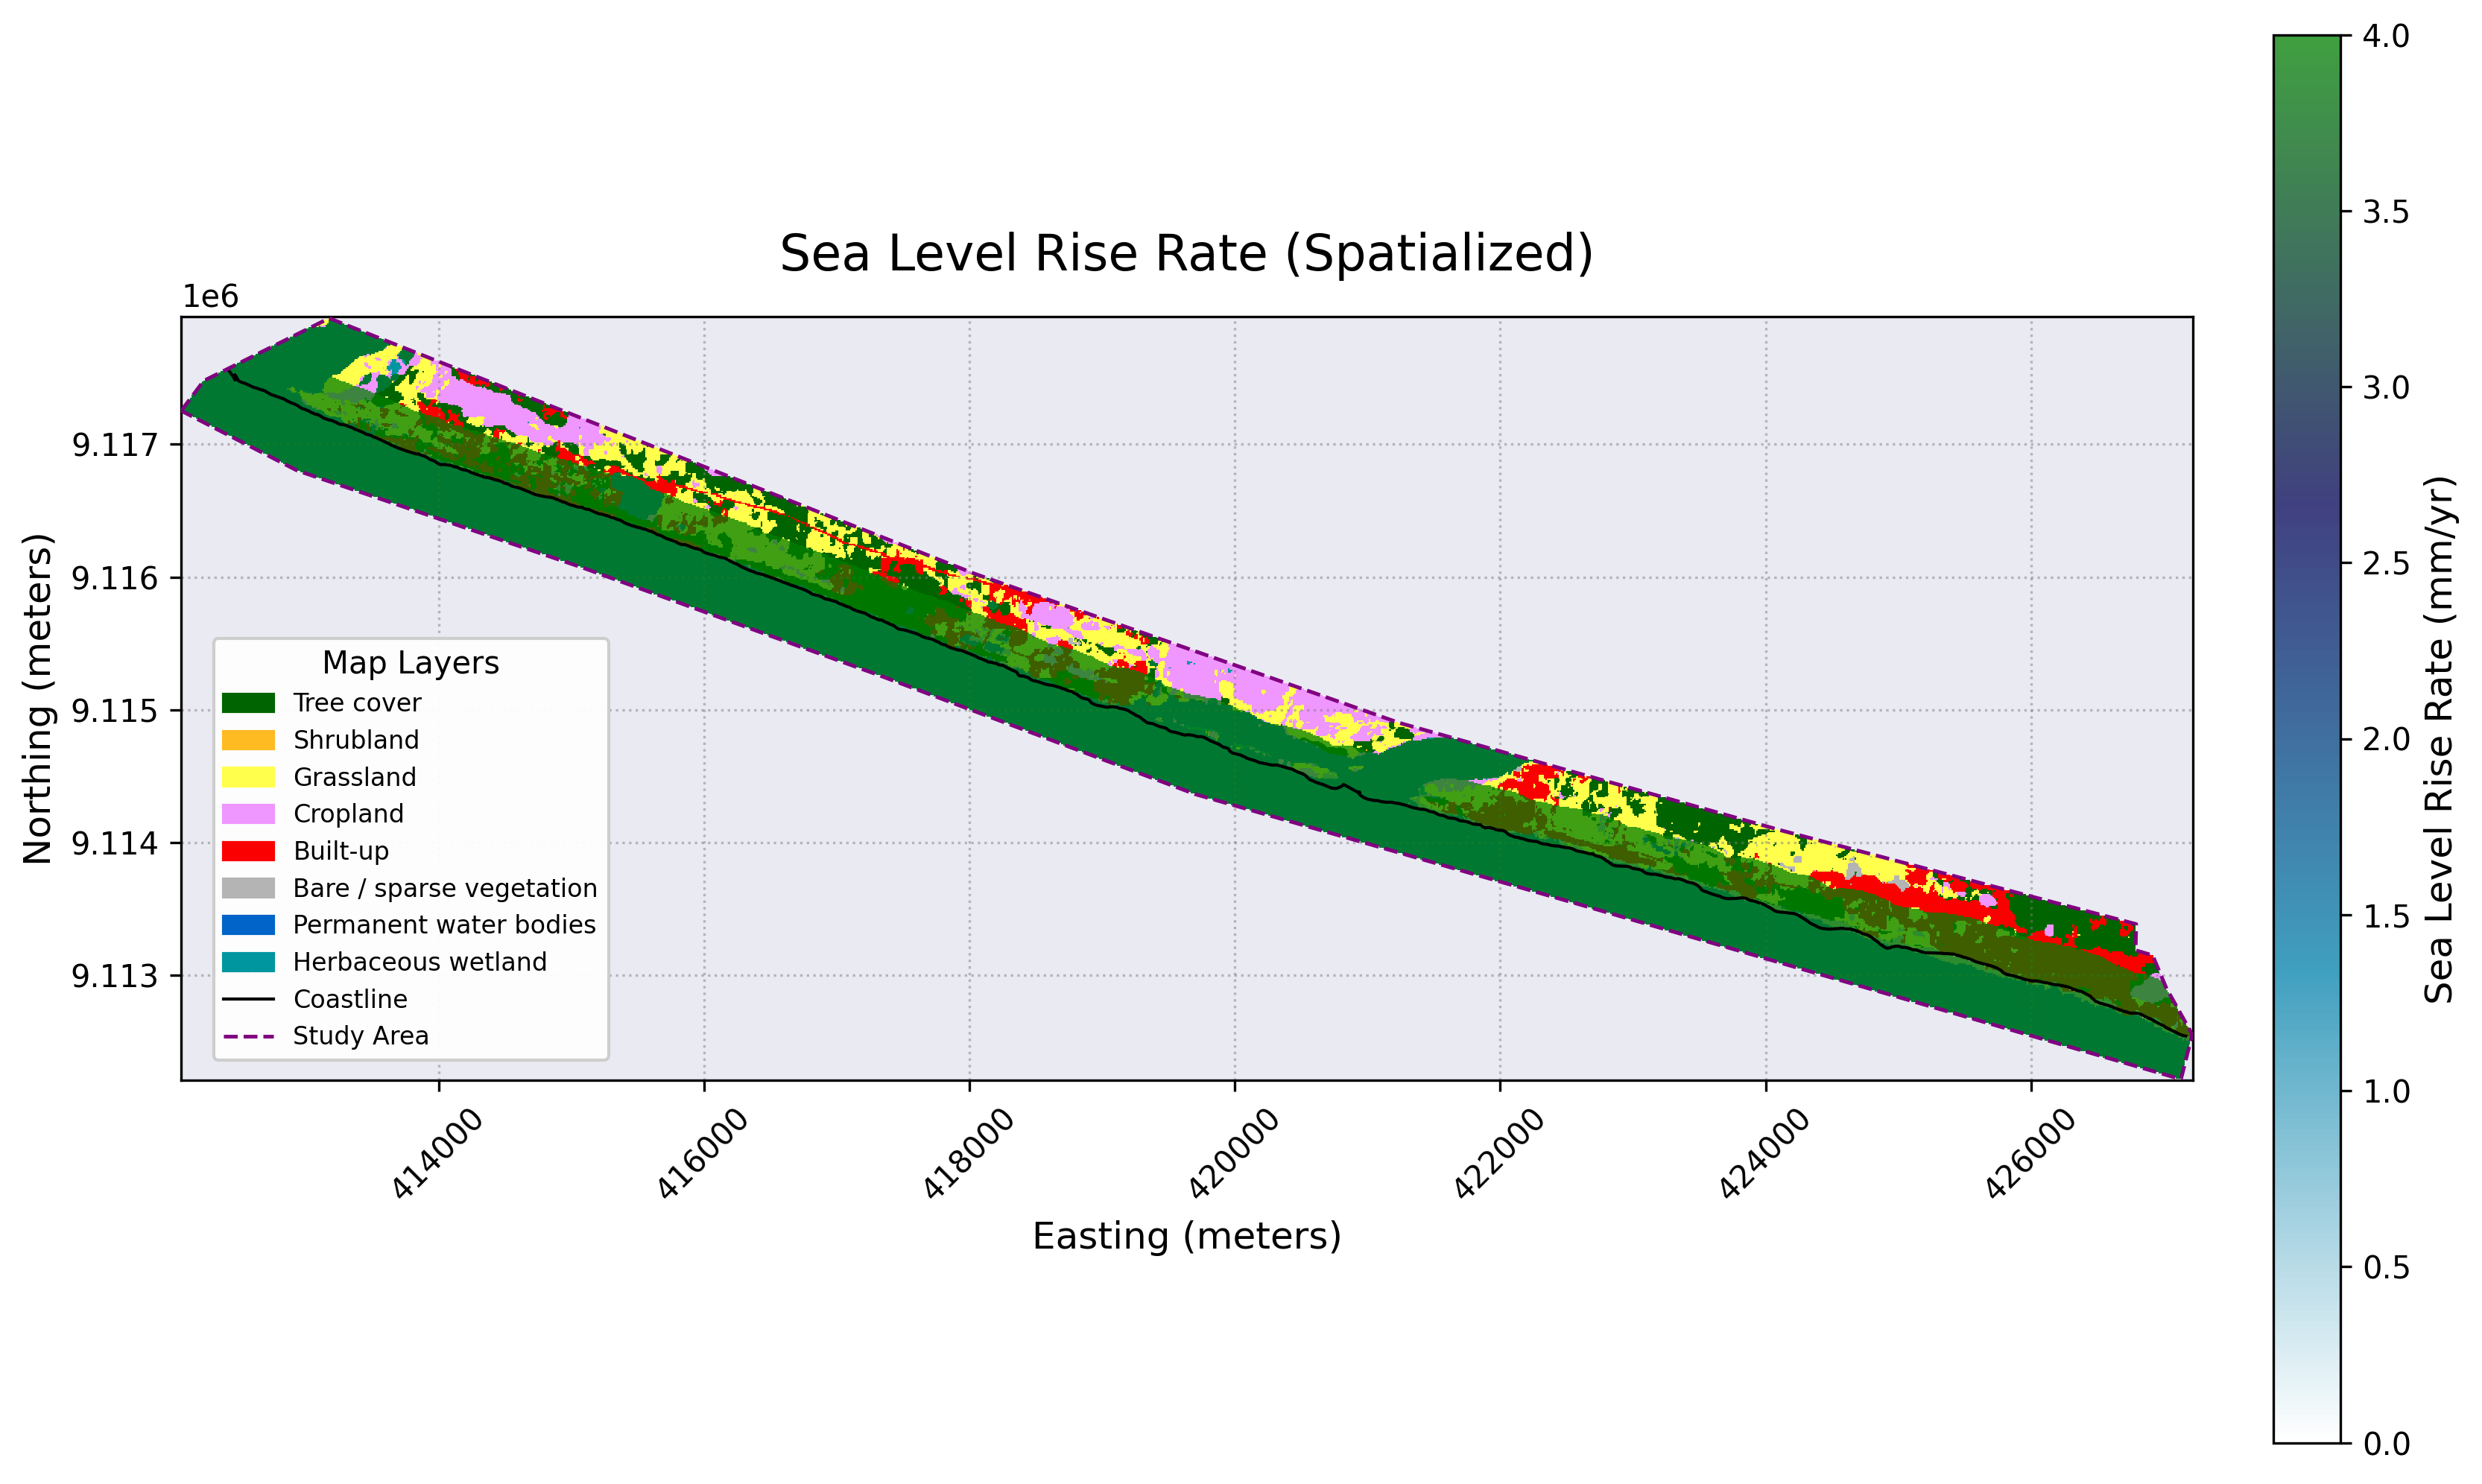

  Refined visualization for 'Sea Level Rise Rate' saved to: /content/drive/MyDrive/CCL_Bantul/results/slr_rate_final_viz.png

=== calculate_fes_tidal_range initialized ===
  Checking source: m2_fes2022.nc...
    Source data within bounds is complete.
  Checking source: s2_fes2022.nc...
    Source data within bounds is complete.
  Aligning m2 component...
    Aligned data for 'm2' contains 0 NoData pixels.
  Aligning s2 component...
    Aligned data for 's2' contains 0 NoData pixels.
  Aligning mask component...
    Aligned data for 'mask' contains 0 NoData pixels.
  Calculating Mean Spring Tidal Range (MSTR)...
  Creating final raster using high-resolution LULC mask...
  Final MSTR field created successfully with NO GAPS in ocean area.
  Output saved to: /content/drive/MyDrive/CCL_Bantul/data/processed/tidal_range_parameter_m.tif

=== spatialize_marine_parameter (Refined) for 'tidal_range' ===
  Value for 'Very Low' vulnerability (Rank 1) for 'tidal_range' calculated as: 6.10
    Assig

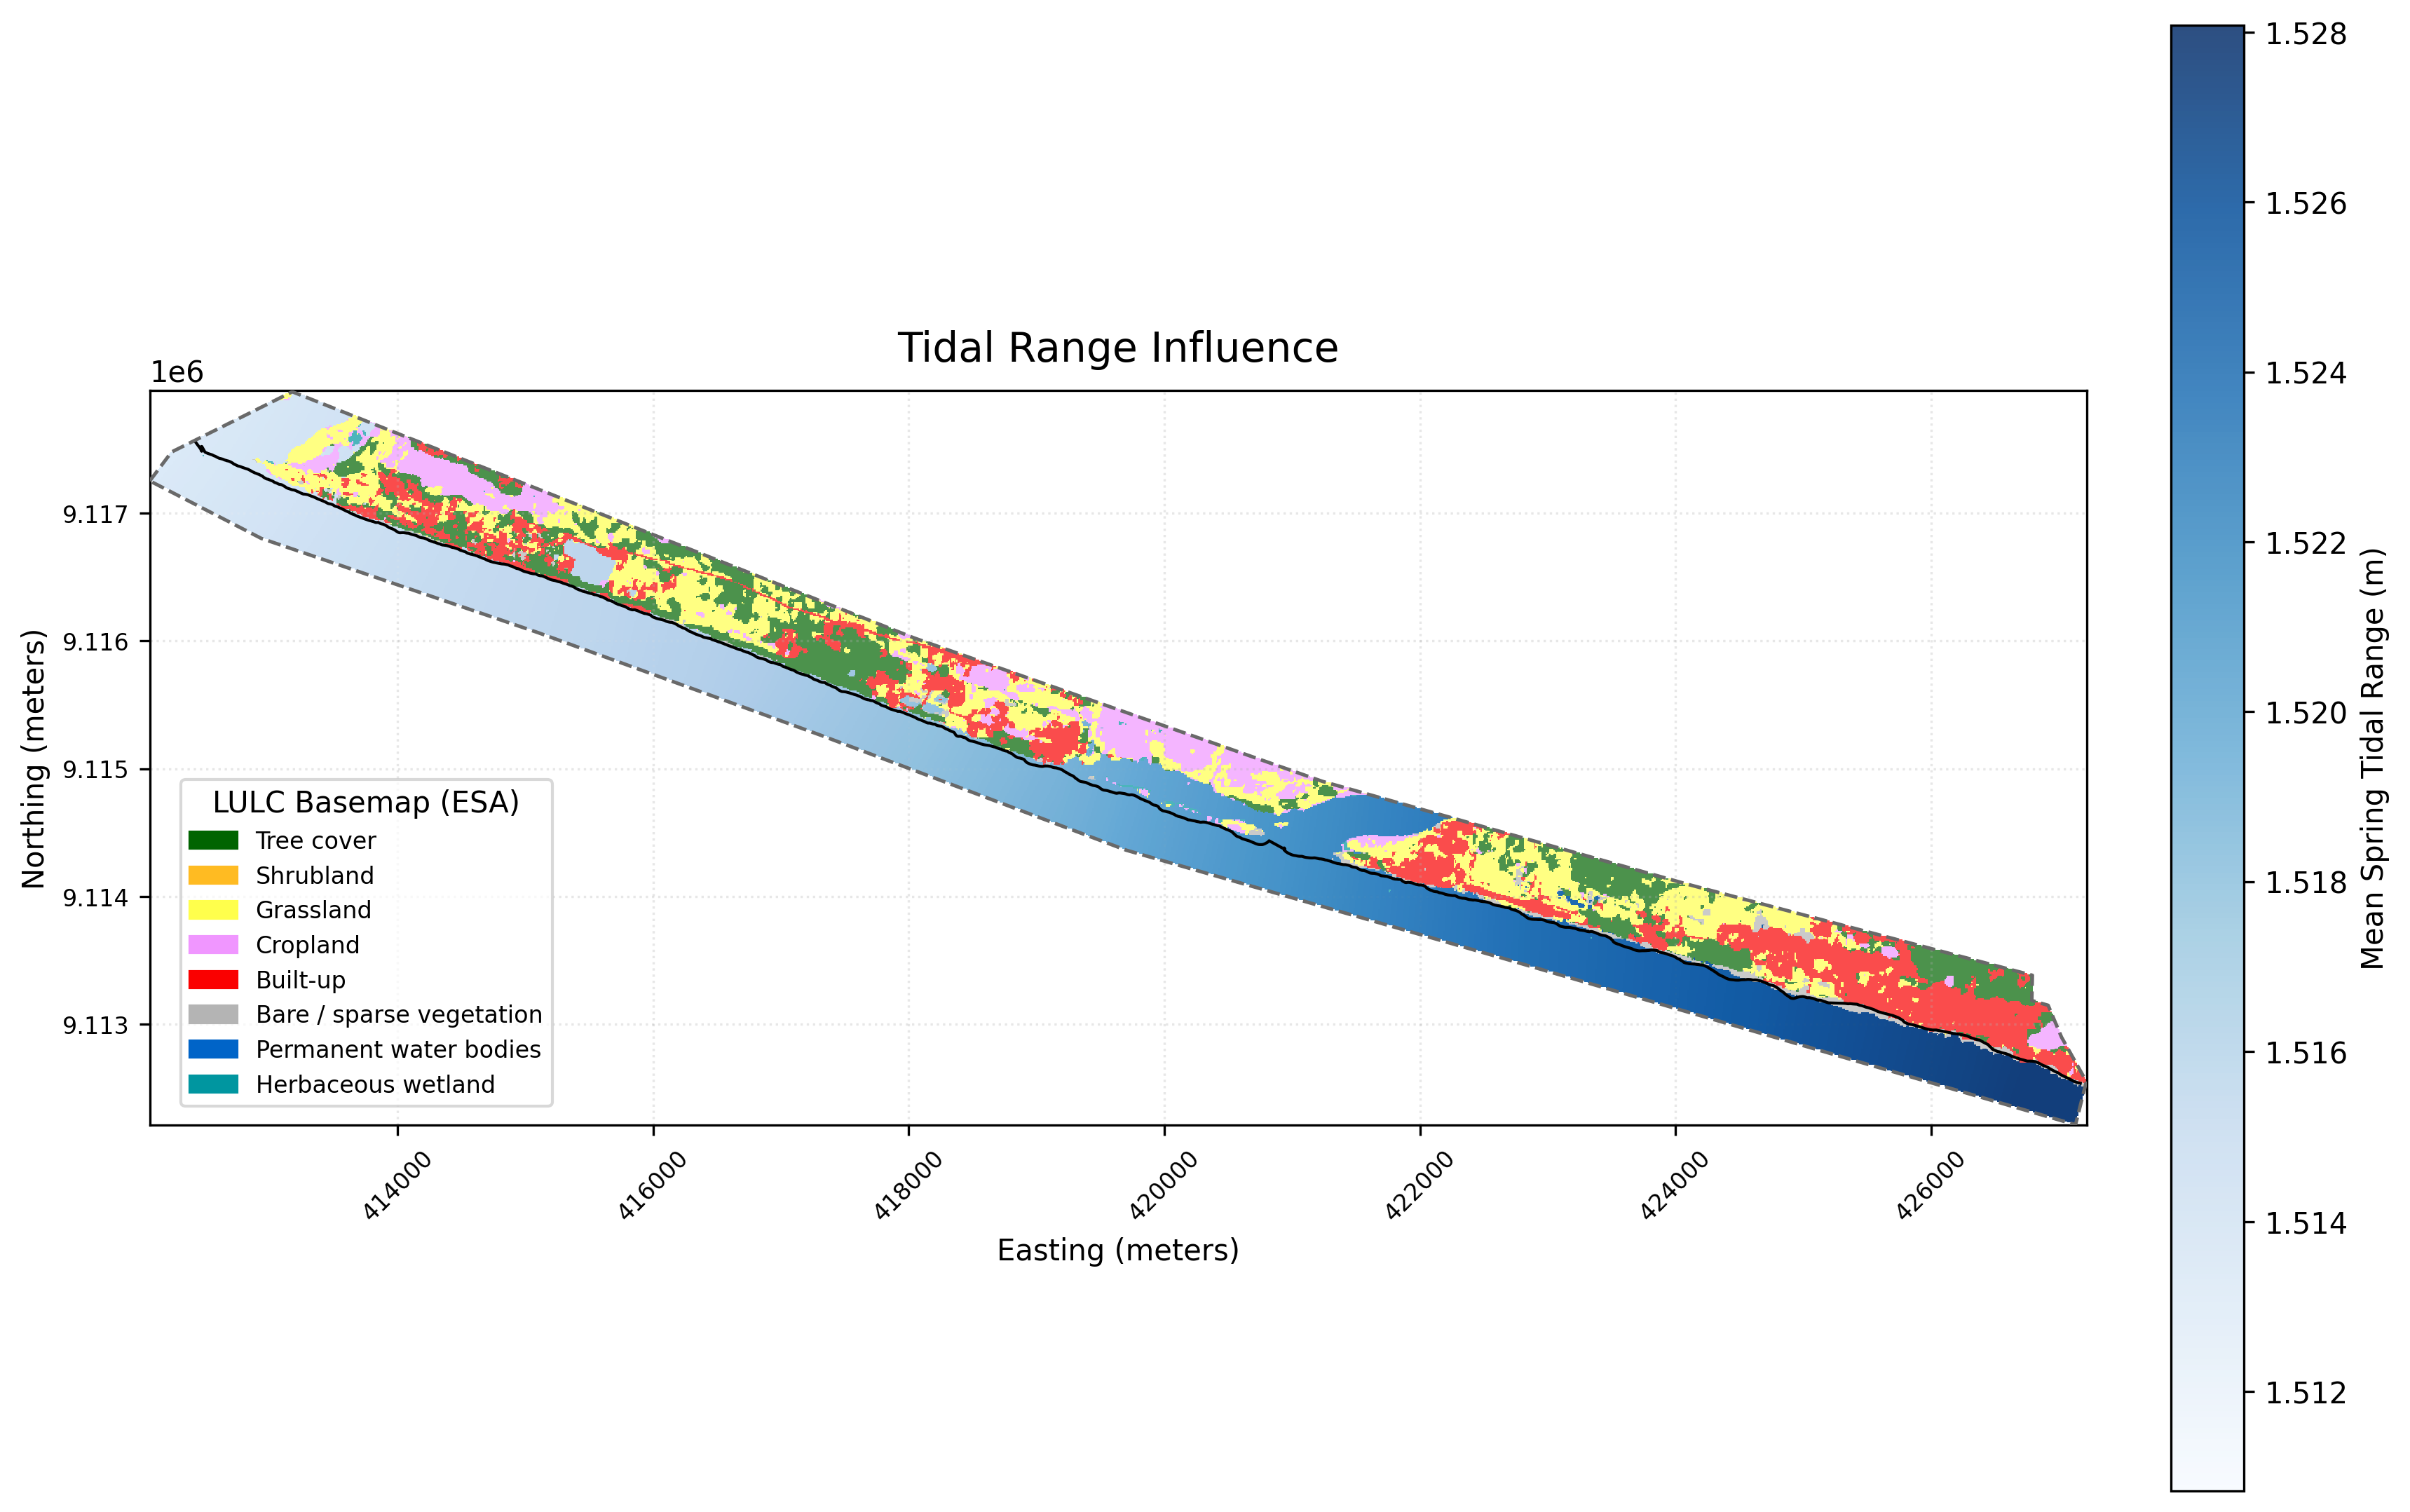

  Tidal range (MHWS zone) visualization saved to: /content/drive/MyDrive/CCL_Bantul/results/tidal_range_parameter_m_visualization.png

=== visualize_spatialized_marine_parameter (Refined) for: Tidal Range initialized ===
  LULC Basemap type: ESA


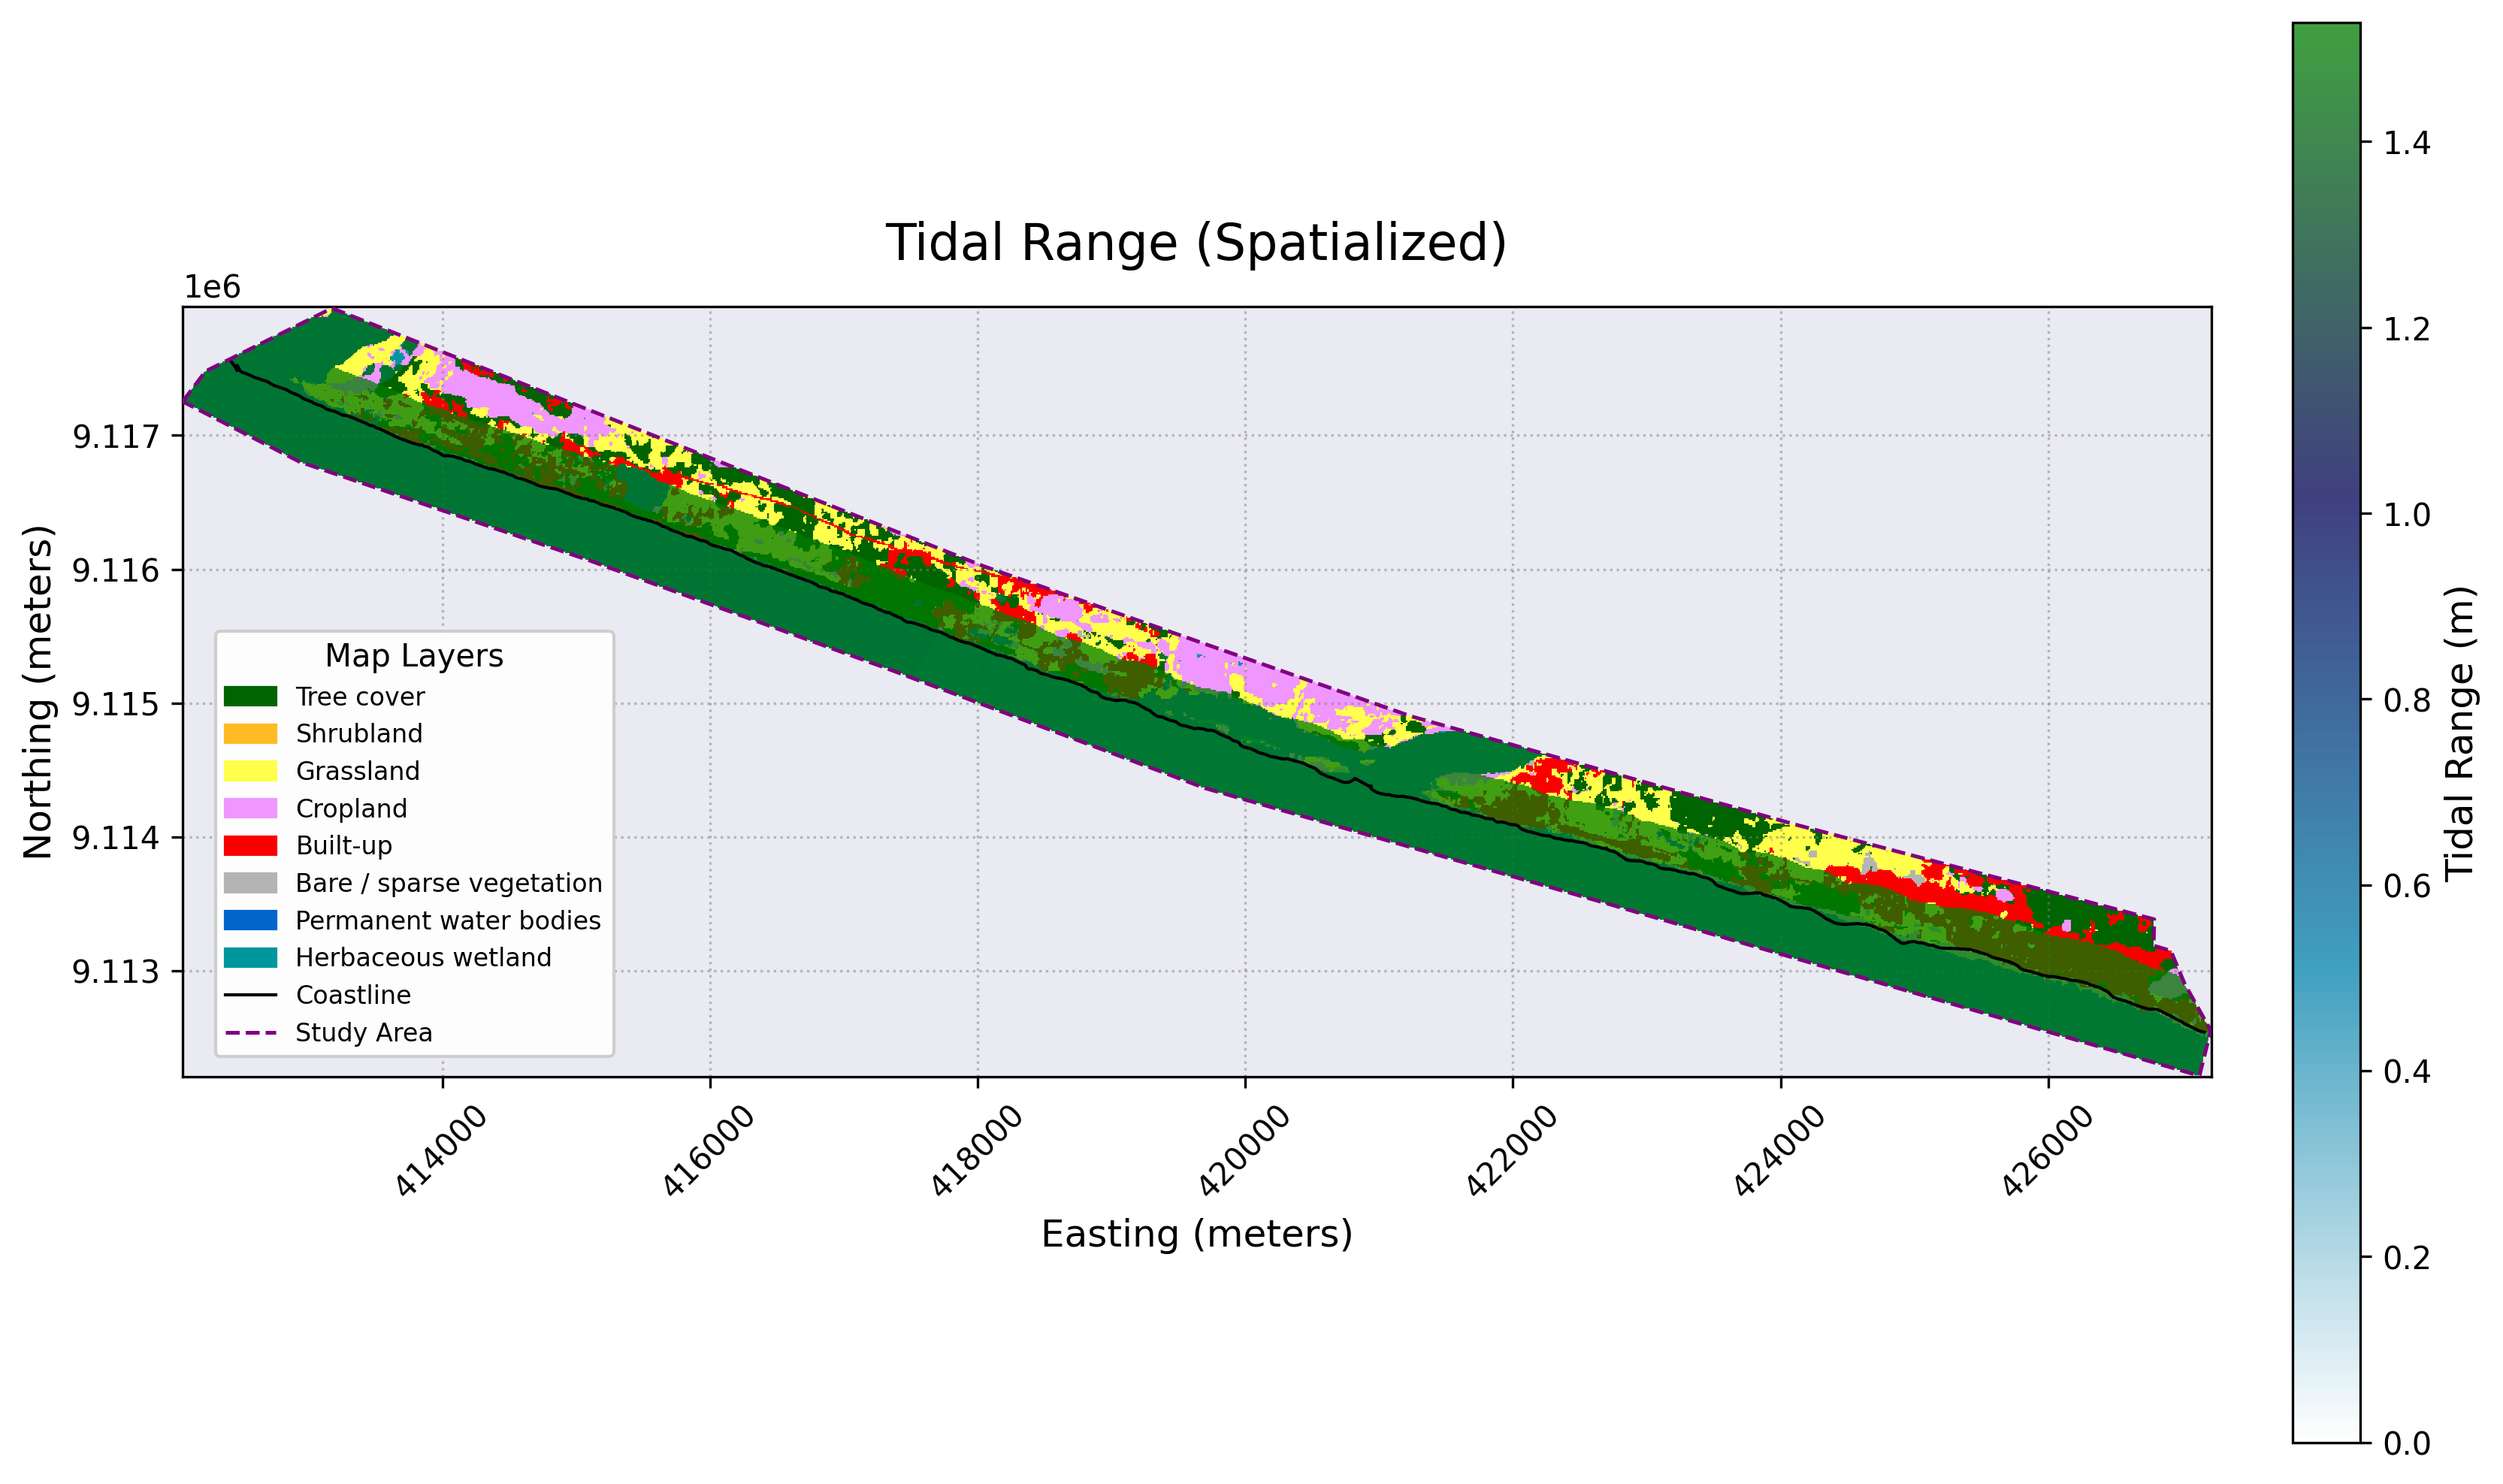

  Refined visualization for 'Tidal Range' saved to: /content/drive/MyDrive/CCL_Bantul/results/tidal_range_final_viz.png
Using ESA WorldCover 11-class specific ranks for Traditional CVI.

=== calculate_traditional_cvi initialized | Method: equal ===
  Processing and ranking: elevation
    Detected inverted vulnerability scale for 'elevation'. Standardizing for processing.
  Processing and ranking: slope
    Detected inverted vulnerability scale for 'slope'. Standardizing for processing.
  Processing and ranking: landcover
  Processing and ranking: shoreline_change
    Detected inverted vulnerability scale for 'shoreline_change'. Standardizing for processing.
  Processing and ranking: significant_wave_height
  Processing and ranking: tidal_range
    Detected inverted vulnerability scale for 'tidal_range'. Standardizing for processing.
  Processing and ranking: slr_rate
  Processing and ranking: distance_to_shoreline
    Detected inverted vulnerability scale for 'distance_to_shoreline'. S

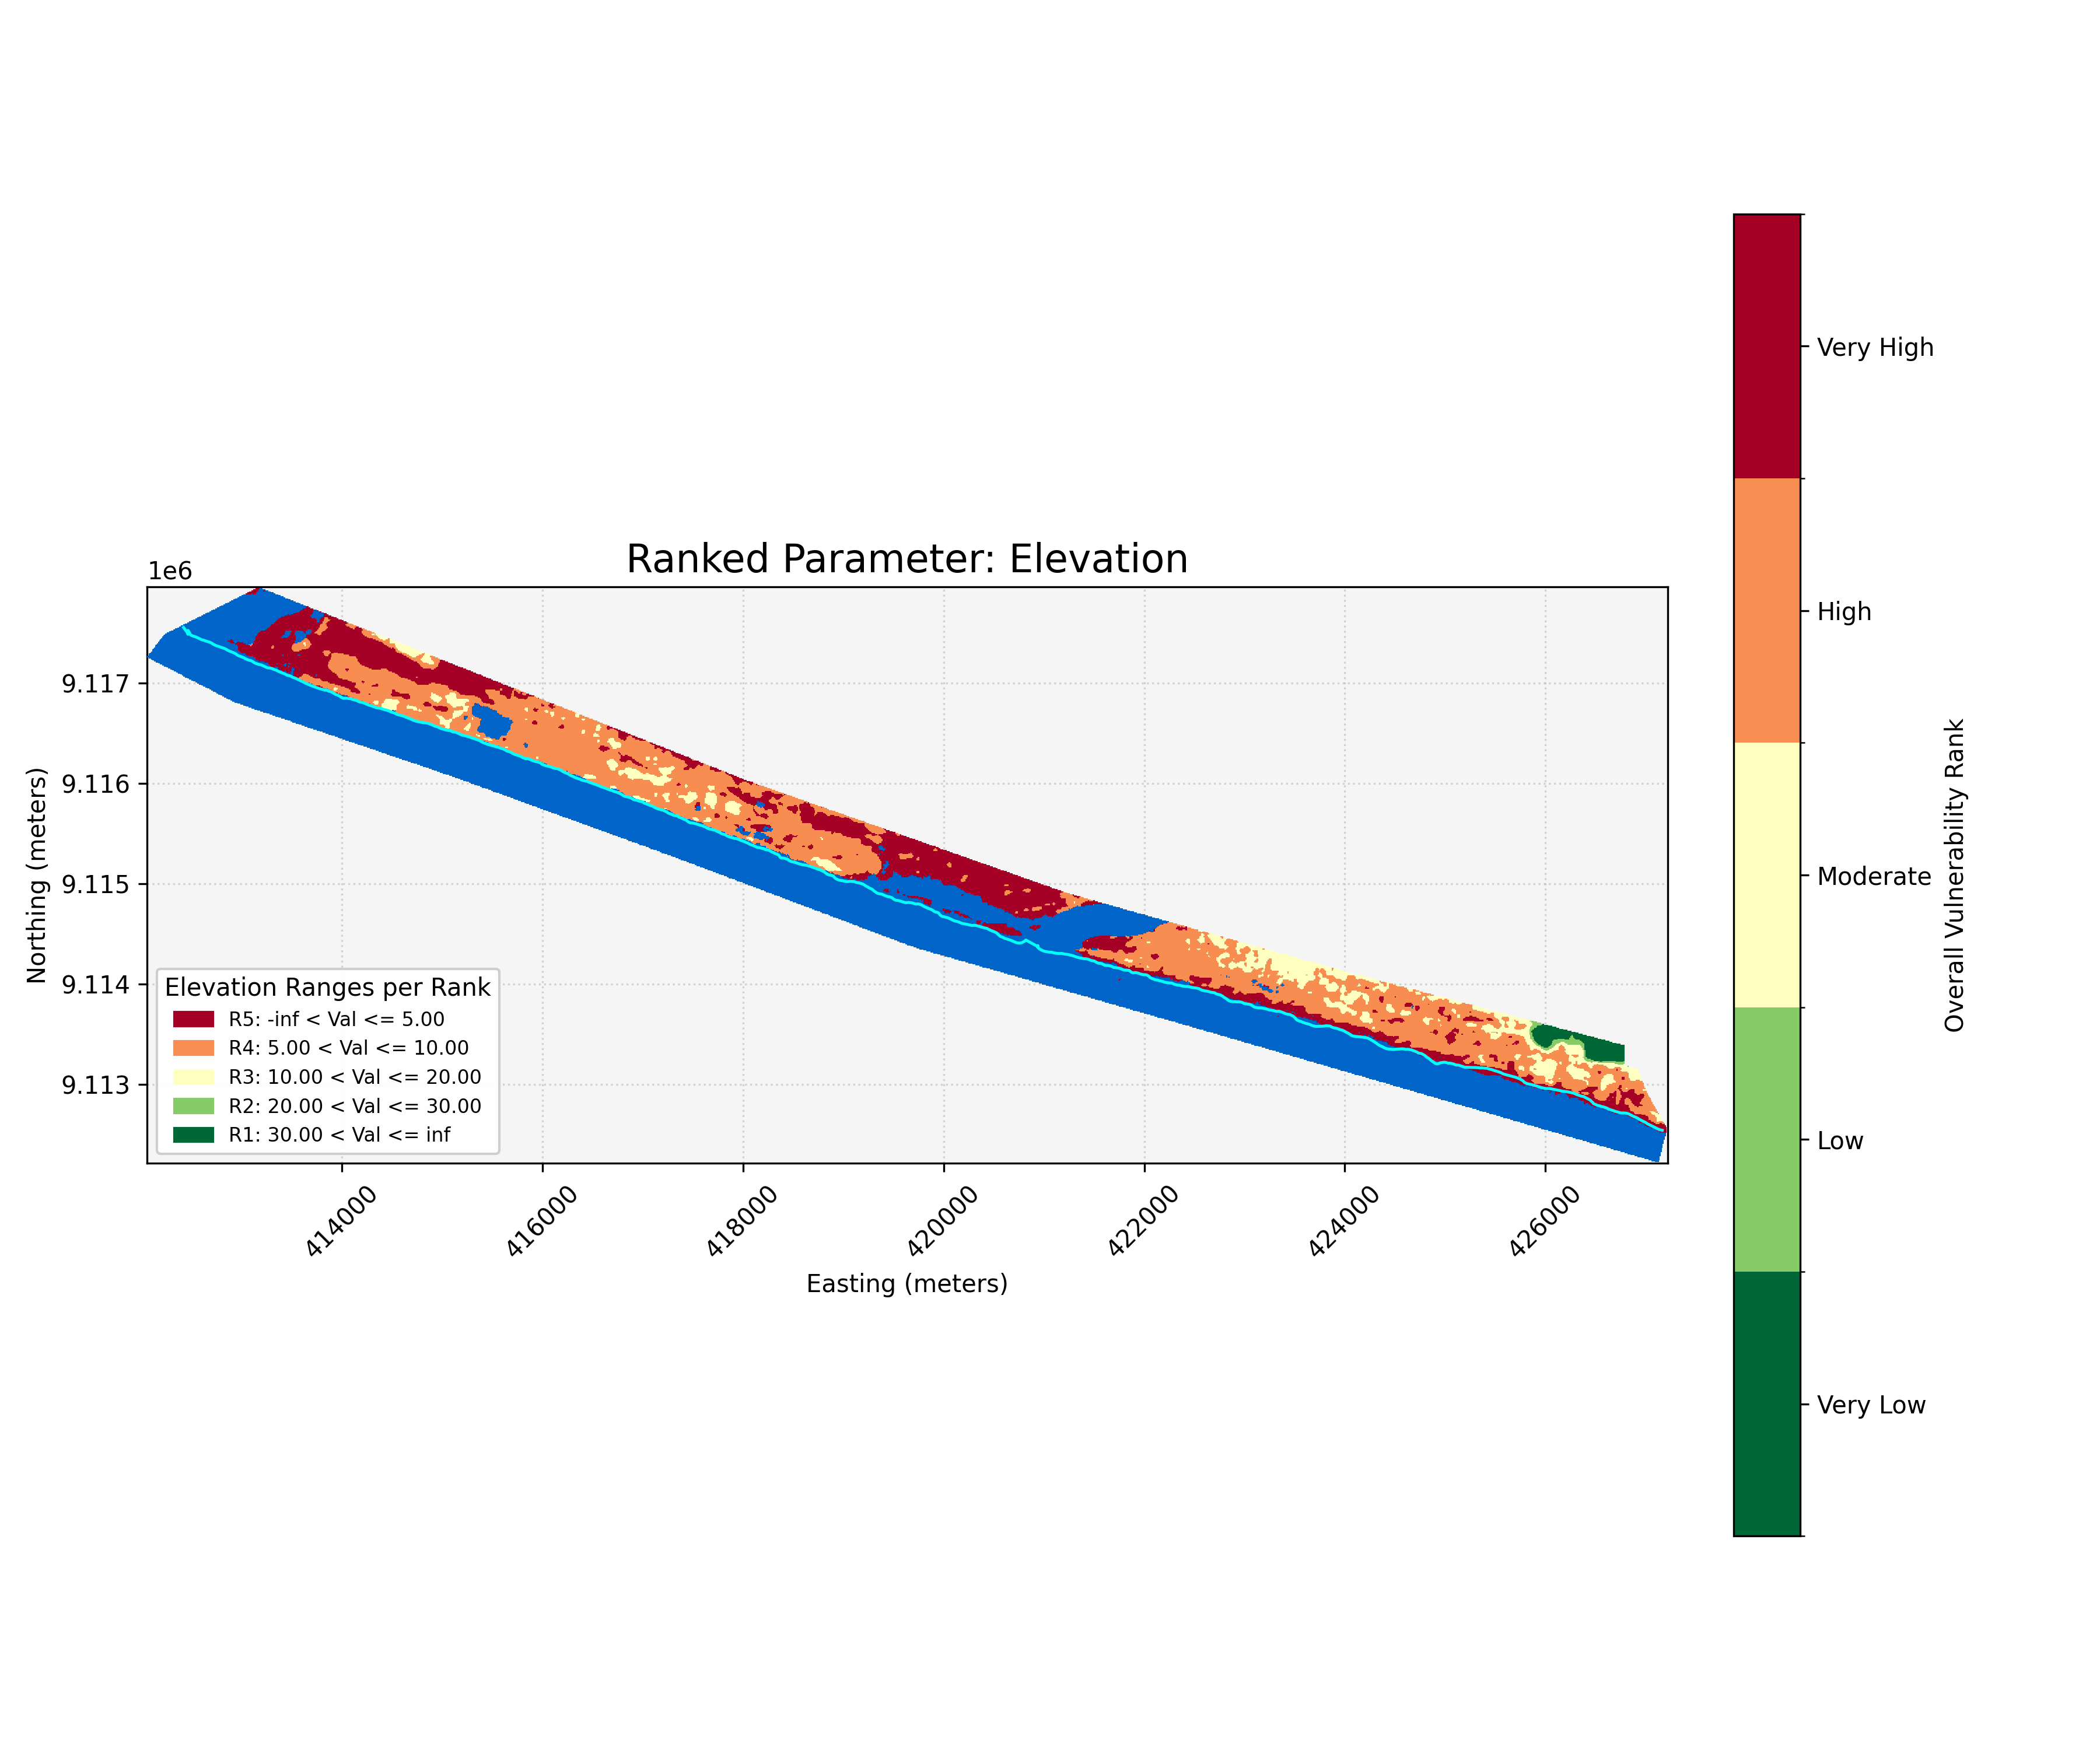


=== visualize_ranked_parameter: slope ===
    'show_water_vulnerability' is False. Masking water bodies for 'slope'.


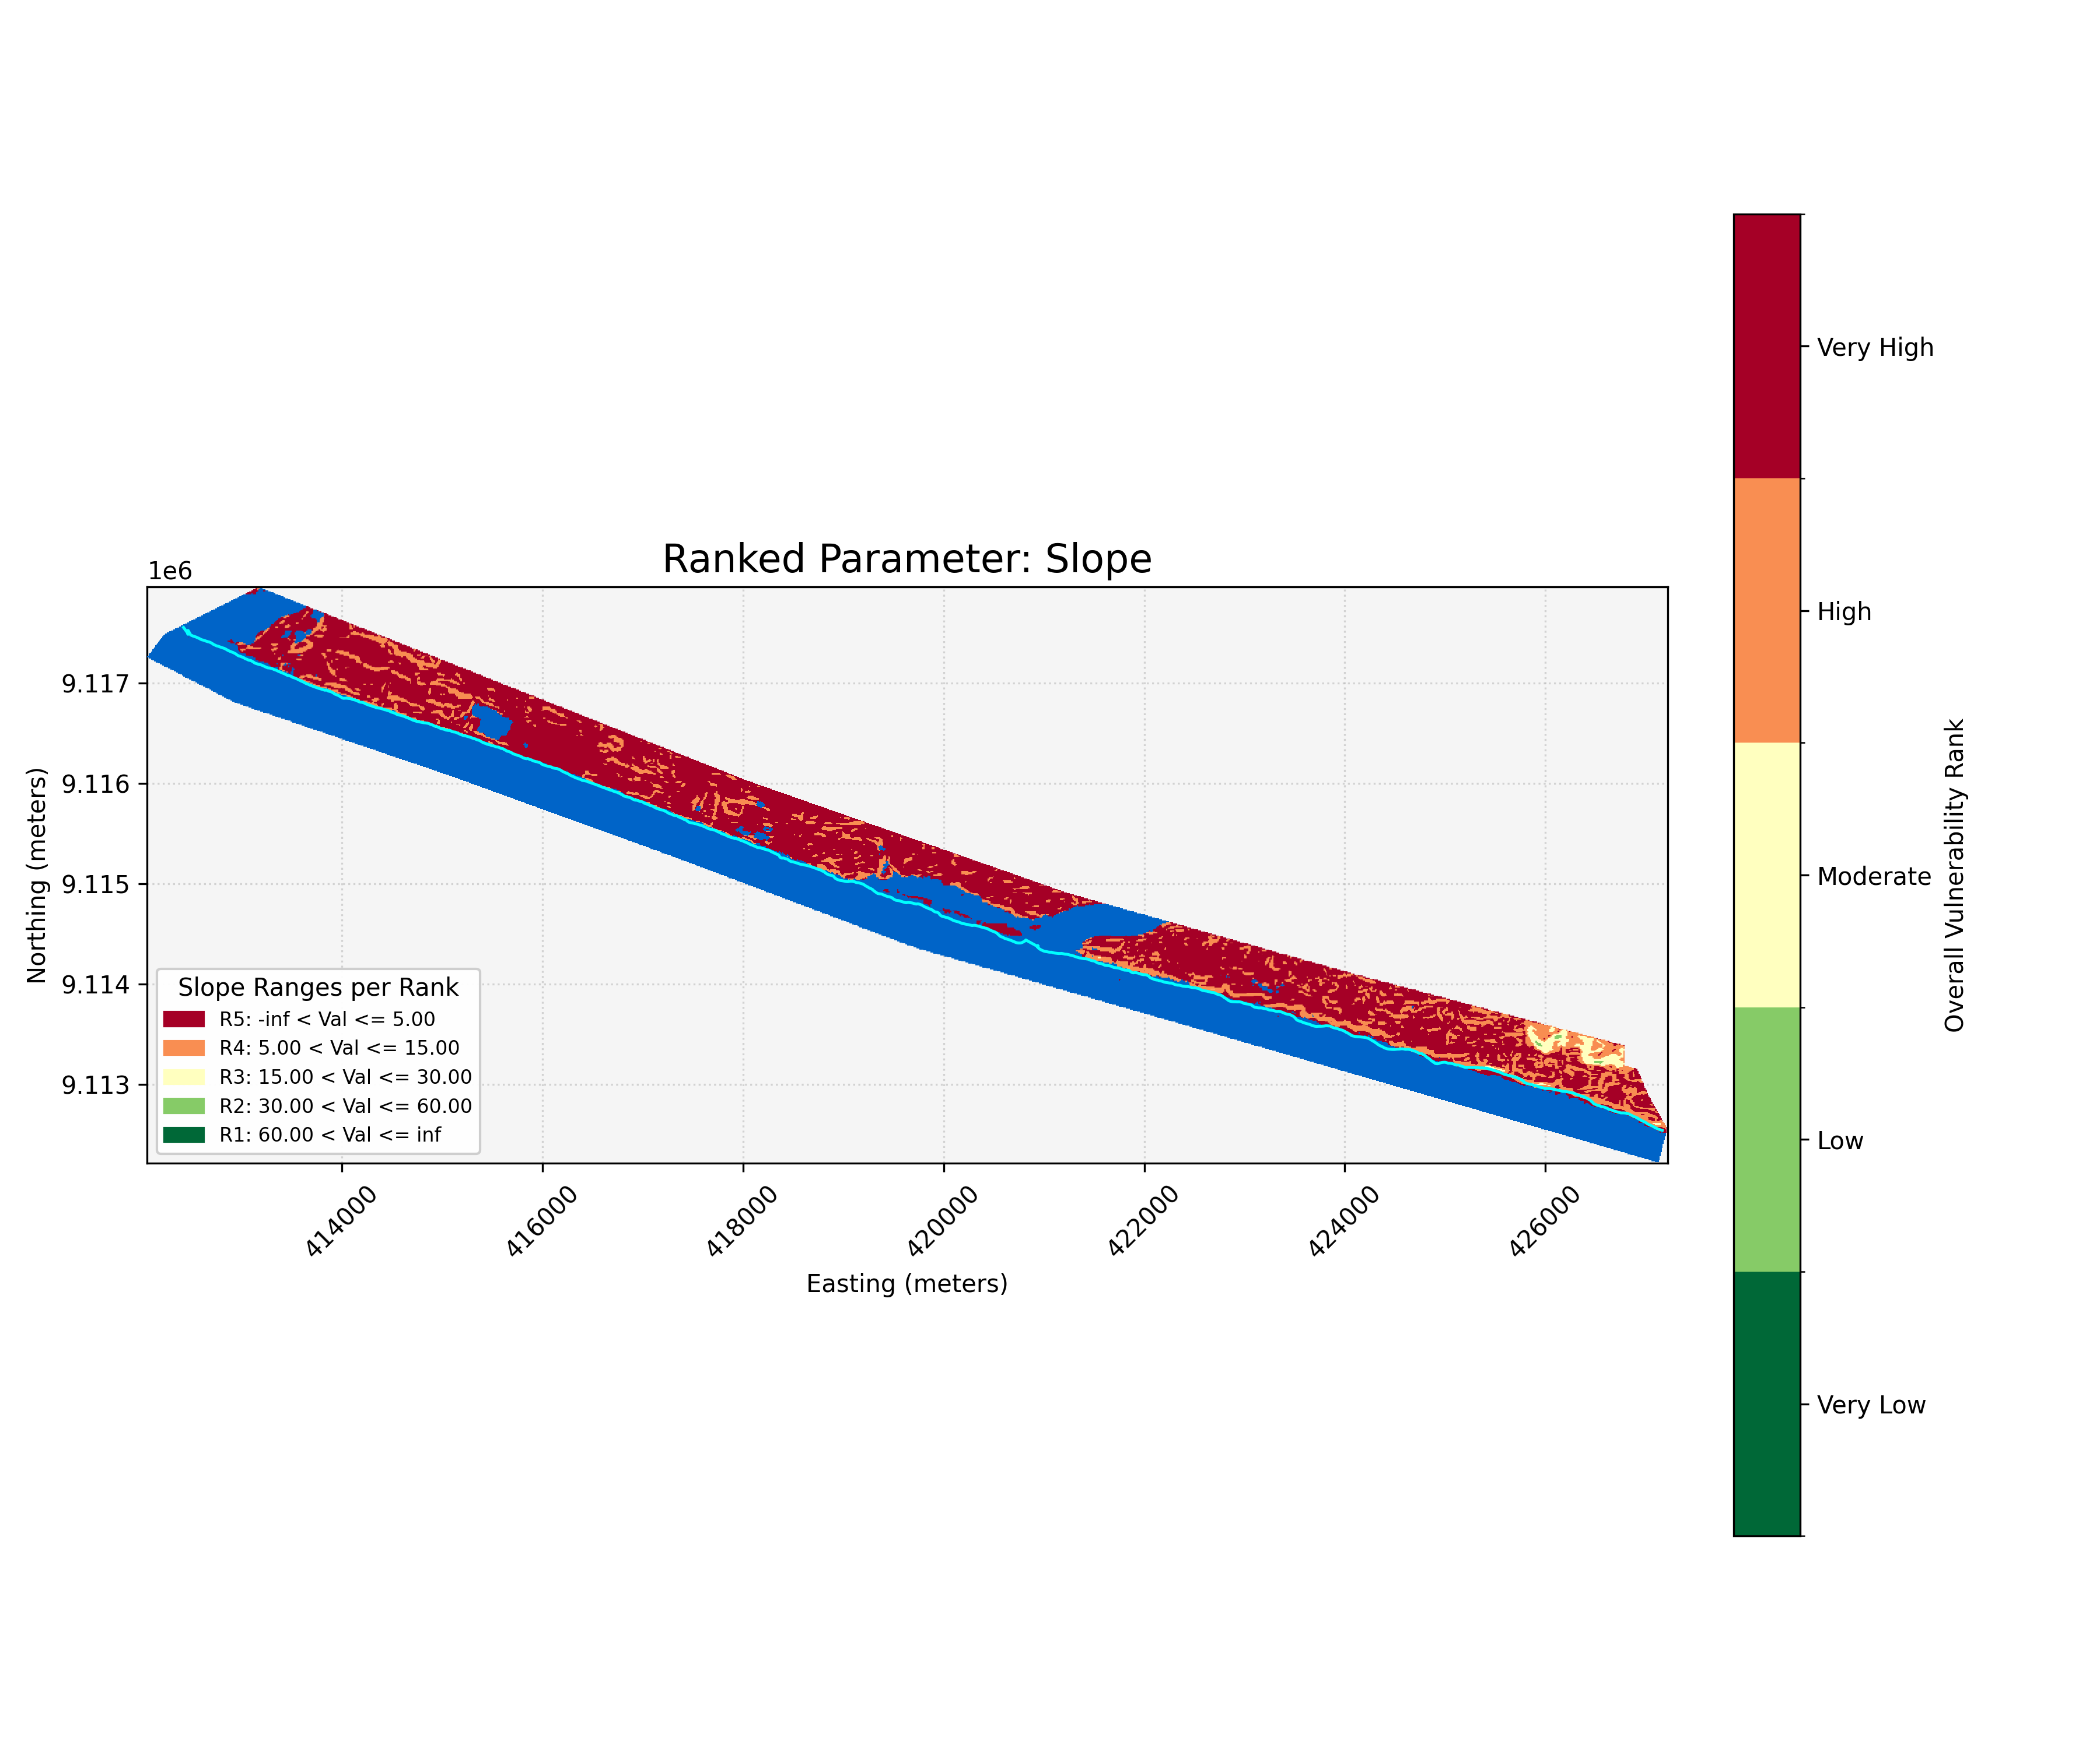


=== visualize_ranked_parameter: landcover ===
    'show_water_vulnerability' is False. Masking water bodies for 'landcover'.


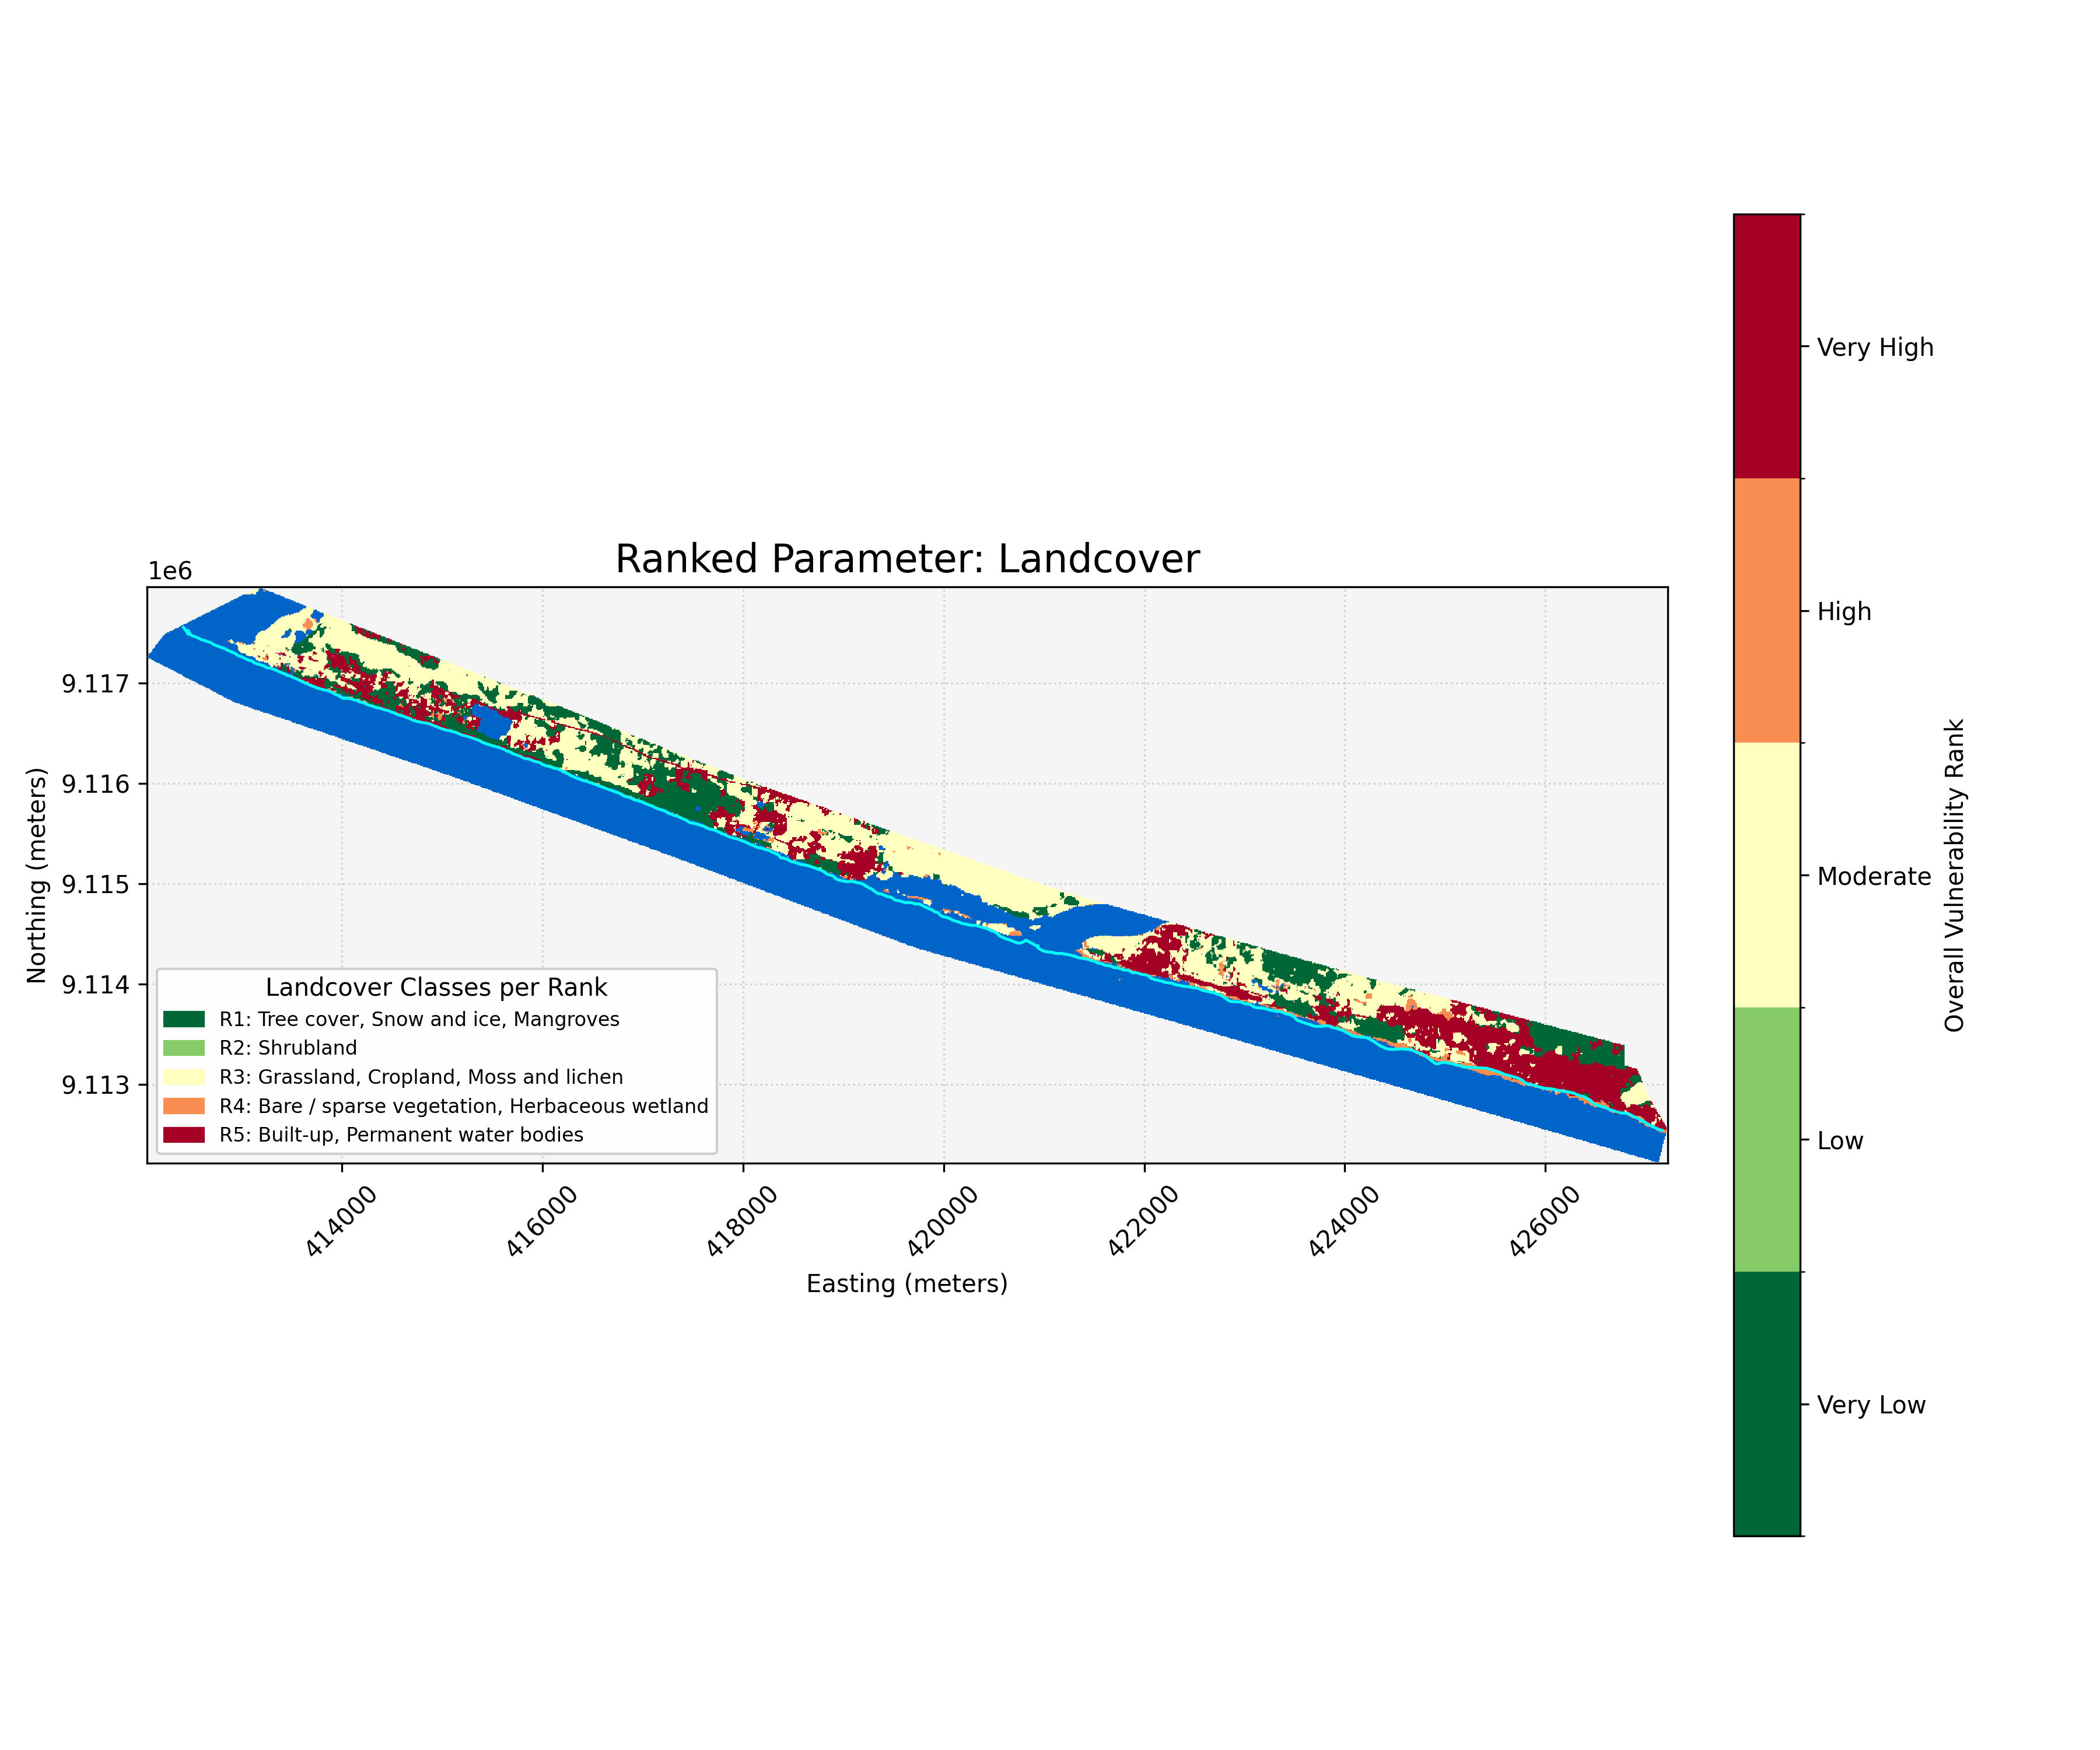


=== visualize_ranked_parameter: shoreline_change ===
    'show_water_vulnerability' is False. Masking water bodies for 'shoreline_change'.


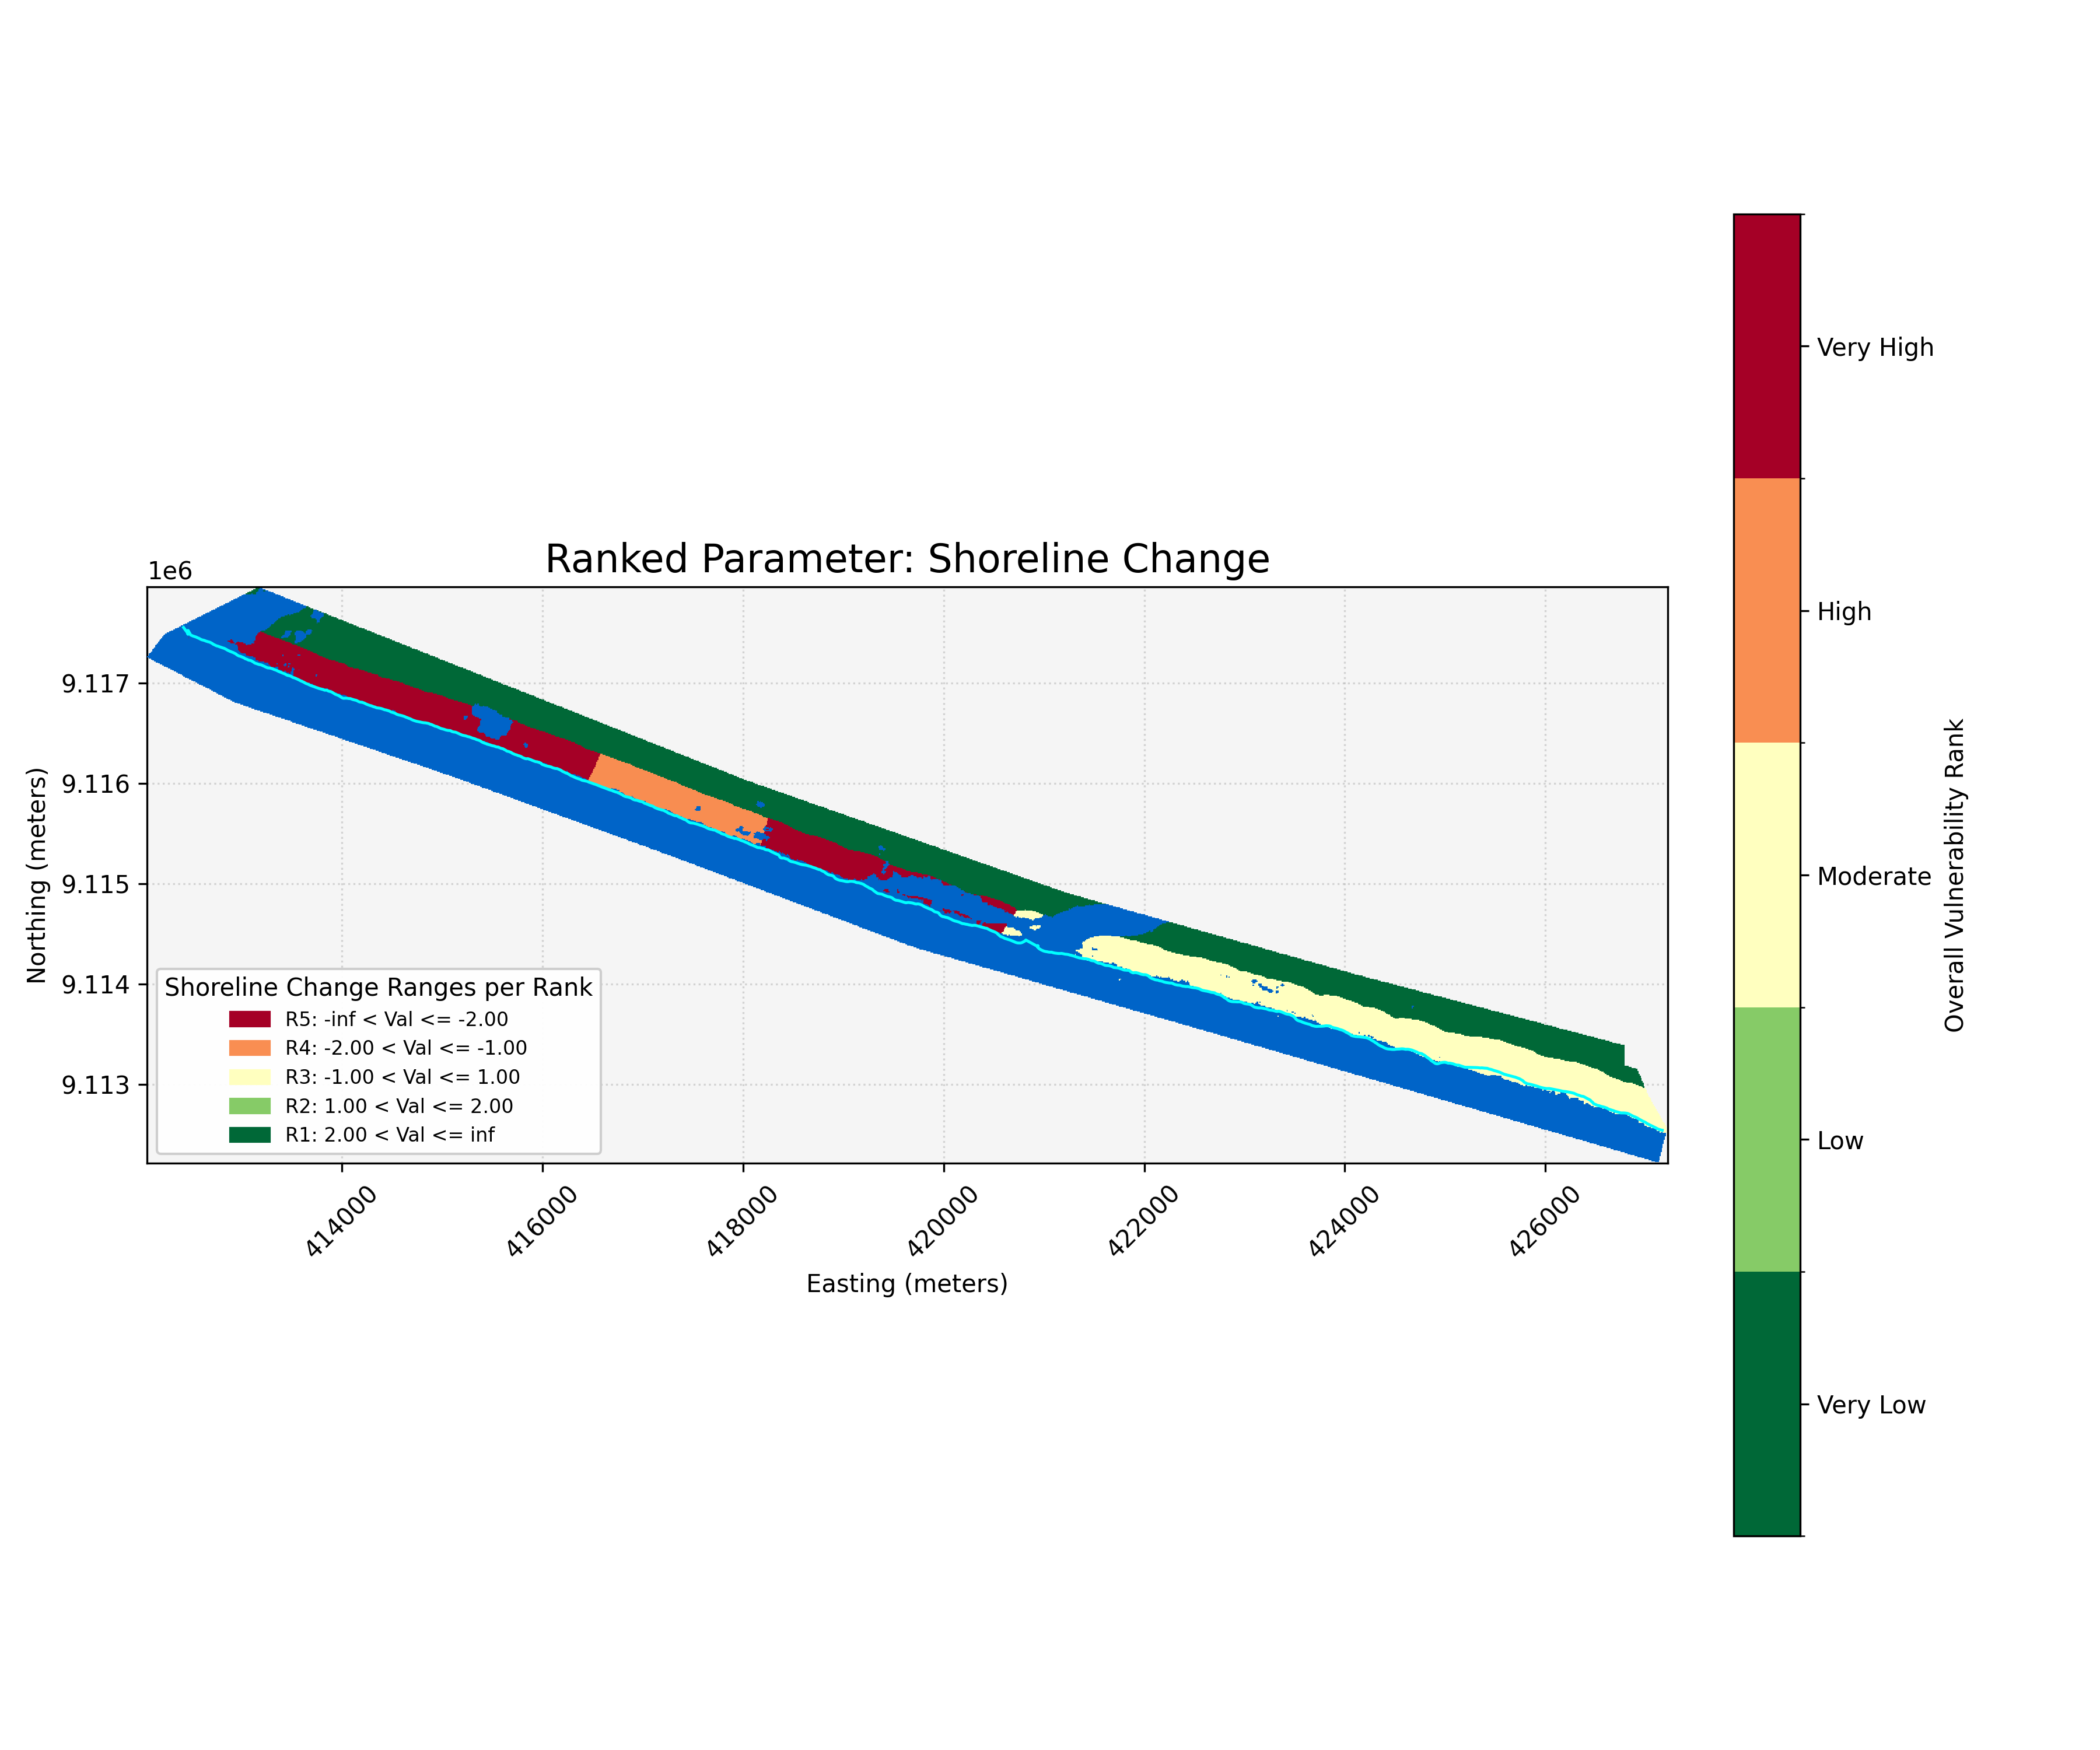


=== visualize_ranked_parameter: significant_wave_height ===
    'show_water_vulnerability' is True. Ranks will be shown over water for 'significant_wave_height'.


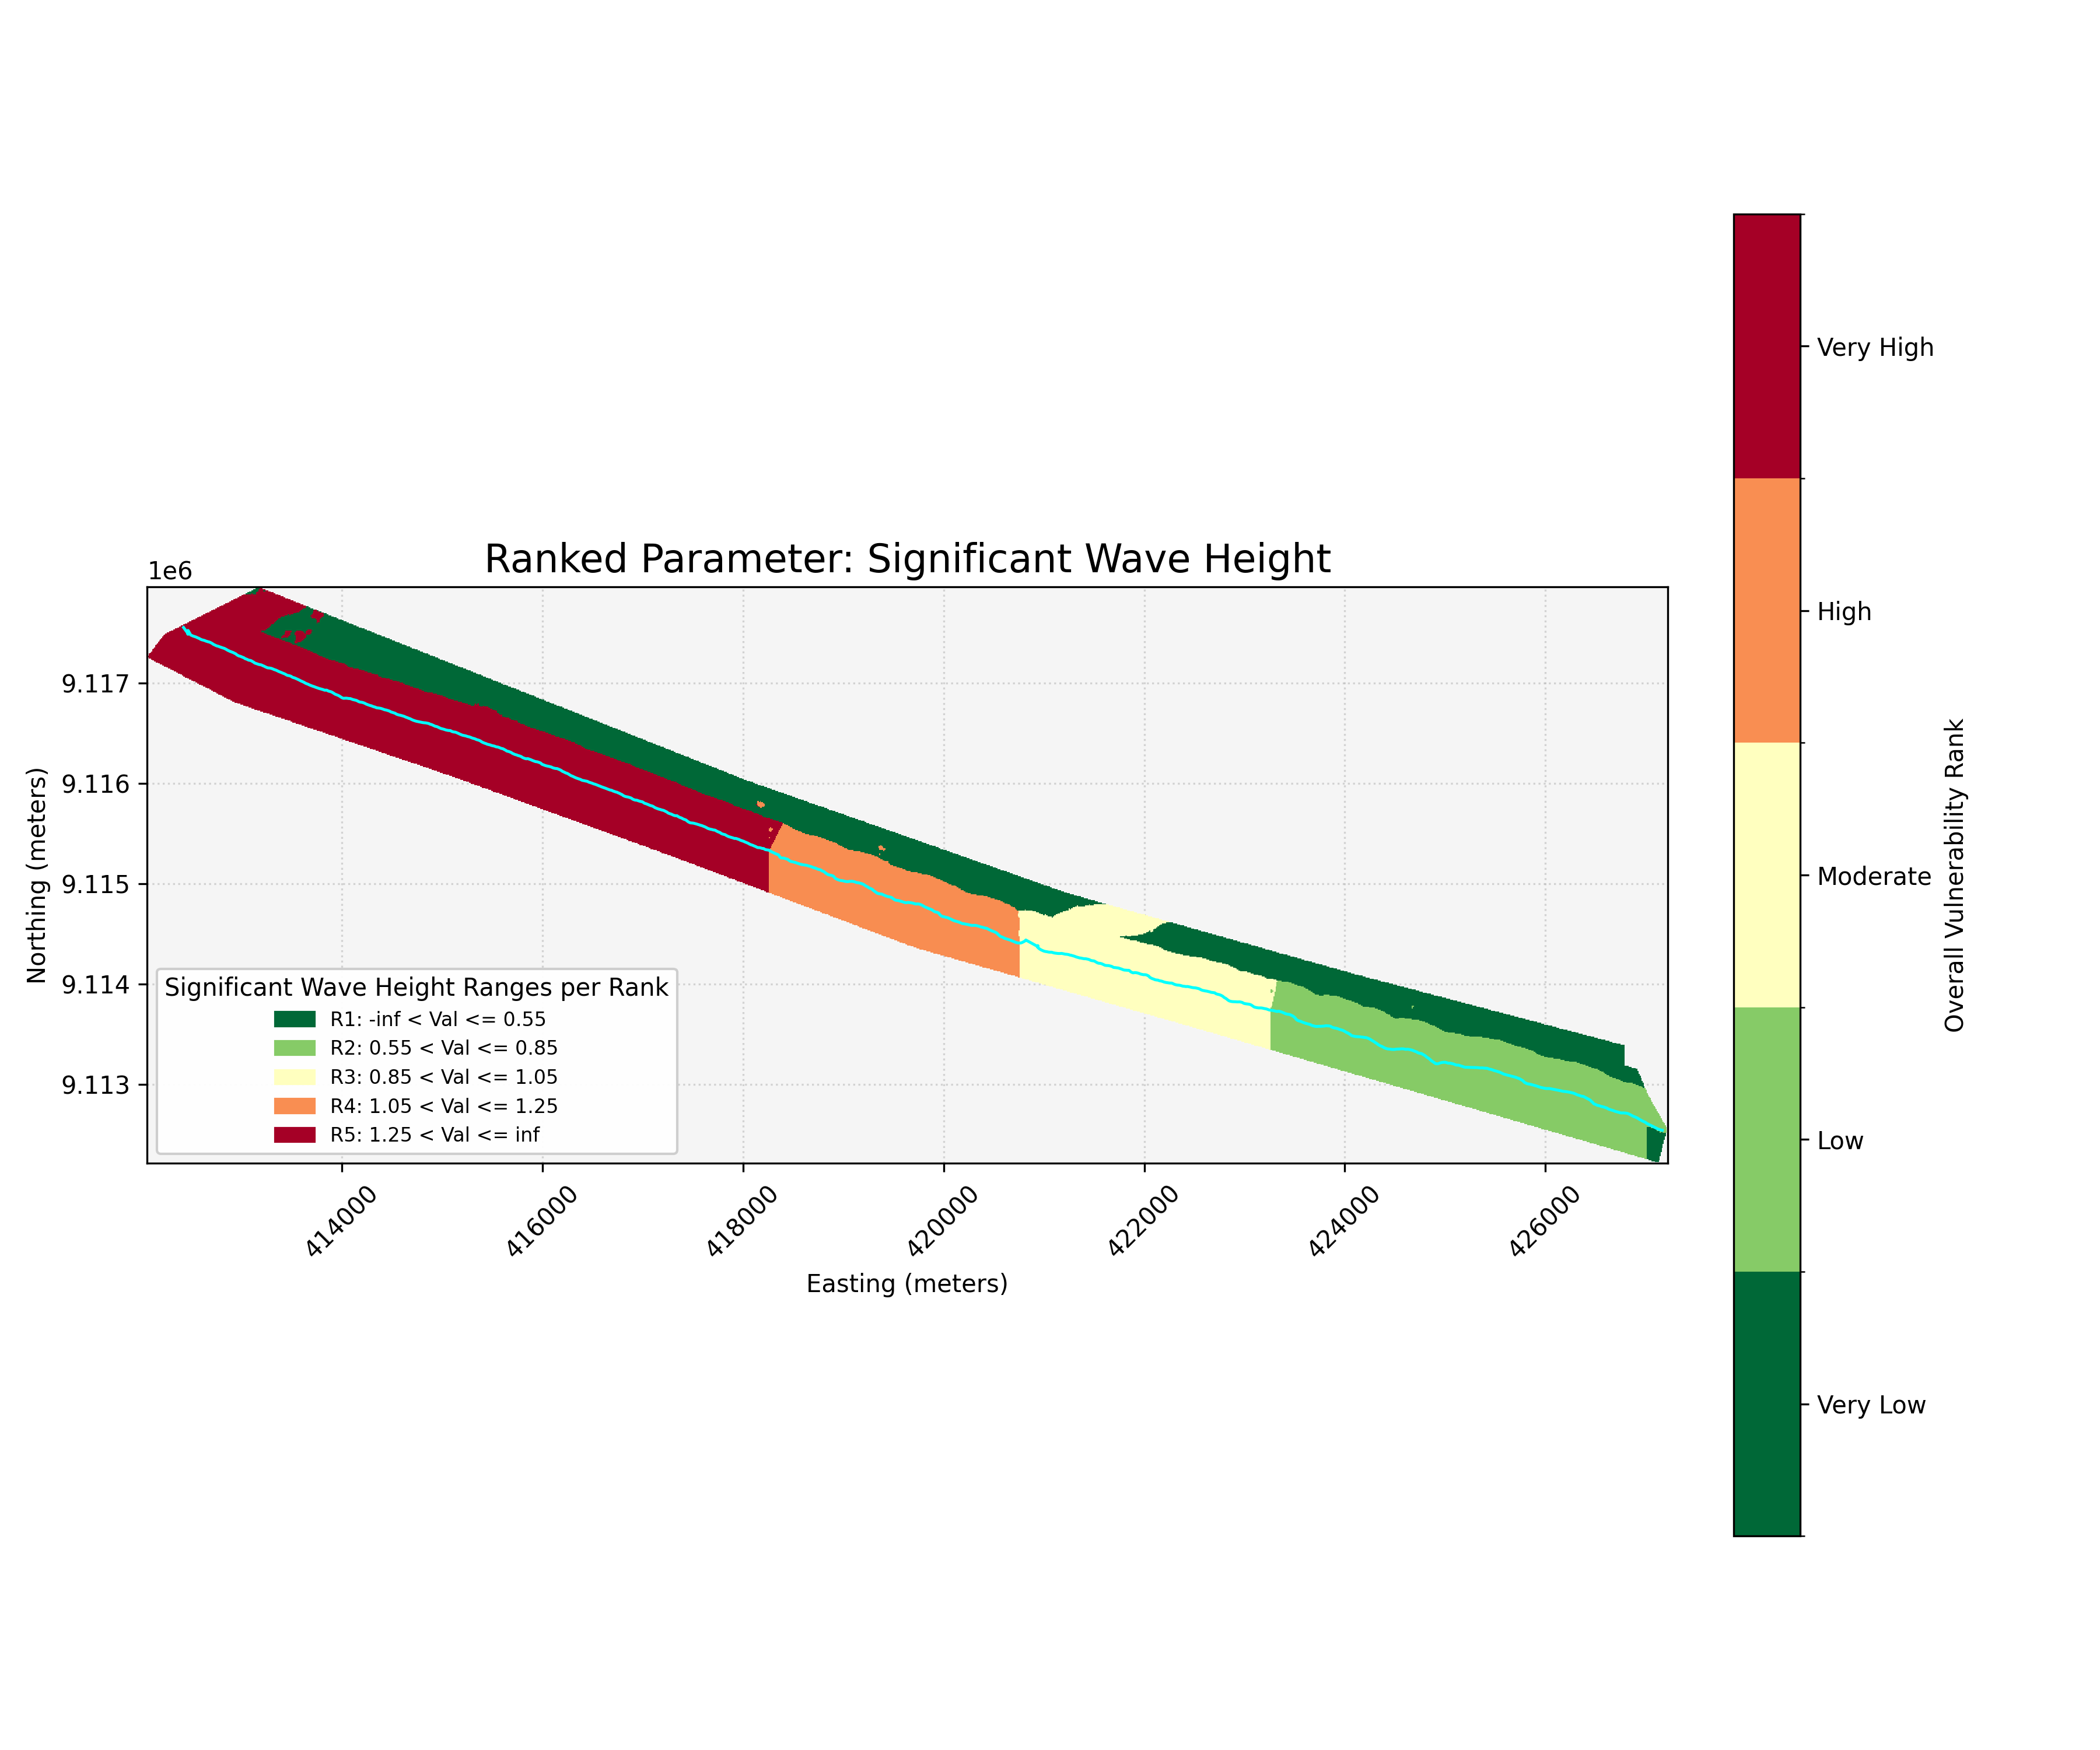


=== visualize_ranked_parameter: tidal_range ===
    'show_water_vulnerability' is True. Ranks will be shown over water for 'tidal_range'.


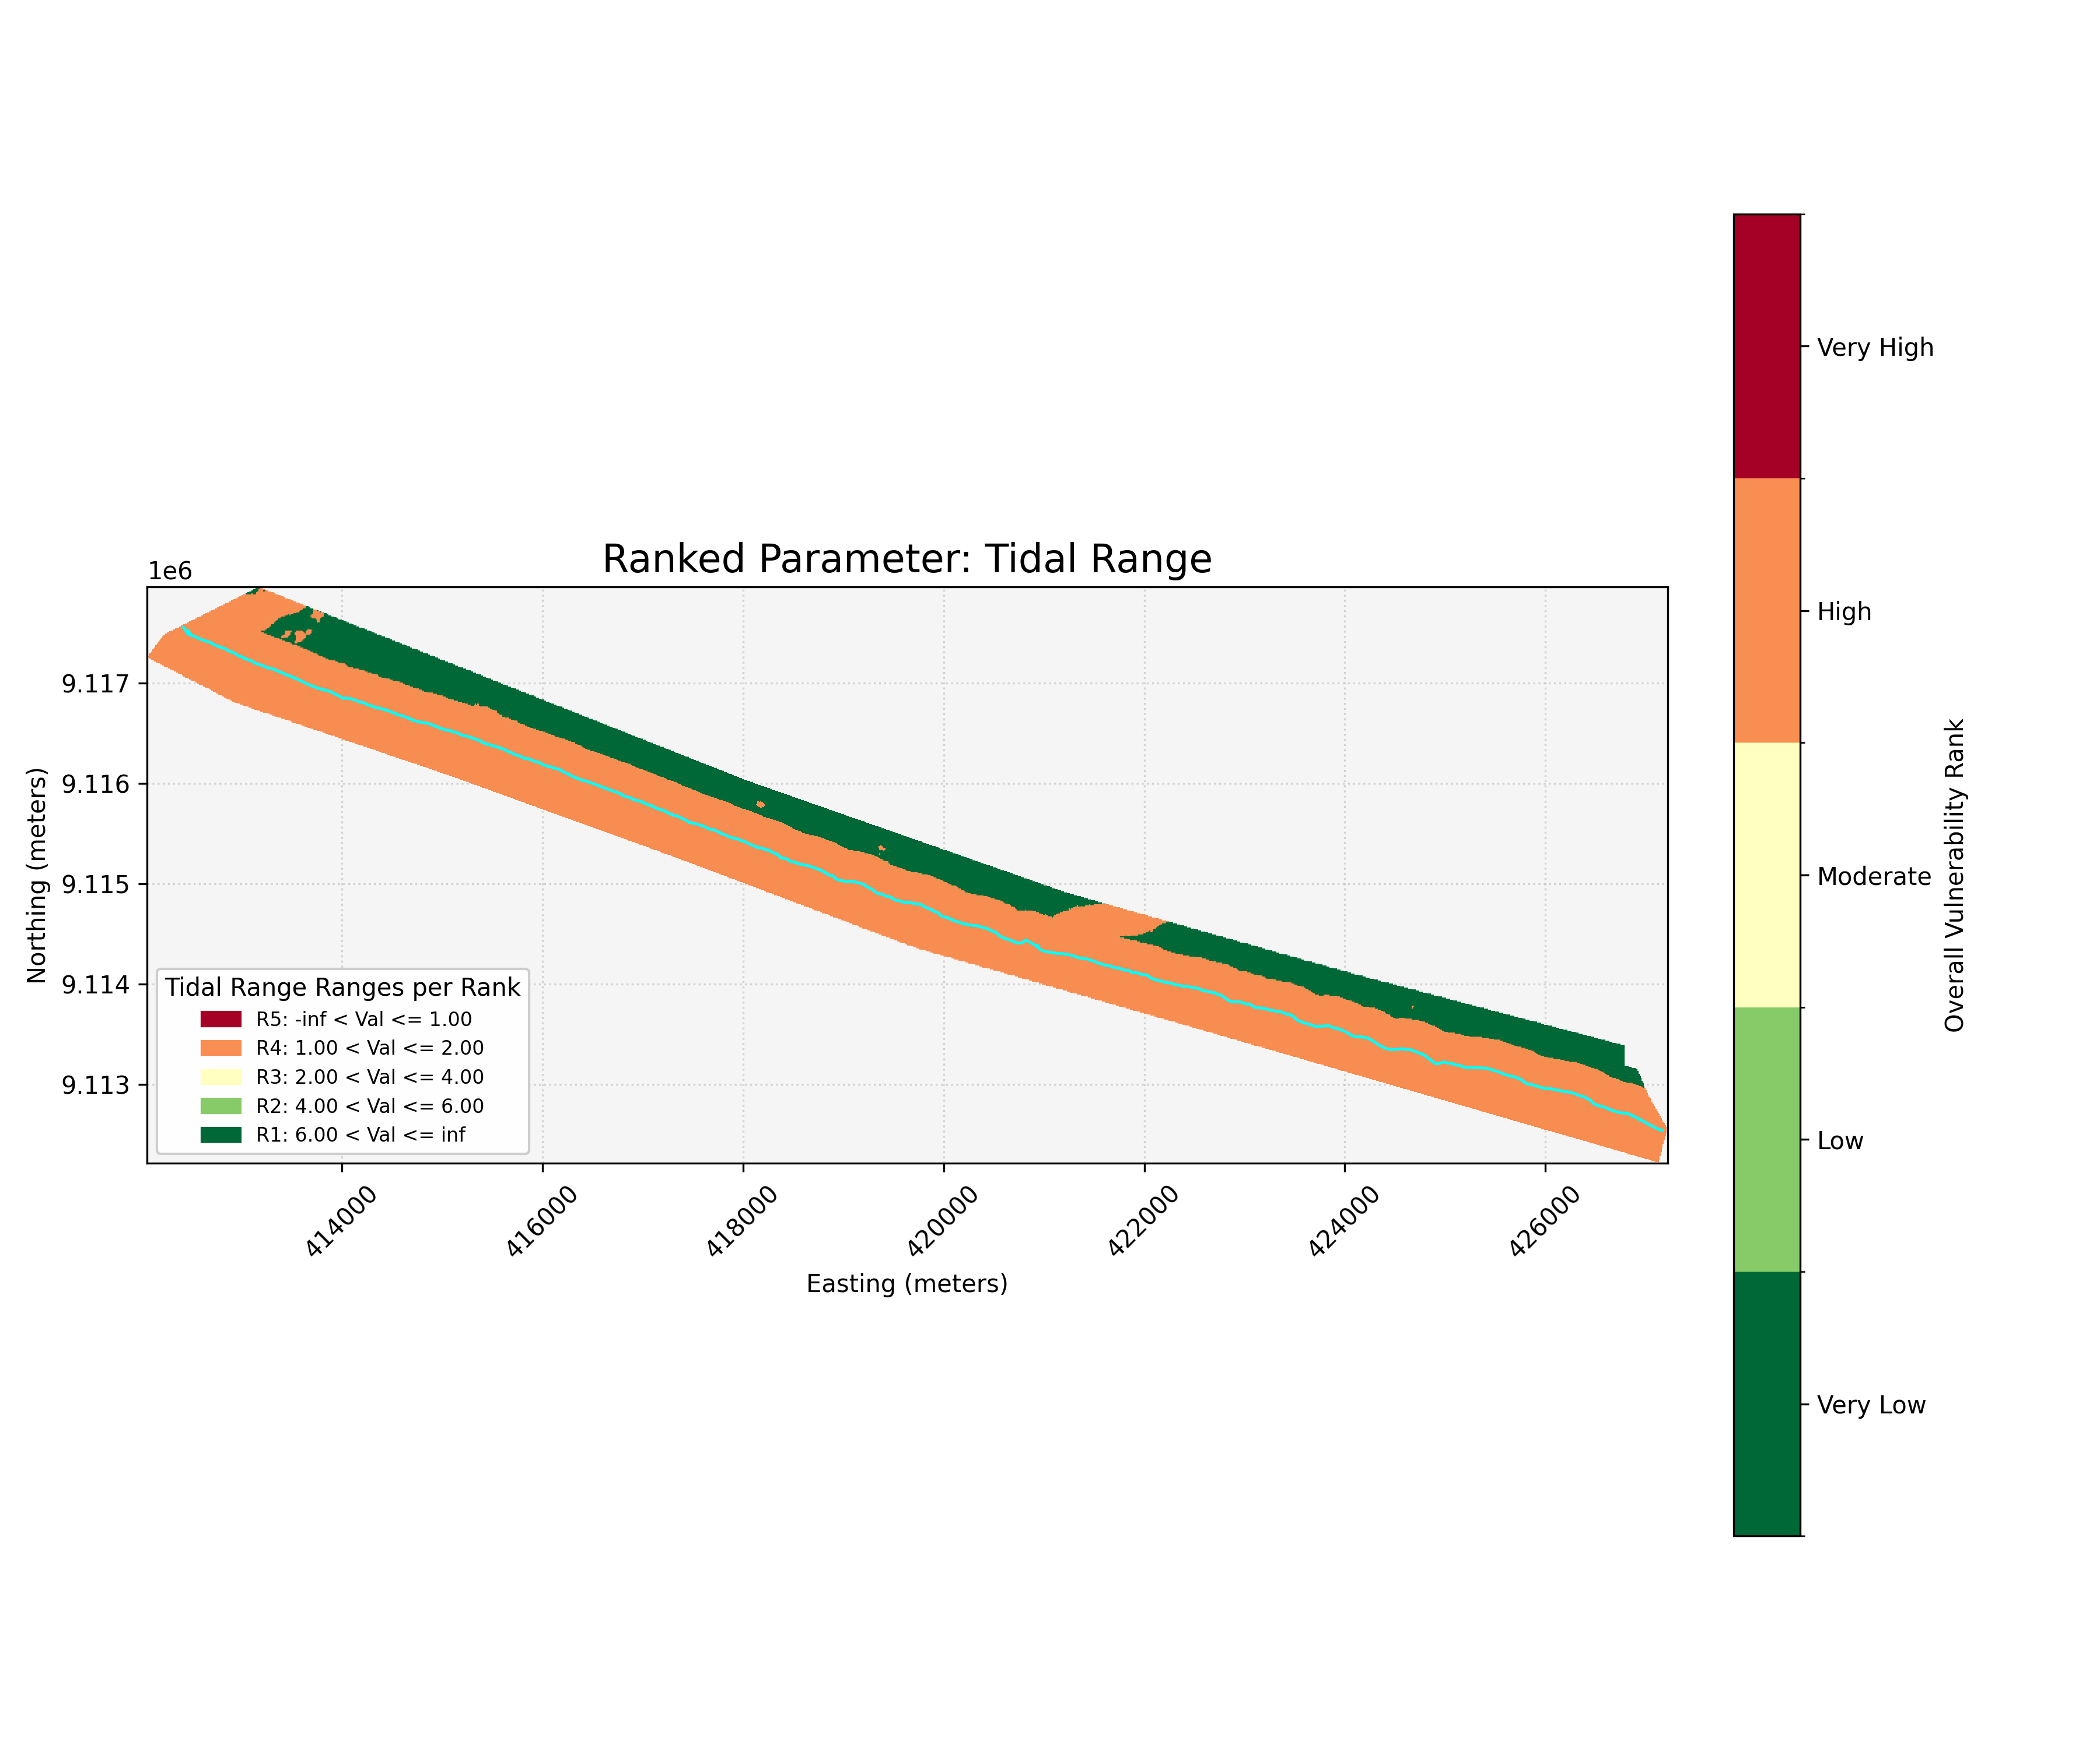


=== visualize_ranked_parameter: slr_rate ===
    'show_water_vulnerability' is True. Ranks will be shown over water for 'slr_rate'.


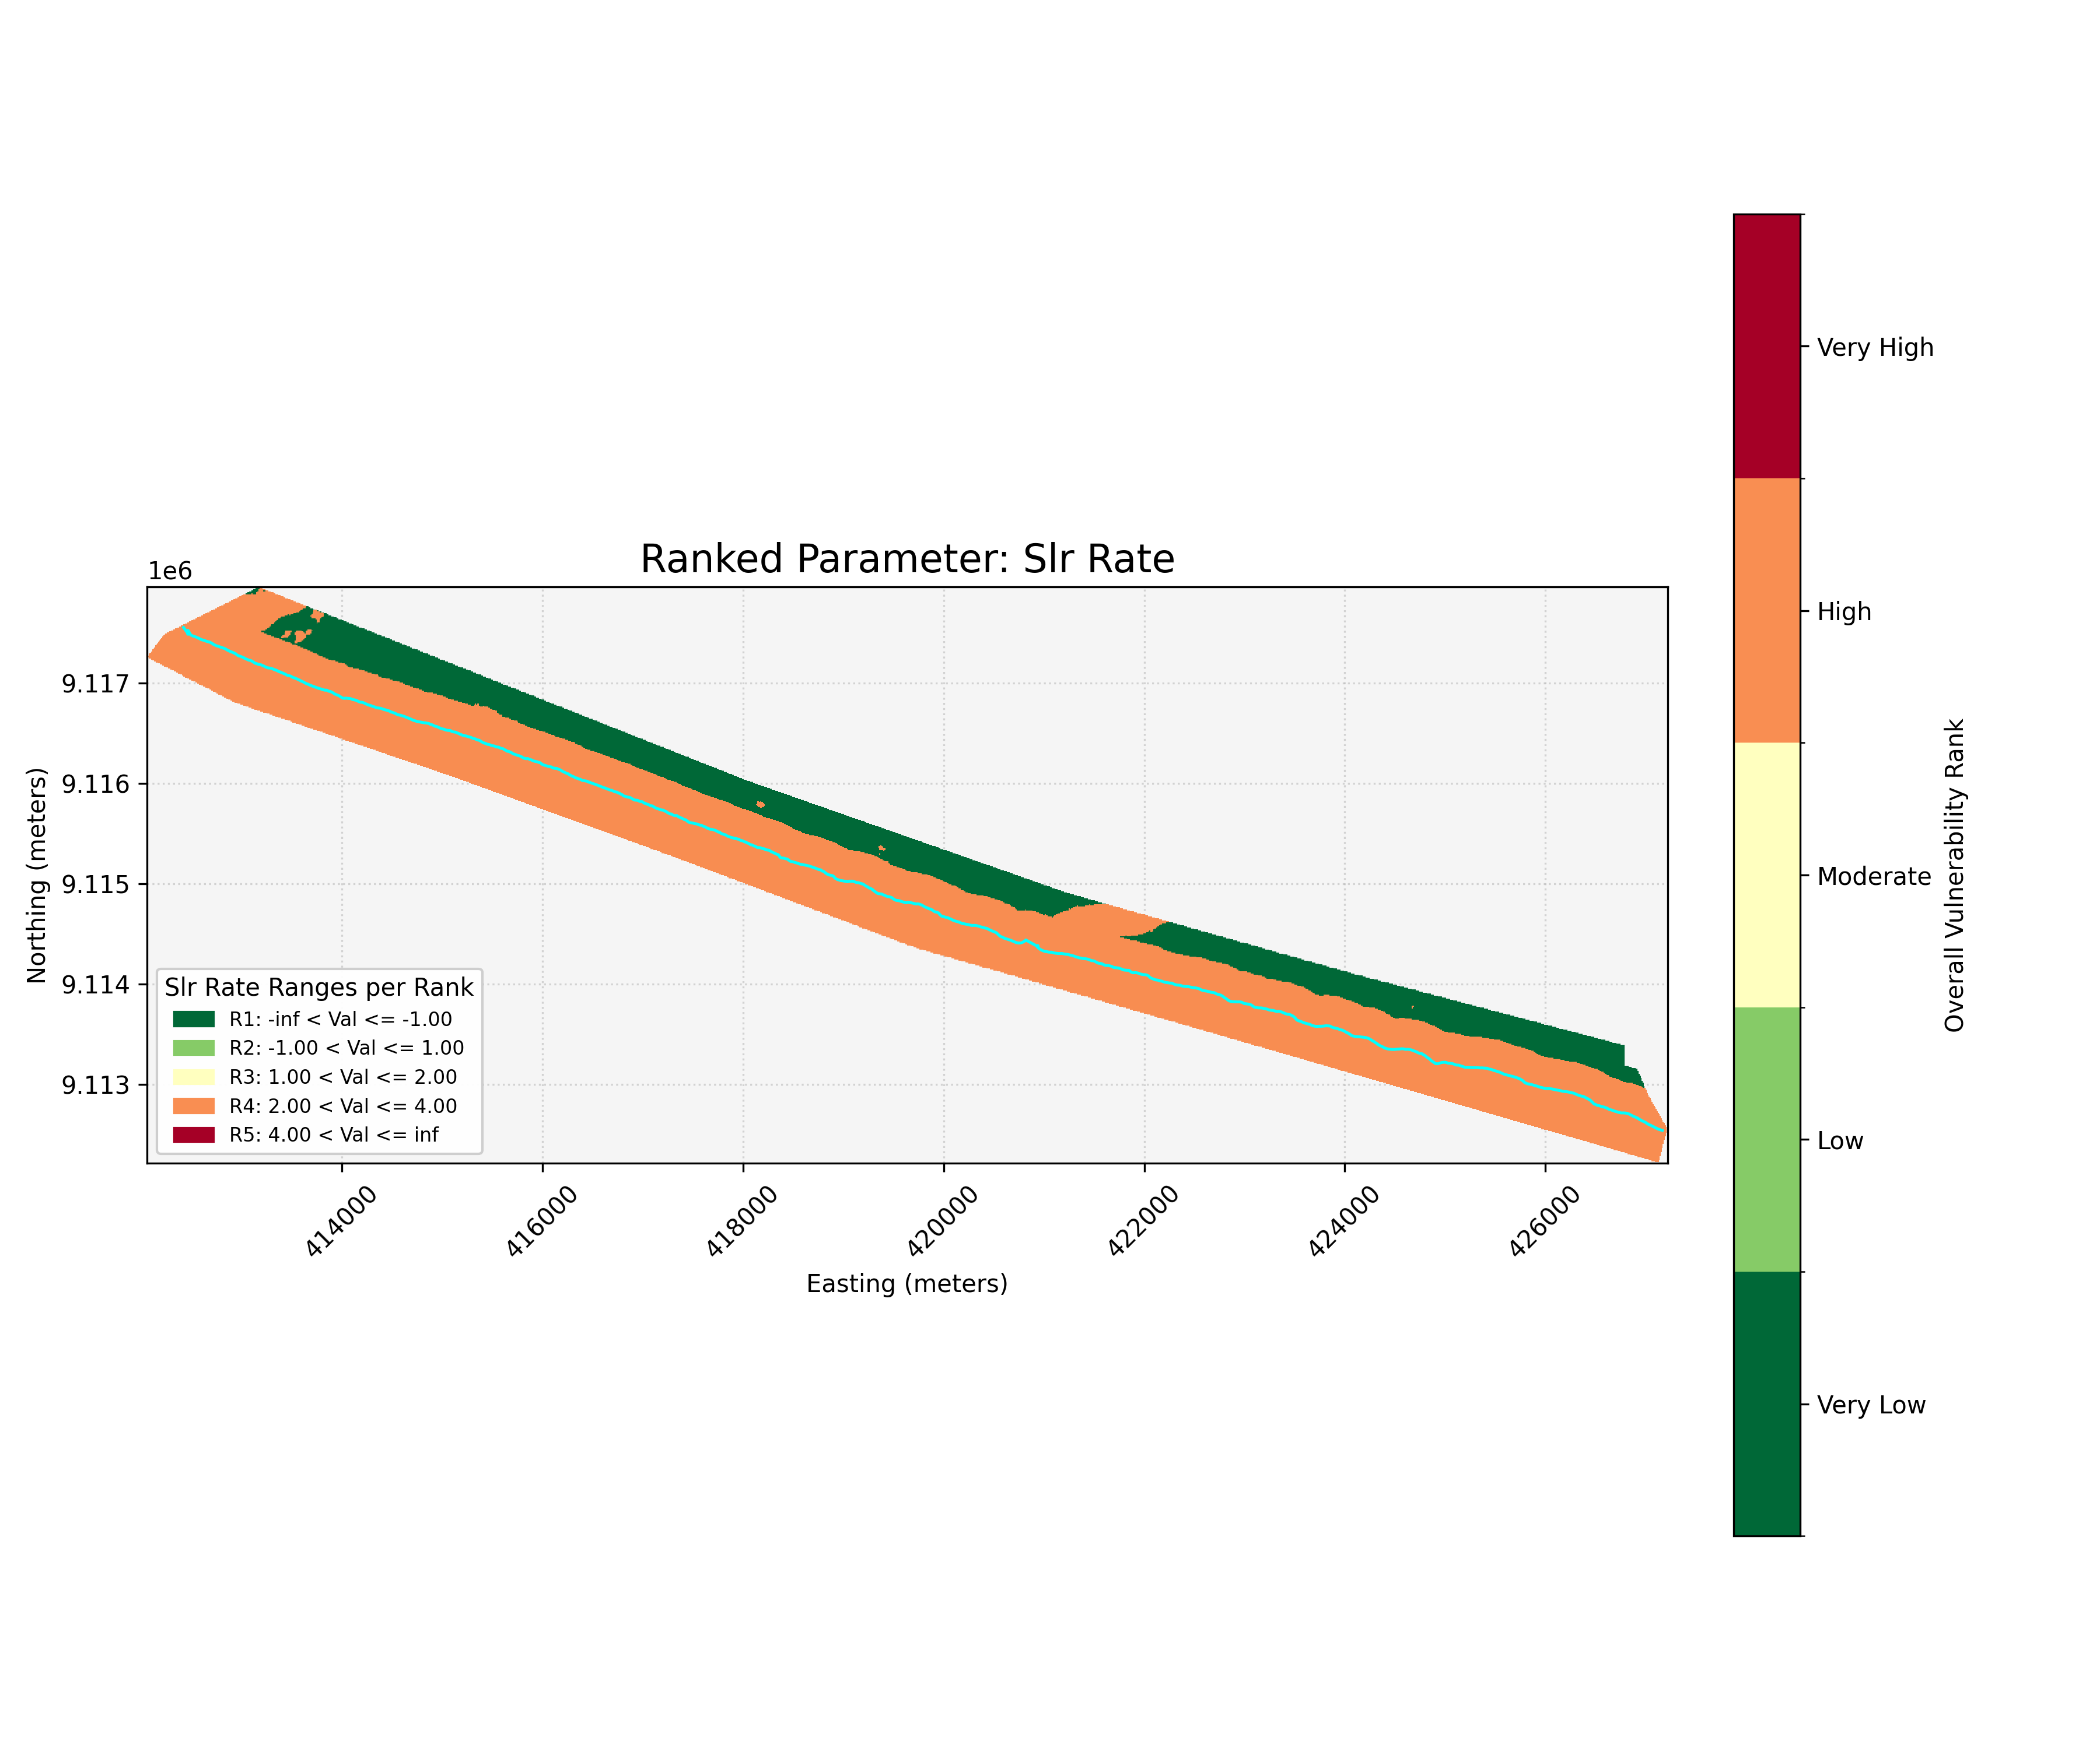


=== visualize_ranked_parameter: distance_to_shoreline ===
    'show_water_vulnerability' is False. Masking water bodies for 'distance_to_shoreline'.


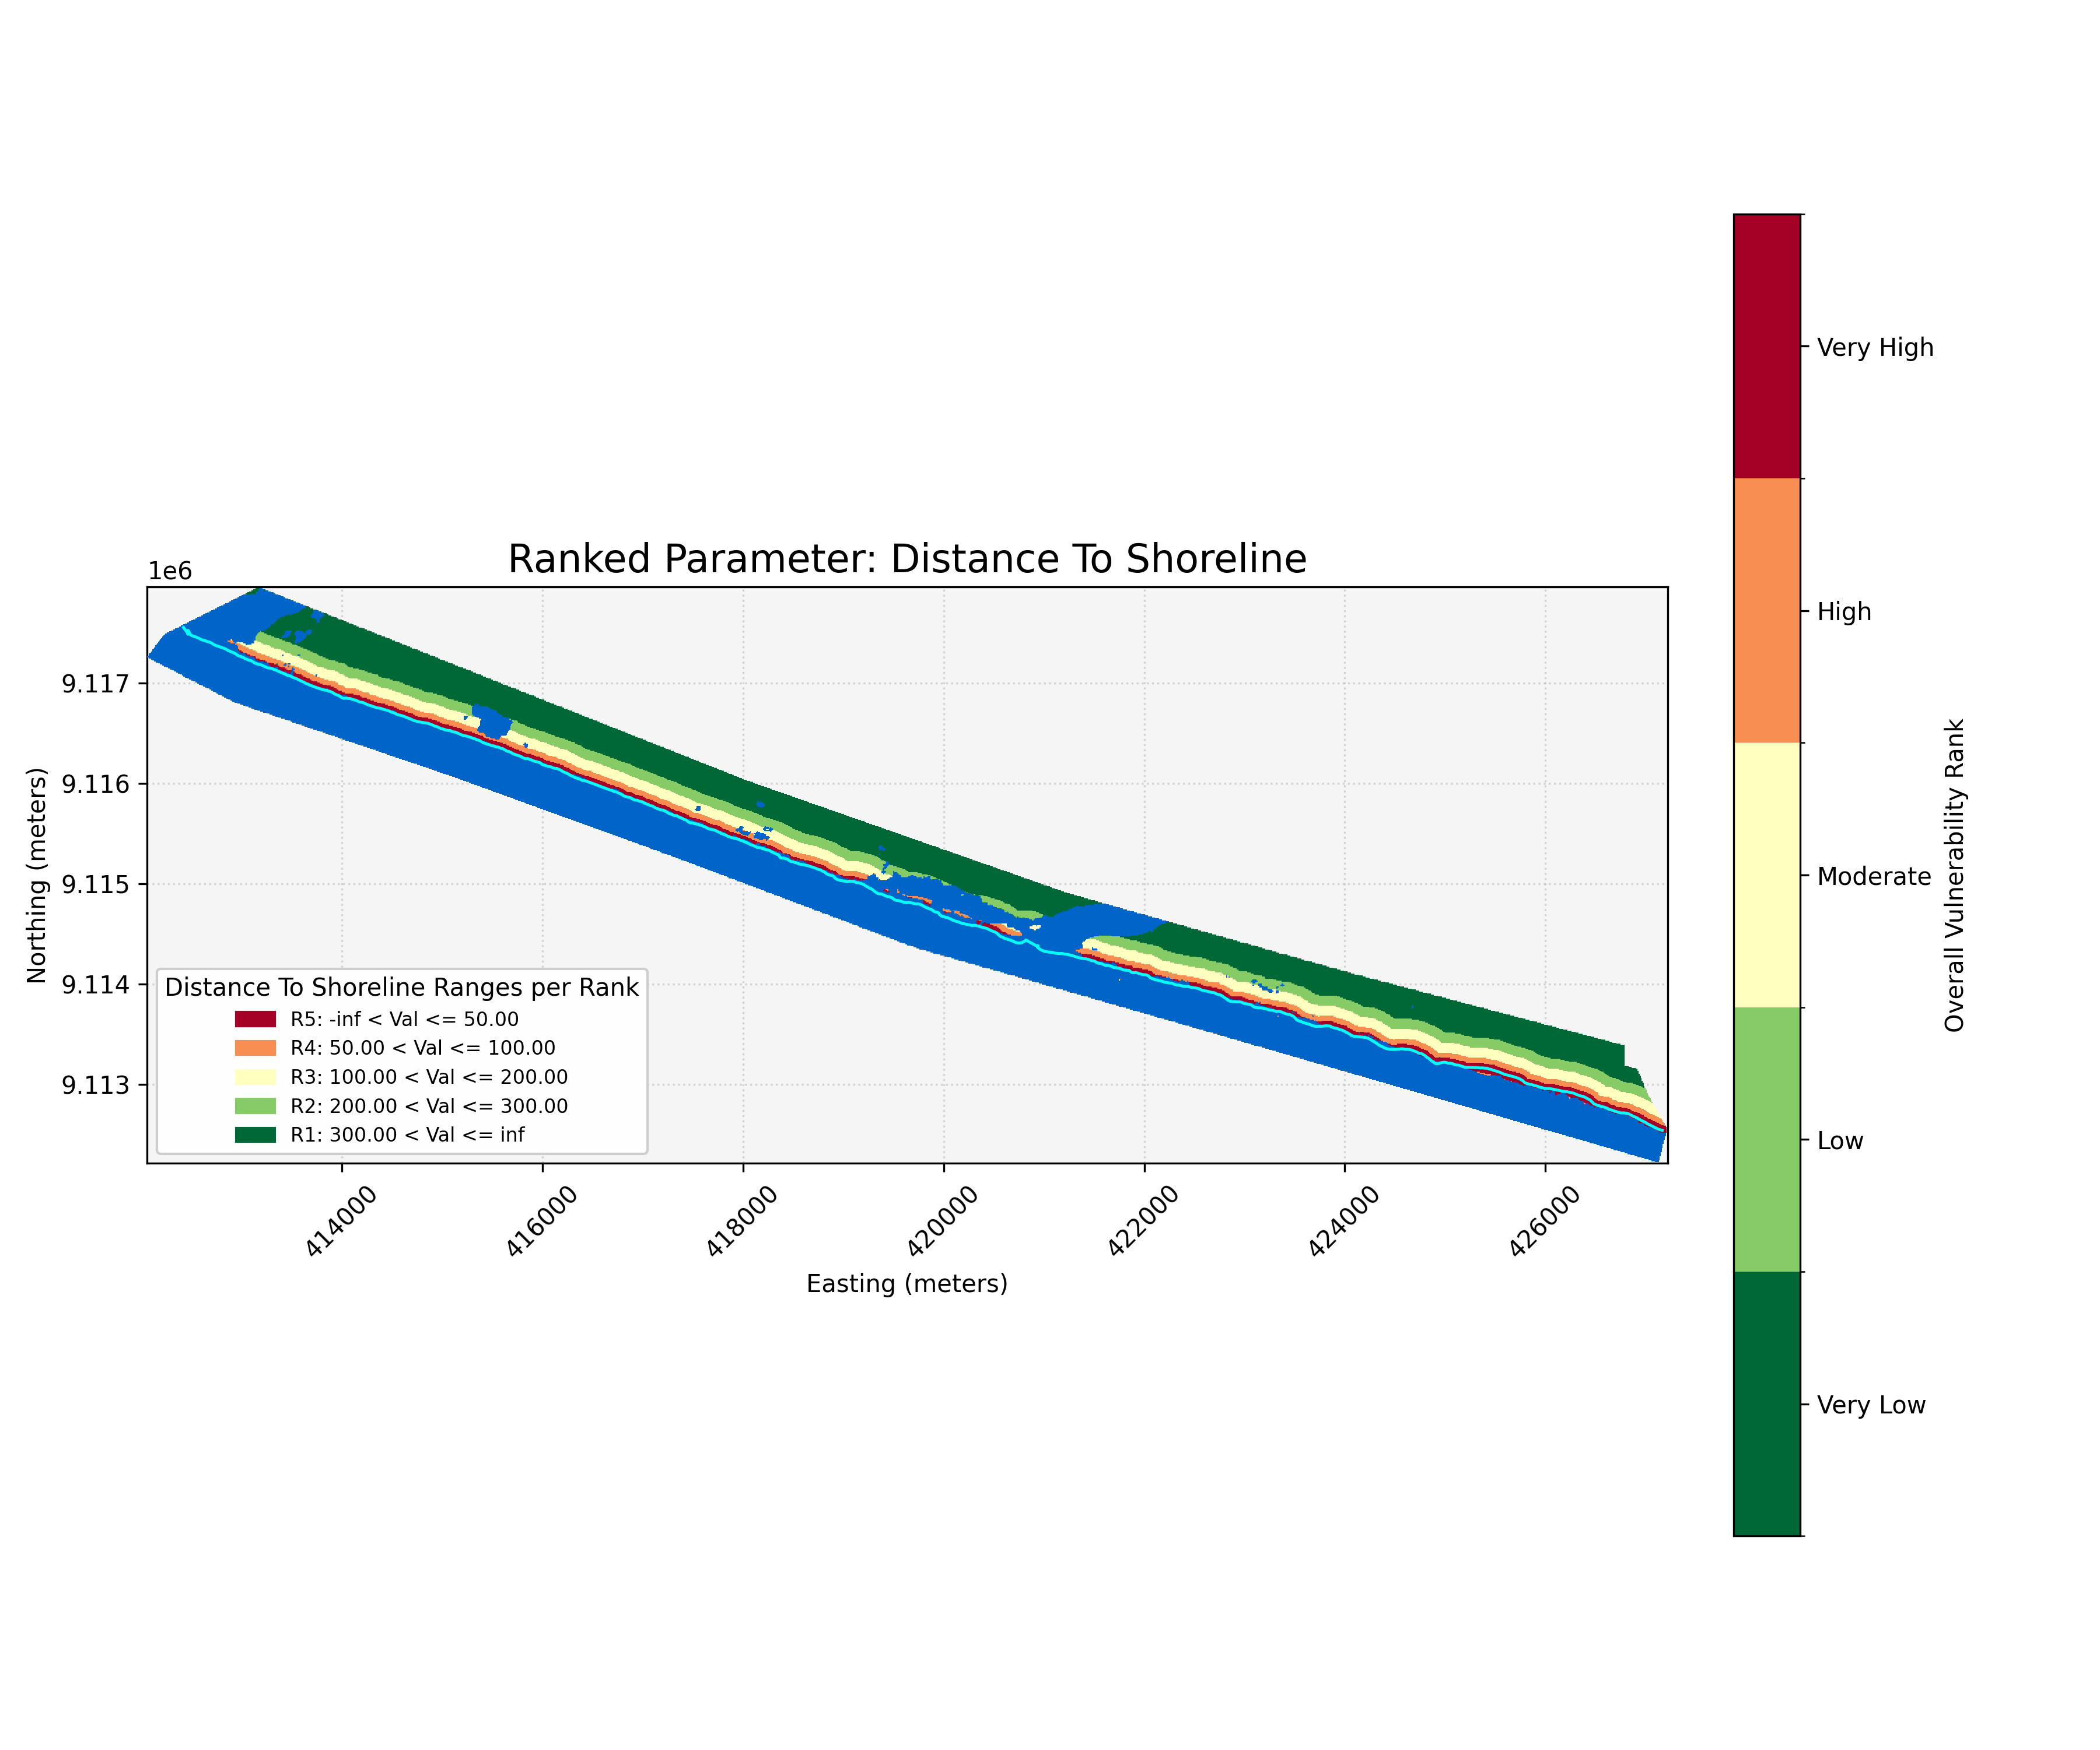


=== visualize_ranked_parameter: geomorphology ===
    'show_water_vulnerability' is False. Masking water bodies for 'geomorphology'.


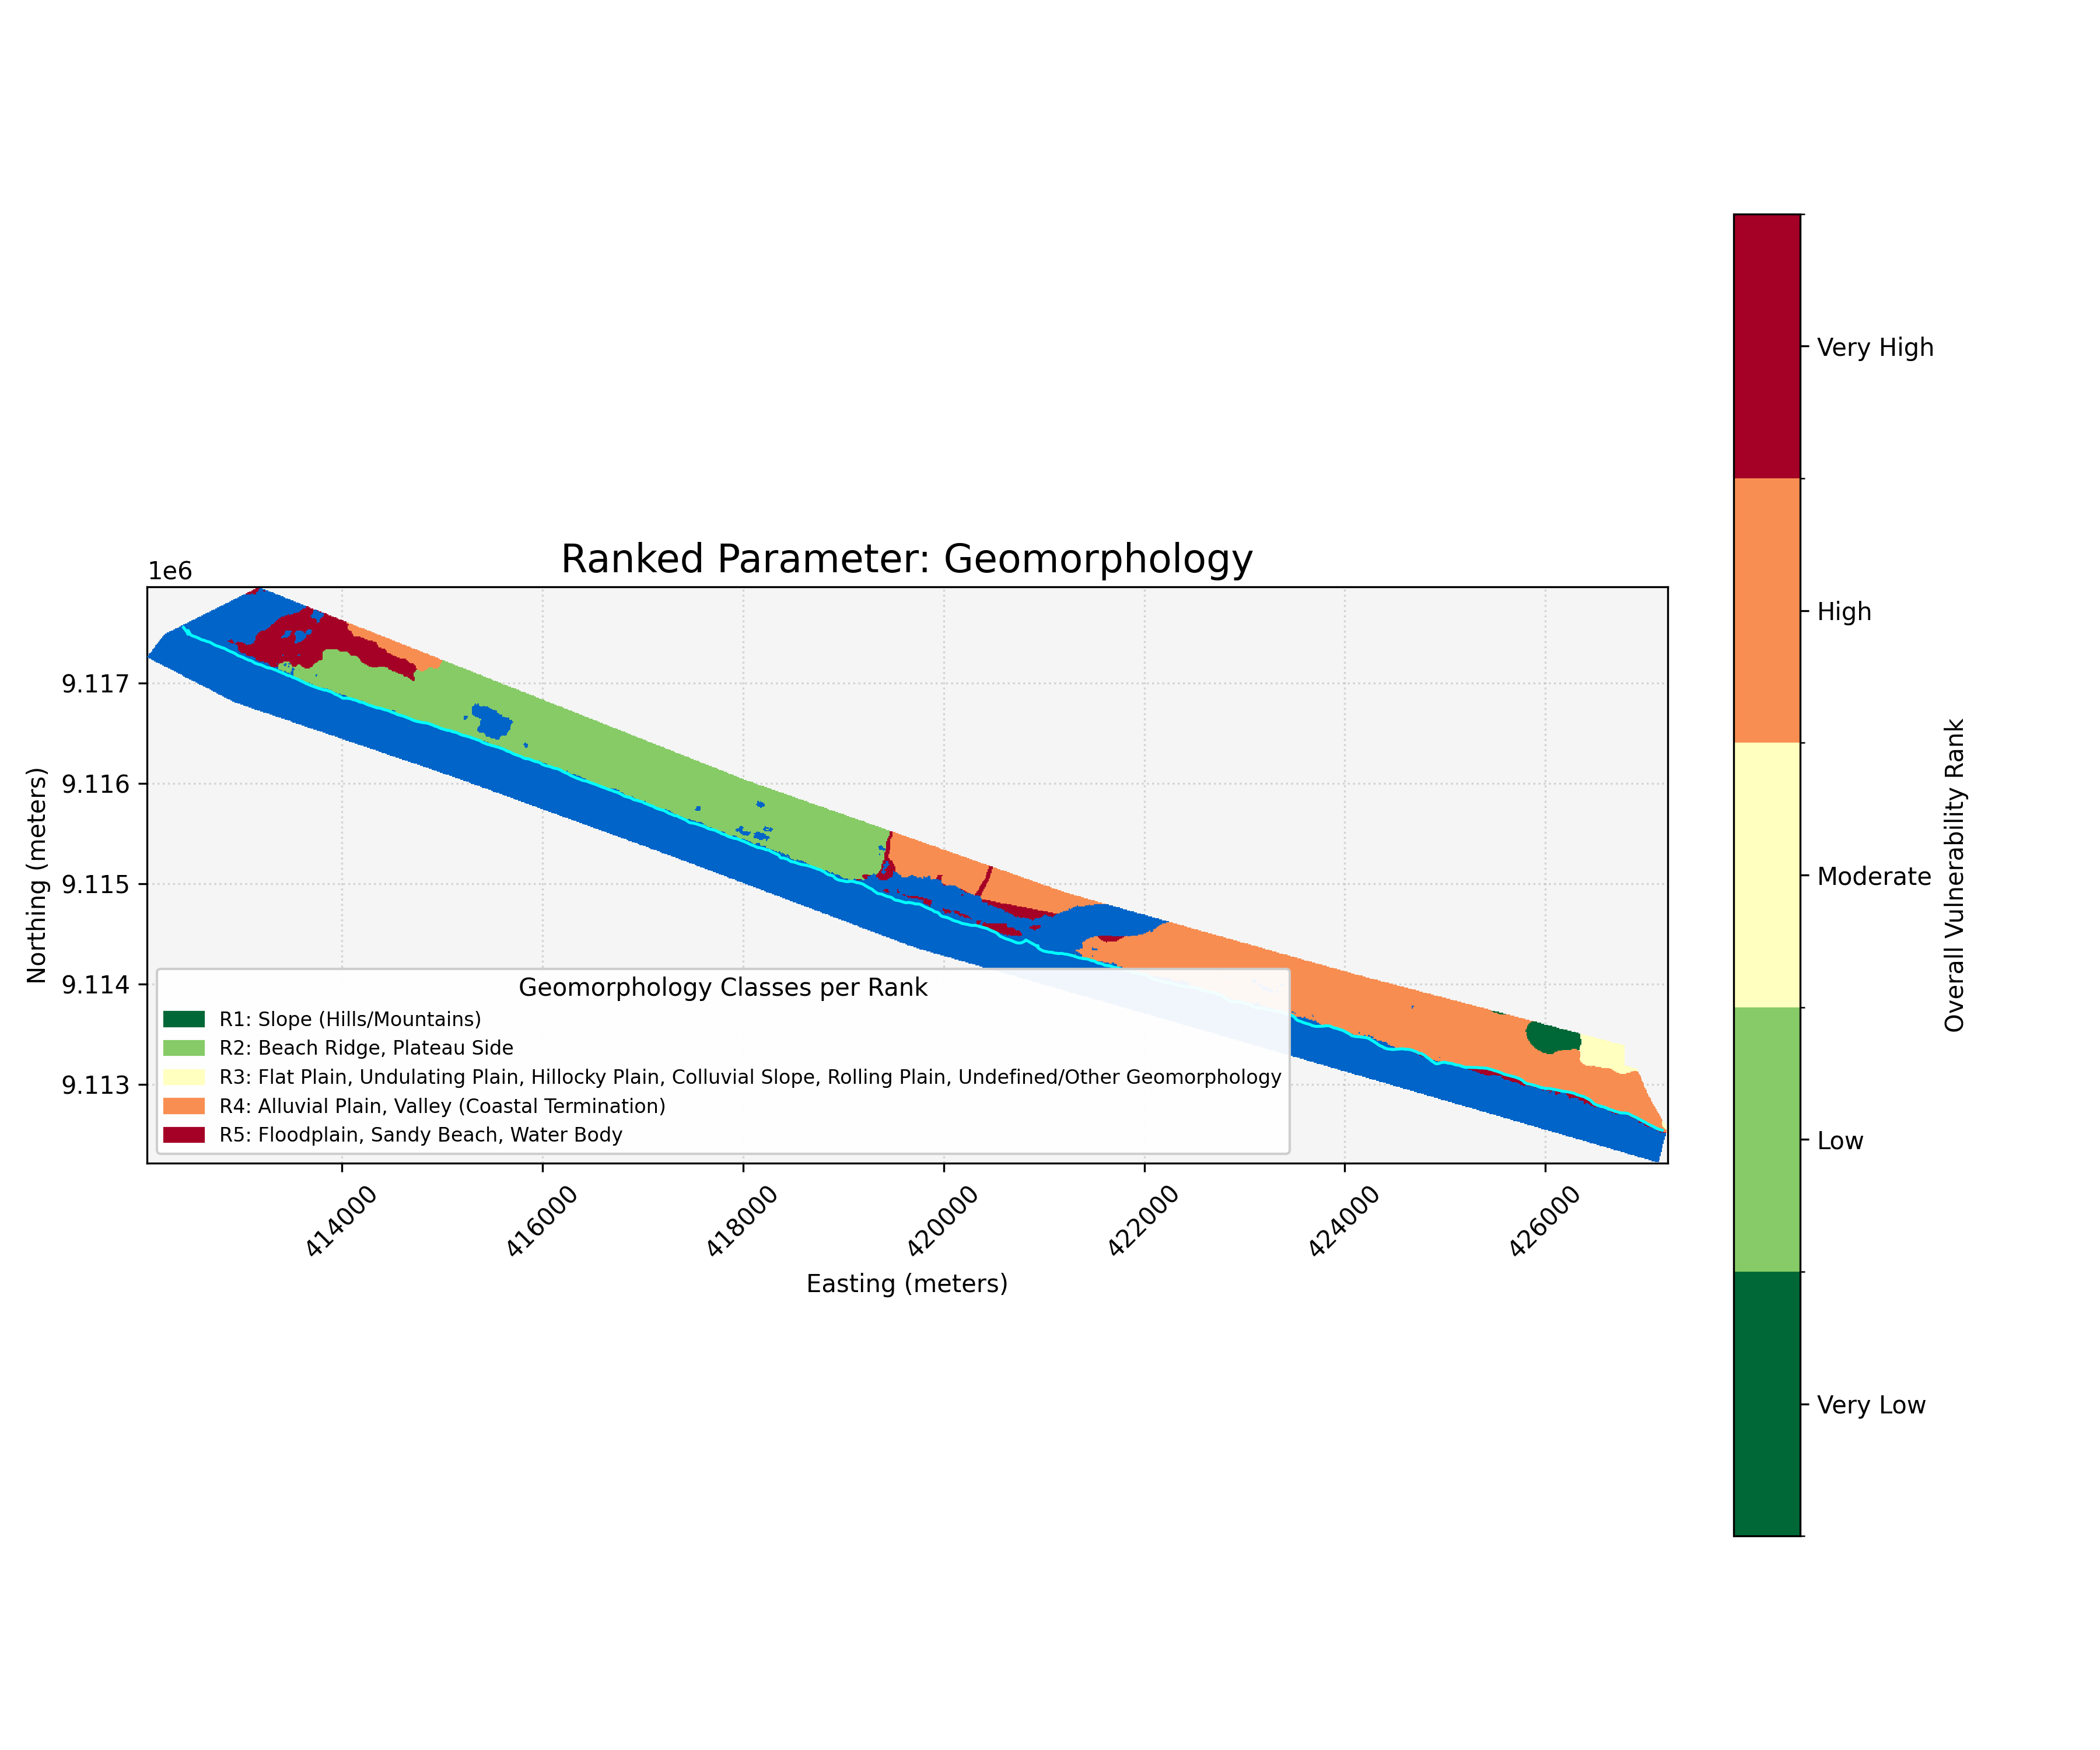


Aggregating ranks using 'equal' method...

Saving ranked data used for Traditional CVI calculation to CSV...
Successfully saved traditional CVI input data to: /content/drive/MyDrive/CCL_Bantul/data/processed/traditional_cvi_ranked_input.csv
DataFrame shape: (154221, 11)
DataFrame head:
          x          y  elevation  slope  landcover  shoreline_change  \
0  413165.0  9117945.0        5.0    5.0        3.0               1.0   
1  413175.0  9117945.0        5.0    5.0        3.0               1.0   
2  413185.0  9117945.0        5.0    5.0        3.0               1.0   
3  413145.0  9117935.0        5.0    5.0        3.0               1.0   
4  413155.0  9117935.0        5.0    5.0        3.0               1.0   

   significant_wave_height  tidal_range  slr_rate  distance_to_shoreline  \
0                      1.0          1.0       1.0                    1.0   
1                      1.0          1.0       1.0                    1.0   
2                      1.0          1.0      

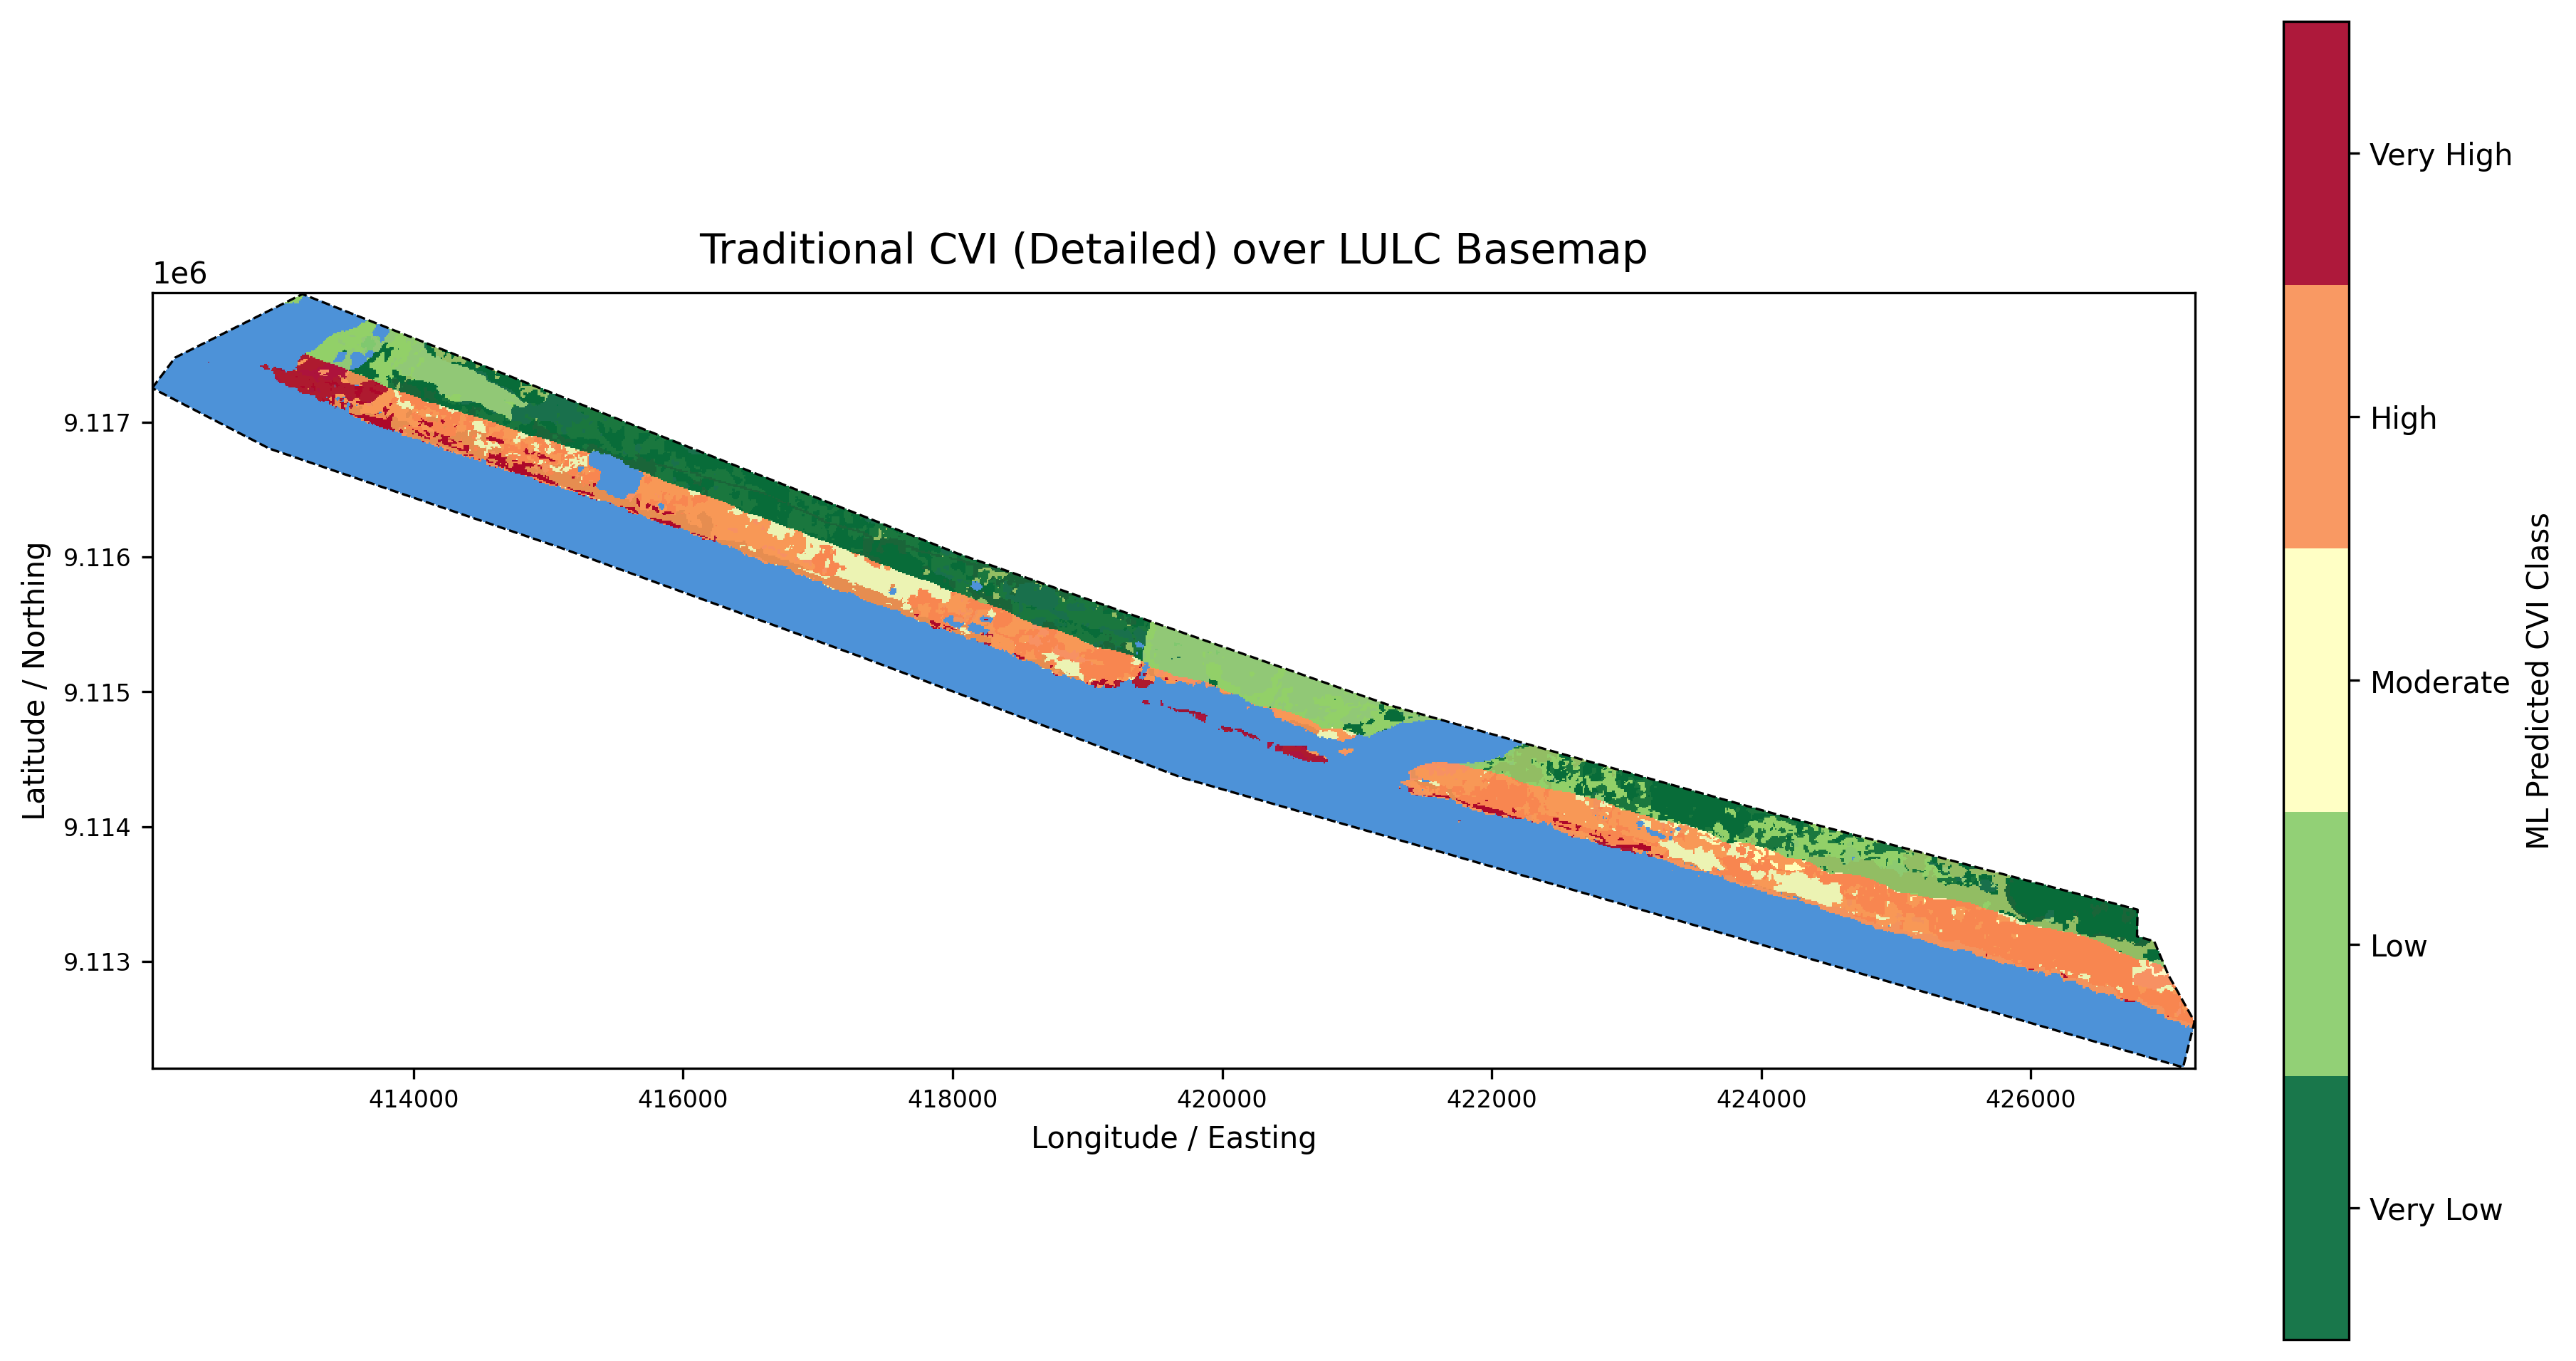

Visualizations saved to:
/content/drive/MyDrive/CCL_Bantul/results/traditional_cvi_classes_equal_visualization_with_lulc_basemap.png

=== Generating QGIS Style for: traditional_cvi_classes_equal.tif ===
QGIS style file saved to: /content/drive/MyDrive/CCL_Bantul/results/traditional_cvi_classes_equal.qml

=== create_raster_to_polygon_shapefile initialized ===

Converting raster 'traditional_cvi_classes_equal.tif' to polygon shapefile 'traditional_cvi_classes_equal.shp'...
Temporary integer raster saved to: /content/drive/MyDrive/CCL_Bantul/results/traditional_cvi_classes_equal_temp_int.tif
Running gdal_polygonize: gdal_polygonize.py /content/drive/MyDrive/CCL_Bantul/results/traditional_cvi_classes_equal_temp_int.tif -f ESRI Shapefile /content/drive/MyDrive/CCL_Bantul/results/traditional_cvi_classes_equal.shp traditional_cvi_classes_equal DN
gdal_polygonize completed.
Removed existing shapefile components for: /content/drive/MyDrive/CCL_Bantul/results/traditional_cvi_classes_equal.shp
Sh

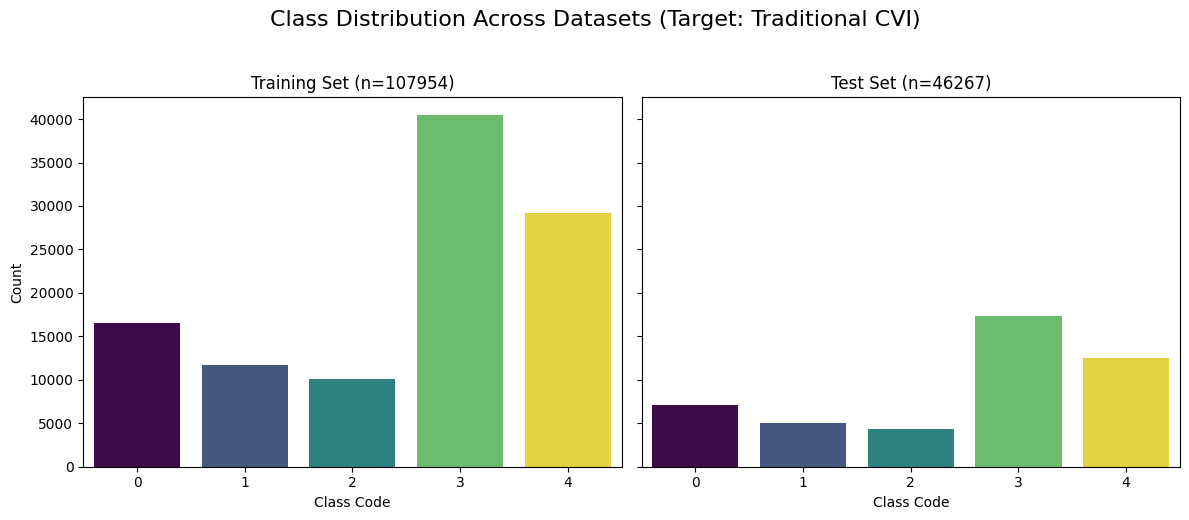

Class distribution plot saved to /content/drive/MyDrive/CCL_Bantul/results/class_distribution_split.png

Available machine learning algorithms:
1. Random Forest (default)
2. XGBoost
3. LightGBM


In [ ]:
def main():
    print(f"Starting Raster-based ML-CVI Assessment")
    print(f"Current date: {datetime.now().strftime('%A, %B %d, %Y, %I:%M %p')}")

    # Initialize Parameter Values Range for Coastal Vulnerability Classes
    param_specs_for_traditional_cvi = {
        'elevation': { # Lower elevation = higher risk. Bins are increasing values. Ranks are decreasing.
            'bins': [-np.inf, 5.0, 10.0, 20.0, 30.0, np.inf], # Thresholds
            'ranks': [5, 4, 3, 2, 1] # Hastuti et al Bali, Socioeconomic Yogya
        },
        'slope': { # Lower slope = higher risk. Bins are increasing values. Ranks are decreasing.
            'bins': [-np.inf, 5.0, 15.0, 30.0, 60.0, np.inf], # degrees
            'ranks': [5, 4, 3, 2, 1] # Bugel Coast
        },
        'shoreline_change': { # m/year.
            'bins': [-np.inf, -2.0, -1.0, 1.0, 2.0, np.inf], # Strong Erosion | Erosion | Stable | Slight Accretion | Strong Accretion
            'ranks': [5, 4, 3, 2, 1] # Sragi Coast, Socioeconomic Yogyakarta, Hastuti et al Bali
        },
        'significant_wave_height': {
            # Coastal Vulnerability Assessment of Bali Province, Indonesia Using Remote Sensing and GIS Approaches
            # Incorporating socioeconomic variables in coastal vulnerability assessment on the Southern Coast of Yogyakarta, Indonesia
            'bins': [-np.inf, 0.55, 0.85, 1.05, 1.25, np.inf],  # meters
            'ranks': [1, 2, 3, 4, 5] # CVI Semarang, Socioeconomic Yogya
        },
        'tidal_range': {
            'bins': [-np.inf, 1.0, 2.0, 4.0, 6.0, np.inf], # Correct
            'ranks': [5, 4, 3, 2, 1] # Hastuti et al Bali, CVI Semarang
        },
        'slr_rate': { # Higher SLR rate = higher risk. Bins are increasing values. Ranks are increasing.
            'bins': [-np.inf, -1.0, 1.0, 2.0, 4.0, np.inf], # mm/year
            'ranks': [1, 2, 3, 4, 5] # Hastuti et al Bali
        },
        'distance_to_shoreline': { # Closer distance = higher risk
            'bins': [-np.inf, 50, 100, 200, 300, np.inf], # meters
            'ranks': [5, 4, 3, 2, 1]
        }
    }

    # Some parameter initialization
    study_area_path = f'{BASE_DIR}/data/processed/study_area.gpkg'

    # LULC Dataset Selection
    lulc_options = {
        '1': {'name': 'ESA WorldCover 2021', 'key': 'esa', 'dates': False},
        '2': {'name': 'ESRI 10m Annual', 'key': 'esri', 'dates': True},
        '3': {'name': 'Google Dynamic World', 'key': 'dynamic_world', 'dates': True}
    }

    print("\nAvailable LULC Datasets:")
    for num, opt in lulc_options.items():
        print(f"{num}. {opt['name']}")

    while True:
        choice = input("\nEnter dataset number (1-3): ").strip()
        if choice in lulc_options:
            selected = lulc_options[choice]
            break
        print("Invalid input. Please try again.")

    print(f"\nSelected LULC: {selected['name']}")
    lulc_source_key = selected['key']

    # Set date for GEE satellite imagery option download
    start_date = '2021-01-01'
    end_date = '2022-01-01'

    # Land cover dataset selection
    lulc_path = None
    pattern = {
        'esa': 'esa_worldcover',
        'esri': 'esri_lulc',
        'dynamic_world': 'dynamic_world'
    }[lulc_source_key]

    existing = [f for f in os.listdir(f'{BASE_DIR}/data/raw')
                if pattern in f and f.endswith('.tif')]

    if existing:
        print(f"Using existing {selected['name']} file")
        lulc_path = f'{BASE_DIR}/data/raw/{existing[0]}'
    else:
        print(f"Downloading {selected['name']}...")
        lulc_path = download_gee_imagery(
            start_date if selected['dates'] else None,
            end_date if selected['dates'] else None,
            lulc_source_key
        )

    # Process land cover
    lulc_processed, lulc_profile = classify_landcover(lulc_path, study_area_path, lulc_source_key)

    # Process DEM with resolution change
    dem_path = find_demnas()
    if not dem_path:
        print("DEM processing failed")
        return
    elevation_path, slope_path = process_dem(dem_path, lulc_profile, study_area_path)

    # Process geomorphology
    geomorphology_source_shp_path = f'{BASE_DIR}/data/raw/geomorphology_yogyakarta.shp'
    if not os.path.exists(geomorphology_source_shp_path):
        print(f"WARNING: Geomorphology shapefile not found at {geomorphology_source_shp_path}.")
        geomorphology_path = None
    else:
        geomorphology_path = process_geomorphology_data(geomorphology_source_shp_path,
                                                        lulc_profile, study_area_path)

    # Process coastline data in a unified workflow
    print("\nProcessing coastline and shoreline change data...")
    coastline_data, coastline_path = process_coastline_data()
    coastline_gdf = coastline_data['coastline_gdf']

    # Calculate distance to shoreline
    distance_path = calculate_distance_to_shoreline(coastline_gdf, lulc_processed['lulc'],
                                                    lulc_source_key)

    # Define the coastal zone width for ocean-marine based parameters
    # Perpres 51/2016
    # Permen KKP 21/2018
    # Pergub DIY 8/2025
    sempadan_pantai = 300.0 #m

    # Calculate shoreline change rate
    shoreline_change_path = rasterize_shoreline_change(coastline_data, lulc_profile,
                                                       study_area_path, distance_path,
                                                       shoreline_change_spec=param_specs_for_traditional_cvi['shoreline_change'],
                                                       shoreline_impact_buffer_m=sempadan_pantai)

    if shoreline_change_path:
        visualize_shoreline_change(shoreline_change_path, lulc_processed['lulc'], coastline_path,
                                   study_area_path, distance_path, lulc_source_key,
                                   shoreline_impact_buffer_m=sempadan_pantai)

    print("Calculating ocean/marine-based parameters...")
    # To get the long-term average of wave height
    wave_height_path = calculate_wave_parameter(lulc_profile, study_area_path, lulc_source_key, statistic='mean')

    # To get the 90th percentile
    # wave_height_path = calculate_wave_parameter(lulc_profile, study_area_path, lulc_source_key, statistic='percentile', percentile=0.90)

    if wave_height_path:
        final_wave_height_path = spatialize_marine_parameter(wave_height_path,
                                                             distance_path,
                                                             lulc_processed['lulc'],
                                                             lulc_source_key,
                                                             study_area_path,
                                                             lulc_profile,
                                                             coastal_zone_width_m=sempadan_pantai,
                                                             parameter_spec=param_specs_for_traditional_cvi['significant_wave_height'],
                                                             parameter_name_for_output="significant_wave_height")

        visualize_spatialized_marine_parameter(
            spatialized_marine_raster_path=final_wave_height_path,
            lulc_path=lulc_processed['lulc'],
            study_area_path=study_area_path,
            coastline_gpkg_path=coastline_path,
            distance_to_shoreline_path=distance_path,
            coastal_zone_width_m=sempadan_pantai,
            parameter_name="Significant Wave Height",
            parameter_units="m",
            lulc_source_key=lulc_source_key,
            show_ocean_values=True
        )

    # Calculate sea level rise
    use_cmems_variable_slr = False
    if use_cmems_variable_slr:
        print("Using new IPCC AR6 constant rate calculation...")
        ipcc_nc_file = os.path.join(BASE_DIR, 'data', 'raw', 'total_novlm_ssp245_medium_confidence_rates.nc')
        if not os.path.exists(ipcc_nc_file):
            print(f"ERROR: IPCC NetCDF file not found at {ipcc_nc_file}")
            slr_rate_path = None
        else:
            ipcc_nc_file = os.path.join(BASE_DIR, 'data', 'raw', 'total_novlm_ssp245_medium_confidence_rates.nc')
            # Call the new function, specifying the target year for the rate
            slr_rate_path = calculate_sea_level_rise(
                ipcc_rates_nc_path=ipcc_nc_file,
                lulc_profile=lulc_profile,
                study_area_path=study_area_path,
                lulc_path=lulc_processed['lulc'],
                lulc_source_key=lulc_source_key,
                target_year=2030
            )

    else:
        researched_slr_rate = 4.0 # mm/yr
        slr_rate_path = get_constant_slr_rate(lulc_processed['lulc'], lulc_profile,
                                              study_area_path, researched_slr_rate, lulc_source_key)

    if slr_rate_path:
        final_slr_path = spatialize_marine_parameter(slr_rate_path,
                                                     distance_path,
                                                     lulc_processed['lulc'],
                                                     lulc_source_key,
                                                     study_area_path,
                                                     lulc_profile,
                                                     coastal_zone_width_m=sempadan_pantai,
                                                     parameter_spec=param_specs_for_traditional_cvi['slr_rate'],
                                                     parameter_name_for_output="slr_rate")
        visualize_slr_landcover(slr_rate_path, lulc_processed['lulc'], study_area_path, lulc_source_key)

        visualize_spatialized_marine_parameter(
            spatialized_marine_raster_path=final_slr_path,
            lulc_path=lulc_processed['lulc'],
            study_area_path=study_area_path,
            coastline_gpkg_path=coastline_path,
            distance_to_shoreline_path=distance_path,
            coastal_zone_width_m=sempadan_pantai,
            parameter_name="Sea Level Rise Rate",
            parameter_units="mm/yr",
            lulc_source_key=lulc_source_key,
            show_ocean_values=True
        )

    # Calculate tidal range
    fes_m2_file = f'{BASE_DIR}/data/raw/m2_fes2022.nc'
    fes_s2_file = f'{BASE_DIR}/data/raw/s2_fes2022.nc'
    fes_mask_file = f'{BASE_DIR}/data/raw/mask_fes2022B.nc'
    tidal_range_path = calculate_fes_tidal_range(fes_m2_file, fes_s2_file, fes_mask_file,
                                                 lulc_profile, study_area_path, lulc_processed['lulc'])

    if tidal_range_path:
        final_tidal_range_path = spatialize_marine_parameter(tidal_range_path,
                                                             distance_path,
                                                             lulc_processed['lulc'],
                                                             lulc_source_key,
                                                             study_area_path,
                                                             lulc_profile,
                                                             coastal_zone_width_m=sempadan_pantai,
                                                             parameter_spec=param_specs_for_traditional_cvi['tidal_range'],
                                                             parameter_name_for_output="tidal_range")
        visualize_tidal_range(tidal_range_path, lulc_processed['lulc'], study_area_path,
                          coastline_path, lulc_source_key)

        visualize_spatialized_marine_parameter(
            spatialized_marine_raster_path=final_tidal_range_path,
            lulc_path=lulc_processed['lulc'],
            study_area_path=study_area_path,
            coastline_gpkg_path=coastline_path,
            distance_to_shoreline_path=distance_path,
            coastal_zone_width_m=sempadan_pantai,
            parameter_name="Tidal Range",
            parameter_units="m",
            lulc_source_key=lulc_source_key,
            show_ocean_values=True
        )

    # List CVI parameters used for calculation
    cvi_input_param_paths = {
        'elevation': elevation_path,
        'slope': slope_path,
        'landcover': lulc_processed['lulc'],
        'shoreline_change': shoreline_change_path,
        'significant_wave_height': final_wave_height_path,
        'tidal_range': final_tidal_range_path,
        'slr_rate': final_slr_path,
        'distance_to_shoreline': distance_path,
        'geomorphology': geomorphology_path
    }

    # Set landcover ranks based on LULC source
    if 'landcover' in cvi_input_param_paths:
        if lulc_source_key == 'esa':
            print("Using ESA WorldCover 11-class specific ranks for Traditional CVI.")
            esa_lc_ranks = {
                code: props['cvi_rank']
                for code, props in ESA_WORLDCOVER_CLASSES.items()
                if 'cvi_rank' in props
            }
            param_specs_for_traditional_cvi['landcover'] = {'ranks_map': esa_lc_ranks}
        else: # For 'standard', 'custom', or other mapped LULC types
            print("Using STANDARD_LULC_CLASSES definition for CVI ranks.")
            std_lc_ranks = {
                code: props['cvi_rank']
                for code, props in STANDARD_LULC_CLASSES.items()
                if 'cvi_rank' in props
            }
            param_specs_for_traditional_cvi['landcover'] = {'ranks_map': std_lc_ranks}

    # Set geomorphology ranks
    if 'geomorphology' in cvi_input_param_paths:
        geom_cat_ranks = {
            code: props['cvi_rank']
            for code, props in GEOMORPHOLOGY_CLASSES.items()
            if 'cvi_rank' in props
        }
        param_specs_for_traditional_cvi['geomorphology'] = {'ranks_map': geom_cat_ranks}

    # Choose weighting for traditional CVI
    traditional_cvi_classes_path, classification_metadata = calculate_traditional_cvi(
        cvi_input_param_paths,
        lulc_profile,
        study_area_path,
        param_specs_for_traditional_cvi,
        coastline_path,
        lulc_source_key,
        weights_type='equal' # Can be 'equal' or 'entropy'
    )

    # Prepare ML training data based on traditional CVI result
    ml_training_df_raw = prepare_ml_training_data_with_cvi_target(
        traditional_cvi_classes_path,
        study_area_path,
        **cvi_input_param_paths
    )

    # Dynamically determine features for ML based on successfully processed parameters
    current_ml_features = list(cvi_input_param_paths.keys())

    # Preprocess ML Features
    df_for_ml, ml_features_list = preprocess_ml_features(ml_training_df_raw, current_ml_features)

    # Save the final DataFrame being fed to ML
    df_for_ml.to_csv(f'{BASE_DIR}/data/processed/ml_training_input_final.csv', index=False)
    print("\nML Training Data Distribution (Target Classes from Traditional CVI):")
    print(df_for_ml['class'].value_counts().sort_index())

    print(f"DataFrame shape: {df_for_ml.shape}")
    print("DataFrame head:")
    print(df_for_ml.head())

    print("\n--- Training ML Model with RandomizedSearchCV ---")
    ml_model_final, ml_model_metadata = train_ml_model(
        df_for_ml, classification_metadata, ml_features_list, study_area_path)

    # Predict CVI Classes using the Trained ML Model
    ml_predicted_cvi_path, prediction_metadata = predict_ml_cvi(ml_model_final,
                                                               elevation_path,
                                                               ml_model_metadata,
                                                               cvi_input_param_paths,
                                                               study_area_path)

    # Visualize ML-Predicted CVI Results
    if ml_predicted_cvi_path:
        algo_name = ml_model_metadata.get('algorithm', 'unknown_model')
        model_filename_base = algo_name.lower().replace(" ", "_")
        algo_results_dir = f'{BASE_DIR}/results/{model_filename_base}'

        visualize_ml_cvi(ml_predicted_cvi_path, lulc_processed['lulc'],
                         prediction_metadata, lulc_source_key, algo_results_dir)
        create_interactive_map(ml_predicted_cvi_path, lulc_processed['lulc'],
                               prediction_metadata, lulc_source_key)

    print("Raster-based Coastal Vulnerability Index with Tree-Based Machine Learning Algorithm complete.")
    print(f"All results saved to {BASE_DIR}/results/")

# Execute main function
if __name__ == "__main__":
    main()